In [1]:
include_dir = "../JuliaScripts/"

include(include_dir*"defs.jl")
include(include_dir*"Plot_defs.jl")



Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Including Graphical Packages...Setting LaTeX Theme...done!


# Line plots (sn-type vs settings)

        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
[-2, 0, -1, 2, 1]
Any[1, 2, 3, 4, 5]        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
Any[6, 8, 7, 10, 9]
[-2, 0, -1, 2, 1]
Any[6, 7, 8, 9, 10]       1

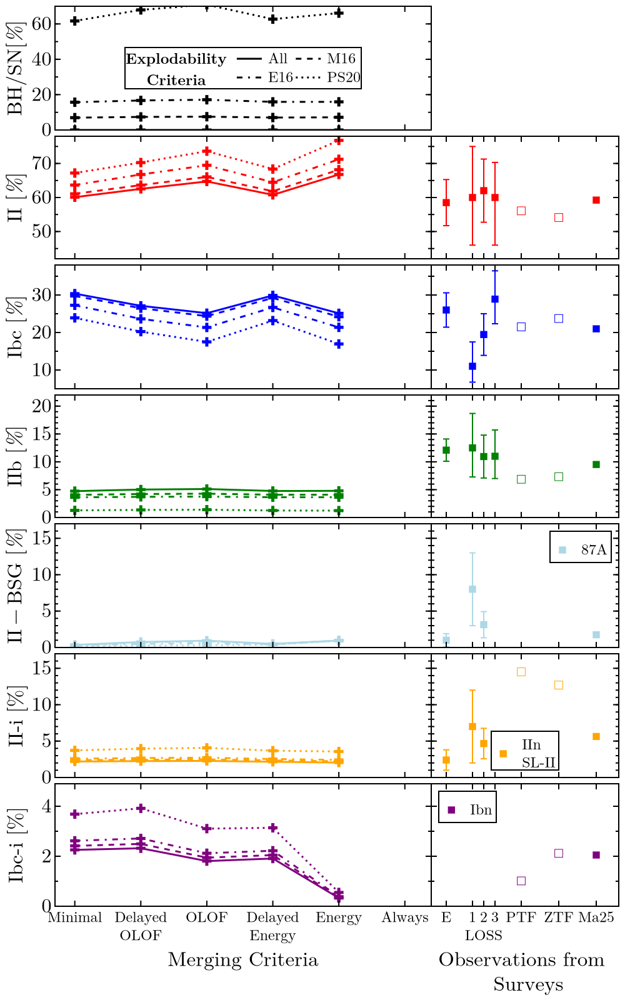

In [7]:
FIG = Figure(size=(500, 800), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "MER_CRIT" => SortedDict("X" => labval("Minimal",-2),
                             "ERK" => labval("Delayed\nOLOF",-1) ,
                             "PA_IV" => labval("OLOF",0),
                             "PAULI" => labval("Delayed\nEnergy", 1),
                             "PABLO" => labval("Energy", 2),
                             "ALL" => labval("Always", 3)),
    "EXP_CRIT" => SortedDict("MM-M16"=> labval("Muller et al.\n2016",-1), "Ertl-N20_new"  => labval("Ertl et al.\n2020",0), "PS20" => labval("Patton & Suckhbold\n2020",2),  
                            "comp0.35" => labval(L"\xi>0.35",1)),
    "fB"       => SortedDict(1.00 => 1, 0.75 => 0.75, 0.50 => 0.50, 0.25 => 0.25, 0.00=>0.00))
label = "MER_CRIT"

obs_to_dict = Dict(
    # "Smartt" => labval("S", -2.15),
    "Eldridge"  => labval("E", -2),
    "LOSS_low"  => labval("1", -1.3),
    "LOSS"      => labval("2\nLOSS", -1),
    "LOSS_high" => labval("3",-0.7),
    "PTF"       => labval("PTF", 0),
    # "ZTF" => labval("1\n   ZTF", 0.),
    "ZTF2"      => labval("ZTF", 1.),
    "Ma25"      => labval("Ma25", 2.),
    "ATLAS"     => labval("ATLAS", 3.),
)

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels = 1:4
right_panels = 5:6

yticklabelspace = 10.
ylabelpadding = 10.

ax_bh = plot_settings( grid[1,left_panels],
                xlabel = "",
                ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
                title = "", titlesize=30,
                xticks = xticks,
                yticks= 0:20:100,
                ymticks= 0:10:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_bsg = plot_settings( grid[5,left_panels],
                xlabel = "",
                ylabel =  L"\mathrm{II-BSG} \ [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                yticks= 0:5:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:1:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,# yscale = log10, 
                xticklabelrotation = 0,xlabelvisible=false, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xticklabelsvisible=false)
ax_bsg_obs = plot_settings( grid[5,right_panels],
                xlabel =  "",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks= 0:5:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:1:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,xlabelvisible=false, 
                xticklabelsvisible=false)
ax_int = plot_settings( grid[6,left_panels],
                xlabel = " ",
                ylabel =  "II-i [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[6,right_panels],
                xlabel = " ",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[7,left_panels],
                xlabel = L"\mathrm{Merging \ Criteria}",
                ylabel =  "Ibc-i [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[7,right_panels],
                xlabel = "Observations from \n Surveys",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax_IIb = plot_settings( grid[4,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{IIb} \ [%]",
                yticks = (0.:5:100),#([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,#yscale=log10,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                title = "", titlesize=30,                xticks = xticks, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_IIb_obs = plot_settings( grid[4,right_panels],
                xlabel = "",
                ylabel = "",
                title = "", titlesize=30,
                yticks = (0.:5:100),#([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,#yscale=log10,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticks = xticks_obs,
                yticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_Ibc = plot_settings( grid[3,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{Ibc} \ [%]",
                title = "", titlesize=30, xticks = xticks, yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_Ibc_obs = plot_settings( grid[3,right_panels],
                xlabel = "",
                ylabel = "",
                xticks = xticks_obs,
                title = "", titlesize=30,
                ymticks=(0.:5:100), 
                yticklabelsvisible=false, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_II = plot_settings( grid[2,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  L"\mathrm{II} \ [%]",  
                title = "", titlesize=30,xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                ymticks=(0.:5:100), 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[2,right_panels],
                xlabel = "",
                ylabel = "",  
                xticks = xticks_obs,
                title = "", titlesize=30, yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                yticklabelsvisible=false,xlabelvisible=false, xticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)


# ax_misc = plot_settings( grid[0,1:3],
#                 xlabel = "",
#                 ylabel =  "  ",
#                 title = "", titlesize=30,xticks = xticks,
#                 xticklabelsize = 15, yticklabelsize = 20,xlabelvisible=false, xticklabelsvisible=false, 
#                 xlabelsize = 15, ylabelsize = 22)

                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 0.5
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                
print(SN_ix)
x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
print("\n", x_og)
ix_og = SN_ix
x = x_og[sortperm( x_og )]
ix_n =  ix_og[sortperm( x_og )]
print("\n", ix_n)

SN2 = SN_ix

ms = 20
linestyles = Dict("X"=>:solid, "MM-S21"=>:dash, "Ertl-N20_new" =>:dashdot, "PS20"=>:dot )
labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
ls = linestyles[exp]
show_label = exp=="MM-S21"
marker = :cross
markersize= 10
scatterlines!(ax_II,    x, [SN_FILE.IIP[ix]+1e-10         for ix in ix_n], color=:red,       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_bsg,   x, [SN_FILE[!, "IIP-B"][ix]+1e-10 for ix in ix_n], color=:lightblue, label = show_label ? "II-BSG" : nothing , linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_Ibc,   x, [SN_FILE.Ibc[ix]+1e-10         for ix in ix_n], color=:blue,      label = show_label ? "Ibc" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_IIb,   x, [SN_FILE.IIb[ix]+1e-10         for ix in ix_n], color=:green,     label = show_label ? "IIb" : nothing , linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_int,   x, [SN_FILE[!, "II-i"][ix]+1e-10  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_int_I,   x, [SN_FILE[!, "Ibc-i"][ix]+1e-10 for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
lines!(ax_bh,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)


totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


Perley2020_ZTF = OrderedDict("label"=>"ZTF",
    "IIn"     => 0.722 * 0.142 * 100 + (0.722 * 0.035 * 100),
    #"SLSN-II" => 0.722 * 0.035 * 100,  ^^^
    "Ibn"     => 0.278 * 0.092 * 100,
    #"Ic-BL"   => 0.278 * 0.195 * 100,   vvv
    "Ibc"     => 0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100),
    #"SLSN-I"  => 0.278 * 0.126 * 100,                                ^^^
    "IIb"     => 0.722 * 0.066 * 100, 
    "II"     => 0.722 * 0.757 * 100,
)


Schulze2021_PTF = Dict("label"=>"PTF",
    "II"     =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100+(16+ 1+ 1)/888*100,
    #"SLSN-II" => (16+ 1+ 1)/888*100, ^^^
    #"Ic-BL"   =>         36/888*100,             vvv
    "Ibc"     => (46+12+60)/888*100 + 37/888*100 +36/888*100,
    #"SLSN-I"  =>         37/888*100, ^^^
    "Ibn"     =>          9/888*100,
)

function include_poisson_errors(SN_sample)

    for key in keys(SN_sample)
        key == "label" && continue 
        SN = key
        mu = SN_sample[SN]
        s = sqrt(mu)
        SN_sample[SN] = Dict(
            "mu" => mu,
            "s" => s,
        )
    end
    
end

include_poisson_errors(Perley2020_ZTF)
include_poisson_errors(Schulze2021_PTF)


valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
valpm(mu,s) = Dict("mu"=>mu, "ul"=>mu+s, "ll"=>mu-s, "s+"=>s, "s-"=>s, "s"=>s)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))


Hinds25 = OrderedDict("label"=>"ZTF2",
    "IIn"     => valpm((145+23)/(981+342)*100, sqrt(sqrt(145)^2+sqrt(23)^2)/(981+342)*100), #includes SL-II
    "Ibn"     => valpm((27+1)/(981+342)*100, sqrt(sqrt(27)^2+sqrt(1)^2)/(981+342)*100), #includes 1 Icn
    "Ibc"     => valpm((223+45+46)/(981+342)*100, sqrt(sqrt(223)^2+sqrt(45)^2+sqrt(46)^2)/(981+342)*100), #includes Ic-BL and SL-I
    "IIb"     => valpm((97)/(981+342)*100, sqrt(97)/(981+342)*100), 
    "II"      => valpm((716)/(981+342)*100, sqrt(176)/(981+342)*100)
)

Eldridge13 =  Dict("label"=>"Eldridge",
    "II"      =>  valpm(55.5+3.0, sqrt(6.6^ 2 + 1.5^ 2)),
    "IIb"     =>  valpm(12.1, 2.0),
    "IIn"     =>  valpm(2.4, 1.4),
    "Ibc"     =>  valpm(9.0+17.0, sqrt(2.7^2+3.7^2)),
    "87A"     =>  valpm(1, 0.9)
)

Smartt2009 =  Dict("label"=>"Smartt",
    "II"      =>  valpm(58.7+2.7, sqrt(8.0^ 2 + 1.7^ 2)),
    "IIb"     =>  valpm(5.4, 2.7),
    "IIn"     =>  valpm(3.8, 2.0),
    "Ibc"     =>  valpm(19.6+9.8, sqrt(3.3^2+4.5^2)),
)

Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low",
    "II"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high",
    "II"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS",
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "II"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25",
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "IIP-B"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+12.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)



errorbar_linewidth=1
whiskerwidth=5

marker = :rect


# sample =Smartt2009
# scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Eldridge13
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)


sample =Graur2017_LOSS_lowmassGal
scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
errorbars!( ax_int_obs,[obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
errorbars!( ax_bsg_obs,[obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s-"]], [sample["87A"]["s+"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
 
sample =Graur2017_LOSS_highmassGal
errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)

sample =Shivvers2017_LOSS
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker=marker)
scatter!(ax_bsg_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP-B"]["mu"]], color = :lightblue, marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

marker = '□'

sample =Hinds25
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker =marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker = marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker =marker)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Schulze2021_PTF
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

# sample =Perley2020_ZTF
# scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# # errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# # errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# # errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# # errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# # errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


ls=:solid
scatter!(ax_int_obs,   [-5, -5], [1e-99,1e-99], color=:orange, label = "IIn\nSL-II", marker = :rect)
scatter!(ax_int_I_obs, [-5, -5], [1e-99,1e-99], color=:purple, label = "Ibn", marker = :rect)
scatter!(ax_bsg_obs,   [-5, -5], [1e-99,1e-99], color=:lightblue, label = "87A", marker = :rect)



# axislegend(ax_II,nbanks=1, position=:lt)
# axislegend(ax_IIb,nbanks=1, position=:lt)
# axislegend(ax_int,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
# axislegend(ax_int_I,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
axislegend(ax_int_obs,nbanks=1, position=:cb, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
axislegend(ax_int_I_obs,nbanks=1, position=:lt, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
axislegend(ax_bsg_obs,nbanks=2, position=:rt, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
axislegend(ax_bh,"Explodability\nCriteria", nbanks=2, position=:cc, rowgap =-5, colgap =2,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,-1,-1))
# axislegend(ax_Ibc,nbanks=1, position=:lb)




ylims!(ax_int, 0. ,17)
ylims!(ax_int_obs, 0. ,17)
ylims!(ax_int_I, 0. ,4.9)
ylims!(ax_int_I_obs, 0. ,4.9)
ylims!(ax_bsg, 0. ,17)
ylims!(ax_bsg_obs, 0. ,17)
ylims!(ax_IIb, 0., 22)
ylims!(ax_IIb_obs, 0., 22)
ylims!(ax_Ibc, 5, 38)
ylims!(ax_Ibc_obs, 5, 38)
ylims!(ax_II, 42, 78)
ylims!(ax_II_obs, 42, 78)
# ylims!(ax_misc, 1,1.5)
ylims!(ax_bh, 0, 70)
for ax in [ax_int,ax_int_I,ax_IIb,ax_Ibc,ax_II,ax_bh,ax_bsg]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.3,3.4)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_IIb_obs,ax_Ibc_obs,ax_II_obs, ax_bsg_obs]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.4,2.6)
end
rowgap!(grid, 5)
colgap!(grid, 0)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_new.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG


In [14]:
Ma25_mixed_vollim

Dict{String, Any} with 7 entries:
  "label" => "Ma25"
  "IIn"   => Dict("ul"=>8.17393, "ll"=>3.09521, "s"=>2.53936, "mu"=>5.63457)
  "IIb"   => Dict("ul"=>12.9432, "ll"=>6.09252, "s"=>3.42534, "mu"=>9.51786)
  "Ibn"   => Dict("ul"=>3.14877, "ll"=>0.949514, "s"=>1.09963, "mu"=>2.04914)
  "Ibc"   => Dict("ul"=>Inf, "ll"=>-Inf, "s"=>Inf, "mu"=>20.9804)
  "IIP"   => Dict("ul"=>75.7476, "ll"=>42.7306, "s"=>16.5085, "mu"=>59.2391)
  "IIP-B" => Dict("ul"=>3.09034, "ll"=>0.412231, "s"=>1.33905, "mu"=>1.75129)

In [28]:
SN_subix

UndefVarError: UndefVarError: `SN_subix` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
Nmerg (exp)     X    dO     O    dE     E
         X 30.09 31.53 35.43 38.58 41.13
        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
Any[6, 8, 7, 10, 9

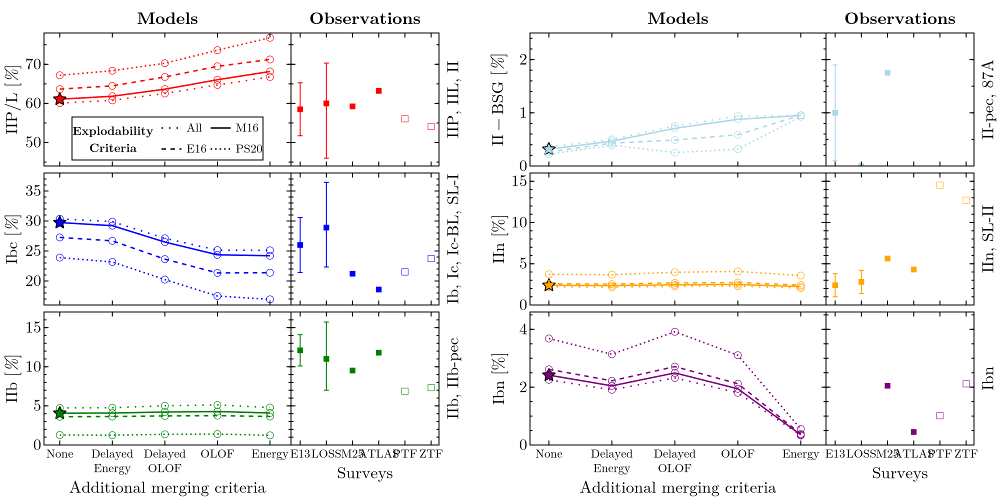

In [8]:
FIG = Figure(size=(1000, 500), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "MER_CRIT" => SortedDict("X" => labval("None",-2),
                             "ERK" => labval("Delayed\nOLOF",-0) ,
                             "PA_IV" => labval("OLOF",1),
                             "PAULI" => labval("Delayed\nEnergy", -1),
                             "PABLO" => labval("Energy", 2),
                             "ALL" => labval("Always", 3)),
    "EXP_CRIT" => SortedDict("MM-M16"=> labval("Muller et al.\n2016",-1), "Ertl-N20_new"  => labval("Ertl et al.\n2020",0), "PS20" => labval("Patton & Suckhbold\n2020",2),  
                            "comp0.35" => labval(L"\xi>0.35",1)),
    "fB"       => SortedDict(1.00 => 1, 0.75 => 0.75, 0.50 => 0.50, 0.25 => 0.25, 0.00=>0.00))
label = "MER_CRIT"

obs_to_dict = Dict(
    # "Smartt" => labval("S", -2.15),
    "Eldridge"  => labval("E13", -2),
    # "LOSS_low"  => labval("L", -1.33),
    # "LOSS"      => labval("A\nLOSS", -1.15),
    "LOSS_high" => labval("LOSS",-1),
    "PTF"       => labval("PTF", 2),
    # "ZTF" => labval("1\n   ZTF", 0.),
    "ZTF2"      => labval("ZTF", 3),
    "Ma25"      => labval("M25", 0.),
    "ATLAS"   =>labval("ATLAS", 1)
)

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_L = 1:5
right_panels_L = 6:8
left_panels_R = 9:14
right_panels_R = 15:17

yticklabelspace = 10.
ylabelpadding = 10.

# ax_bh = plot_settings( grid[1,left_panels_L],
#                 xlabel = "",
#                 ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
#                 title = "", titlesize=30,
#                 xticks = xticks,
#                 yticks= 0:20:100,
#                 ymticks= 0:10:100,
#                 xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
#                 xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
#                 ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_bsg = plot_settings( grid[1,left_panels_R],
                xlabel = "",
                ylabel =  L"\mathrm{II-BSG} \ [%]",
                title = "Models", titlesize=17,
                xticks = xticks, 
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.2:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,# yscale = log10, 
                xticklabelrotation = 0,xlabelvisible=false, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xticklabelsvisible=false)
ax_bsg_obs = plot_settings( grid[1,right_panels_R],
                xlabel =  "",
                ylabel =  "II-pec, 87A", yaxisposition=:right,
                title = "Observations", titlesize=17,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.5:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,xlabelvisible=false, 
                xticklabelsvisible=false)
ax_int = plot_settings( grid[2,left_panels_R],
                xlabel = " ",
                ylabel =  "IIn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[2,right_panels_R],
                xlabel = " ",
                ylabel =  "IIn, SL-II", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[3,left_panels_R],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabel =  "Ibn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[3,right_panels_R],
                xlabel = "Surveys",
                ylabel =  "Ibn", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax_IIb = plot_settings( grid[3,left_panels_L],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabel = L"\mathrm{IIb} \ [%]",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_IIb_obs = plot_settings( grid[3,right_panels_L],
                xlabel = "Surveys",
                ylabel =  "IIb, IIb-pec", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax_Ibc = plot_settings( grid[2,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{Ibc} \ [%]",
                title = "", titlesize=30, xticks = xticks, yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100), 
                yticks = (0.:5:100, [L"%$(str_significant(t, 2))" for t in 0.:5.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_Ibc_obs = plot_settings( grid[2,right_panels_L],
                xlabel = "",
                ylabel =  "Ib, Ic, Ic-BL, SL-I", yaxisposition=:right,
                xticks = xticks_obs,
                title = "", titlesize=30,
                ymticks=(0.:1:100), 
                yticklabelsvisible=false, yticklabelpad=yticklabelpad,
                yticks = (0.:5:100, [L"%$(str_significant(t, 2))" for t in 0.:5.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_II = plot_settings( grid[1,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  L"\mathrm{IIP/L} \ [%]",  
                title = "Models", titlesize=17,
                xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                ymticks=(0.:5:100), 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[1,right_panels_L],
                xlabel = "",
                ylabel =  "IIP, IIL, II", yaxisposition=:right,
                xticks = xticks_obs,
                title = "Observations", titlesize=17,
                yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                yticklabelsvisible=false,xlabelvisible=false, xticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)


# ax_misc = plot_settings( grid[0,1:3],
#                 xlabel = "",
#                 ylabel =  "  ",
#                 title = "", titlesize=30,xticks = xticks,
#                 xticklabelsize = 15, yticklabelsize = 20,xlabelvisible=false, xticklabelsvisible=false, 
#                 xlabelsize = 15, ylabelsize = 22)

                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 0.5
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    # print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    # print("\n", ix_n)

    @printf("\n%10s %5s %5s %5s %5s %5s\n", "Nmerg (exp)", "X", "dO", "O", "dE", "E")
    @printf("%10s %5.2f %5.2f %5.2f %5.2f %5.2f\n", exp, 
              SN_FILE[!, "IIP_M"][ix_n[1]] + SN_FILE[!, "IIP-B_M"][ix_n[1]] + SN_FILE[!, "IIb_M"][ix_n[1]] + SN_FILE[!, "Ibc_M"][ix_n[1]] + SN_FILE[!, "Ibc-i_M"][ix_n[1]] + SN_FILE[!, "BH_M"][ix_n[1]] + SN_FILE[!, "II-i_M"][ix_n[1]],
              SN_FILE[!, "IIP_M"][ix_n[2]] + SN_FILE[!, "IIP-B_M"][ix_n[2]] + SN_FILE[!, "IIb_M"][ix_n[2]] + SN_FILE[!, "Ibc_M"][ix_n[2]] + SN_FILE[!, "Ibc-i_M"][ix_n[2]] + SN_FILE[!, "BH_M"][ix_n[2]] + SN_FILE[!, "II-i_M"][ix_n[2]],
              SN_FILE[!, "IIP_M"][ix_n[3]] + SN_FILE[!, "IIP-B_M"][ix_n[3]] + SN_FILE[!, "IIb_M"][ix_n[3]] + SN_FILE[!, "Ibc_M"][ix_n[3]] + SN_FILE[!, "Ibc-i_M"][ix_n[3]] + SN_FILE[!, "BH_M"][ix_n[3]] + SN_FILE[!, "II-i_M"][ix_n[3]],
              SN_FILE[!, "IIP_M"][ix_n[4]] + SN_FILE[!, "IIP-B_M"][ix_n[4]] + SN_FILE[!, "IIb_M"][ix_n[4]] + SN_FILE[!, "Ibc_M"][ix_n[4]] + SN_FILE[!, "Ibc-i_M"][ix_n[4]] + SN_FILE[!, "BH_M"][ix_n[4]] + SN_FILE[!, "II-i_M"][ix_n[4]],
              SN_FILE[!, "IIP_M"][ix_n[5]] + SN_FILE[!, "IIP-B_M"][ix_n[5]] + SN_FILE[!, "IIb_M"][ix_n[5]] + SN_FILE[!, "Ibc_M"][ix_n[5]] + SN_FILE[!, "Ibc-i_M"][ix_n[5]] + SN_FILE[!, "BH_M"][ix_n[5]] + SN_FILE[!, "II-i_M"][ix_n[5]],

              )

    SN2 = SN_ix

    ms = 20
    linestyles = Dict("X"=>Linestyle([0,1,5,]), "MM-S21"=>:solid, "Ertl-N20_new" =>:dash, "PS20"=>:dot )
    labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
    ls = linestyles[exp]
    show_label = false# exp=="MM-S21"
    marker = '○'
    markersize= 10
    scatterlines!(ax_II,    x, [SN_FILE.IIP[ix]+1e-10         for ix in ix_n], color=:red,       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_bsg,   x, [SN_FILE[!, "IIP-B"][ix]+1e-10 for ix in ix_n], color=:lightblue, label = show_label ? "II-BSG" : nothing , linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_Ibc,   x, [SN_FILE.Ibc[ix]+1e-10         for ix in ix_n], color=:blue,      label = show_label ? "Ibc" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_IIb,   x, [SN_FILE.IIb[ix]+1e-10         for ix in ix_n], color=:green,     label = show_label ? "IIb" : nothing , linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int,   x, [SN_FILE[!, "II-i"][ix]+1e-10  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int_I, x, [SN_FILE[!, "Ibc-i"][ix]+1e-10 for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    # scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
    lines!(ax_II,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)

    if exp == "MM-S21"

        marker = :star5
        markersize= 15
        scatter!(ax_II,    [x[1]], [SN_FILE.IIP[ix_n[1]]+1e-10         ], color=:red,       label = show_label ? "IIP"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_bsg,   [x[1]], [SN_FILE[!, "IIP-B"][ix_n[1]]+1e-10 ], color=:lightblue, label = show_label ? "II-BSG" : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_Ibc,   [x[1]], [SN_FILE.Ibc[ix_n[1]]+1e-10         ], color=:blue,      label = show_label ? "Ibc"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_IIb,   [x[1]], [SN_FILE.IIb[ix_n[1]]+1e-10         ], color=:green,     label = show_label ? "IIb"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int,   [x[1]], [SN_FILE[!, "II-i"][ix_n[1]]+1e-10  ], color=:orange,    label = show_label ? "II-i"   : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int_I, [x[1]], [SN_FILE[!, "Ibc-i"][ix_n[1]]+1e-10 ], color=:purple,    label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
    end 

    totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
    x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


Perley2020_ZTF = OrderedDict("label"=>"ZTF",
    "IIn"     => 0.722 * 0.142 * 100 + (0.722 * 0.035 * 100),
    #"SLSN-II" => 0.722 * 0.035 * 100,  ^^^
    "Ibn"     => 0.278 * 0.092 * 100,
    #"Ic-BL"   => 0.278 * 0.195 * 100,   vvv
    "Ibc"     => 0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100),
    #"SLSN-I"  => 0.278 * 0.126 * 100,                                ^^^
    "IIb"     => 0.722 * 0.066 * 100, 
    "II"     => 0.722 * 0.757 * 100,
)


Schulze2021_PTF = Dict("label"=>"PTF",
    "II"     =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100+(16+ 1+ 1)/888*100,
    #"SLSN-II" => (16+ 1+ 1)/888*100, ^^^
    #"Ic-BL"   =>         36/888*100,             vvv
    "Ibc"     => (46+12+60)/888*100 + 37/888*100 +36/888*100,
    #"SLSN-I"  =>         37/888*100, ^^^
    "Ibn"     =>          9/888*100,
)

function include_poisson_errors(SN_sample)

    for key in keys(SN_sample)
        key == "label" && continue 
        SN = key
        mu = SN_sample[SN]
        s = sqrt(mu)
        SN_sample[SN] = Dict(
            "mu" => mu,
            "s" => s,
        )
    end
    
end

include_poisson_errors(Perley2020_ZTF)
include_poisson_errors(Schulze2021_PTF)


valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
valpm(mu,s) = Dict("mu"=>mu, "ul"=>mu+s, "ll"=>mu-s, "s+"=>s, "s-"=>s, "s"=>s)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))


Hinds25 = OrderedDict("label"=>"ZTF2",
    "IIn"     => valpm((145+23)/(981+342)*100, sqrt(sqrt(145)^2+sqrt(23)^2)/(981+342)*100), #includes SL-II
    "Ibn"     => valpm((27+1)/(981+342)*100, sqrt(sqrt(27)^2+sqrt(1)^2)/(981+342)*100), #includes 1 Icn
    "Ibc"     => valpm((223+45+46)/(981+342)*100, sqrt(sqrt(223)^2+sqrt(45)^2+sqrt(46)^2)/(981+342)*100), #includes Ic-BL and SL-I
    "IIb"     => valpm((97)/(981+342)*100, sqrt(97)/(981+342)*100), 
    "II"      => valpm((716)/(981+342)*100, sqrt(176)/(981+342)*100)
)

Eldridge13 =  Dict("label"=>"Eldridge",
    "II"      =>  valpm(55.5+3.0, sqrt(6.6^ 2 + 1.5^ 2)),
    "IIb"     =>  valpm(12.1, 2.0),
    "IIn"     =>  valpm(2.4, 1.4),
    "Ibc"     =>  valpm(9.0+17.0, sqrt(2.7^2+3.7^2)),
    "87A"     =>  valpm(1, 0.9)
)

Smartt2009 =  Dict("label"=>"Smartt",
    "II"      =>  valpm(58.7+2.7, sqrt(8.0^ 2 + 1.7^ 2)),
    "IIb"     =>  valpm(5.4, 2.7),
    "IIn"     =>  valpm(3.8, 2.0),
    "Ibc"     =>  valpm(19.6+9.8, sqrt(3.3^2+4.5^2)),
)

Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low",
    "II"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high",
    "II"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "87A"     => valpm(0,0),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS",
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "II"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25",
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "IIP-B"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+13.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)

ATLAS25 = Dict("label"=>"ATLAS",
    "IIn"    => valpm(4.3, 1.9, 1.6),
    "IIP"     =>  valpm(63.2, 14.4, 13.8),
    "IIb"    => valpm(11.8, 9.9, 7.1),
    "Ibc"    => valpm(11.8+5.8+0.47+0.51, 
                      sqrt(5.2^2+4.4^2+.48^2+.55^2),
                      sqrt(4.9^2+3.7^2+.46^2+.32^2)),
    "Ibn"    => valpm(.45,.44,.42)
)



errorbar_linewidth=1
whiskerwidth=5

marker = :rect


# sample =Smartt2009
# scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Eldridge13
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)


# sample =Graur2017_LOSS_lowmassGal
# scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# errorbars!( ax_int_obs,[obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!( ax_bsg_obs,[obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s-"]], [sample["87A"]["s+"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
 
sample =Graur2017_LOSS_highmassGal
errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)

# sample =Shivvers2017_LOSS
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker=marker)
scatter!(ax_bsg_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP-B"]["mu"]], color = :lightblue, marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =ATLAS25
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

marker = '□'

sample =Hinds25
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker =marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker = marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker =marker)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Schulze2021_PTF
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

# sample =Perley2020_ZTF
# scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
# # errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
# # errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
# # errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
# # errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)
# # errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


ls=:solid
# scatter!(ax_int_obs,   [-5, -5], [1e-99,1e-99], color=:orange, label = "IIn\nSL-II", marker = :rect)
# scatter!(ax_int_I_obs, [-5, -5], [1e-99,1e-99], color=:purple, label = "Ibn", marker = :rect)
# scatter!(ax_bsg_obs,   [-5, -5], [1e-99,1e-99], color=:lightblue, label = "87A", marker = :rect)



# axislegend(ax_II,nbanks=1, position=:lt)
# axislegend(ax_IIb,nbanks=1, position=:lt)
# axislegend(ax_int,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
# axislegend(ax_int_I,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
# axislegend(ax_int_obs,nbanks=1, position=:cb, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
# axislegend(ax_int_I_obs,nbanks=1, position=:lt, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
# axislegend(ax_bsg_obs,nbanks=2, position=:rt, rowgap =0, colgap =0, labelsize=12, framevisible = true, padding=(0,3,0,5), framealpha =0.5)
axislegend(ax_II,"Explodability\nCriteria", nbanks=2, position=:cb, rowgap =1, colgap =4,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,1,1))
# axislegend(ax_Ibc,nbanks=1, position=:lb)




ylims!(ax_int, 0. ,16)
ylims!(ax_int_obs, 0. ,16)
ylims!(ax_int_I, 0. ,4.6)
ylims!(ax_int_I_obs, 0. ,4.6)
ylims!(ax_bsg, 0. ,2.5)
ylims!(ax_bsg_obs, 0. ,2.5)
ylims!(ax_IIb, 0., 17)
ylims!(ax_IIb_obs, 0., 17)
ylims!(ax_Ibc, 16, 38)
ylims!(ax_Ibc_obs, 16, 38)
ylims!(ax_II, 44, 78)
ylims!(ax_II_obs, 44, 78)
# ylims!(ax_misc, 1,1.5)
# ylims!(ax_bh, 0, 70)
for ax in [ax_int,ax_int_I,ax_IIb,ax_Ibc,ax_II,ax_bsg]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.3,2.4)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_IIb_obs,ax_Ibc_obs,ax_II_obs, ax_bsg_obs]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.35,3.3)
end
rowgap!(grid, 7)
colgap!(grid, 0)
colgap!(grid, 8, 30)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_new.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
Nmerg (exp)     X    dO     O    dE     E
         X 30.09 31.53 35.43 38.58 41.13
        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
Any[6, 8, 7, 10, 9

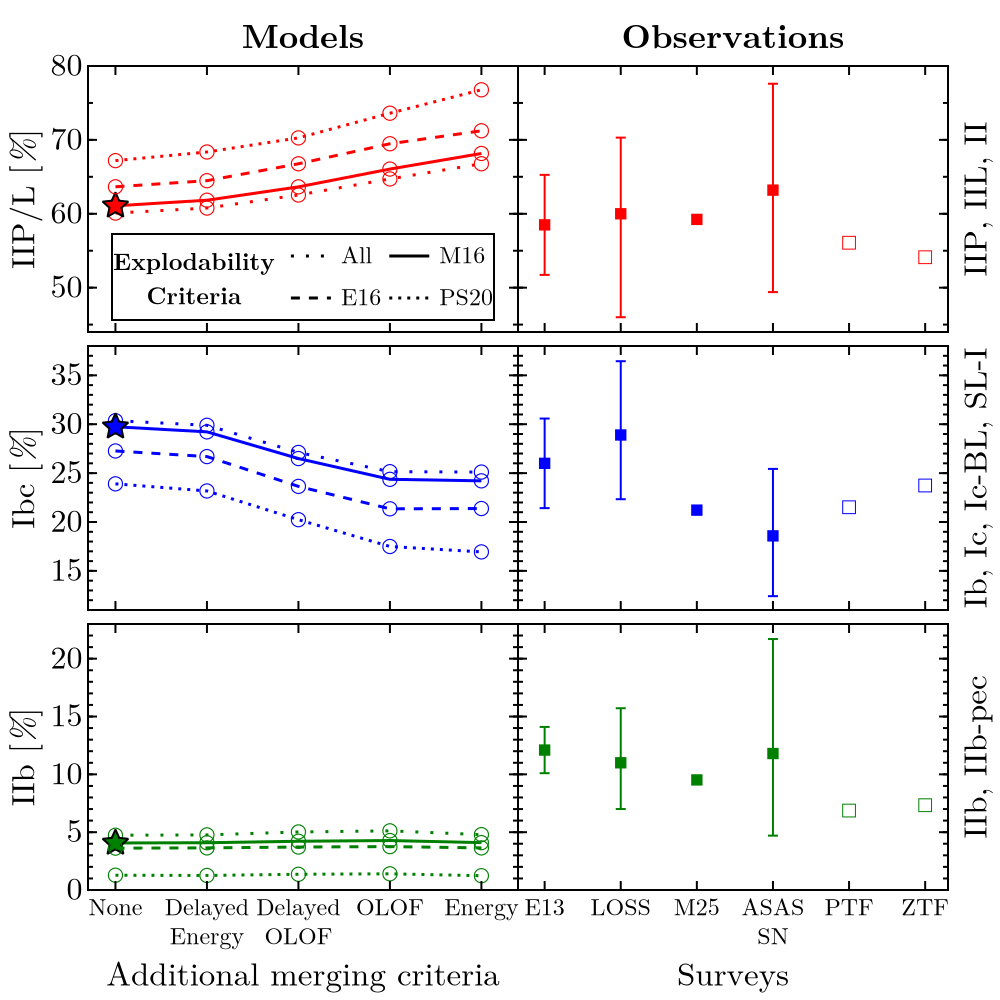

In [9]:
FIG = Figure(size=(500, 500), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "MER_CRIT" => SortedDict("X" => labval("None",-2),
                             "ERK" => labval("Delayed\nOLOF",-0) ,
                             "PA_IV" => labval("OLOF",1),
                             "PAULI" => labval("Delayed\nEnergy", -1),
                             "PABLO" => labval("Energy", 2),
                             "ALL" => labval("Always", 3)),
    "EXP_CRIT" => SortedDict("MM-M16"=> labval("Muller et al.\n2016",-1), "Ertl-N20_new"  => labval("Ertl et al.\n2020",0), "PS20" => labval("Patton & Suckhbold\n2020",2),  
                            "comp0.35" => labval(L"\xi>0.35",1)),
    "fB"       => SortedDict(1.00 => 1, 0.75 => 0.75, 0.50 => 0.50, 0.25 => 0.25, 0.00=>0.00))
label = "MER_CRIT"

obs_to_dict = Dict(
    # "Smartt" => labval("S", -2.15),
    "Eldridge"  => labval("E13", -2),
    # "LOSS_low"  => labval("L", -1.33),
    # "LOSS"      => labval("A\nLOSS", -1.15),
    "LOSS_high" => labval("LOSS",-1),
    "PTF"       => labval("PTF", 2),
    # "ZTF" => labval("1\n   ZTF", 0.),
    "ZTF2"      => labval("ZTF", 3),
    "Ma25"      => labval("M25", 0.),
    "ASAS-SN"   =>labval("ASAS\nSN", 1)
)

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_L = 1
right_panels_L = 2


yticklabelspace = 10.
ylabelpadding = 10.

# ax_bh = plot_settings( grid[1,left_panels_L],
#                 xlabel = "",
#                 ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
#                 title = "", titlesize=30,
#                 xticks = xticks,
#                 yticks= 0:20:100,
#                 ymticks= 0:10:100,
#                 xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
#                 xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
#                 ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_IIb = plot_settings( grid[3,left_panels_L],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabel = L"\mathrm{IIb} \ [%]",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_IIb_obs = plot_settings( grid[3,right_panels_L],
                xlabel = "Surveys",
                ylabel =  "IIb, IIb-pec", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax_Ibc = plot_settings( grid[2,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{Ibc} \ [%]",
                title = "", titlesize=30, xticks = xticks, yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100), 
                yticks = (0.:5:100, [L"%$(str_significant(t, 2))" for t in 0.:5.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_Ibc_obs = plot_settings( grid[2,right_panels_L],
                xlabel = "",
                ylabel =  "Ib, Ic, Ic-BL, SL-I", yaxisposition=:right,
                xticks = xticks_obs,
                title = "", titlesize=30,
                ymticks=(0.:1:100), 
                yticklabelsvisible=false, yticklabelpad=yticklabelpad,
                yticks = (0.:5:100, [L"%$(str_significant(t, 2))" for t in 0.:5.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_II = plot_settings( grid[1,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  L"\mathrm{IIP/L} \ [%]",  
                title = "Models", titlesize=17,
                xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                ymticks=(0.:5:100), 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[1,right_panels_L],
                xlabel = "",
                ylabel =  "IIP, IIL, II", yaxisposition=:right,
                xticks = xticks_obs,
                title = "Observations", titlesize=17,
                yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                yticklabelsvisible=false,xlabelvisible=false, xticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)


# ax_misc = plot_settings( grid[0,1:3],
#                 xlabel = "",
#                 ylabel =  "  ",
#                 title = "", titlesize=30,xticks = xticks,
#                 xticklabelsize = 15, yticklabelsize = 20,xlabelvisible=false, xticklabelsvisible=false, 
#                 xlabelsize = 15, ylabelsize = 22)

                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 0.5
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    # print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    # print("\n", ix_n)

    @printf("\n%10s %5s %5s %5s %5s %5s\n", "Nmerg (exp)", "X", "dO", "O", "dE", "E")
    @printf("%10s %5.2f %5.2f %5.2f %5.2f %5.2f\n", exp, 
              SN_FILE[!, "IIP_M"][ix_n[1]] + SN_FILE[!, "IIP-B_M"][ix_n[1]] + SN_FILE[!, "IIb_M"][ix_n[1]] + SN_FILE[!, "Ibc_M"][ix_n[1]] + SN_FILE[!, "Ibc-i_M"][ix_n[1]] + SN_FILE[!, "BH_M"][ix_n[1]] + SN_FILE[!, "II-i_M"][ix_n[1]],
              SN_FILE[!, "IIP_M"][ix_n[2]] + SN_FILE[!, "IIP-B_M"][ix_n[2]] + SN_FILE[!, "IIb_M"][ix_n[2]] + SN_FILE[!, "Ibc_M"][ix_n[2]] + SN_FILE[!, "Ibc-i_M"][ix_n[2]] + SN_FILE[!, "BH_M"][ix_n[2]] + SN_FILE[!, "II-i_M"][ix_n[2]],
              SN_FILE[!, "IIP_M"][ix_n[3]] + SN_FILE[!, "IIP-B_M"][ix_n[3]] + SN_FILE[!, "IIb_M"][ix_n[3]] + SN_FILE[!, "Ibc_M"][ix_n[3]] + SN_FILE[!, "Ibc-i_M"][ix_n[3]] + SN_FILE[!, "BH_M"][ix_n[3]] + SN_FILE[!, "II-i_M"][ix_n[3]],
              SN_FILE[!, "IIP_M"][ix_n[4]] + SN_FILE[!, "IIP-B_M"][ix_n[4]] + SN_FILE[!, "IIb_M"][ix_n[4]] + SN_FILE[!, "Ibc_M"][ix_n[4]] + SN_FILE[!, "Ibc-i_M"][ix_n[4]] + SN_FILE[!, "BH_M"][ix_n[4]] + SN_FILE[!, "II-i_M"][ix_n[4]],
              SN_FILE[!, "IIP_M"][ix_n[5]] + SN_FILE[!, "IIP-B_M"][ix_n[5]] + SN_FILE[!, "IIb_M"][ix_n[5]] + SN_FILE[!, "Ibc_M"][ix_n[5]] + SN_FILE[!, "Ibc-i_M"][ix_n[5]] + SN_FILE[!, "BH_M"][ix_n[5]] + SN_FILE[!, "II-i_M"][ix_n[5]],

              )

    SN2 = SN_ix

    ms = 20
    linestyles = Dict("X"=>Linestyle([0,1,5,]), "MM-S21"=>:solid, "Ertl-N20_new" =>:dash, "PS20"=>:dot )
    labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
    ls = linestyles[exp]
    show_label = false# exp=="MM-S21"
    marker = '○'
    markersize= 10
    scatterlines!(ax_II,    x, [SN_FILE.IIP[ix]+1e-10         for ix in ix_n], color=:red,       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_Ibc,   x, [SN_FILE.Ibc[ix]+1e-10         for ix in ix_n], color=:blue,      label = show_label ? "Ibc" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_IIb,   x, [SN_FILE.IIb[ix]+1e-10         for ix in ix_n], color=:green,     label = show_label ? "IIb" : nothing , linestyle=ls, marker = marker, markersize = markersize)

    lines!(ax_II,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)

    if exp == "MM-S21"

        marker = :star5
        markersize= 15
        scatter!(ax_II,    [x[1]], [SN_FILE.IIP[ix_n[1]]+1e-10         ], color=:red,       label = show_label ? "IIP"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_Ibc,   [x[1]], [SN_FILE.Ibc[ix_n[1]]+1e-10         ], color=:blue,      label = show_label ? "Ibc"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_IIb,   [x[1]], [SN_FILE.IIb[ix_n[1]]+1e-10         ], color=:green,     label = show_label ? "IIb"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
    end 

    totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
    x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


Perley2020_ZTF = OrderedDict("label"=>"ZTF",
    "IIn"     => 0.722 * 0.142 * 100 + (0.722 * 0.035 * 100),
    #"SLSN-II" => 0.722 * 0.035 * 100,  ^^^
    "Ibn"     => 0.278 * 0.092 * 100,
    #"Ic-BL"   => 0.278 * 0.195 * 100,   vvv
    "Ibc"     => 0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100),
    #"SLSN-I"  => 0.278 * 0.126 * 100,                                ^^^
    "IIb"     => 0.722 * 0.066 * 100, 
    "II"     => 0.722 * 0.757 * 100,
)


Schulze2021_PTF = Dict("label"=>"PTF",
    "II"     =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100+(16+ 1+ 1)/888*100,
    #"SLSN-II" => (16+ 1+ 1)/888*100, ^^^
    #"Ic-BL"   =>         36/888*100,             vvv
    "Ibc"     => (46+12+60)/888*100 + 37/888*100 +36/888*100,
    #"SLSN-I"  =>         37/888*100, ^^^
    "Ibn"     =>          9/888*100,
)

function include_poisson_errors(SN_sample)

    for key in keys(SN_sample)
        key == "label" && continue 
        SN = key
        mu = SN_sample[SN]
        s = sqrt(mu)
        SN_sample[SN] = Dict(
            "mu" => mu,
            "s" => s,
        )
    end
    
end

include_poisson_errors(Perley2020_ZTF)
include_poisson_errors(Schulze2021_PTF)


valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
valpm(mu,s) = Dict("mu"=>mu, "ul"=>mu+s, "ll"=>mu-s, "s+"=>s, "s-"=>s, "s"=>s)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))


Hinds25 = OrderedDict("label"=>"ZTF2",
    "IIn"     => valpm((145+23)/(981+342)*100, sqrt(sqrt(145)^2+sqrt(23)^2)/(981+342)*100), #includes SL-II
    "Ibn"     => valpm((27+1)/(981+342)*100, sqrt(sqrt(27)^2+sqrt(1)^2)/(981+342)*100), #includes 1 Icn
    "Ibc"     => valpm((223+45+46)/(981+342)*100, sqrt(sqrt(223)^2+sqrt(45)^2+sqrt(46)^2)/(981+342)*100), #includes Ic-BL and SL-I
    "IIb"     => valpm((97)/(981+342)*100, sqrt(97)/(981+342)*100), 
    "II"      => valpm((716)/(981+342)*100, sqrt(176)/(981+342)*100)
)

Eldridge13 =  Dict("label"=>"Eldridge",
    "II"      =>  valpm(55.5+3.0, sqrt(6.6^ 2 + 1.5^ 2)),
    "IIb"     =>  valpm(12.1, 2.0),
    "IIn"     =>  valpm(2.4, 1.4),
    "Ibc"     =>  valpm(9.0+17.0, sqrt(2.7^2+3.7^2)),
    "87A"     =>  valpm(1, 0.9)
)

Smartt2009 =  Dict("label"=>"Smartt",
    "II"      =>  valpm(58.7+2.7, sqrt(8.0^ 2 + 1.7^ 2)),
    "IIb"     =>  valpm(5.4, 2.7),
    "IIn"     =>  valpm(3.8, 2.0),
    "Ibc"     =>  valpm(19.6+9.8, sqrt(3.3^2+4.5^2)),
)

Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low",
    "II"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high",
    "II"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "87A"     => valpm(0,0),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS",
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "II"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25",
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "IIP-B"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+13.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)

ASASSN25 = Dict("label"=>"ASAS-SN",
    "IIn"    => valpm(4.3, 1.9, 1.6),
    "IIP"     =>  valpm(63.2, 14.4, 13.8),
    "IIb"    => valpm(11.8, 9.9, 7.1),
    "Ibc"    => valpm(11.8+5.8+0.47+0.51, 
                      sqrt(5.2^2+4.4^2+.48^2+.55^2),
                      sqrt(4.9^2+3.7^2+.46^2+.32^2)),
    "Ibn"    => valpm(.45,.44,.42)
)



errorbar_linewidth=1
whiskerwidth=5

marker = :rect


# sample =Smartt2009
# scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
# errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
# scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
# errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Eldridge13
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = :rect)
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = :rect)
errorbars!( ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = :rect)
errorbars!( ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


 
sample =Graur2017_LOSS_highmassGal
errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)

 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker=marker)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)

sample =ASASSN25
errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s-"]], [sample["IIP"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker=marker)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)

marker = '□'

sample =Hinds25
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker =marker)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker =marker)

sample =Schulze2021_PTF
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker=marker)
scatter!(  ax_IIb_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker=marker)
scatter!(  ax_Ibc_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker=marker)



ls=:solid

axislegend(ax_II,"Explodability\nCriteria", nbanks=2, position=:cb, rowgap =1, colgap =4,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,1,1))

            



ylims!(ax_int, 0. ,16)
ylims!(ax_int_obs, 0. ,16)
ylims!(ax_int_I, 0. ,4.6)
ylims!(ax_int_I_obs, 0. ,4.6)
ylims!(ax_bsg, 0. ,2.5)
ylims!(ax_bsg_obs, 0. ,2.5)
ylims!(ax_IIb, 0., 23)
ylims!(ax_IIb_obs, 0., 23)
ylims!(ax_Ibc, 11, 38)
ylims!(ax_Ibc_obs, 11, 38)
ylims!(ax_II, 44, 80)
ylims!(ax_II_obs, 44, 80)

for ax in [ax_IIb,ax_Ibc,ax_II]
    xlims!(ax, -2.3,2.4)
end
for ax in [ax_IIb_obs,ax_Ibc_obs,ax_II_obs]
    xlims!(ax, -2.35,3.3)
end
rowgap!(grid, 7)
colgap!(grid, 0)
# colgap!(grid, 8, 30)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_new_1.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
Nmerg (exp)     X    dO     O    dE     E
         X 30.09 31.53 35.43 38.58 41.13
        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
Any[6, 8, 7, 10, 9

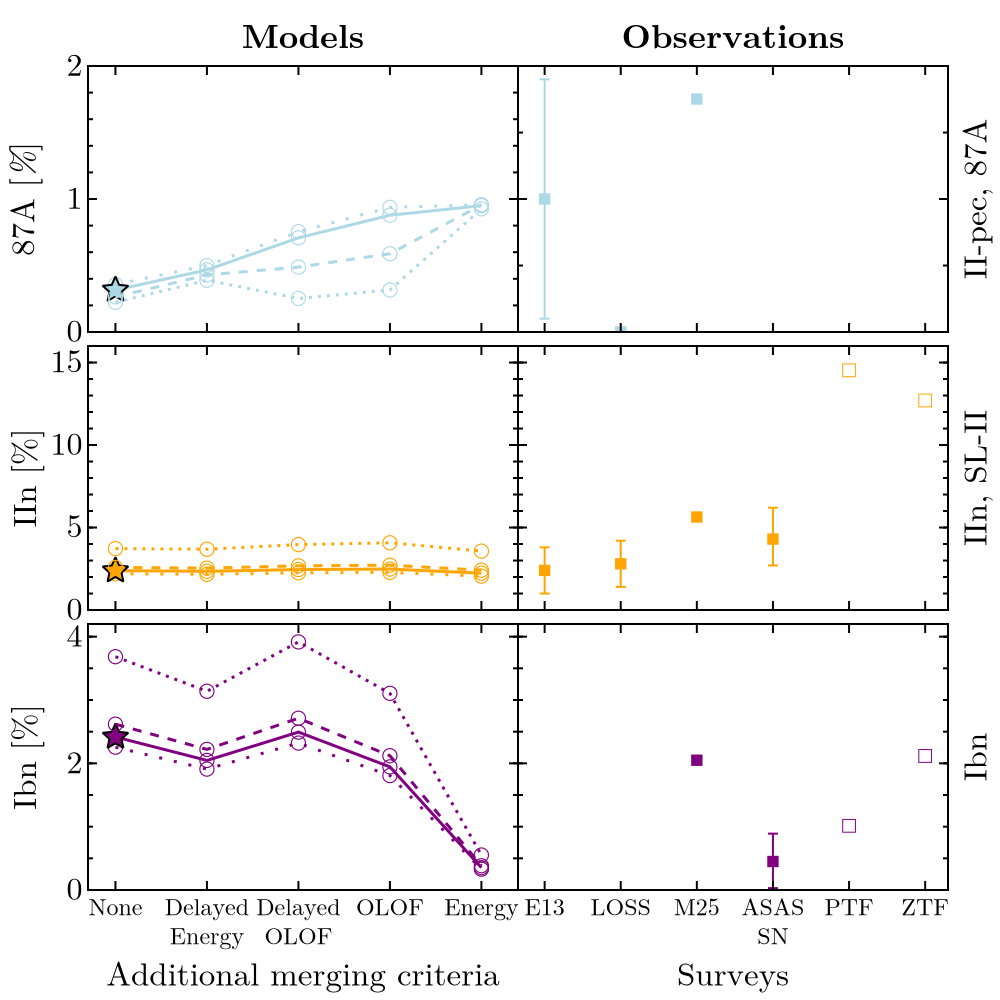

In [14]:
FIG = Figure(size=(500, 500), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "MER_CRIT" => SortedDict("X" => labval("None",-2),
                             "ERK" => labval("Delayed\nOLOF",-0) ,
                             "PA_IV" => labval("OLOF",1),
                             "PAULI" => labval("Delayed\nEnergy", -1),
                             "PABLO" => labval("Energy", 2),
                             "ALL" => labval("Always", 3)),
    "EXP_CRIT" => SortedDict("MM-M16"=> labval("Muller et al.\n2016",-1), "Ertl-N20_new"  => labval("Ertl et al.\n2020",0), "PS20" => labval("Patton & Suckhbold\n2020",2),  
                            "comp0.35" => labval(L"\xi>0.35",1)),
    "fB"       => SortedDict(1.00 => 1, 0.75 => 0.75, 0.50 => 0.50, 0.25 => 0.25, 0.00=>0.00))
label = "MER_CRIT"

obs_to_dict = Dict(
    # "Smartt" => labval("S", -2.15),
    "Eldridge"  => labval("E13", -2),
    # "LOSS_low"  => labval("L", -1.33),
    # "LOSS"      => labval("A\nLOSS", -1.15),
    "LOSS_high" => labval("LOSS",-1),
    "PTF"       => labval("PTF", 2),
    # "ZTF" => labval("1\n   ZTF", 0.),
    "ZTF2"      => labval("ZTF", 3),
    "Ma25"      => labval("M25", 0.),
    "ASAS-SN"   =>labval("ASAS\nSN", 1)
)

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_R = 1
right_panels_R = 2

yticklabelspace = 10.
ylabelpadding = 10.

# ax_bh = plot_settings( grid[1,left_panels_L],
#                 xlabel = "",
#                 ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
#                 title = "", titlesize=30,
#                 xticks = xticks,
#                 yticks= 0:20:100,
#                 ymticks= 0:10:100,
#                 xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
#                 xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
#                 ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_bsg = plot_settings( grid[1,left_panels_R],
                xlabel = "",
                ylabel =  L"\mathrm{87A} \ [%]",
                title = "Models", titlesize=17,
                xticks = xticks, 
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.2:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,# yscale = log10, 
                xticklabelrotation = 0,xlabelvisible=false, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xticklabelsvisible=false)
ax_bsg_obs = plot_settings( grid[1,right_panels_R],
                xlabel =  "",
                ylabel =  "II-pec, 87A", yaxisposition=:right,
                title = "Observations", titlesize=17,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.5:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,xlabelvisible=false, 
                xticklabelsvisible=false)
ax_int = plot_settings( grid[2,left_panels_R],
                xlabel = " ",
                ylabel =  "IIn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[2,right_panels_R],
                xlabel = " ",
                ylabel =  "IIn, SL-II", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[3,left_panels_R],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabel =  "Ibn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[3,right_panels_R],
                xlabel = "Surveys",
                ylabel =  "Ibn", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)


# ax_misc = plot_settings( grid[0,1:3],
#                 xlabel = "",
#                 ylabel =  "  ",
#                 title = "", titlesize=30,xticks = xticks,
#                 xticklabelsize = 15, yticklabelsize = 20,xlabelvisible=false, xticklabelsvisible=false, 
#                 xlabelsize = 15, ylabelsize = 22)

                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 0.5
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    # print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    # print("\n", ix_n)

    @printf("\n%10s %5s %5s %5s %5s %5s\n", "Nmerg (exp)", "X", "dO", "O", "dE", "E")
    @printf("%10s %5.2f %5.2f %5.2f %5.2f %5.2f\n", exp, 
              SN_FILE[!, "IIP_M"][ix_n[1]] + SN_FILE[!, "IIP-B_M"][ix_n[1]] + SN_FILE[!, "IIb_M"][ix_n[1]] + SN_FILE[!, "Ibc_M"][ix_n[1]] + SN_FILE[!, "Ibc-i_M"][ix_n[1]] + SN_FILE[!, "BH_M"][ix_n[1]] + SN_FILE[!, "II-i_M"][ix_n[1]],
              SN_FILE[!, "IIP_M"][ix_n[2]] + SN_FILE[!, "IIP-B_M"][ix_n[2]] + SN_FILE[!, "IIb_M"][ix_n[2]] + SN_FILE[!, "Ibc_M"][ix_n[2]] + SN_FILE[!, "Ibc-i_M"][ix_n[2]] + SN_FILE[!, "BH_M"][ix_n[2]] + SN_FILE[!, "II-i_M"][ix_n[2]],
              SN_FILE[!, "IIP_M"][ix_n[3]] + SN_FILE[!, "IIP-B_M"][ix_n[3]] + SN_FILE[!, "IIb_M"][ix_n[3]] + SN_FILE[!, "Ibc_M"][ix_n[3]] + SN_FILE[!, "Ibc-i_M"][ix_n[3]] + SN_FILE[!, "BH_M"][ix_n[3]] + SN_FILE[!, "II-i_M"][ix_n[3]],
              SN_FILE[!, "IIP_M"][ix_n[4]] + SN_FILE[!, "IIP-B_M"][ix_n[4]] + SN_FILE[!, "IIb_M"][ix_n[4]] + SN_FILE[!, "Ibc_M"][ix_n[4]] + SN_FILE[!, "Ibc-i_M"][ix_n[4]] + SN_FILE[!, "BH_M"][ix_n[4]] + SN_FILE[!, "II-i_M"][ix_n[4]],
              SN_FILE[!, "IIP_M"][ix_n[5]] + SN_FILE[!, "IIP-B_M"][ix_n[5]] + SN_FILE[!, "IIb_M"][ix_n[5]] + SN_FILE[!, "Ibc_M"][ix_n[5]] + SN_FILE[!, "Ibc-i_M"][ix_n[5]] + SN_FILE[!, "BH_M"][ix_n[5]] + SN_FILE[!, "II-i_M"][ix_n[5]],

              )

    SN2 = SN_ix

    ms = 20
    linestyles = Dict("X"=>Linestyle([0,1,5,]), "MM-S21"=>:solid, "Ertl-N20_new" =>:dash, "PS20"=>:dot )
    labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
    ls = linestyles[exp]
    show_label = false# exp=="MM-S21"
    marker = '○'
    markersize= 10
    scatterlines!(ax_bsg,   x, [SN_FILE[!, "IIP-B"][ix]+1e-10 for ix in ix_n], color=:lightblue, label = show_label ? "II-BSG" : nothing , linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int,   x, [SN_FILE[!, "II-i"][ix]+1e-10  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int_I, x, [SN_FILE[!, "Ibc-i"][ix]+1e-10 for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    # scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
    lines!(ax_II,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)

    if exp == "MM-S21"

        marker = :star5
        markersize= 15
        scatter!(ax_bsg,   [x[1]], [SN_FILE[!, "IIP-B"][ix_n[1]]+1e-10 ], color=:lightblue, label = show_label ? "II-BSG" : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int,   [x[1]], [SN_FILE[!, "II-i"][ix_n[1]]+1e-10  ], color=:orange,    label = show_label ? "II-i"   : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int_I, [x[1]], [SN_FILE[!, "Ibc-i"][ix_n[1]]+1e-10 ], color=:purple,    label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
    end 

    totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
    x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


Perley2020_ZTF = OrderedDict("label"=>"ZTF",
    "IIn"     => 0.722 * 0.142 * 100 + (0.722 * 0.035 * 100),
    #"SLSN-II" => 0.722 * 0.035 * 100,  ^^^
    "Ibn"     => 0.278 * 0.092 * 100,
    #"Ic-BL"   => 0.278 * 0.195 * 100,   vvv
    "Ibc"     => 0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100),
    #"SLSN-I"  => 0.278 * 0.126 * 100,                                ^^^
    "IIb"     => 0.722 * 0.066 * 100, 
    "II"     => 0.722 * 0.757 * 100,
)


Schulze2021_PTF = Dict("label"=>"PTF",
    "II"     =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100+(16+ 1+ 1)/888*100,
    #"SLSN-II" => (16+ 1+ 1)/888*100, ^^^
    #"Ic-BL"   =>         36/888*100,             vvv
    "Ibc"     => (46+12+60)/888*100 + 37/888*100 +36/888*100,
    #"SLSN-I"  =>         37/888*100, ^^^
    "Ibn"     =>          9/888*100,
)

function include_poisson_errors(SN_sample)

    for key in keys(SN_sample)
        key == "label" && continue 
        SN = key
        mu = SN_sample[SN]
        s = sqrt(mu)
        SN_sample[SN] = Dict(
            "mu" => mu,
            "s" => s,
        )
    end
    
end

include_poisson_errors(Perley2020_ZTF)
include_poisson_errors(Schulze2021_PTF)


valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
valpm(mu,s) = Dict("mu"=>mu, "ul"=>mu+s, "ll"=>mu-s, "s+"=>s, "s-"=>s, "s"=>s)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))


Hinds25 = OrderedDict("label"=>"ZTF2",
    "IIn"     => valpm((145+23)/(981+342)*100, sqrt(sqrt(145)^2+sqrt(23)^2)/(981+342)*100), #includes SL-II
    "Ibn"     => valpm((27+1)/(981+342)*100, sqrt(sqrt(27)^2+sqrt(1)^2)/(981+342)*100), #includes 1 Icn
    "Ibc"     => valpm((223+45+46)/(981+342)*100, sqrt(sqrt(223)^2+sqrt(45)^2+sqrt(46)^2)/(981+342)*100), #includes Ic-BL and SL-I
    "IIb"     => valpm((97)/(981+342)*100, sqrt(97)/(981+342)*100), 
    "II"      => valpm((716)/(981+342)*100, sqrt(176)/(981+342)*100)
)

Eldridge13 =  Dict("label"=>"Eldridge",
    "II"      =>  valpm(55.5+3.0, sqrt(6.6^ 2 + 1.5^ 2)),
    "IIb"     =>  valpm(12.1, 2.0),
    "IIn"     =>  valpm(2.4, 1.4),
    "Ibc"     =>  valpm(9.0+17.0, sqrt(2.7^2+3.7^2)),
    "87A"     =>  valpm(1, 0.9)
)

Smartt2009 =  Dict("label"=>"Smartt",
    "II"      =>  valpm(58.7+2.7, sqrt(8.0^ 2 + 1.7^ 2)),
    "IIb"     =>  valpm(5.4, 2.7),
    "IIn"     =>  valpm(3.8, 2.0),
    "Ibc"     =>  valpm(19.6+9.8, sqrt(3.3^2+4.5^2)),
)

Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low",
    "II"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high",
    "II"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "87A"     => valpm(0,0),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS",
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "II"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25",
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "IIP-B"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+13.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)

ASASSN25 = Dict("label"=>"ASAS-SN",
    "IIn"    => valpm(4.3, 1.9, 1.6),
    "IIP"     =>  valpm(63.2, 14.4, 13.8),
    "IIb"    => valpm(11.8, 9.9, 7.1),
    "Ibc"    => valpm(11.8+5.8+0.47+0.51, 
                      sqrt(5.2^2+4.4^2+.48^2+.55^2),
                      sqrt(4.9^2+3.7^2+.46^2+.32^2)),
    "Ibn"    => valpm(.45,.44,.42)
)



errorbar_linewidth=1
whiskerwidth=5

marker = :rect


sample =Eldridge13
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = :rect)
errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)

sample =Graur2017_LOSS_highmassGal
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker=marker)


sample =Ma25_mixed_vollim
scatter!(ax_bsg_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP-B"]["mu"]], color = :lightblue, marker=marker)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)


sample =ASASSN25
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)
errorbars!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s-"]], [sample["Ibn"]["s+"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

marker = '□'

sample =Hinds25
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker = marker)

sample =Schulze2021_PTF
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker=marker)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker=marker)



ls=:solid



            



ylims!(ax_int, 0. ,16)
ylims!(ax_int_obs, 0. ,16)
ylims!(ax_int_I, 0. ,4.2)
ylims!(ax_int_I_obs, 0. ,4.2)
ylims!(ax_bsg, 0. ,2.)
ylims!(ax_bsg_obs, 0. ,2.)
ylims!(ax_IIb, 0., 17)
ylims!(ax_IIb_obs, 0., 17)
ylims!(ax_Ibc, 16, 38)
ylims!(ax_Ibc_obs, 16, 38)
ylims!(ax_II, 44, 78)
ylims!(ax_II_obs, 44, 78)
# ylims!(ax_misc, 1,1.5)
# ylims!(ax_bh, 0, 70)
for ax in [ax_int,ax_int_I,ax_IIb,ax_Ibc,ax_II,ax_bsg]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.3,2.4)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_IIb_obs,ax_Ibc_obs,ax_II_obs, ax_bsg_obs]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.35,3.3)
end
rowgap!(grid, 7)
colgap!(grid, 0)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_new2.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
[-2, 1, 0, 2, -1]
Any[1, 4, 2, 3, 5][0.5052501956302614, 0.4918469766528589, 0.4335097453952369, 0.38858670467706213, 0.376022165743253]        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE     

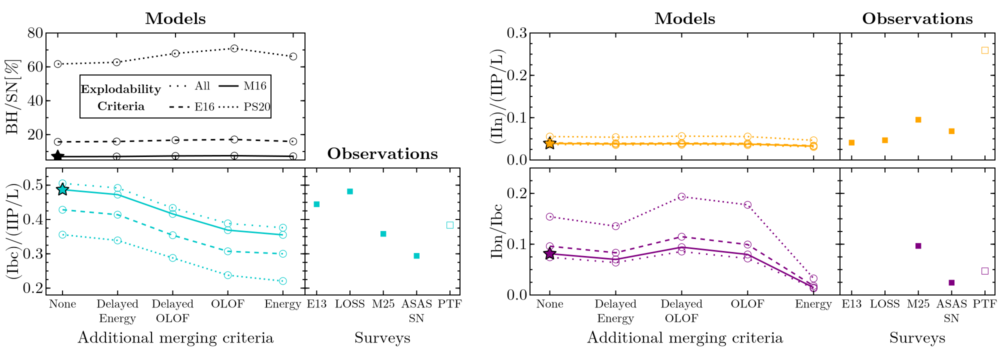

In [15]:
FIG = Figure(size=(1000, 350), figure_padding = 5)
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_L = 1:5
right_panels_L = 6:8
left_panels_R = 9:14
right_panels_R = 15:17
yticks = 0:0.1:1
ymticks = 0:0.025:1
yticklabelspace = 12.
ylabelpadding = 10.

ax_bh = plot_settings( grid[1,left_panels_L],
                xlabel = "",
                ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
                title = "Models", titlesize=17,
                xticks = xticks,
                yticks=0:20:100,
                ymticks= 0:10:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_int = plot_settings( grid[1,left_panels_R],
                xlabel = " ",
                ylabel =  "(IIn)/(IIP/L)",
                title = "Models", titlesize=17,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[1,right_panels_R],
                xlabel = " ",
                ylabel =  " ", yaxisposition=:right,
                title = "Observations", titlesize=17,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[2,left_panels_R],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabel =  "Ibn/Ibc",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[2,right_panels_R],
                xlabel = "Surveys",
                ylabel =  "", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)


ax_II = plot_settings( grid[2,left_panels_L],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  "(Ibc)/(IIP/L)",  
                title = " ", titlesize=17,
                xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = yticks,
                ymticks=ymticks, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[2,right_panels_L],
                xlabel = "Surveys",
                ylabel =  "", yaxisposition=:right,
                xticks = xticks_obs,
                title = "Observations", titlesize=17,
                yticklabelpad=yticklabelpad,
                ymticks=ymticks, 
                yticks = yticks,
                yticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)



                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 1
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    print("\n", ix_n)

    SN2 = SN_ix

    ms = 20
    linestyles = Dict("X"=>Linestyle([0,1,5,]), "MM-S21"=>:solid, "Ertl-N20_new" =>:dash, "PS20"=>:dot )
    labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
    ls = linestyles[exp]
    show_label = false# exp=="MM-S21"
    marker = '○'
    markersize= 10
    scatterlines!(ax_II,    x, [ (SN_FILE.Ibc[ix] ./ SN_FILE.IIP[ix] .+ 1e-10 )        for ix in ix_n], color=color_coding["1"],       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int,   x, [(SN_FILE[!, "II-i"][ix]  ./ SN_FILE.IIP[ix] .+ 1e-10)  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int_I,   x, [(SN_FILE[!, "Ibc-i"][ix]  ./ SN_FILE.Ibc[ix] .+ 1e-10) for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
    lines!(ax_bh,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)



    if exp == "MM-S21"

        marker = :star5
        markersize= 15
        scatter!(ax_II,    [x[1]], [SN_FILE.Ibc[ix_n[1]] ./ SN_FILE.IIP[ix_n[1]]],           color=color_coding["1"],label = show_label ? "IIP"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int,   [x[1]], [SN_FILE[!, "II-i"][ix_n[1]]  ./ SN_FILE.IIP[ix_n[1]]  ], color=:orange,          label = show_label ? "II-i"   : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int_I, [x[1]], [SN_FILE[!, "Ibc-i"][ix_n[1]] ./ SN_FILE.Ibc[ix_n[1]]  ], color=:purple,          label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_bh,    [x[1]], [SN_FILE[!, "BH"][ix_n[1]] ],                             color=:black,           label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
    end 


    print([ (SN_FILE.Ibc[ix] ./ SN_FILE.IIP[ix] .+ 1e-10 )        for ix in ix_n])
    totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
    x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


errorbar_linewidth=1
whiskerwidth=5

marker = :rect



sample =Eldridge13
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker = :rect)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker = :rect)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

 
sample =Graur2017_LOSS_highmassGal
# errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker=marker)
 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["IIP"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["IIP"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =ASASSN25
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["IIP"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["IIP"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

marker = '□'

sample =Hinds25
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker =marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker = marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker = marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Schulze2021_PTF
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker=marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


ls=:solid
axislegend(ax_bh,"Explodability\nCriteria", nbanks=2, position=:cc, rowgap =1, colgap =4,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,1,1))




ylims!(ax_int, 0. ,.3)
ylims!(ax_int_obs, 0. ,.3)
ylims!(ax_int_I, 0. ,.25)
ylims!(ax_int_I_obs, 0. ,.25)
ylims!(ax_II,     0.18, 0.55)
ylims!(ax_II_obs, 0.18, 0.55)
# ylims!(ax_misc, 1,1.5)
ylims!(ax_bh, 5, 80)
for ax in [ax_int,ax_int_I,ax_II]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.3,2.4)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_II_obs,]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.35,2.3)
end
rowgap!(grid, -20)
colgap!(grid, 0)
colgap!(grid, 8, 30)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_fracs.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



        1 - crits:         X         X      CORE         X, fB  0.75, pows:  0.00  0.00
        3 - crits:     PA_IV         X      CORE         X, fB  0.75, pows:  0.00  0.00
        2 - crits:       ERK         X      CORE         X, fB  0.75, pows:  0.00  0.00
        5 - crits:     PABLO         X      CORE         X, fB  0.75, pows:  0.00  0.00
        4 - crits:     PAULI         X      CORE         X, fB  0.75, pows:  0.00  0.00
Any[1, 3, 2, 5, 4]
[-2, 1, 0, 2, -1]
Any[1, 4, 2, 3, 5][0.5052501956302614, 0.4918469766528589, 0.4335097453952369, 0.38858670467706213, 0.376022165743253]        6 - crits:         X    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        8 - crits:     PA_IV    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        7 - crits:       ERK    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
       10 - crits:     PABLO    MM-S21      CORE         X, fB  0.75, pows:  0.00  0.00
        9 - crits:     PAULI    MM-S21      CORE     

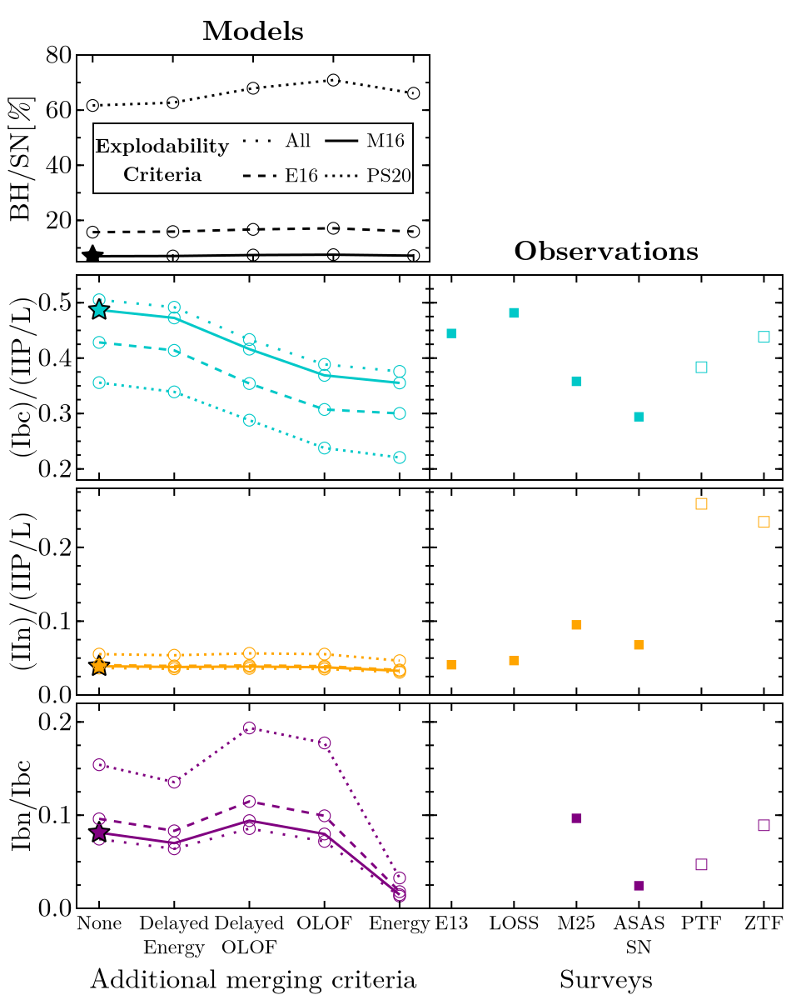

In [17]:
FIG = Figure(size=(475, 600), figure_padding = 5)
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_L = 1:4
right_panels_L = 5:8
left_panels_R = 9:14
right_panels_R = 15:17
left_panels_R = left_panels_L
right_panels_R = right_panels_L
yticks = 0:0.1:1
ymticks = 0:0.025:1
yticklabelspace = 12.
ylabelpadding = 10.

ax_bh = plot_settings( grid[1,left_panels_L],
                xlabel = "",
                ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
                title = "Models", titlesize=17,
                xticks = xticks,
                yticks=0:20:100,
                ymticks= 0:10:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_int = plot_settings( grid[3,left_panels_R],
                xlabel = " ",
                ylabel =  "(IIn)/(IIP/L)",
                title = "", titlesize=17,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[3,right_panels_R],
                xlabel = " ",
                ylabel =  " ", yaxisposition=:right,
                title = "", titlesize=17,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[4,left_panels_R],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabel =  "Ibn/Ibc",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[4,right_panels_R],
                xlabel = "Surveys",
                ylabel =  "", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =yticks, 
                yticklabelpad=yticklabelpad,
                ymticks=ymticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)


ax_II = plot_settings( grid[2,left_panels_L],
                xlabel = L"\mathrm{Additional \ merging \ criteria}",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  "(Ibc)/(IIP/L)",  
                title = " ", titlesize=17,
                xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = yticks,
                ymticks=ymticks, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,                                xlabelvisible=false,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[2,right_panels_L],
                xlabel = "Surveys",
                ylabel =  "", yaxisposition=:right,
                xticks = xticks_obs,
                title = "Observations", titlesize=17,
                yticklabelpad=yticklabelpad,
                ymticks=ymticks, 
                yticks = yticks,
                yticklabelsvisible=false,                 xlabelvisible=false,xticklabelsvisible=false,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)



                
                alpha = 0.3
                color_coding = Dict()
                color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
                color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
                color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
                color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
                color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
                color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
                

                alpha = 1
                color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
                color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
                color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
                color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in ["X", "MM-S21",  "Ertl-N20_new", "PS20"]         
    MER_CRIT =   ["X", "PA_IV", "ERK", "PABLO", "PAULI"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    print("\n", ix_n)

    SN2 = SN_ix

    ms = 20
    linestyles = Dict("X"=>Linestyle([0,1,5,]), "MM-S21"=>:solid, "Ertl-N20_new" =>:dash, "PS20"=>:dot )
    labels = Dict("X"=>"All", "MM-S21"=>L"\mathrm{M16}", "Ertl-N20_new" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
    ls = linestyles[exp]
    show_label = false# exp=="MM-S21"
    marker = '○'
    markersize= 10
    scatterlines!(ax_II,    x, [ (SN_FILE.Ibc[ix] ./ SN_FILE.IIP[ix] .+ 1e-10 )        for ix in ix_n], color=color_coding["1"],       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int,   x, [(SN_FILE[!, "II-i"][ix]  ./ SN_FILE.IIP[ix] .+ 1e-10)  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_int_I,   x, [(SN_FILE[!, "Ibc-i"][ix]  ./ SN_FILE.Ibc[ix] .+ 1e-10) for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
    scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
    lines!(ax_bh,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)



    if exp == "MM-S21"

        marker = :star5
        markersize= 15
        scatter!(ax_II,    [x[1]], [SN_FILE.Ibc[ix_n[1]] ./ SN_FILE.IIP[ix_n[1]]],           color=color_coding["1"],label = show_label ? "IIP"    : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int,   [x[1]], [SN_FILE[!, "II-i"][ix_n[1]]  ./ SN_FILE.IIP[ix_n[1]]  ], color=:orange,          label = show_label ? "II-i"   : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_int_I, [x[1]], [SN_FILE[!, "Ibc-i"][ix_n[1]] ./ SN_FILE.Ibc[ix_n[1]]  ], color=:purple,          label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
        scatter!(ax_bh,    [x[1]], [SN_FILE[!, "BH"][ix_n[1]] ],                             color=:black,           label = show_label ? "Ibc-i"  : nothing, marker = marker, markersize = markersize, strokecolor = :black, strokewidth = 1)
    end 


    print([ (SN_FILE.Ibc[ix] ./ SN_FILE.IIP[ix] .+ 1e-10 )        for ix in ix_n])
    totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
    x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


errorbar_linewidth=1
whiskerwidth=5

marker = :rect



sample =Eldridge13
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker = :rect)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker = :rect)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

 
sample =Graur2017_LOSS_highmassGal
# errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker=marker)
 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["IIP"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["IIP"]["mu"]], color = :orange, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =ASASSN25
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["IIP"]["mu"]], color = color_coding["1"], marker=marker)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["IIP"]["mu"]], color = :orange, marker=marker)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)

marker = '□'

sample =Hinds25
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker =marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker = marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker = marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)

sample =Schulze2021_PTF
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]]./[sample["II"]["mu"]], color = color_coding["1"], marker=marker)
# errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]]./[sample["II"]["mu"]], color = :orange, marker=marker)
# errorbars!( ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_I_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]]./[sample["Ibc"]["mu"]], color = :purple, marker=marker)
# errorbars!( ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["IIn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


ls=:solid
axislegend(ax_bh,"Explodability\nCriteria", nbanks=2, position=:cc, rowgap =1, colgap =4,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,1,1))




ylims!(ax_int, 0. ,.28)
ylims!(ax_int_obs, 0. ,.28)
ylims!(ax_int_I, 0. ,.22)
ylims!(ax_int_I_obs, 0. ,.22)
ylims!(ax_II,     0.18, 0.55)
ylims!(ax_II_obs, 0.18, 0.55)
# ylims!(ax_misc, 1,1.5)
ylims!(ax_bh, 5, 80)
for ax in [ax_int,ax_int_I,ax_II]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.3,2.4)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_II_obs,]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -2.35,3.3)
end
rowgap!(grid, 5)
rowgap!(grid, 1, -20)
colgap!(grid, 0)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_fracs.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



In [ ]:
FIG = Figure(size=(500, 300), figure_padding = 0)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "EXP_CRIT" => SortedDict("X"=>labval("None",-2), "MM"=> labval("M16",-1), "Ertl"  => labval("E16",0), "PS20" => labval("PS20",1),  ) )

label = "EXP_CRIT"

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 15
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels = 1
right_panels = 2

yticklabelspace = 10.
ylabelpadding = 10.
xticklabelspace = 10.
xlabelpadding = 12.

ax_bh = plot_settings( grid[1,right_panels],

    xlabel = "",
    ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
    title = "", titlesize=30,
    xticks = xticks,xlabelvisible=false, xticklabelsvisible=false, 
    yticks=  0.:10:100,
    ymticks= 0.:5:100,
    xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,  
    yticklabelpad=yticklabelpad,
    ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
    xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II = plot_settings( grid[1,left_panels],
    xlabel = "",
    ylabel =  "II [%]",
    title = "", titlesize=30,
    xticks = xticks,xlabelvisible=false, xticklabelsvisible=false, 
    yticks=  .0:5:100,
    ymticks= .0:1:100,
    xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,  
    yticklabelpad=yticklabelpad,
    ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
    xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_Ibc = plot_settings( grid[2,left_panels],
    xlabel = "Explodability Criteria",
    ylabel =  "Ibc [%]",
    title = "", titlesize=30,
    xticks = xticks,
    yticks=  .0:5:100,
    ymticks= .0:1:100,
    xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,  
    yticklabelpad=yticklabelpad,
    ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
    xlabelpadding=xlabelpadding,xticklabelspace=xticklabelspace,
    xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_IIb = plot_settings( grid[2,right_panels],
    xlabel = "Explodability Criteria",
    ylabel =  "IIb [%]",
    title = "", titlesize=30,
    xticks = xticks,
    yticks=  0.:1:100,
    ymticks= 0.:0.5:100,
    xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,  
    yticklabelpad=yticklabelpad,
    ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
    xlabelpadding=xlabelpadding,xticklabelspace=xticklabelspace,
    xlabelsize = xlabelsize, ylabelsize = ylabelsize)


    
alpha = 0.3
color_coding = Dict()
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 


alpha = 0.5
color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM", "Ertl", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

MER_CRIT =   "X"
EXP_CRIT = ["X", "MM", "Ertl", "PS20"]
MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
KICKS = [Inf]
fBs =      [0.75]
Pow_m =    [alpha_m]
Pow_p =    Pow_p
Pow_q =    Pow_q


SN_ix=[ ] 
SN_subix = []
for exp in EXP_CRIT 
    for mer_eol in MER_EOL 
        for mer_dm in MER_dM 
            for fB in fBs

                for entry in range(1,length(SN_FILE.EXP_CRIT))
                    SN_FILE.MER_CRIT[entry] != MER_CRIT ? continue : nothing 
                    SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                    SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                    SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                    SN_FILE.fB[entry] != fB ? continue : nothing 


                    SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                    
                    
                    @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                            entry, MER_CRIT, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                end
            end

        end 
    end 
end 
                                
print(SN_ix)
x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
print("\n", x_og)
ix_og = SN_ix
x = x_og[sortperm( x_og )]
ix_n =  ix_og[sortperm( x_og )]
print("\n", ix_n)

SN2 = SN_ix
set_theme!(theme_latexfonts())

ms = 20
linestyles = Dict("MM"=>:solid, "Ertl" =>:dash, "PS20"=>:dot )
labels = Dict("MM"=>L"\mathrm{M16}", "Ertl" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
ls = :solid
show_label = true 
marker = :cross
markersize= 10
n_s = SN_FILE.sn_s./SN_FILE.sn_tot
scatterlines!(ax_II,    x, [SN_FILE[!, "IIP_S"][ix]/n_s[ix]         for ix in ix_n], color=:red,       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_Ibc,    x, [SN_FILE[!, "Ibc_S"][ix]/n_s[ix]       for ix in ix_n], color=:blue,      label = show_label ? "Ibc" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_IIb,    x, [SN_FILE[!, "IIb_S"][ix]/n_s[ix]       for ix in ix_n], color=:green,     label = show_label ? "IIb" : nothing , linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_bh,    x, [SN_FILE[!,  "BH_S"][ix]/n_s[ix]  for ix in ix_n], color=:black,     label = show_label ? "BH" : nothing , linestyle=ls, marker = marker, markersize = markersize)

# ylims!(ax_misc, 1,1.5)
ylims!(ax_bh, 0, 65)
ylims!(ax_II, 73, 92)
ylims!(ax_Ibc, 9, 23)
ylims!(ax_IIb, 0, 3.5)
for ax in [ax_bh, ax_Ibc, ax_II, ax_IIb]
    xlims!(ax, -2.2, 1.2)
end
rowgap!(grid, 5)
colgap!(grid, 10)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"

outfilename = @sprintf("SN_stats_single.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



In [ ]:
FIG = Figure(size=(500, 800), figure_padding = 0)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
label_to_dict = Dict(
    "MER_CRIT" => SortedDict("X" => labval("Min.M+M16",0)),
    "EXP_CRIT" => SortedDict("MM"=> labval("Muller et al.\n2016",-1), "Ertl"  => labval("Ertl et al.\n2019",0), "PS20" => labval("Patton & Suckhbold\n2020",2),  
                            "comp0.35" => labval(L"\xi>0.35",1)),
    "fB"       => SortedDict(1.00 => 1, 0.75 => 0.75, 0.50 => 0.50, 0.25 => 0.25, 0.00=>0.00))
obs_to_dict = Dict(
    "LOSS_low" => labval("1", -1.3),
    "LOSS_high" => labval("3",-0.7),
    "LOSS" => labval("2\nLOSS", -1),
    "PTF" => labval("PTF", 0),
    "ZTF" => labval("ZTF", 1),
    "Ma25" => labval("Mixed", 2),
)
label = "MER_CRIT"

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels = 1
right_panels = 2:3
left_panels2 =  4
right_panels2 = 5:6

yticklabelspace = 10.
ylabelpadding = 10.

ax_bh = plot_settings( grid[1,left_panels],
                xlabel = "",
                ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
                title = "", titlesize=30,
                xticks = xticks,
                yticks= yticks = [1,10,100],
                ymticks= union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, yscale=log10,
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_bsg = plot_settings( grid[4,left_panels2],
                xlabel = "",
                ylabel =  L"\mathrm{II-BSG} \ [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                yticks= ([1,10], [L"%$(t)" for t in [1,10]]),#(0.:10:100),
                yticklabelpad=yticklabelpad,
                ymticks=union(.1:.1:1, 1:1:10, 10:10:100),#(0.:5:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, yscale = log10, 
                xticklabelrotation = 0,
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_bsg_obs = plot_settings( grid[4,right_panels2],
                xlabel =  "",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks= ([1,10], [L"%$(t)" for t in [1,10]]),#(0.:10:100),
                yticklabelpad=yticklabelpad,
                ymticks=union(.1:.1:1, 1:1:10, 10:10:100),#(0.:5:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0 )
ax_int = plot_settings( grid[2,left_panels2],
                xlabel = " ",
                ylabel =  "II-i [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_int_obs = plot_settings( grid[2,right_panels2],
                xlabel = " ",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax_int_I = plot_settings( grid[3,left_panels2],
                xlabel = L"\mathrm{Models}",
                ylabel =  "Ibc-i [%]",
                title = "", titlesize=30,
                xticks = xticks, xlabelvisible=false,xticklabelsvisible=false,
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_int_I_obs = plot_settings( grid[3,right_panels2],
                xlabel = "Observations from \n Surveys",
                ylabel =  " ",
                title = "", titlesize=30,
                yticklabelsvisible=false, xlabelvisible=false,xticklabelsvisible=false,
                xticks = xticks_obs,
                yticks =(0.:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax_IIb = plot_settings( grid[4,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{IIb} \ [%]",
                yticks = (0.:5:100),#([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,#yscale=log10,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                title = "", titlesize=30,                xticks = xticks, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_IIb_obs = plot_settings( grid[4,right_panels],
                xlabel = "",
                ylabel = "",
                title = "", titlesize=30,
                yticks = (0.:5:100),#([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,#yscale=log10,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticks = xticks_obs,
                yticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,  
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_Ibc = plot_settings( grid[3,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{Ibc} \ [%]",
                title = "", titlesize=30, xticks = xticks, yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_Ibc_obs = plot_settings( grid[3,right_panels],
                xlabel = "",
                ylabel = "",
                xticks = xticks_obs,
                title = "", titlesize=30,
                ymticks=(0.:5:100), 
                yticklabelsvisible=false, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax_II = plot_settings( grid[2,left_panels],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  L"\mathrm{II} \ [%]",  
                title = "", titlesize=30,xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                ymticks=(0.:5:100), 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_II_obs = plot_settings( grid[2,right_panels],
                xlabel = "",
                ylabel = "",  
                xticks = xticks_obs,
                title = "", titlesize=30, yticklabelpad=yticklabelpad,
                ymticks=(0.:5:100), 
                yticks = (0.:10:100, [L"%$(str_significant(t, 2))" for t in 0.:10.:100.]),
                yticklabelsvisible=false,xlabelvisible=false, xticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)


# ax_misc = plot_settings( grid[0,1:3],
#                 xlabel = "",
#                 ylabel =  "  ",
#                 title = "", titlesize=30,xticks = xticks,
#                 xticklabelsize = 15, yticklabelsize = 20,xlabelvisible=false, xticklabelsvisible=false, 
#                 xlabelsize = 15, ylabelsize = 22)

                
alpha = 0.3
color_coding = Dict()
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 


alpha = 0.5
color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM", "Ertl", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.00, 0.25, 0.50, 0.75, 1.00]
Pow_m =    [alpha_m]
Pow_p =    [0, alpha_p, alpha_p + stdev_p, alpha_p - stdev_p]
Pow_q =    [0, alpha_q, alpha_q + stdev_q, alpha_q - stdev_q]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/tot_SN_CORR.dat", DataFrame, delim=" ", ignorerepeated=true )

for   exp in [ "MM" ]         
    MER_CRIT =   ["X"]
    # EXP_CRIT = ["Ertl"]#["MM", "Ertl", "PS20", "comp0.35"]
    MER_EOL =  ["CORE"]#["TOTAL", "CORE", "ANALYTIC"]
    MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
    KICKS = [Inf]
    fBs =      [0.75]
    Pow_m =    [alpha_m]
    Pow_p =    Pow_p
    Pow_q =    Pow_q
    
    
    SN_ix=[ ] 
    SN_subix = []
    for m_crit in MER_CRIT 
        for mer_eol in MER_EOL 
            for mer_dm in MER_dM 
                for fB in fBs

                    for entry in range(1,length(SN_FILE.EXP_CRIT))
                        SN_FILE.MER_CRIT[entry] != m_crit ? continue : nothing 
                        SN_FILE.EXP_CRIT[entry] != exp ? continue : nothing 
                        SN_FILE.MER_EOL[entry] != mer_eol ? continue : nothing 
                        SN_FILE.MER_dM[entry] != mer_dm ? continue : nothing 
                        SN_FILE.fB[entry] != fB ? continue : nothing 


                        SN_FILE.pow_logP[entry] + SN_FILE.pow_q[entry] == 0 ?  push!(SN_ix, entry) : push!(SN_subix, entry) 
                        
                        
                        @printf("%9d - crits: %9s %9s %9s %9s, fB %5.2f, pows: %5.2f %5.2f\n",
                                entry, m_crit, exp, mer_eol, mer_dm, fB, SN_FILE.pow_logP[entry], SN_FILE.pow_q[entry])


                    end
                end

            end 
        end 
    end 
                                
print(SN_ix)
x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
print("\n", x_og)
ix_og = SN_ix
x = x_og[sortperm( x_og )]
ix_n =  ix_og[sortperm( x_og )]
print("\n", ix_n)

SN2 = SN_ix
set_theme!(theme_latexfonts())

ms = 20
linestyles = Dict("X"=>:solid, "MM"=>:dash, "Ertl" =>:dashdotdot, "PS20"=>:dot )
labels = Dict("X"=>"All", "MM"=>L"\mathrm{M16}", "Ertl" =>L"\mathrm{E16}", "PS20"=>L"\mathrm{PS20}" )
ls = linestyles[exp]
show_label = exp=="MM"
marker = :circle
markersize= 15
scatterlines!(ax_II,    x, [SN_FILE.IIP[ix]+1e-10         for ix in ix_n], color=:red,       label = show_label ? "IIP" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_bsg,   x, [SN_FILE[!, "IIP-B"][ix]+1e-10 for ix in ix_n], color=:lightblue, label = show_label ? "II-BSG" : nothing , linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_Ibc,   x, [SN_FILE.Ibc[ix]+1e-10         for ix in ix_n], color=:blue,      label = show_label ? "Ibc" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_IIb,   x, [SN_FILE.IIb[ix]+1e-10         for ix in ix_n], color=:green,     label = show_label ? "IIb" : nothing , linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_int,   x, [SN_FILE[!, "II-i"][ix]+1e-10  for ix in ix_n], color=:orange,    label = show_label ? "II-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_int_I,   x, [SN_FILE[!, "Ibc-i"][ix]+1e-10 for ix in ix_n], color=:purple,  label = show_label ? "Ibc-i" : nothing, linestyle=ls, marker = marker, markersize = markersize)
scatterlines!(ax_bh,    x, [SN_FILE[!, "BH"][ix]+1e-10    for ix in ix_n], color=:black,     label = nothing, linestyle=ls, marker = marker, markersize = markersize)
markerS = :hline
# scatter!(ax_II,    [0.5], [100*SN_FILE.IIP_S[ix] ./ (SN_FILE.IIP_S[ix] .+ SN_FILE.IIb_S[ix] .+ SN_FILE.Ibc_S[ix]) for ix in ix_n], color=:red,   marker = markerS, markersize = markersize)
# scatter!(ax_Ibc,   [0.5], [100*SN_FILE.Ibc_S[ix] ./ (SN_FILE.IIP_S[ix] .+ SN_FILE.IIb_S[ix] .+ SN_FILE.Ibc_S[ix]) for ix in ix_n], color=:blue,  marker = markerS, markersize = markersize)
# scatter!(ax_IIb,   [0.5], [100*SN_FILE.IIb_S[ix] ./ (SN_FILE.IIP_S[ix] .+ SN_FILE.IIb_S[ix] .+ SN_FILE.Ibc_S[ix]) for ix in ix_n], color=:green, marker = markerS, markersize = markersize)

lines!(ax_bh,    [-1,-1], [100,100], color=:black,     label = labels[exp], linestyle=ls)


totII = SN_FILE.IIP+SN_FILE[!, "IIP-B"]
x = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix]


end


Perley2020_ZTF = OrderedDict("label"=>"ZTF",
    "IIn"     => 0.722 * 0.142 * 100 + (0.722 * 0.035 * 100),
    #"SLSN-II" => 0.722 * 0.035 * 100,  ^^^
    "Ibn"     => 0.278 * 0.092 * 100,
    #"Ic-BL"   => 0.278 * 0.195 * 100,   vvv
    "Ibc"     => 0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100),
    #"SLSN-I"  => 0.278 * 0.126 * 100,                                ^^^
    "IIb"     => 0.722 * 0.066 * 100, 
    "IIP"     => 0.722 * 0.757 * 100,
)

Schulze2021_PTF = Dict("label"=>"PTF",
    "IIP"     =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100+(16+ 1+ 1)/888*100,
    #"SLSN-II" => (16+ 1+ 1)/888*100, ^^^
    #"Ic-BL"   =>         36/888*100,             vvv
    "Ibc"     => (46+12+60)/888*100 + 37/888*100 +36/888*100,
    #"SLSN-I"  =>         37/888*100, ^^^
    "Ibn"     =>          9/888*100,
)

valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))
Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low",
    "II"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high",
    "II"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS",
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "II"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25",
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "IIP-B"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+12.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)



errorbar_linewidth=1
whiskerwidth=5

sample =Graur2017_LOSS_lowmassGal
marker = '■'  
markersize=10
scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]],  color = :red, marker = marker, markersize=markersize)
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
errorbars!( ax_int_obs,[obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker, markersize=markersize)
errorbars!( ax_bsg_obs,[obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s-"]], [sample["87A"]["s+"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker = marker, markersize=markersize)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker, markersize=markersize)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = marker, markersize=markersize)
 
sample =Graur2017_LOSS_highmassGal
errorbars!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s-"]], [sample["II"]["s+"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = marker, markersize=markersize)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s-"]], [sample["IIn"]["s+"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker, markersize=markersize)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s-"]], [sample["IIb"]["s+"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker, markersize=markersize)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s-"]], [sample["Ibc"]["s+"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = marker, markersize=markersize)

sample =Shivvers2017_LOSS
errorbars!( ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], [sample["II"]["s"]], [sample["II"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(   ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["II"]["mu"]], color = :red, marker = marker, markersize=markersize)
errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker, markersize=markersize)
errorbars!(ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], [sample["87A"]["s"]], [sample["87A"]["s"]], color = :lightblue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_bsg_obs, [obs_to_dict[sample["label"]]["val"]], [sample["87A"]["mu"]], color = :lightblue, marker = marker, markersize=markersize)
errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], [sample["IIb"]["s"]], [sample["IIb"]["s"]], color = :green, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker, markersize=markersize)
errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], [sample["Ibc"]["s"]], [sample["Ibc"]["s"]], color = :blue, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(  ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = marker, markersize=markersize)
 
marker = '□' 
sample =Schulze2021_PTF
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]], color = :red, marker = marker, markersize=markersize)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]], color = :orange, marker = marker, markersize=markersize)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]], color = :purple, marker = marker, markersize=markersize)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]], color = :green, marker = marker, markersize=markersize)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]], color = :blue, marker = marker, markersize=markersize)
sample =Perley2020_ZTF
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]], color = :red, marker = marker, markersize=markersize)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]], color = :orange, marker = marker, markersize=markersize)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]], color = :purple, marker = marker, markersize=markersize)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]], color = :green, marker = marker, markersize=markersize)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]], color = :blue, marker = marker, markersize=markersize)

marker = '■' 

sample =Ma25_mixed_vollim
scatter!(ax_II_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], color = :red, marker = marker, markersize=markersize)
scatter!(ax_bsg_obs,  [obs_to_dict[sample["label"]]["val"]], [sample["IIP-B"]["mu"]], color = :lightblue, marker = marker, markersize=markersize)
# errorbars!(ax_II_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIP"]["mu"]], [sample["IIP"]["s"]], [sample["IIP"]["s"]], color = :red, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], color = :orange, marker = marker, markersize=markersize)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIn"]["mu"]], [sample["IIn"]["s"]], [sample["IIn"]["s"]], color = :orange, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_int_I_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], color = :purple, marker = marker, markersize=markersize)
# errorbars!(ax_int_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["IIb"]["mu"]], color = :green, marker = marker, markersize=markersize)
# errorbars!(ax_IIb_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
scatter!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibc"]["mu"]], color = :blue, marker = marker, markersize=markersize)
# errorbars!(ax_Ibc_obs, [obs_to_dict[sample["label"]]["val"]], [sample["Ibn"]["mu"]], [sample["Ibn"]["s"]], [sample["Ibn"]["s"]], color = :purple, linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)


ls=:solid
scatter!(ax_int_obs,   [-5, -5], [1e-99,1e-99], color=:orange, label = "IIn\nSL-II", marker = :rect)
scatter!(ax_int_I_obs, [-5, -5], [1e-99,1e-99], color=:purple, label = "Ibn", marker = :rect)
scatter!(ax_bsg_obs,   [-5, -5], [1e-99,1e-99], color=:lightblue, label = "87A", marker = :rect)



# axislegend(ax_II,nbanks=1, position=:lt)
# axislegend(ax_IIb,nbanks=1, position=:lt)
# axislegend(ax_int,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
# axislegend(ax_int_I,nbanks=3, position=:lt, rowgap =0, colgap =19, 
#                     labelsize=12, framevisible = false)
axislegend(ax_int_obs,nbanks=1, position=:cb, rowgap =0, colgap =0, labelsize=12, framevisible = true,   framealpha =0.5)
axislegend(ax_int_I_obs,nbanks=1, position=:lt, rowgap =0, colgap =0, labelsize=12, framevisible = true, framealpha =0.5)
axislegend(ax_bsg_obs,nbanks=2, position=:rt, rowgap =0, colgap =0, labelsize=12, framevisible = true,  framealpha =0.5)
# axislegend(ax_bh,"Explodability\nCriteria", nbanks=2, position=:cc, rowgap =-5, colgap =2,titlesize=12, labelsize=12, framevisible = true,
#             showtitle=true, titleposition=:left, padding=(1,1,-1,-1))
# axislegend(ax_Ibc,nbanks=1, position=:lb)




ylims!(ax_int, 0. ,17)
ylims!(ax_int_obs, 0. ,17)
ylims!(ax_int_I, 0. ,4.9)
ylims!(ax_int_I_obs, 0. ,4.9)
ylims!(ax_bsg, 0.2 ,30)
ylims!(ax_bsg_obs, 0.2 ,30)
ylims!(ax_IIb, 0., 19)
ylims!(ax_IIb_obs, 0., 19)
ylims!(ax_Ibc, 5, 38)
ylims!(ax_Ibc_obs, 5, 38)
ylims!(ax_II, 42, 78)
ylims!(ax_II_obs, 42, 78)
# ylims!(ax_misc, 1,1.5)
ylims!(ax_bh, 2, 140)
for ax in [ax_int,ax_int_I,ax_IIb,ax_Ibc,ax_II,ax_bh,ax_bsg]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -0.1, 0.1)
end
for ax in [ax_int_obs,ax_int_I_obs,ax_IIb_obs,ax_Ibc_obs,ax_II_obs, ax_bsg_obs]
    #xlims!(ax, -2.25,2.25)
    xlims!(ax, -1.7,2.6)
end
rowgap!(grid, 15)
colgap!(grid, 3, 15)
colgap!(grid, 1, 0)
colgap!(grid, 2, 0)
colgap!(grid, 4, 0)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"

outfilename = @sprintf("SN_stats_small.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



# Data Analysis



In [2]:
include(include_dir*"SN_reader_MW.jl")

MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
EXP_CRIT =  "MM-S21" # "MM-S21"  #"Ertl-N20_new" #  "PS20"
KICKS = Inf

# @printf("loading models...")
MODELS = predict_SN_from_each_model(
     MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS, EXP_CRIT, KICKS)

f_B = 0.75
IMF_exponent = alpha_m 
P_exponent   = 0#alpha_p-stdev_p
q_exponent   = 0#alpha_q-stdev_q
@printf("performing popsynth...\n")
MODELS, SINGLES, total_SNe = do_SN_popsynth(MERGER_CRITERION, MERGER_EOL, MERGER_MASSLOSS, EXP_CRIT, 
                                            IMF_exponent, P_exponent, q_exponent, 
                                            :custom, f_B, MODELS=MODELS, WRITE_TO_FILE=false)


MODELS, SN_DATA, BH_binaries = reorganize_SN_data(MODELS, f_B, EXP_CRIT, IMF_exponent,  total_SNe)

#      which |     IIP   IIP-B     IIb     Ibc    II-i   Ibc-i (     BH)
#          1 |    4.60    0.00    1.19   20.06    2.19    2.37 (   1.77) |   30.40
#          2 |   15.91    0.00    0.78    2.92    0.05    0.00 (   0.99) |   19.66
#          M |   24.24    0.32    1.06    3.82    0.14    0.00 (   2.66) |   29.58
#          S |   16.33    0.00    1.04    2.99    0.00    0.00 (   1.56) |   20.36
#      TOTAL |   61.08    0.32    4.07   29.79    2.38    2.37 (   6.98)
# Placing non-interacting systems inside single-stars.
# 1-MT   0.10   0.00   1.10  17.13   2.19   2.37 :  1.62 |  22.88
# 2-MT  14.15   0.00   0.56   1.67   0.05   0.00 :  0.59 |  16.43
#    M  24.24   0.32   1.06   3.82   0.14   0.00 :  2.66 |  29.58
# S+NI  22.58   0.00   1.36   7.17   0.00   0.00 :  2.12 |  31.11


Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Reading & cleaning single-star CORR files...done!
Building Case BC interpolator (PythonCall)...Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Building merger Mi +f_acc -> Mco, BSG interpolators: Retrieving data ...building interpolators...done!
Building merger/partial stripped outcome -> core He dep. Retrieving data ...Building interpolation library...done!
Building Explosion criteria......PS20...M16-E16 - imported CC grids, explodability files and interpolants
Reading Master CORR file /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/Data/Models_BG/master_CORR.hdf5 ...  done
Scanning logMs
2.00 
will_it_explode reported  482 Warnings
performing popsynth...
     which |     IIP   IIP-B     IIb     Ibc    II-i   Ibc-i (     BH)
         1 |    4.60    0.00    1.19   20.06    2.19    2.37 (   1.77) |   30.40
         2 |   15.91    0.00    0.78    2.92    0.05    0.00 (   0.99) |   

(SortedDict{Any, Any, Base.Order.ForwardOrdering}("0.70" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("0.05" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("0.10" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("M1_co" => 1.4, "M1_he" => 1.4, "M1end" => 1.4, "M1max" => 5.506189999999999, "M2_co" => NaN, "M2_he" => NaN, "M2end" => NaN, "M2max" => NaN, "SN1" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("BH" => 0, "II-i" => 0, "IIP" => 0, "IIP-B" => 0, "IIb" => 0, "Ibc" => 0, "Ibc-i" => 0, "WD" => 1.0, "X" => 0), "SN2" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("BH" => 0, "II-i" => 0, "IIP" => 0, "IIP-B" => 0, "IIb" => 0, "Ibc" => 0, "Ibc-i" => 0, "WD" => 0, "X" => 1)…), "0.15" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("M1_co" => 1.4, "M1_he" => 1.4, "M1end" => 1.4, "M1max" => 5.67763, "M2_co" => NaN, "M2_he" => NaN, "M2end" => NaN, "M2max" => NaN, "SN1" => SortedDict{Any, Any, Base.Order.ForwardOrdering}("BH" => 0, "II-i" => 0, "IIP" => 0, "IIP-B

In [8]:
function get_nonzero_entry(dictionary)
    the_key = String[]
    for key in keys(dictionary)
        dictionary[key] > 0 && push!(the_key, key)
    end
    return the_key
end

io = open("test_snp.txt", "w")                                                                                                                                                                                                

for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"])
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]
            str0 = @sprintf("%5s/%5s/%5s : ", logM, logP, q)
            write(io, str0)
            str1 = @sprintf("%s", get_nonzero_entry(mod["SN1"]) )
            write(io, str1)
            write(io, " - ")
            str2 = @sprintf("%s", get_nonzero_entry(mod["SN2"]) )
            write(io, str2)
            write(io, "\n")
        end
    end
end

close(io)

In [5]:
report_model(f_MW, MODELS, 1.10, 0.50, 0.60, ["M_1", "M_he_core_1", "M_2"])


History for model 11331
STAGE                 |  Age (Myr)         M_1 M_he_core_1        M_2
          ini_BURN_H_1|    0.489668     12.588      0.000      6.295
          ini_BURN_H_2|    1.782245     12.586      0.000      6.294
           BURN_H_50_1|    7.736191     12.572      0.000      6.293
           BURN_H_25_1|   13.194704     12.511      0.000      6.292
            ini_RLOF_A|   15.847641     12.312      0.000      6.291
 unstable_RLOF_A_PABLO|   15.867025     10.814      0.000      6.563
                 end_1|   15.874144      4.062      0.000      6.621
                 end_2|   15.874144      4.062      0.000      6.621
Star 1 termination:     MS-caseA
Star 1 termination:     MS-caseA
Reason for termination: A-mer-unf-early
Mass transfer case(s):  A

SN order : M - X

First SN       Type     X solver pathway: X
Mf   NaN Mhe   NaN Mco   NaN
dM_C NaN Eexp   NaN  Mni   NaN Mremg   NaN
Second SN       Type   IIP solver pathway: (rejuvinated) SINGLE_SN
Mf   9.7 Mhe   3.0 

In [37]:
f_stableC

359-element BitVector:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 ⋮
 1
 1
 1
 1
 1
 1
 0
 0
 0

In [18]:
prob_II = 0
prob_t = 0
prob = 0
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]
            (mod["SN1"]["IIP"] <= 0) && continue 
            prob_t += mod["pdf"]["tot"]
            mod["first"] == "2" &&  (prob += mod["pdf"]["tot"]    )     
        end
    end
end

print(prob_t, " ", prob)


0.12382463607040418 0

In [3]:
m1, m2, pdf_BH = Float64[], Float64[], Float64[]
Mbig, Msmall, Mratio = Float64[], Float64[], Float64[]
MbigCE, MsmallCE, MratioCE, pdf_BH_CE = Float64[], Float64[], Float64[], Float64[]
CE = Int[]
pdfs_tot = Float64[]
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]

            ! (mod["SN1"]["BH"] > 0 || mod["SN2"]["BH"] > 0)  && continue
            push!( pdfs_tot, mod["pdf"]["tot"] )

            if mod in BH_binaries
                push!( m1, mod["M1end"])
                push!( m2, mod["M2end"]) 
                push!( Mbig,   max(mod["M1end"], mod["M2end"]))
                push!( Msmall, min(mod["M1end"], mod["M2end"]))
                push!( Mratio, min(mod["M1end"], mod["M2end"])/ max(mod["M1end"], mod["M2end"]))
                push!( pdf_BH, mod["pdf"]["tot"] )
                mu =  mod["M1end"] * mod["M2end"] / ( mod["M1end"] + mod["M2end"]) * Msun
                t_GW =  5/64*c^5*(f_MW.a_end_1[mod["mod"]]*Rsun)^4/(G^3 * mu * (Msun^ 2 * mod["M1end"] * mod["M2end"]))/(1e9 * yr)
                if (mod["case_postSN"] != "")
                    push!(CE, mod["mod"])
                    push!( MbigCE,   max(mod["M1end"], mod["M2end"]))
                    push!( MsmallCE, min(mod["M1end"], mod["M2end"]))
                    push!( MratioCE, min(mod["M1end"], mod["M2end"])/ max(mod["M1end"], mod["M2end"]))
                    push!( pdf_BH_CE, mod["pdf"]["tot"] )

                end

            end


        end
    end
end

@printf("pdf_BH = %5.3f  ->  pdfs_BBH = %5.3f : BBH/BH = %5.3f\n", sum(pdfs_tot)*100, sum(pdf_BH)*100, sum(pdf_BH)/sum(pdfs_tot)*100)

report_stats(vcat(m1,m2), vcat(pdf_BH,pdf_BH); label = "Mtot", print2screen = true)
# report_stats(m2, pdf_BH; label = "M2", print2screen = true)
report_stats(Mbig, pdf_BH; label = "M1", print2screen = true)
report_stats(Msmall, pdf_BH; label = "M2", print2screen = true)
report_stats(Mratio, pdf_BH; label = "q", print2screen = true)
# @printf("\nCE = %3d/%3d = %5.2f%%\n\n", length(CE), length(BH_binaries), length(CE)/length(BH_binaries)*100)
# report_stats(MbigCE, pdf_BH_CE; label = "M1", print2screen = true)
# report_stats(MsmallCE, pdf_BH_CE; label = "M2", print2screen = true)
# report_stats(MratioCE, pdf_BH_CE; label = "q", print2screen = true)



pdf_BH = 11.859  ->  pdfs_BBH = 1.672 : BBH/BH = 14.102
 Mtot -  4.2< 9.9[+ 4.8- 4.6]<25.8 [     ]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 4.2 5.3 5.9 6.1 6.5 6.8 7.1 7.2 7.9 8.3 9.811.611.912.112.5
13.213.413.914.214.725.8
   M1 -  4.5<11.3[+ 3.8- 4.9]<25.8 [     ]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 4.5 6.5 6.8 7.1 7.5 8.1 8.810.311.611.712.012.313.113.313.6
13.914.014.414.715.225.8
   M2 -  4.2< 8.5[+ 5.3- 4.1]<15.0 [     ]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 4.2 4.5 5.5 5.9 5.9 6.0 6.2 6.6 6.8 6.9 7.1 7.5 8.2 8.711.6
12.012.213.013.313.815.0
    q -  0.2< 0.8[+ 0.2- 0.3]< 1.0 [     ]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 0.2 0.5 0.5 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.8 0.8 0.8 0.9 0.9
 0.9 0.9 0.9 1.0 1.0 1.0


1-element Vector{Any}:
 [0.7575230958012835, 0.22359940319219573, 0.2896544943493584, 0.7857916665194306]

In [7]:
report_stats(SN_DATA, "Mf", "tot", "BH"; print2screen = true, 
             format_str = "%5.1f", multip_percentiles=0:2:100, n_peaks=2,
             multip1_threshold=[24], unit = (1, "Msun"))


   Mf -   4.2< 11.9[+  4.4-  6.2]< 55.4 [ Msun]- 
Perc. Analysis
    0    2    4    6    8   10   12   14   16   18   20   22   24   26   28
   30   32   34   36   38   40   42   44   46   48   50   52   54   56   58
   60   62   64   66   68   70   72   74   76   78   80   82   84   86   88
   90   92   94   96   98  100
  4.2  4.5  5.3  5.9  6.3  6.5  6.8  6.9  7.1  7.3  7.7  8.2  8.9 10.1 11.6
 11.8 11.9 11.9 12.0 12.0 12.0 12.1 12.1 12.2 12.3 12.3 12.3 12.4 12.6 13.0
 13.1 13.2 13.4 13.5 13.6 13.7 13.7 13.8 13.8 13.9 14.0 14.2 14.3 14.4 14.6
 14.8 15.1 15.2 17.8 21.2 55.4

Having chosen [24] quantile as the threshold for the multipeak, here are the statistics
   Mf -   4.2<  6.6[+  2.0-  2.2]<  8.9 [ Msun]- 
   Mf -   8.9< 13.6[+  4.5-  2.0]< 55.4 [ Msun]- 


2-element Vector{Any}:
 [6.607053790444569, 1.9619991550235163, 2.2149558911228606, 12.330658224919885]
 [13.560116357397128, 4.510073473408994, 1.992995921528026, 12.330658224919885]

In [10]:
pdfs = 0
pdfs_tot = 0
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]

            pdfs_tot += mod["pdf"]["tot"]

            mod["case"] != "" && continue 

            pdfs += mod["pdf"]["tot"]

        end
    end
end
print(pdfs_tot, " ", pdfs)

0.7499999999997878 0.07197467011345454

In [49]:
m1, m2, pdf_BH = Float64[], Float64[], Float64[]
Mbig, Msmall, Mratio = Float64[], Float64[], Float64[]
MbigCE, MsmallCE, MratioCE, pdf_BH_CE = Float64[], Float64[], Float64[], Float64[]
CE = Int[]
pdfs_tot = Float64[]
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]
            ((mod["SN1"]["WD"]>0 && mod["SN2"]["WD"]>0 ) || mod["first"] == "M") && continue
            ! ((mod["SN1"]["BH"] > 0 && mod["first"]=="1") || (mod["SN2"]["BH"] > 0 && mod["first"]=="2"))  && continue
            push!( pdfs_tot, mod["pdf"]["tot"] )

            if (mod["case_postSN"] != "")
                push!( pdf_BH, mod["pdf"]["tot"] )
            end

        end
    end
end

@printf("pdf_OB+BH = %5.3f  ->  pdfs_RLOF_OB+BH = %5.3f \n", sum(pdfs_tot)*100, sum(pdf_BH)/sum(pdfs_tot)*100)




pdf_OB+BH = 4.595  ->  pdfs_RLOF_OB+BH = 61.986 


In [60]:
( 1.1+0.6+1.2)/4.3

0.6744186046511629

In [40]:
pdfs = 0
pdfs_tot = 0
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]

            mod["SN2"]["WD"]>0 && continue 

            pdfs_tot += mod["pdf"]["tot"]
            mod["case_postSN"] == "" && continue 
            pdfs += mod["pdf"]["tot"]
            # print( mod["case_postSN"])
        end
    end
end
print(pdfs_tot, " ", pdfs/pdfs_tot)

0.5002265520238479 0.015695390710799006

In [51]:
Mo = Float64[]
Mbh = Float64[]
Ps = Float64[]
pdfs = Float64[]
all_counter = 0
counter1, counter2, counter3, counter4, counter5 = 0, 0, 0, 0, 0
counter1F, counter2F, counter3F, counter4F, counter5F  = 0, 0, 0, 0 , 0
counter_mer_mod = 0
counterfinal, counterfinalF = 0, 0

P_boundary(q) =  10. .^ ((log10(400)-log10(6))/(7/60-23/60) * q + (log10(6) - (log10(400)-log10(6))/(7/60-23/60)  * 23/60))
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])

            
            mod = MODELS[logM][logP][q]
            n = mod["mod"]
            ! (mod["SN1"]["BH"] > 0) && continue
            # (mod["SN1"]["WD"] > 0) && continue
            (mod["first"] == "M")    && continue 
            MBH = nothing 
            MOB = nothing 
            P = nothing 
            sn2 = mod["SN2"]["BH"]> 0 ? "BH" : (mod["SN2"]["X"] > 0 ? "X" : "EXP")
            case2 = mod["case_postSN"]
            if (mod["first"] == "1")  
                MBH = mod["M1end"]
                MOB = isnan(f_MW.M_2_end_1[n]) ? mod["M2max"] : f_MW.M_2_end_1[n]
                P = isnan(f_MW.period_end_1[n]) ? 1000 : f_MW.period_end_1[n]

            elseif (mod["first"] == "2")  
                MBH = mod["M2end"]
                MOB = isnan(f_MW.M_1_end_2[n]) ? mod["M1max"] : f_MW.M_1_end_2[n]
                P = isnan(f_MW.period_end_2[n]) ? 1000 : f_MW.period_end_2[n]
            end

            (isnan(MOB)) && print(mod["end1"], " ", mod["end2"]) 
            # @printf("M_O/M_BH = %.2f\n", M2/M1)
            this_pdf = mod["pdf"]["tot"]
            all_counter += this_pdf
            counter_mer_mod += sn2 != "X" ? this_pdf : 0


            if (MBH >= 10 && occursin("B", case2))
                sn2 == "X" && @printf("shouldn't have merged [1]! MBH-MOB-P = %5.2f/%5.2f/%.07f\n", MBH, MOB, P)
                sn2 == "X" && (counter1F += this_pdf)
                continue
            end
            counter1 += this_pdf

            if (MBH/MOB > 0.4) 
                sn2 == "X" && @printf("shouldn't have merged [2]! MBH-MOB-P = %5.2f/%5.2f/%7.0f\n", MBH, MOB, P)
                sn2 == "X" && (counter2F += this_pdf)
                continue
            end
            counter2 += this_pdf

            if (MBH > 10 && P > 200 )
                sn2 == "X" && @printf("shouldn't have merged [3]! MBH-MOB-P = %5.2f/%5.2f/%7.0f\n", MBH, MOB, P)
                sn2 == "X" && (counter3F += this_pdf)
                continue
            end
            counter3 += this_pdf 
            
            if (P > 400 )
                sn2 == "X" && @printf("shouldn't have merged [4]! MBH-MOB-P = %5.2f/%5.2f/%7.0f\n", MBH, MOB, P)
                sn2 == "X" && (counter4F += this_pdf)
                continue
            end
            counter4 += this_pdf 

            if (P >  P_boundary(MBH/MOB) && MBH < 10 )
                sn2 == "X" && @printf("shouldn't have merged [5]! MBH-MOB-P = %5.2f/%5.2f/%7.0f - Plimit = %5.3f \n", MBH, MOB, P, P_boundary(MBH/MOB))
                sn2 == "X" && (counter5F += this_pdf)
                continue
            end
            counter5 += this_pdf 

            sn2 != "X" && (counterfinalF += this_pdf)

            

             # @printf("%20s ", f_MW.logL_2_end_2[mod["mod"]] <= 4.1 ? "hot (sdor?)" : " ")
            # @printf("%s/%s/%s - %5.2f-%5.2f \n" , logM, logP, q , f_MW.logL_2_end_2[mod["mod"]], f_MW.logT_2_end_2[mod["mod"]])
            # sum_pdf += mod["pdf"]["tot"]
            push!(pdfs, this_pdf)
            push!(Mo, MOB)
            push!(Mbh, MBH)
            push!(Ps, P)
        end
    end
end

@printf("low-mass Case B binaries:  %5.2f   (High-mass Case B systems do not merge: %5.2f%%| however %5.2f%% merge anyway)\n", counter1/all_counter*100, (100-counter1/all_counter*100)  , counter1F/all_counter*100 )
@printf("low-mass ratio binaries :  %5.2f   (High-mass ratio binaries do not merge: %5.2f%%| however %5.2f%% merge anyway)\n", counter2/all_counter*100, (100-(counter2/all_counter*100)), (counter1F+counter2F)/all_counter*100 )
@printf("lower-preiod/lower mass :  %5.2f   (High-period, high-mass   do not merge: %5.2f%%| however %5.2f%% merge anyway)\n", counter3/all_counter*100, (100-(counter3/all_counter*100)), (counter1F+counter2F+counter3F)/all_counter*100 )
@printf("low-period              :  %5.2f   (High-period,             do not merge: %5.2f%%| however %5.2f%% merge anyway)\n", counter4/all_counter*100, (100-(counter4/all_counter*100)), (counter1F+counter2F+counter3F+counter4F)/all_counter*100 )
@printf("[5]                     :  %5.2f   (High-period,             do not merge: %5.2f%%| however %5.2f%% merge anyway)\n", counter5/all_counter*100, (100-(counter5/all_counter*100)), (counter1F+counter2F+counter3F+counter4F+counter5F)/all_counter*100 )
@printf("\n")
@printf("          mods  merged  :  %5.2f  \n", 100-(counter_mer_mod)/all_counter*100 )
@printf("    should have merged  <  %5.2f  \n\n\n", (counterfinalF)/all_counter*100 )
report_stats(Mo, pdfs, label = "MO", ;print2screen = true, format_str = "%5.1f", multip_percentiles=0:1:100)
report_stats(Mbh, pdfs, label = "MBH",       ;print2screen = true, format_str = "%5.1f", multip_percentiles=0:1:100)
report_stats(Ps, pdfs,     label = "P",      ;print2screen = true, format_str = "%5.0f", multip_percentiles=0:1:100)

shouldn't have merged [2]! MBH-MOB-P =  4.71/ 7.27/      3
shouldn't have merged [5]! MBH-MOB-P =  8.26/31.48/     40 - Plimit = 40.348 
shouldn't have merged [5]! MBH-MOB-P =  8.60/30.85/     88 - Plimit = 31.083 
shouldn't have merged [5]! MBH-MOB-P =  8.59/33.12/     64 - Plimit = 42.189 
shouldn't have merged [5]! MBH-MOB-P =  8.63/33.09/     69 - Plimit = 41.272 
shouldn't have merged [5]! MBH-MOB-P =  8.63/33.07/     73 - Plimit = 41.170 
shouldn't have merged [5]! MBH-MOB-P =  8.67/32.99/     79 - Plimit = 40.125 
shouldn't have merged [5]! MBH-MOB-P =  8.98/33.09/     81 - Plimit = 34.995 
shouldn't have merged [5]! MBH-MOB-P =  9.66/32.99/    106 - Plimit = 24.977 
shouldn't have merged [5]! MBH-MOB-P =  9.69/32.83/    123 - Plimit = 24.008 
shouldn't have merged [5]! MBH-MOB-P =  9.73/32.82/    139 - Plimit = 23.520 
shouldn't have merged [5]! MBH-MOB-P =  9.77/32.81/    157 - Plimit = 23.129 
shouldn't have merged [5]! MBH-MOB-P =  9.80/32.83/    177 - Plimit = 22.759 
shoul

1-element Vector{Any}:
 [26.707399074624337, 61.40445904484706, 20.67503960787353, 15.81256506384965]

In [ ]:
function hpdi(values::Vector{Float64}, probs::Vector{Float64}, level::Float64)
    # Normalize probabilities if needed
    probs = probs / sum(probs)

    # Sort values by descending probability density
    sorted_idx = sortperm(probs, rev=true)
    sorted_values = values[sorted_idx]
    sorted_probs = probs[sorted_idx]

    # Accumulate probability until the desired level is reached
    cumulative_prob = cumsum(sorted_probs)
    cutoff_idx = findfirst(x -> x ≥ level, cumulative_prob)

    # Get the values that fall within this probability mass
    hpdi_values = sorted_values[1:cutoff_idx]

    # The HPDI is the interval from the smallest to largest value in this set
    lower_bound = minimum(hpdi_values)
    upper_bound = maximum(hpdi_values)
    center_estimate = sum(values .* probs)  # Expectation value (mean)

    return center_estimate, lower_bound, upper_bound
end

# Example usage:
values = collect(-3.0:0.1:3.0)
probs = pdf.(Normal(0, 1), values)
probs ./= sum(probs)  # normalize just in case

X, X_lower, X_upper = hpdi(values, probs, 0.95)
println("Estimate: $X +$(X_upper - X) -$(X - X_lower)")


ArgumentError: ArgumentError: Package Distributions not found in current path.
- Run `import Pkg; Pkg.add("Distributions")` to install the Distributions package.

In [ ]:
FIG = Figure(size=(900, sqrt(2)*900))
using StatsBase 

what_to_plot = "Mf" 
what_to_plot2 = "E_exp"

d1 = 1/(exp(1.85)*pi)
bins = 0:d1:2.5
xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
limits1=[.0, 1.325]

d2, bins2, xticks2, xticks2_t = nothing,nothing,nothing,nothing

if what_to_plot2 == "t"
    d2 = 0.1 
    bins2 = 6:d2:8
    xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
    xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
    limits2 =   [6.35, 8.05]

elseif what_to_plot2 == "E_exp"
    d2 = 0.1
    bins2 = 50.2:d2:52
    xticks2 = log10.( [1e50, 2e50, 3e50, 5e50, 1e51, 2e51, 3e51, 5e51, 1e52])
    xticks2_t = [@sprintf("%3.0e", 10^t)  for t in xticks2 ]
    limits2=[50.2, 52]

end


grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax1["all"] = plot_settings( grid[0:1,1],
                ylabel = "Total  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["IIP"] = plot_settings( grid[2,1],
                ylabel = "IIP  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15, xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["IIb"] = plot_settings( grid[3,1],
                ylabel = "IIb  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["Ibc"] = plot_settings( grid[4,1],
                ylabel = "Ibc  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["IIP-B"] = plot_settings( grid[5,1],
                ylabel = "II-BSG  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)

ax1["II-i"] = plot_settings( grid[6,1],
                ylabel = "II-i  [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["Ibc-i"] = plot_settings( grid[7,1],
                xlabel =  " ",
                ylabel =  "Ibc-i  [%]",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)
ax1["BH"] = plot_settings( grid[8,1],
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                ylabel =  "BH  [%]",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2)


ax2["all"] = plot_settings( grid[0:1,2],
                       xlabel = "",
                       ylabel =  " ",
                       title = "", titlesize=30,
                       xticklabelsize = 15, yticklabelsize = 15, xaxisposition=:bottom,
                       xlabelsize = 20, ylabelsize = 20,
                       xticks= (xticks2,xticks2_t))
ax2["IIP"] = plot_settings( grid[2,2],
                       xlabel = "",
                       ylabel =  " ",
                       title = "", titlesize=30,
                       xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                       xlabelsize = 20, ylabelsize = 20,
                       xticks= (xticks2,xticks2_t))
ax2["IIb"] = plot_settings( grid[3,2],
                       xlabel = "",
                       ylabel =  " ",
                       title = "", titlesize=30,
                       xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                       xlabelsize = 20, ylabelsize = 20,
                       xticks= (xticks2,xticks2_t))
ax2["Ibc"]= plot_settings( grid[4,2],
                       xlabel = "",
                       ylabel =  " ",
                       title = "", titlesize=30,
                       xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                       xlabelsize = 20, ylabelsize = 20,
                       xticks= (xticks2,xticks2_t))
ax2["IIP-B"]= plot_settings( grid[5,2],
                       xlabel = "",
                       ylabel =  " ",
                       title = "", titlesize=30,
                       xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                       xlabelsize = 20, ylabelsize = 20,
                       xticks= (xticks2,xticks2_t))

ax2["II-i"]= plot_settings( grid[6,2],
                xlabel = "",
                ylabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks2,xticks2_t))
ax2["Ibc-i"] = plot_settings( grid[7,2],
xlabel = "",
ylabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks2,xticks2_t))
ax2["BH"] = plot_settings( grid[8,2],
                xlabel = L" t_\mathrm{explosion}^\mathrm{(Starburst)} \ [\mathrm{Myr}]",
                ylabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = 15, yticklabelsize = 15,
                xlabelsize = 20, ylabelsize = 20,
                xticks= (xticks2,xticks2_t))

                

                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]


#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
hist2 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
    hist2[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot2]["tot"][get_idx("tot",sn)]),  weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins2)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 
y_bar2 = Float64[]
for ix in range(1,length(bins2)-1)
    for sn in sntypes
        push!(y_bar2,  hist2[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)
barplot!(ax2["all"], x_bar2 , 
                     y_bar2, 
                     stack= order2,
                     color = colors2,
                     width=d2)



                     

progenitors = ["1", "2", "M", "S"]
# progenitors = ["S"]
for ttp in ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
    ccc = Dict("1" =>  RGBAf(1,0,0,0.3), "2" => RGBAf(0,0,1,0.3), "M" => RGBAf(0.,1,0.,0.4))
    for prg in progenitors
        #hst = fit(Histogram,  log10.(SN_DATA["Mf"][prg][get_idx(prg, ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg, ttp)]*100), bins)
        #barplot!(ax1[ttp], hst.edges[1][1:end-1].+d1/2, hst.weights,  width=d1, color = ccc[prg])
        #hst = fit(Histogram,  log10.(SN_DATA["t"][prg][get_idx(prg, ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg, ttp)]*100), bins2)
        #barplot!(ax2[ttp], hst.edges[1][1:end-1].+d2/2, hst.weights,  width=d2, color = ccc[prg])
        #@printf("%s (%s) -> %.2f \n", ttp, prg, sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)]*100))


    end

    hst1 = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)
    # barplot!(ax1[ttp], hst1.edges[1][1:end-1].+d1/2, hst1.weights,  width=d1, color = RGBAf(1,0,0,0.0), strokecolor = :black, strokewidth = 1)
    hst1 = fit(Histogram,  log10.(SN_DATA[what_to_plot2]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins2)
    # barplot!(ax2[ttp], hst1.edges[1][1:end-1].+d2/2, hst1.weights,  width=d2, color = RGBAf(.3,.3,0,0.0), strokecolor = :black, strokewidth = 1)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    #weighted_mean = sum([SN_DATA[what_to_plot]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA[what_to_plot]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax1[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth=2)
    #_temp=vspan!(ax1[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #@printf("%s  M %7.2f ± %7.2f;", ttp, weighted_mean, weighted_err)
    #translate!(_temp, 0, 0, -10)
    #weighted_mean = sum([SN_DATA["t"]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA["t"]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax2[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth  = 2, alpha = 1)
    #_temp=vspan!(ax2[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #translate!(_temp, 0, 0, -10)
    #@printf(" t %7.1f ± %7.1f\n",   weighted_mean/1e6, weighted_err/1e6)

    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  for i in range(1, length(progenitors)) ]
    x_bar2= [bins2[ix]+d2/2  for ix in range(1,length(bins2)-1) for i in range(1, length(progenitors)) ]
    hist1 = Dict() 
    hist2 = Dict() 

    alpha = 0.5
    color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
    color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
    color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
    color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist1[prg] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        (hist2[prg] = fit(Histogram,  log10.(SN_DATA[what_to_plot2][prg][get_idx(prg,ttp)]),  weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins2))
        length(get_idx(prg, ttp)) == 0 && continue
        #weighted_mean = sum([SN_DATA[what_to_plot][prg][ix]*SN_DATA["pdf"][prg][ix]/ pdf for ix in get_idx(prg, ttp)])
        #weighted_err = sqrt(  sum(  [  (SN_DATA[what_to_plot][prg][ix]-weighted_mean)^2 * SN_DATA["pdf"][prg][ix] for ix in get_idx(prg, ttp)]   )/ pdf )
        #vlines!(ax1[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[prg], linewidth=2, linestyle = :dash,alpha = 1)
        #@printf("%s  M %7.2f ± %7.2f;", prg, weighted_mean, weighted_err)
      
        #weighted_mean = sum([SN_DATA["t"][prg][ix]*SN_DATA["pdf"][prg][ix]/ pdf for ix in get_idx(prg, ttp)])
        #weighted_err = sqrt(  sum(  [  (SN_DATA["t"][prg][ix]-weighted_mean)^2 * SN_DATA["pdf"][prg][ix] for ix in get_idx(prg, ttp)]   )/ pdf )
        #vlines!(ax2[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[prg], linewidth  = 2, linestyle = :dash, alpha=1)
        #@printf(" t %7.1f ± %7.1f\n",   weighted_mean/1e6, weighted_err/1e6)


    end
    y_bar = Float64[]
    y_bar2 = Float64[]
    for ix in range(1,length(bins)-1)
        for prg in progenitors
            push!(y_bar,  hist1[prg].weights[ix]) 
        end
    end 
    for ix in range(1,length(bins2)-1)
        for prg in progenitors
            push!(y_bar2,  hist2[prg].weights[ix]) 
        end
    end 
    
    order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(progenitors)) ]
    order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(progenitors)) ]
    
    
    colors= [color_coding[progenitors[i]] for ix in range(1,length(bins)-1) for i in range(1,length(progenitors)) ]
    colors2= [color_coding[progenitors[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(progenitors)) ]
    
    barplot!(ax1[ttp], x_bar , 
                            y_bar, 
                            stack= order,
                            color = colors,
                            width=d1)
    (ttp != "BH") && barplot!(ax2[ttp], x_bar2 , 
                            y_bar2, 
                            stack= order2,
                            color = colors2,
                            width=d2)
    if ttp == "IIP"
        barplot!(ax1[ttp], [-100], [0], color = color_coding["1"], strokecolor=:black,strokewidth=1, label = @sprintf("Primary: %.1f%%", 100*sum(SN_DATA["pdf"]["1"][get_idx("1", ttp)])))
        barplot!(ax1[ttp], [-100], [0], color = color_coding["2"], strokecolor=:black,strokewidth=1, label = @sprintf("Secondary: %.1f%%", 100*sum(SN_DATA["pdf"]["2"][get_idx("2", ttp)])))
        barplot!(ax1[ttp], [-100], [0], color = color_coding["M"], strokecolor=:black,strokewidth=1, label = @sprintf("Merger: %.1f%%", 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])))
        barplot!(ax1[ttp], [-100], [0], color = color_coding["S"], strokecolor=:black,strokewidth=1, label = @sprintf("Single: %.1f%%", 100*sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)])))
    else 
        sum(SN_DATA["pdf"]["1"][get_idx("1", ttp)]) >0 && barplot!(ax1[ttp], [-100], [0], color = color_coding["1"], strokecolor=:black,strokewidth=1, label = @sprintf("%.1f%%", 100*sum(SN_DATA["pdf"]["1"][get_idx("1", ttp)])))
        sum(SN_DATA["pdf"]["2"][get_idx("2", ttp)]) >0 && barplot!(ax1[ttp], [-100], [0], color = color_coding["2"], strokecolor=:black,strokewidth=1, label = @sprintf("%.1f%%", 100*sum(SN_DATA["pdf"]["2"][get_idx("2", ttp)])))
        sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)]) >0 && barplot!(ax1[ttp], [-100], [0], color = color_coding["M"], strokecolor=:black,strokewidth=1, label = @sprintf("%.1f%%", 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])))
        sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)]) >0 && barplot!(ax1[ttp], [-100], [0], color = color_coding["S"], strokecolor=:black,strokewidth=1, label = @sprintf("%.1f%%", 100*sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)])))
    end




    #@printf("%s -> %.2f \n", ttp, sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100))

end



for ttp in ["all", "IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "IIP-B"]
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, nothing)
end 
for ttp in ["all", "IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "IIP-B"]
    xlims!(ax2[ttp], limits2[1], limits2[2])
    ylims!(ax2[ttp], 0, nothing)

end 



axislegend(ax1["IIP"],  position=:ct, 
    nbanks=1, titleposition=:left)
    axislegend(ax1["IIb"],  position=:ct, 
    nbanks=1, titleposition=:left)
    axislegend(ax1["Ibc"],  position=:ct, 
    nbanks=1, titleposition=:left)
    axislegend(ax1["II-i"],  position=:ct, 
    nbanks=1, titleposition=:left)
    axislegend(ax1["Ibc-i"],  position=:ct, 
    nbanks=1, titleposition=:left)
    axislegend(ax1["BH"],  position=:ct, 
    nbanks=1, titleposition=:left)

    

barplot!(ax1["all"], [-100], [0], color = color_coding["IIP"], label =  @sprintf("IIP: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax1["all"], [-100], [0], color = color_coding["IIb"], label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax1["all"], [-100], [0], color = color_coding["II-i"], label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc"], label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax1["all"], [-100], [0], color = color_coding["BH"], label = @sprintf("[BH: %.1f%%]", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))

axislegend(ax1["all"],  position=:lt, 
    nbanks=1, titleposition=:left)

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 2,   5)
#rowgap!(grid, 2,   0)
rowgap!(grid, 3,  3)
rowgap!(grid, 4,  3)
rowgap!(grid, 5,  3)
rowgap!(grid, 6,  3)
rowgap!(grid, 7,  3)
colgap!(grid, 5)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_type_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



# Histograms 

In [3]:
progenitors = ["1-MT", "2-MT", "M", "S"]

                     






for ttp in ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

    
    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    pdf_tot < 0.00001 && continue 


    for prg in progenitors
        sub_pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
        sub_pdf < 0.00001 && continue 

        @printf("%7s (%s) -> %5.2f\n", ttp, prg, sub_pdf*100)

        report_stats(SN_DATA, "Mf",    prg, ttp,print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
        weighted_quantile_gap_method("Mf",    prg, ttp)
    
    end
    @printf("\n\n%7s     -> %5.2f\n", ttp,  pdf_tot*100)

    report_stats(SN_DATA, "Mf", "tot", ttp, print2screen = true,newline=false, unit = (1, "Msun"),  multip1_threshold=[0.0]) 
    weighted_quantile_gap_method("Mf",    "tot", ttp)

    print("\n\n\n")
end

#THIS IS DONE BY EYE! NOT GREAT! 05/19/2025
# IIP     1: X                         2: X         M: X                          S: x
# IIP-B:  M: 96% @(32.5)                          
# IIb     1: 83% @( 9.6)               2: X         M:  4% @(10.1)                S: X   
# Ibc     1: 88% @( 8.8)               2: 53%(8.6)  M: 11% @( 5.6) + 26% @( 8.1)  S: 22% @(9.8)
# II-i    NEED TO WORK ON it
# Ibc-i   1: X
# BH      1: 19% @(6.7) + 76% @( 9.9)  2: X         M: X                          S: X
multipeaks_distribution = Dict()
multipeaks_distribution["IIP"] = Dict() 
multipeaks_distribution["IIP"]["1"] = [0, [0]]
multipeaks_distribution["IIP"]["1-MT"] = [1, [15]]
multipeaks_distribution["IIP"]["2"] = [0, [0]]
multipeaks_distribution["IIP"]["2-MT"] = [0, [0]]
multipeaks_distribution["IIP"]["M"] = [0, [0]]
multipeaks_distribution["IIP"]["S"] = [0, [0]]
multipeaks_distribution["IIP-B"] = Dict() 
multipeaks_distribution["IIP-B"]["1"] = [0, [0]]
multipeaks_distribution["IIP-B"]["1-MT"] = [0, [0]]
multipeaks_distribution["IIP-B"]["2"] = [0, [0]]
multipeaks_distribution["IIP-B"]["2-MT"] = [0, [0]]
multipeaks_distribution["IIP-B"]["M"] = [0, [0]]
multipeaks_distribution["IIP-B"]["S"] = [0, [0]]
multipeaks_distribution["IIb"] = Dict() 
multipeaks_distribution["IIb"]["1"] = [1, [83]]
multipeaks_distribution["IIb"]["1-MT"] = [1, [90.8]]
multipeaks_distribution["IIb"]["2"] = [0, [0]]
multipeaks_distribution["IIb"]["2-MT"] = [0, [0]]
multipeaks_distribution["IIb"]["M"] = [1, [23]]
multipeaks_distribution["IIb"]["S"] = [0, [0]]
multipeaks_distribution["Ibc"] = Dict() 
multipeaks_distribution["Ibc"]["1"] = [1, [88]]
multipeaks_distribution["Ibc"]["1-MT"] = [1, [93.5]]
multipeaks_distribution["Ibc"]["2"] = [1, [43]]
multipeaks_distribution["Ibc"]["2-MT"] = [1, [58]]
multipeaks_distribution["Ibc"]["M"] = [1, [21]]
multipeaks_distribution["Ibc"]["S"] = [1, [22]]
multipeaks_distribution["II-i"] = Dict() 
multipeaks_distribution["II-i"]["1"] = [0, [0]]
multipeaks_distribution["II-i"]["1-MT"] = [0, [0]]
multipeaks_distribution["II-i"]["2"] = [0, [0]]
multipeaks_distribution["II-i"]["2-MT"] = [0, [0]]
multipeaks_distribution["II-i"]["M"] = [0, [0]]
multipeaks_distribution["II-i"]["S"] = [0, [0]]
multipeaks_distribution["Ibc-i"] = Dict() 
multipeaks_distribution["Ibc-i"]["1"] = [0, [0]]
multipeaks_distribution["Ibc-i"]["1-MT"] = [0, [0]]
multipeaks_distribution["Ibc-i"]["2"] = [0, [0]]
multipeaks_distribution["Ibc-i"]["2-MT"] = [0, [0]]
multipeaks_distribution["Ibc-i"]["M"] = [0, [0]]
multipeaks_distribution["Ibc-i"]["S"] = [0, [0]]
multipeaks_distribution["BH"] = Dict() 
multipeaks_distribution["BH"]["1"] = [1, [76]]
multipeaks_distribution["BH"]["1-MT"] = [1, [84.5]]
multipeaks_distribution["BH"]["2"] = [1, [4]]
multipeaks_distribution["BH"]["2-MT"] = [1, [96]]
multipeaks_distribution["BH"]["M"] = [0, [0]]
multipeaks_distribution["BH"]["S"] = [1, [3]]



# report_stats(SN_DATA, "Mf",  "tot", "Ibc",print2screen = true, newline = false, 
#                 unit = (1, "Msun"),  multip1_threshold= [68.5], n_peaks=2) 
# report_stats(SN_DATA, "Mf",  "tot", "IIb",print2screen = true, newline = false, 
#                 unit = (1, "Msun"),  multip1_threshold= [30.0], n_peaks=2) 


    IIP (1-MT) ->  0.10
   Mf -  6.3<11.2[+ 1.2- 3.9]<12.4 [ Msun]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 6.3 7.4 8.2 8.811.811.911.912.012.012.012.012.012.012.012.0
12.112.112.212.312.412.4


MethodError: MethodError: no method matching weighted_quantile_gap_method(::String, ::String, ::String)
The function `weighted_quantile_gap_method` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  weighted_quantile_gap_method(::Any, ::Any, ::Any, !Matched::Any; filter, unit)
   @ Main /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/SN_reader_MW.jl:1249


In [28]:
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])]
case = SN_DATA["case"]["1"]
dm = max.(SN_DATA["dM_C"]["1"], 0.)
mej = SN_DATA["Mej"]["1"]  


SN_DATA["fM"] = Dict("1" =>  (dm ./ ( dm .+ mej)))
SN_DATA["fM30"] = Dict("1" =>  sin(30/180*pi)*(dm ./ ( dm .+ mej*sin(30/180*pi))))
SN_DATA["fM15"] = Dict("1" =>  sin(15/180*pi)*(dm ./ ( dm .+ mej*sin(15/180*pi))))
threshold_dm = 1e-5
f_stableC   = q1 .>= 0.7 .&& case .== "C" .&& dm .>  threshold_dm
f_stableC_F = q1 .>= 0.7 .&& case .== "C" .&& dm .<  threshold_dm
f_unstabC   = q1 .<  0.7 .&& case .== "C" .&& dm .>  threshold_dm
f_unstabC_F = q1 .<  0.7 .&& case .== "C" .&& dm .<  threshold_dm
f_BC   =      case .!= "C"  .&& dm .>  threshold_dm
f_BC_F =      case .!= "C" .&& dm .<  threshold_dm

pdfc = sum(SN_DATA["pdf"]["1"][get_idx("1", "II-i", filter = f_BC .|| f_unstabC .|| f_stableC)])
pdf_og = sum(SN_DATA["pdf"]["1"][get_idx("1", "II-i")])
@printf("unst %5.3f\n", sum(SN_DATA["pdf"]["1"][get_idx("1", "II-i", filter = f_unstabC)]./pdfc))
@printf("stab %5.3f\n", sum(SN_DATA["pdf"]["1"][get_idx("1", "II-i", filter = f_stableC)]./pdfc))
@printf(" B+C %5.3f\n", sum(SN_DATA["pdf"]["1"][get_idx("1", "II-i", filter = f_BC)]./pdfc))
@printf("pdf / og = %5.3f\n", pdfc/pdf_og)
format_str = "%4.2f"
report_stats(SN_DATA, "Mf", "1", "II-i" , print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
report_stats(SN_DATA, "dM_C", "1", "II-i" , print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# weighted_quantile_gap_method("Mf",    "1", "II-i", filter = f_stableC)
print("\n")

report_stats(SN_DATA, "Mf", "1", "II-i" , filter = f_stableC, print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "dM_C", "1", "II-i" , filter = f_stableC, print2screen = true, format_str=format_str, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
# weighted_quantile_gap_method("Mf",    "1", "II-i", filter = f_stableC)
print("\n")

report_stats(SN_DATA, "Mf", "1", "II-i" , filter = f_unstabC, print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "dM_C", "1", "II-i" , filter = f_unstabC, print2screen = true, format_str=format_str, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
# weighted_quantile_gap_method("Mf",    "1", "II-i", filter = f_unstabC)
print("\n")

report_stats(SN_DATA, "Mf", "1", "II-i" , filter = f_BC, print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "dM_C", "1", "II-i" , filter = f_BC, print2screen = true, format_str=format_str, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
# weighted_quantile_gap_method("Mf",    "1", "II-i", filter = f_BC)
print("\n\n\n")


report_stats(SN_DATA, "M_rem", "1", "II-i" , format_str = "%5.2f", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
report_stats(SN_DATA, "M_rem", "1", "II-i" , filter = f_BC, format_str = "%5.2f", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
report_stats(SN_DATA, "M_rem", "1", "II-i" ,filter = f_unstabC,  format_str = "%5.2f", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
report_stats(SN_DATA, "M_rem", "1", "II-i" , filter = f_stableC, format_str = "%5.2f", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 

print("\n\n\n")

# out = report_stats(SN_DATA, "fM", "1", "II-i" ,   format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# @printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
# # @printf(" %5.2f (+%5.2f) (-%5.2f)\n", 10^out[1][4], 10^(out[1][2]+out[1][1]) - 10^out[1][1], 10^out[1][1] - 10^(out[1][1]-out[1][3]))
# out = report_stats(SN_DATA, "fM", "1", "II-i" , filter = f_stableC, format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# @printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
# #@printf(" %5.2f (+%5.2f) (-%5.2f)\n", 10^out[1][1], 10^(out[1][2]+out[1][1]) - 10^out[1][1], 10^out[1][1] - 10^(out[1][1]-out[1][3]))
# out = report_stats(SN_DATA, "fM", "1", "II-i" , filter = f_unstabC, format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# @printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
# #@printf(" %5.2f (+%5.2f) (-%5.2f)\n", 10^out[1][1], 10^(out[1][2]+out[1][1]) - 10^out[1][1], 10^out[1][1] - 10^(out[1][1]-out[1][3]))
# out = report_stats(SN_DATA, "fM", "1", "II-i" , filter = f_BC, format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# @printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
# #@printf(" %5.2f (+%5.2f) (-%5.2f)\n", 10^out[1][1], 10^(out[1][2]+out[1][1]) - 10^out[1][1], 10^out[1][1] - 10^(out[1][1]-out[1][3]))
# out = report_stats(SN_DATA, "fM15", "1", "II-i" , filter = f_BC .|| f_stableC, format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
# @printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
# #@printf(" %5.2f (+%5.2f) (-%5.2f)\n", 10^out[1][1], 10^(out[1][2]+out[1][1]) - 10^out[1][1], 10^out[1][1] - 10^(out[1][1]-out[1][3]))

out = report_stats(SN_DATA, "Mej", "1", "Ibc-i" ,   format_str = "%5.2f", print2screen = false, newline = false, unit = (1, "Msun"),  multip1_threshold= []) 
@printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1], out[1][2], out[1][3], out[1][4])
report_stats(SN_DATA, "Mej",   "1", "Ibc-i", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
out =report_stats(SN_DATA, "E_exp",  "1", "Ibc-i", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
@printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1]/1e49, out[1][2]/1e49, out[1][3]/1e49, out[1][4]/1e49)
report_stats(SN_DATA, "Mej",   "1", "Ibc-i", print2screen = true, newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
out =report_stats(SN_DATA, "fM15",  "1", "Ibc-i", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
@printf(" %5.2f (+%5.2f) (-%5.2f)  : median %5.2f\n", out[1][1]/1e49, out[1][2]/1e49, out[1][3]/1e49, out[1][4]/1e49)


unst 0.433
stab 0.259
 B+C 0.308
pdf / og = 1.000
   Mf -  2.7< 4.9[+ 5.9- 2.1]<12.4 [ Msun]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 2.7 2.7 2.7 2.8 3.0 3.2 3.3 3.3 3.5 3.9 3.9 4.0 4.4 4.7 5.0
 5.6 6.1 7.6 9.210.812.4
 dM_C -  0.0< 3.9[+ 3.1- 3.9]< 7.0 [ Msun]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 0.0 0.0 0.0 0.1 0.2 0.5 0.8 1.4 2.7 4.0 4.7 5.4 6.5 6.6 6.6
 6.8 6.9 6.9 6.9 7.0 7.0

   Mf -  3.6< 7.5[+ 4.1- 3.4]<12.2 [ Msun]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
 3.6 4.0 4.4 4.6 4.9 5.0 5.3 5.7 6.0 6.5 7.1 7.6 8.5 9.2 9.2
10.010.110.810.911.612.2
 dM_C - 0.00<2.90[+2.54-2.90]<5.68 [ Msun]- 
Perc. Analysis
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70
  75  80  85  90  95 100
0.000.000.000.000.010.011.362.252.953.293.633.954.154.314.57
4.734.875.075.195.445.68

   Mf -  2.7< 3.5[+ 

In [25]:

report_stats(SN_DATA, "Mf", "tot", "IIb" , 
             print2screen = true, newline = false, 
             format_str = "%6.2f", unit = (1, "Msun"),  n_peaks=1, multip1_threshold= [91.5], 
             multip_percentiles=0:1:100)
# report_stats(SN_DATA, "Menv", "2", "IIP" , 
#              print2screen = true, newline = false, 
#              format_str = "%6.2f", unit = (1, "Msun"),  multip1_threshold= [], 
#              multip_percentiles=92:.1:100)


   Mf -   2.73<  5.58[+  8.02-  2.52]< 17.13 [ Msun]- 
Perc. Analysis
     0     1     2     3     4     5     6     7     8     9    10    11    12    13    14
    15    16    17    18    19    20    21    22    23    24    25    26    27    28    29
    30    31    32    33    34    35    36    37    38    39    40    41    42    43    44
    45    46    47    48    49    50    51    52    53    54    55    56    57    58    59
    60    61    62    63    64    65    66    67    68    69    70    71    72    73    74
    75    76    77    78    79    80    81    82    83    84    85    86    87    88    89
    90    91    92    93    94    95    96    97    98    99   100
  2.73  2.75  2.76  2.77  3.04  3.06  3.07  3.15  3.18  3.20  3.24  3.28  3.33  3.35  3.38
  3.42  3.44  3.45  3.49  3.55  3.58  3.59  3.67  3.79  3.82  3.88  3.93  3.94  4.01  4.04
  4.09  4.13  4.18  4.20  4.22  4.25  4.30  4.33  4.35  4.45  4.49  4.51  4.52  4.56  4.60
  4.64  4.69  4.73  4.75  4.80  4.83  4.84  

1-element Vector{Any}:
 [5.584302687719446, 8.019252438138675, 2.5240096300887807, 4.829390820216045]

   Mf -  6.32<10.49[+ 1.89- 1.24]<12.44 [ Msun]- 
Perc. Analysis
    0    5   10   15   20   25   30   35   40   45   50   55   60   65   70
   75   80   85   90   95  100
 6.32 9.25 9.25 9.25 9.25 9.25 9.2610.1010.1010.1010.1110.1110.9110.9110.91
11.5811.6012.0612.1712.3812.44
  Mhe -  2.71< 4.09[+ 3.87- 1.37]< 9.32 [ Msun]- 
Perc. Analysis
    0    5   10   15   20   25   30   35   40   45   50   55   60   65   70
   75   80   85   90   95  100
 2.71 2.72 2.72 2.72 2.72 2.72 2.72 3.26 3.26 3.26 3.26 3.42 3.94 3.94 4.43
 4.72 5.59 5.61 6.66 7.96 9.32
 Menv -  1.67< 6.41[+ 0.57- 2.31]< 6.99 [ Msun]- 
Perc. Analysis
    0    5   10   15   20   25   30   35   40   45   50   55   60   65   70
   75   80   85   90   95  100
 1.67 4.10 5.74 6.53 6.53 6.53 6.53 6.54 6.54 6.54 6.56 6.84 6.84 6.84 6.85
 6.85 6.86 6.89 6.97 6.97 6.99
Tot of elements 16628 - filter lenght 1 
extrafilter got 16628 elements.
Tot of elements 16628 - filter lenght 1 
extrafilter got 16628 elements.


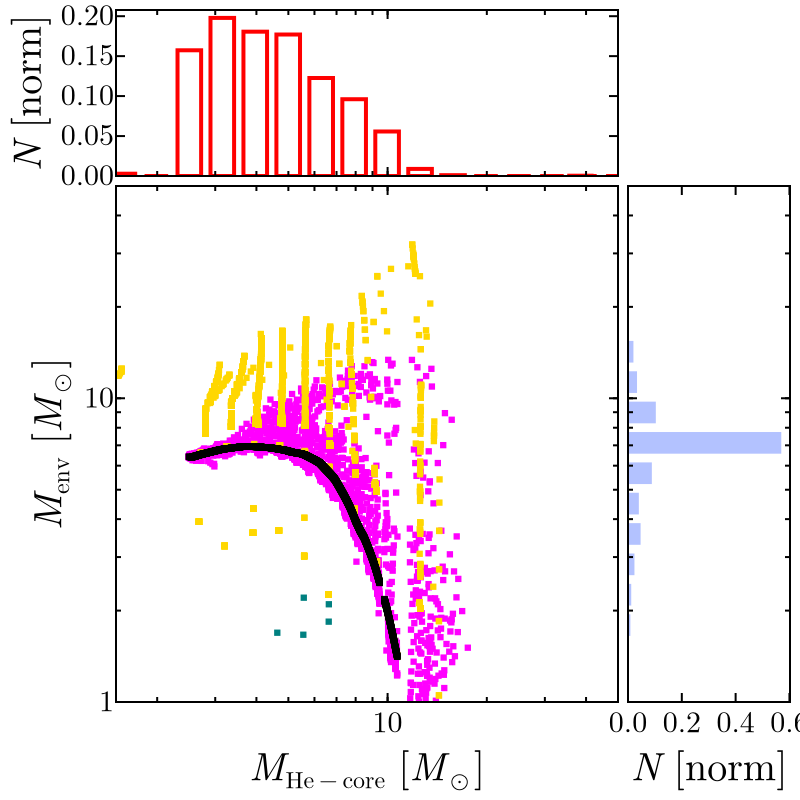

In [31]:
report_stats(SN_DATA, "Mf",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "Mhe",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "Menv",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 


y1  = SN_DATA["Menv"]["1-MT"][get_idx("1-MT", "IIP")]
x1  = SN_DATA["Mhe"]["1-MT"][get_idx("1-MT", "IIP")]

y2  = SN_DATA["Menv"]["2-MT"][get_idx("2-MT", "IIP")]
x2  = SN_DATA["Mhe"]["2-MT"][get_idx("2-MT", "IIP")]
yM  = SN_DATA["Menv"]["M"][get_idx("M", "IIP")]
xM  = SN_DATA["Mhe"]["M"][get_idx("M", "IIP")]
yS  = SN_DATA["Menv"]["S"][get_idx("S", "IIP")]
xS  = SN_DATA["Mhe"]["S"][get_idx("S", "IIP")]



alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
hatcher2 = make_hatch_pattern(size=100, spacing=9, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)
color_coding["II-i2"] =  RGBAf(1,179/255,102/255 , 0.66) 

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  what[4:end] : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)].*sintheta .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  (datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 

function run_histogram_filtered(ax, prg, ttp, what, bins, width; filter = true, color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0
    @printf("Tot of elements %d - filter lenght %d \n", length(get_idx(prg, ttp)), length(filter))

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

    extrafilter = [] 
    if length(filter) > 1
        for ix in range(1,length(get_idx(prg, ttp)))
            filter[ix] && push!(extrafilter, get_idx(prg, ttp)[ix])
        end
    else
        extrafilter = get_idx(prg, ttp)
    end
    @printf("extrafilter got %d elements.\n", length(extrafilter))
    # (length(extrafilter) != length(get_idx(prg, ttp))) && throw(ErrorException("Filter and Data have different sizes!"))
    
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what || occursin("f_M", what) )
        data = datascale.(SN_DATA[what][prg][extrafilter])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  parse(Float64, what[4:end]) : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][extrafilter] ./(SN_DATA["Mej"][prg][extrafilter].*sintheta .+ SN_DATA["dM_C"][prg][extrafilter])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][extrafilter]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][extrafilter]/pdf)
 
    reverse_f(x) = ( datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

     to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)

    return x_bar, y_bar
end 

function run_histogram(ax, data_raw, pdf_data, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1, norm = true)
    (length(data_raw) == 0)           && return 0
    (length(data_raw) != length(pdf_data)) && throw(ErrorException("Data and pdf are not the same size"))

    data = nothing 
    normalize = typeof(norm) == Bool ? (norm ? sum(pdf_data) : 1) : norm 
    data = datascale.(data_raw)
    dataweights = weights(pdf_data / normalize)

    reverse_f(x) =  (datascale == log10 && !keep_log ) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
    return x_bar, y_bar

end 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10, 10:10:100)


# grid = FIGURE[1:5, 1:5] = GridLayout()
# grid_left = 1:3
# grid_right = 4:5 
# grid_top  = 1:2 
# grid_bottom = 3:5
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4
grid_top  = 1 
grid_bottom = 2:4
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{He-core} \ [M_\odot]",
            ylabel=L" M_\mathrm{env} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [\mathrm{norm}]", xticks = 0:0.2:1,
            ylabel=L"M_\mathrm{He-core} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{env} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [\mathrm{norm}]", xmticks=mticks,
            title =" ", xscale = log10 
            )

scatter!(ax, x1, y1,   color=:teal,    marker = :rect, markersize = 5)
scatter!(ax, x2, y2,   color=:magenta, marker = :rect, markersize = 5)
scatter!(ax, xM, yM,   color=:gold,    marker = :rect, markersize = 5)
scatter!(ax, xS, yS,   color=:black,   marker = :rect, markersize = 5)
# scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
# scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0.5,1,0.3), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = '□', label = "Case\nB+C")
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
# scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0.5,1,0.8), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")

# axislegend(ax,  position=:lb, 
#     nbanks=2, titleposition=:left, framealpha=0.5, rowgap =3, colgap =3, labelsize=10)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)

w = 0.10
run_histogram_filtered(ax_dM, "tot", "IIP", "Menv",  -4:w:2, w*1.1; color=RGBAf(0,0.2,1,0.3),            colorcont=:white,                    datascale = log10, direction = :x)
# run_histogram(ax_dM, (f_obs_IIn.Mcsm), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=:gray, datascale = log10, direction = :x)

w = 0.10
scale = log10
xb, yb  = run_histogram_filtered(ax_Mend, "tot", "IIP", "Mhe",  -3.05:w:2, w;    color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# _,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# _,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
stacked_barplot!(ax_Mend, (xb), [yb], 
                    width=w*0.8, colors = [ :red ])
run_histogram(ax_Mend, "tot", "IIP", "Mhe",  -3.05:w:2, w; color=RGBAf(0,0,0,0) , colorcont=:red,datascale = scale, direction = :y, strokewidth=2)



xmin, xmax = 1.5, 50
ymin, ymax = 1, 50
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
# xlims!(ax_fm, -2.5, 0.2)
# ylims!(ax_fm, 0, nothing)



colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("stats_II.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png



FIGURE


In [42]:

SNType = "Ibc"
y1  = SN_DATA["Menv"]["1-MT"][get_idx("1-MT", SNType)]
x1  = SN_DATA["Mhe"]["1-MT"][get_idx("1-MT", SNType)]

y2  = SN_DATA["Menv"]["2-MT"][get_idx("2-MT", SNType)]
x2  = SN_DATA["Mhe"]["2-MT"][get_idx("2-MT", SNType)]
yM  = SN_DATA["Menv"]["M"][get_idx("M", SNType)]
xM  = SN_DATA["Mhe"]["M"][get_idx("M", SNType)]
yS  = SN_DATA["Menv"]["S"][get_idx("S", SNType)]
xS  = SN_DATA["Mhe"]["S"][get_idx("S", SNType)]



alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
hatcher2 = make_hatch_pattern(size=100, spacing=9, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)
color_coding["II-i2"] =  RGBAf(1,179/255,102/255 , 0.66) 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10, 10:10:100)


# grid = FIGURE[1:5, 1:5] = GridLayout()
# grid_left = 1:3
# grid_right = 4:5 
# grid_top  = 1:2 
# grid_bottom = 3:5
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4
grid_top  = 1 
grid_bottom = 2:4
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{He-core} \ [M_\odot]",
            ylabel=L" M_\mathrm{env} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [\mathrm{norm}]", xticks = 0:0.2:1,
            ylabel=L"M_\mathrm{He-core} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{env} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [\mathrm{norm}]", xmticks=mticks,
            title =" ", xscale = log10 
            )

scatter!(ax, x1, y1,   color=:teal,    marker = :rect, markersize = 5)
scatter!(ax, x2, y2,   color=:magenta, marker = :rect, markersize = 5)
scatter!(ax, xM, yM,   color=:gold,    marker = :rect, markersize = 5)
scatter!(ax, xS, yS,   color=:black,   marker = :rect, markersize = 5)
# scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
# scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0.5,1,0.3), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = '□', label = "Case\nB+C")
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
# scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0.5,1,0.8), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")

# axislegend(ax,  position=:lb, 
#     nbanks=2, titleposition=:left, framealpha=0.5, rowgap =3, colgap =3, labelsize=10)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)

w = 0.01
# run_histogram_filtered(ax_dM, "tot", SNType, "Mhe",  -4:w:2, w*1.1; color=RGBAf(0,0.2,1,0.3),            colorcont=:white,                    datascale = log10, direction = :x)
# # run_histogram(ax_dM, (f_obs_IIn.Mcsm), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=:gray, datascale = log10, direction = :x)

w = 0.10
scale = log10
# xb, yb  = run_histogram_filtered(ax_Mend, "tot", SNType, "Mf",  -3.05:w:2, w;    color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# # _,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# # _,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# stacked_barplot!(ax_Mend, (xb), [yb], 
#                     width=w*0.8, colors = [ :red ])
# run_histogram(ax_Mend, "tot", SNType, "Mf",  -3.05:w:2, w; color=RGBAf(0,0,0,0) , colorcont=:red,datascale = scale, direction = :y, strokewidth=2)



xmin, xmax = 1.5, 50
ymin, ymax = 1, 50
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
# xlims!(ax_fm, -2.5, 0.2)
# ylims!(ax_fm, 0, nothing)



colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("stats_Ibc.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png



FIGURE


DomainError: DomainError with -0.20111675838534104:
log10 was called with a negative real argument but will only return a complex result if called with a complex argument. Try log10(Complex(x)).

In [ ]:
report_stats(SN_DATA, "E_exp", "1", "Ibc-i", format_str = "%5.2f", print2screen = true, newline = false, unit = (1e51, "Msun"),  multip1_threshold= [], multip_percentiles=0:1:100) 


E_exp -  0.86< 1.04[+ 0.00--0.00]< 1.26 [ Msun]- 
Perc. Analysis
    0    1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43   44
   45   46   47   48   49   50   51   52   53   54   55   56   57   58   59
   60   61   62   63   64   65   66   67   68   69   70   71   72   73   74
   75   76   77   78   79   80   81   82   83   84   85   86   87   88   89
   90   91   92   93   94   95   96   97   98   99  100
 0.86 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04
 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04
 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04
 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04
 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04
 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.04 1.

1-element Vector{Any}:
 [1.0430986746175197, 0.0009013253824803336, -0.0009013253824803336, 1.044]

In [ ]:
FIG = Figure(size=(500, 600),  figure_padding = (0,0,0,5))
using StatsBase 
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

ymticks = 0:0.5:100
ymticks_II = 0:5:100

d1 = 0.5
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1=[4,16]


# what_to_plot2 = "t"
# d2 = 0.1
# bins2 = 6:d2:8
# xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
# xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
# limits2 =   [log10(1e6), log10(120e6)]
# what_to_plot2 = "M_ni"
# d2 = 0.01
# bins2 = 0.0:d2:0.22
# xticks2 = 0:0.05:0.20
# xticks2_t = [@sprintf("%.2f", t)  for t in xticks2 ]
# limits2 =   [0.0, 0.22]

what_to_plot3 = "E_exp"
d3 = 0.066666666
bins3 = 49.8:d3:53
xticks3 = log10.( [1e50, 3e50, 1e51, 3e51, 1e52])
xmticks3 = union( log10.(1e49:1e49:1e50), log10.(1e50:1e50:1e51), log10.(1e51:1e51:1e52))
xticks3_t = [t > 51 ? @sprintf("%3.0f", 10^t/1e51) : @sprintf("%3.1f", 10^t/1e51)  for t in xticks3 ]
limits3=[log10(5e50), log10(1.5e52)]

what_to_plot4 = "M_rem"
d4 = 0.05
bins4 = 0.0:0.05:2.3
xmticks4 = 0:0.1:2.5
xticks4 = 0.:0.2:5
xticks4_t = [@sprintf("%3.1f", t)  for t in xticks4 ]
limits4=[1.15, 2.1]

yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, 
                    ylabel="", xlabel="",title="") = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_lab_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH/SN [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]


ax3["IIP"] = plot_settings_defauls(grid[2,3];
                xticks= (xticks3,xticks3_t),
                xmticks=xmticks3, ymticks=ymticks_II)
ax3["IIb"] = plot_settings_defauls(grid[3,3];
                xticks= (xticks3,xticks3_t),
                xmticks=xmticks3, ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L" E_\mathrm{kin,ej} \ [10^{51}\,\mathrm{erg}]",x_lab_visible=true,
                xmticks=xmticks3, ymticks=ymticks)

ax4["IIP"] = plot_settings_defauls(grid[2,2];
                xticks= (xticks4,xticks4_t),
                xmticks=xmticks4, ymticks=ymticks_II)
ax4["IIb"] = plot_settings_defauls(grid[3,2];
                xticks= (xticks4,xticks4_t),
                xmticks=xmticks4, ymticks=ymticks)
ax4["Ibc"] = plot_settings_defauls(grid[4,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L" M_\mathrm{NS, \ grav} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks4, ymticks=ymticks)
xspace = maximum(tight_xticklabel_spacing!, [ax1["Ibc"], ax3["Ibc"], ax4["Ibc"]])
[ax.xticklabelspace = xspace for ax in [ax1["Ibc"], ax3["Ibc"], ax4["Ibc"]]]

                

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 




function quantile_sndata(q, what, prg, ttp; unit = 1)
    vals =     [SN_DATA[what][prg][ix]/unit for ix in get_idx(prg, ttp)]
    pdfs = Weights([SN_DATA["pdf"][prg][ix] for ix in get_idx(prg,ttp)])
    return quantile(vals, pdfs, q)
end 

max_ttp = Dict() 
sntypes = ["IIP",  "IIb", "Ibc"]

prg = "S"
for ttp in ttps


    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])

    function run_histogram(ax, prg, ttp, what, bins, width; datascale = identity, extra = false)
        length(get_idx(prg, ttp)) == 0 && return 0

        pdf = sum(  [sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes] )
    
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
        dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf*100)

        x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
        hist1 = fit(Histogram,  data, dataweights, bins)  

        y_bar = Float64[]
        for ix in range(1,length(bins)-1)
            push!(y_bar,  hist1.weights[ix]) 
        end 


        color = color_coding[ttp]
        barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color =  !extra ? color : RGBAf(0,0,0,0),
                            strokewidth = !extra ? 0 : 1,
                            width=width*1.1,
                            strokecolor = !extra ? RGBAf(0,0,0,0) : :black)
        return maximum(hist1.weights)
    end 

    multipeaks = multipeaks_distribution[ttp][prg]

    max_ax = 0
    max_ax = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1)
    if ttp != "BH"
        # run_histogram(ax2, prg, ttp, what_to_plot2, bins2, d2)
        tmp_max = run_histogram(ax3, prg, ttp, what_to_plot3, bins3, d3, datascale=log10)
        max_ax = max(max_ax, tmp_max)
        tmp_max = run_histogram(ax4, prg, ttp, what_to_plot4, bins4, d4)
        max_ax = max(max_ax, tmp_max)

    end 

    if prg != "S" && ! (ttp in ["II-i", "Ibc-i"]) 

        tmp_max = run_histogram(ax1, "S", ttp, what_to_plot, bins1, d1, extra=true)
        max_ax = max(max_ax, tmp_max)

        if ttp != "BH"
            # run_histogram(ax2,  "S", ttp, what_to_plot2, bins2, d2, extra=true)
            tmp_max  = run_histogram(ax3,  "S", ttp, what_to_plot3, bins3, d3, datascale=log10, extra=true)
            max_ax = max(max_ax, tmp_max)
            tmp_max =  run_histogram(ax4,  "S", ttp, what_to_plot4, bins4, d4, extra=true)
            max_ax = max(max_ax, tmp_max)

        end 
    end
    max_ttp[ttp] = max_ax

    ranges = report_stats(what_to_plot, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = multipeaks[1]+1, multip1_threshold=multipeaks[2])
    for range in ranges
        errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
        scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
        text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
        text!(ax1[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
            fontsize=13, color=:black)#:red)
    end 
    if ttp != "BH"
        ranges = report_stats(what_to_plot3, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = 1)
        for range in ranges
            errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], 
            [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :black)
            scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1]/1e51, range[2]/1e51, range[3]/1e51)
            text!(ax3[ttp], log10.(range[1]), max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
                fontsize=13, color=:black)#:red)

        end 
        ranges = report_stats(what_to_plot4, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = 1)
        for range in ranges
            errorbars!(ax4[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
            scatter!(ax4[ttp], [range[1]], [max_ax*0.75], marker = '|', markersize = 10, color = :black)
            text_decor = @sprintf("%5.2f^{+%5.2f}_{-%5.2f}", range[1], range[2], range[3])
            text!(ax4[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=13, color=:black)#:red)

        end 
    end

    # xx = []
    # qq = 0:1:100
    # for qs in qq
    #     push!(xx, quantile_sndata(qs/100, what_to_plot, prg, ttp) )
    # end
    # lines!(ax1[ttp], xx, qq/100, color = "gray", linestyle=:dash)
end



for ttp in ["IIP", "IIb", "Ibc", "BH"]
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
    if ttp!="BH"
        # xlims!(ax2[ttp], limits2[1], limits2[2])
        # ylims!(ax2[ttp], 0, nothing)    
        xlims!(ax3[ttp], limits3[1], limits3[2])
        ylims!(ax3[ttp], 0, max_ttp[ttp]*bf)
        xlims!(ax4[ttp], limits4[1], limits4[2])
        ylims!(ax4[ttp], 0, max_ttp[ttp]*bf)
    end
end 





    

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_type_%s_%s_%s.pdf", prg, MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



In [ ]:
FIG = Figure(size=(500, 800),  figure_padding = (0,0,0,5))
using StatsBase 

set_theme!(theme_latexfonts())

what_to_plot = "Mf"

prg = "1-MT"
prg2 = "S"

ttps = ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
prg != "1-MT" && (ttps = ["IIP", "IIb", "Ibc", "II-i", "BH"])
prg == "M" && (ttps = ["IIP", "IIb", "Ibc", "II-i", "IIP-B", "BH"])




ymticks = 0:1:100

d1 = (prg != "M" && prg != "2-MT") ? 0.5 : 0.75
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1 = nothing
if  prg == "1-MT"
    limits1 =[0,16]
elseif prg == "2-MT"
    limits1 = [0,20]
elseif prg == "M" 
    limits1 = [0,35]
else
    throw(ErrorException)
end


what_to_plot3 = "E_exp"
d3 = 0.05
bins3 = 49.8:d3:53
xticks3 = log10.( [1e50, 3e50, 1e51, 3e51, 1e52])
xmticks3 = union( log10.(1e49:1e49:1e50), log10.(1e50:1e50:1e51), log10.(1e51:1e51:1e52))
xticks3_t = [t > 51 ? @sprintf("%3.0f", 10^t/1e51) : @sprintf("%3.1f", 10^t/1e51)  for t in xticks3 ]
limits3=[log10(6e50), log10(9e51)]

what_to_plot4 = "M_rem"
d4 = 0.05
bins4 = 0.0:0.05:2.3
xmticks4 = 0:0.1:2.5
xticks4 = 0.:0.2:5
xticks4_t = [@sprintf("%3.1f", t)  for t in xticks4 ]
limits4=[1.15, 2.1]

yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, y_ticks_visible = true,
                    ylabel="", xlabel="",title="") = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_ticks_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH/SN [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["II-i"] = plot_settings_defauls(grid[5,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax1["Ibc-i"] = plot_settings_defauls(grid[6,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax1["IIP-B"] = plot_settings_defauls(grid[6,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks))
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]

ax3["IIP"] = plot_settings_defauls(grid[2,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "II [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["IIb"] = plot_settings_defauls(grid[3,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "IIb [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "Ibc [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["II-i"] = plot_settings_defauls(grid[5,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax3["Ibc-i"] = plot_settings_defauls(grid[6,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]",x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax3["IIP-B"] = plot_settings_defauls(grid[6,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]",x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))



ax4["IIP"] = plot_settings_defauls(grid[2,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "II [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["IIb"] = plot_settings_defauls(grid[3,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "IIb [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["Ibc"] = plot_settings_defauls(grid[4,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "Ibc [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["II-i"] = plot_settings_defauls(grid[5,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax4["Ibc-i"] = plot_settings_defauls(grid[6,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax4["IIP-B"] = plot_settings_defauls(grid[6,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))


                
sntypes = ["IIP",  "IIb", "Ibc", "II-i", "Ibc-i"]

p = Makie.LinePattern(width=5, tilesize=(10,10), linecolor=:gray, background_color=RGBAf(1,0,0,0.5));
# barplot(1:3,strokewidth=2, color=["grey","green","orange"])
# barplot!([4], [4], color=p, strokewidth=2)
p2 = Pattern("X", background_color = :red, linecolor = :cyan)
alpha = 0.6
# alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.5, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 



function quantile_sndata(q, what, prg, ttp; unit = 1)
    vals =     [SN_DATA[what][prg][ix]/unit for ix in get_idx(prg, ttp)]
    pdfs = Weights([SN_DATA["pdf"][prg][ix] for ix in get_idx(prg,ttp)])
    return quantile(vals, pdfs, q)
end 


colorpattern_img(color) = make_hatch_pattern(size = 41, spacing=5, thickness=1.8,
                            style=:backslash, line_color=color,
                            bg_color= RGBAf(0, 0, 0, 0))


max_ttp = Dict() 
for ttp in ttps

    function run_histogram(ax, prg, ttp, what, bins, width; datascale = identity, extra = false, alternative=false)
        length(get_idx(prg, ttp)) == 0 && return 0

        # sntypes = ["IIP",  "IIb", "Ibc"]
        pdf = sum([sum(  [sum(SN_DATA["pdf"][progenitor][get_idx(progenitor, type)]) for type in sntypes] )] for progenitor in ["1","2","M","S"])
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
        dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf * 100)

        x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
        hist1 = fit(Histogram,  data, dataweights, bins)  

        y_bar = Float64[]
        for ix in range(1,length(bins)-1)
            push!(y_bar,  hist1.weights[ix]) 
        end 

        color = color_coding[ttp]
        # colorpattern_img = create_hatch_pattern(
        #         40, 9, 1.5, color, RGBAf(0, 0, 0, 0);
        #         style = :diagonal)
        # colorpattern = Pattern(create_hatch_pattern(50, 5, 2, color, RGBAf(0,0,0,0)))
        colorpattern = Pattern(colorpattern_img(color))

        if !extra && !alternative 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = :white,
                            strokewidth = 0,
                            width=width,
                            strokecolor =RGBAf(0,0,0,0))
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = color,
                            strokewidth = 0,
                            width=width,
                            strokecolor =RGBAf(0,0,0,0))
        elseif extra 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color =  RGBAf(0,0,0,0),
                            strokewidth =  0.5,
                            width=width,
                            strokecolor = :black)

        elseif alternative 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = colorpattern,
                            strokewidth =  0.5,
                            width=width,
                            strokecolor = color)

        end

        return maximum(hist1.weights)
    end 

    max_ax = 0
    if prg == "1-MT" || prg == "2-MT"
        prg_old = @sprintf("%1s", prg[1])
        tmp_max = run_histogram(ax1, prg_old, ttp, what_to_plot, bins1, d1, extra=false, alternative = true)
        max_ax = max(max_ax, tmp_max)
        if ttp != "BH"
            tmp_max = run_histogram(ax3, prg_old, ttp, what_to_plot3, bins3, d3, datascale=log10, extra=false, alternative = true)
            max_ax = max(max_ax, tmp_max)
            tmp_max = run_histogram(ax4, prg_old, ttp, what_to_plot4, bins4, d4, extra=false, alternative = true)
            max_ax = max(max_ax, tmp_max)
        end 

    end 

    tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1)
    max_ax = max(max_ax, tmp_max)
    if ttp != "BH"
        # run_histogram(ax2, prg, ttp, what_to_plot2, bins2, d2)
        tmp_max = run_histogram(ax3, prg, ttp, what_to_plot3, bins3, d3, datascale=log10)
        max_ax = max(max_ax, tmp_max)
        tmp_max = run_histogram(ax4, prg, ttp, what_to_plot4, bins4, d4)
        max_ax = max(max_ax, tmp_max)

    end 

    if prg != "S" && ! (ttp in ["II-i", "Ibc-i"]) 
        tmp_max = run_histogram(ax1, "S", ttp, what_to_plot, bins1, d1, extra=true)
        max_ax = max(max_ax, tmp_max)
        if ttp != "BH"
            tmp_max  = run_histogram(ax3,  "S", ttp, what_to_plot3, bins3, d3, datascale=log10, extra=true)
            max_ax = max(max_ax, tmp_max)
            tmp_max =  run_histogram(ax4,  "S", ttp, what_to_plot4, bins4, d4, extra=true)
            max_ax = max(max_ax, tmp_max)
        end 


    end

    
    max_ttp[ttp] = max_ax
    multipeaks = multipeaks_distribution[ttp][prg]
    multipeaks_S = multipeaks_distribution[ttp]["S"]

    ranges = report_stats(what_to_plot, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = multipeaks[1]+1, multip1_threshold=multipeaks[2])
    for range in ranges
        errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
        scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
        text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], abs(range[2]), abs(range[3]))
        text!(ax1[ttp], range[1], max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
            fontsize=12, color=:black)#:red)

    end 
    if ! (ttp in ["Ibc-i", "II-i", "IIP-B"])
        ranges = report_stats(what_to_plot, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = multipeaks_S[1]+1, multip1_threshold=multipeaks_S[2])
        for range in ranges
            errorbars!(ax1[ttp], [range[1]], [max_ax*0.85], [range[3]], [range[2]], direction = :x, color = :gray)
            scatter!(ax1[ttp], [range[1]], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            # text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
            # text!(ax1[ttp], range[1], max_ax*0.86, text=L"%$(text_decor)", align = (:center, :bottom),
            #      fontsize=12, color=:black)#:red)

        end 
    end
    if ttp != "BH"
        ranges = report_stats(what_to_plot3, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks =  1, multip1_threshold=multipeaks[2])
        for range in ranges
            errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], 
            [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :black)
            scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1]/1e51, abs(range[2])/1e51, abs(range[3])/1e51)
            text!(ax3[ttp], log10.(range[1]), max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=12, color=:black)#:red)

        end 
        ranges = report_stats(what_to_plot4, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks[2])
        for range in ranges
            errorbars!(ax4[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
            scatter!(ax4[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.2f^{+%5.2f}_{-%5.2f}", range[1], abs(range[2]), abs(range[3]))
            text!(ax4[ttp], (range[1]), max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=12, color=:black)#:red)

        end 

      if ! (ttp in ["Ibc-i", "II-i", "IIP-B"])

            ranges = report_stats(what_to_plot3, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks_S[2])
            for range in ranges
                errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.85], 
                [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :gray)
                scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            end 
            ranges = report_stats(what_to_plot4, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks_S[2])
            for range in ranges
                errorbars!(ax4[ttp], [range[1]], [max_ax*0.85], [range[3]], [range[2]], direction = :x, color = :gray)
                scatter!(ax4[ttp], [range[1]], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            end 
        end
    
    end

    # xx = []
    # qq = 0:1:100
    # for qs in qq
    #     push!(xx, quantile_sndata(qs/100, what_to_plot, prg, ttp) )
    # end
    # lines!(ax1[ttp], xx, qq/100, color = "gray", linestyle=:dash)
end


for ttp in ttps
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
    if ttp!="BH"
        # xlims!(ax2[ttp], limits2[1], limits2[2])
        # ylims!(ax2[ttp], 0, nothing)    
        xlims!(ax3[ttp], limits3[1], limits3[2])
        ylims!(ax3[ttp], 0, max_ttp[ttp]*bf)
        xlims!(ax4[ttp], limits4[1], limits4[2])
        ylims!(ax4[ttp], 0, max_ttp[ttp]*bf)
    end
end 


rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = ""
outfilename = @sprintf("hist_type_%s_%s_%s.pdf", prg, MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



In [ ]:
function get_hist(prg, ttp, what, bins, width; datascale = identity, extra = false)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100/pdf)

    x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
    hist1 = fit(Histogram,  data, dataweights, bins)  

    return hist1
end 
maximum(get_hist("S", "IIb", "Mf", 0:1:100, 0.1).weights)


In [ ]:
using StatsBase 


sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

                     

progenitors = ["1", "2", "M", "S"]


multip1_thresholds = Dict("Ibc"=>13, "BH"=>7.5, "IIP"=>0, "IIP-B"=>0, "IIb"=>0, "II-i"=>0, "Ibc-i"=>0)

for ttp in ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

    multip1_threshold = multip1_thresholds[ttp]
    
    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    pdf_tot < 0.0001 && continue 

    

    for prg in progenitors
        sub_pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
        sub_pdf < 0.0001 && continue 

        @printf("%7s (%s) -> %5.2f |", ttp, prg, sub_pdf*100)

        report_stats(SN_DATA, "Mf",    prg, ttp, false, unit = (1, "Msun"), 
                        multipeak= ( (ttp=="Ibc" || ttp =="BH") && prg == "S"), 
                        multip_percentiles=0:1:20,multip1_threshold= ( (ttp=="Ibc" || ttp =="BH") && prg == "S") ? multip1_threshold : ( ttp == "Ibc" && prg == "1" ? 88.4 : NaN) 
                        )
        # report_stats(SN_DATA, "t",     prg, ttp, false, unit = (1e6, "Myr"))
        report_stats(SN_DATA, "MM",    prg, ttp, false, unit =(1, "Msun"))
        report_stats(SN_DATA, "N_DATA, "E_exp", prg, ttp, false, unit =(1e51, "B"))
        report_stats(SN_DATA, "N_DATA, "M_rem", prg, ttp, true , unit =(1, "Msun"), format_str="%4.2f")
    
    end
    @printf("%7s     -> %5.2f |", ttp,  pdf_tot*100)

    report_stats(SN_DATA, "Mf",    "tot", ttp, false, unit =(1, "Msun"))
    # report_stats(SN_DATA, "N_DATA, "t",     "tot", ttp, false, unit =(1e6, "Myr"))
    report_stats(SN_DATA, "N_DATA, "MM",    "tot", ttp, false, unit =(1, "Msun"))
    report_stats(SN_DATA, "E_exp", "tot", ttp, false, unit =(1e51, "B"))
    report_stats(SN_DATA, "N_DATA, "M_rem", "tot", ttp, true , unit =(1, "Msun"), format_str="%4.2f")



    
    #weighted_mean = sum([SN_DATA[what_to_plot]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA[what_to_plot]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax1[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth=2)
    #_temp=vspan!(ax1[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #@printf("%s  M %7.2f ± %7.2f;", ttp, weighted_mean, weighted_err)
    #translate!(_temp, 0, 0, -10)
    #weighted_mean = sum([SN_DATA["t"]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA["t"]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax2[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth  = 2, alpha = 1)
    #_temp=vspan!(ax2[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #translate!(_temp, 0, 0, -10)
    #@printf(" t %7.1f ± %7.1f\n",   weighted_mean/1e6, weighted_err/1e6)


    print("\n")
end

report_stats(SN_DATA, "N_DATA, "Mf",  "1", "Ibc-i", false, unit = (1, "Msun"), 
                multipeak=false, 
                multip_percentiles=1:1:100, multip1_threshold=85)




In [ ]:
include("defs.jl")
for logM in logMs 
    logM_t = to_key(logM)
    for logP in logPs 
        logP_t = to_key(logP)
        for q in qs 
            q_t  = to_key(q)
            model = MODELS[logM_t][logP_t][q_t]
            n = model["mod"]

            if model["SN1"]["Ibc-i"] > 0
                M_1_postHeB = f_MW.M_1_end_BURN_He_1[n]
                M_end = model["M1end"]
                M_2_end = f_MW.M_2_end_1[n]
                Pf = f_MW.period_end_1[n]
                case = model["case"]
                dMc = model["dM_C"]
                #  ! (M_2_end > 15 && Pf < 200) && continue
                 (occursin("A", case)) && continue 

                a_postHeB = f_MW.a_end_BURN_He_1[n]
                a_new = 0# derive_a_massloss_smooth(a_postHeB, M_1_postHeB, M_2_end, dMc; dm=1e-4)
                Pf_new = 0#kepler_law(m = M_end+M_2_end, a = a_new, P = nothing )
                @printf("Mod #%5d: %s/%s/%s, M1: %5.1f  (dm=%5.2f)  M2: %5.1f   Pf: %5.1f (%5.1f)  case %5s\n", n, logM_t, q_t, logP_t, M_end, dMc, M_2_end, Pf, Pf_new, case)

            end


        end 
    end 
end


In [6]:
pdfs  = []
for logM in logMs 
    logM_t = to_key(logM)
    for logP in logPs 
        logP_t = to_key(logP)
        for q in qs 
            q_t  = to_key(q)
            model = MODELS[logM_t][logP_t][q_t]

            push!(pdfs, model["pdf"]["tot"])

                


        end 
    end 
end
print(sum(pdfs))

KeyError: KeyError: key "0.00" not found

In [ ]:
include("defs.jl")

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.05
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax2 = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1-MT"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1-MT"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2-MT"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2-MT"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S+NI"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S+NI"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

                

                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
progenitors = ["1-MT", "2-MT", "M", "S+NI"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
hist2 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
    hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"]["tot"][get_idx("tot",sn)]),  weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins2)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 
y_bar2 = Float64[]
for ix in range(1,length(bins2)-1)
    for sn in sntypes
        push!(y_bar2,  hist2[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)
# barplot!(ax2["all"], x_bar2 , 
#                      y_bar2, 
#                      stack= order2,
#                      color = colors2,
#                      width=d2)



 

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
    x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
    hist1 = Dict() 
    hist2 = Dict() 
    for sn in sntypes 
        hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
        hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"][prg][get_idx(prg,sn)]),  weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins2)
    end
    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    y_bar2 = Float64[]
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 


    y_bar = Float64[]
    y_bar2 = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 
    
    order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    
    colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    barplot!(ax1[prg], x_bar , 
                            y_bar, 
                            stack= order,
                            color = colors,
                            width=d1)
    # barplot!(ax2[prg], x_bar2 , 
    #                         y_bar2, 
    #                         stack= order2,
    #                         color = colors2,
    #                         width=d2)

    scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding["IIP"],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f%%   ", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["IIP-B"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["IIb"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["II-i"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["Ibc"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["Ibc-i"], markersize=12, marker = :rect,
                                                                label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])))
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
    #                                                             label = @sprintf("[%.3f%%]", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])))
    n_bh = sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])
    n_bh >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
             label =  100*n_bh < 0.1 ?  ("["*str_significant(100*n_bh, 1)*"%]") : @sprintf("[%.1f%%]", 100*n_bh) )

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
    # axislegend(ax1[prg],  position=:lt, nbanks=1, titleposition=:right, labelsize = 11, rowgap = 0, colgap = 0, alpha = 0.5)


end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1-MT", "2-MT", "M", "S+NI"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 
# for prg in ["all", "1", "2", "M", "S"]
#     xlims!(ax2[prg], 6.35, 8.05)
#     ylims!(ax2[prg], 0, nothing)

# end 
    

# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP"], label =  @sprintf("II: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-BSG")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIb"], label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["II-i"], label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc"], label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))

# print(x_bar[1:10], "\n")
# print(y_bar[1:10], "\n")
# print(order[1:10], "\n")

rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

for tt in ["1-MT", "2-MT", "M", "S+NI"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_progenitor_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



In [ ]:
include("defs.jl")

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.05
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax2 = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

                

                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
progenitors = ["1", "2", "M", "S"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
hist2 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
    hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"]["tot"][get_idx("tot",sn)]),  weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins2)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 
y_bar2 = Float64[]
for ix in range(1,length(bins2)-1)
    for sn in sntypes
        push!(y_bar2,  hist2[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)
# barplot!(ax2["all"], x_bar2 , 
#                      y_bar2, 
#                      stack= order2,
#                      color = colors2,
#                      width=d2)



                     

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
    x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
    hist1 = Dict() 
    hist2 = Dict() 
    for sn in sntypes 
        hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
        hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"][prg][get_idx(prg,sn)]),  weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins2)
    end
    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    y_bar2 = Float64[]
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 


    y_bar = Float64[]
    y_bar2 = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 
    
    order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    
    colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    barplot!(ax1[prg], x_bar , 
                            y_bar, 
                            stack= order,
                            color = colors,
                            width=d1)
    # barplot!(ax2[prg], x_bar2 , 
    #                         y_bar2, 
    #                         stack= order2,
    #                         color = colors2,
    #                         width=d2)

    scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding["IIP"],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f%%   ", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["IIP-B"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["IIb"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["II-i"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["Ibc"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["Ibc-i"], markersize=12, marker = :rect,
                                                                label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])))
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
    #                                                             label = @sprintf("[%.3f%%]", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])))
    n_bh = sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])
    n_bh >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
             label =  100*n_bh < 0.1 ?  ("["*str_significant(100*n_bh, 1)*"%]") : @sprintf("[%.1f%%]", 100*n_bh) )

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
    # axislegend(ax1[prg],  position=:lt, nbanks=1, titleposition=:right, labelsize = 11, rowgap = 0, colgap = 0, alpha = 0.5)


end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 
# for prg in ["all", "1", "2", "M", "S"]
#     xlims!(ax2[prg], 6.35, 8.05)
#     ylims!(ax2[prg], 0, nothing)

# end 
    

# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP"], label =  @sprintf("II: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-BSG")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIb"], label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["II-i"], label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc"], label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))

# print(x_bar[1:10], "\n")
# print(y_bar[1:10], "\n")
# print(order[1:10], "\n")

rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

for tt in ["1", "2", "M", "S"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_progenitor_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



In [ ]:
include("defs.jl")

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.06
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


                
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 20, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

stacked_barplot!(ax1["all"], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

                     

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax1[prg], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%4.1f%% %s  ", bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]

SN_numbers2   = [100 * sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sntypes for prg in progenitors_pie]
SN_colors2    =  [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_pie]
# pie!(ax_extra, reverse!(SN_numbers2), 
#          color=(SN_colors2), 
#          offset = pi/2, inner_radius = 0., radius = 0.4)

for tt in ["1", "2", "M", "S"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_progs_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png


 
resize_to_layout!(FIG)

FIG



done 1
[IIP: 4.60] [II-BSG: 0.00] [IIb: 1.19] [Ibc:20.01] [II-i: 2.19] [Ibc-i: 2.42] tot : 30.400216 
done 2
[IIP:15.91] [II-BSG: 0.00] [IIb: 0.78] [Ibc: 2.91] [II-i: 0.05] [Ibc-i: 0.00] tot : 19.660689 
done M
[IIP:24.24] [II-BSG: 0.32] [IIb: 1.06] [Ibc: 3.82] [II-i: 0.14] [Ibc-i: 0.00] tot : 29.577237 
done S
[IIP:16.33] [II-BSG: 0.00] [IIb: 1.04] [Ibc: 2.99] [II-i: 0.00] [Ibc-i: 0.00] tot : 20.361857 


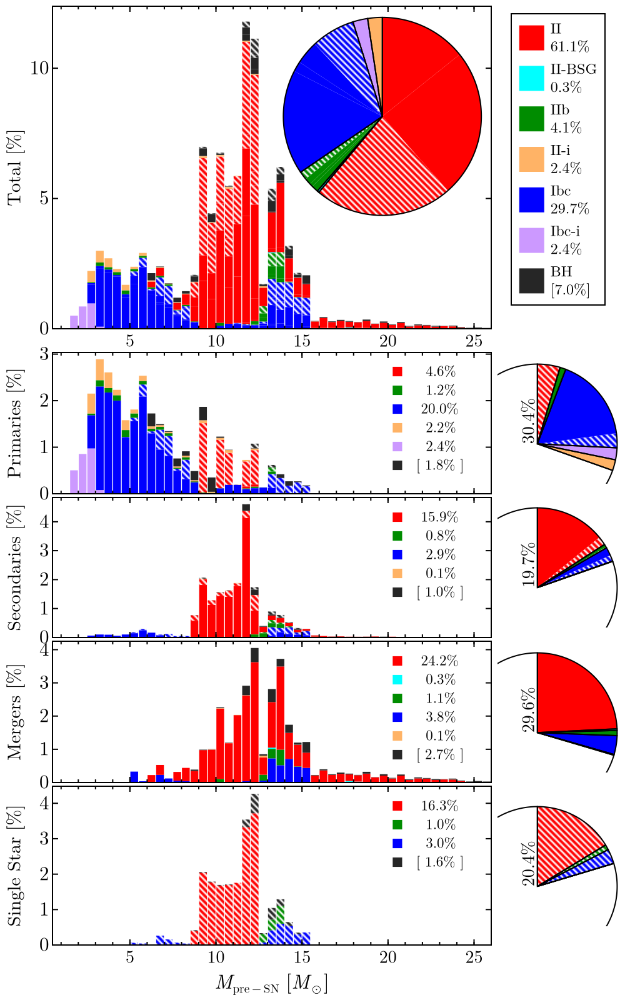

In [12]:

FIG = Figure(size=(500, 800), figure_padding = 5)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.5

bins = 0:d1:30

xticks = 0:5:30
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
xmticks = 0:1:30 

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30, xmticks = xmticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,3:6], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]",
                title = "", titlesize=30, xmticks = xmticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


                
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

stacked_barplot!(ax1["all"], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax1[prg], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%4.1f%% %s  ", bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .5, 26)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)



function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    if prgs_col != ["tot"]
        push!(SN_numbers,     100*(1 - normer))
        push!(SN_numbers_sub, 100*(1 - normer))
        push!(SN_colors, :white)
        push!(SN_colors_sub, :white)
    else

    end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_extra, SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_extra, -1.4, 1.1)
ylims!(ax_extra, -1.4, 1.1)

for tt in ["1", "2", "M", "S"]

    prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], prg2, sntypes)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_progs_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



In [ ]:

FIG = Figure(size=(400, 400), figure_padding = 0)

ax = plot_settings( FIG[1,1],
                ylabel = " ",
                xlabel =  " ",
                title = "", titlesize=30, xticklabelsvisible=false, yticklabelsvisible=false,
                xticks=[NaN], yticks = [NaN])
sntypes =  ["IIP", "IIP-B", "IIb", "Ibc",
              "Ibc-i", "II-i"]

function sn_pie_charter(SN_DATA, prgs_col, prgs_hatch, sne)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = [color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  [color_coding_pie[sn][prg] for sn in sne for prg in prgs_hatch]

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1, strokecolor=:white)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1)

end
color_coding_pie = Dict() 
colorhatch(color) = make_hatch_pattern(size = 900, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 



for sn in sntypes 
    color_coding_pie[sn]=Dict()
    color_coding_pie[sn]["1-MT"] = color_coding[sn]
    color_coding_pie[sn]["2-MT"] = color_coding[sn]
    color_coding_pie[sn]["M"]    = color_coding[sn]
    color_coding_pie[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_pie[sn]["1"] = color_coding[sn]
    color_coding_pie[sn]["2"] = color_coding[sn]
    color_coding_pie[sn]["M"] = color_coding[sn]
    color_coding_pie[sn]["S"] = color_coding[sn]
end

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]
# progenitors_pie = ["1", "2",  "M", "S"]

sn_pie_charter(SN_DATA, ["tot"], progenitors_pie, sntypes)
ax.rightspinevisible = false
ax.topspinevisible = false
ax.leftspinevisible = false
ax.bottomspinevisible = false

save("Pie.pdf", FIG)
FIG

In [3]:

FIG = Figure(size=(500, 600), figure_padding = 5)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "M16-Hardcoded")

ax_pie["1"] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars")

ax_pie["2"] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars")


ax_pie["M"] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie["S"] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]


alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]
                     

function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne; r_in = 0, r_out = 1)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    # if prgs_col != ["tot"]
    #     push!(SN_numbers,     100*(1 - normer))
    #     push!(SN_numbers_sub, 100*(1 - normer))
    #     push!(SN_colors, :white)
    #     push!(SN_colors_sub, :white)
    # else

    # end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_pie["all"], SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in ["1", "2", "M", "S"]

    prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], prg2, sntypes)
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]) < 1e-6 && continue
        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%3.1f%%%s", bhs[1], 100*sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]), bhs[2]))
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks=  1, titleposition=:left, rowgap=0,colgap=0, 
                labelsize=11, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false


barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:rt, 
    nbanks=2, labelsize=15, rowgap =6, colgap =10)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("pies_%s_%s_%2d.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



InexactError: InexactError: Int64(NaN)

## Master Pie

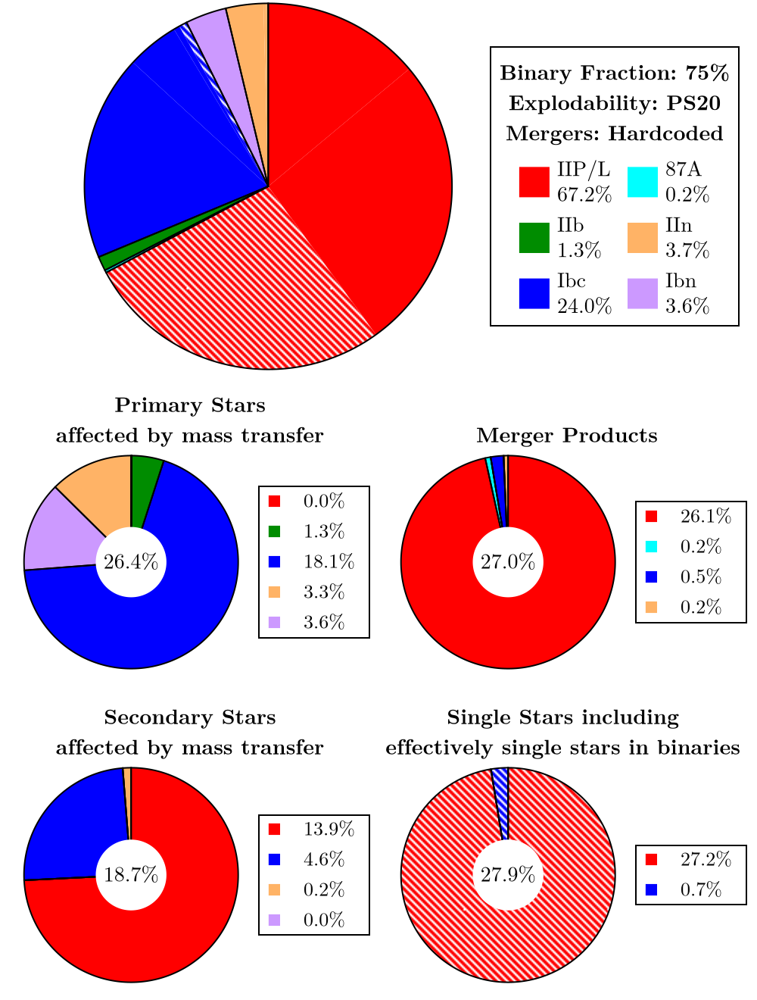

In [16]:

FIG = Figure(size=(500, 660), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")

ax_pie["1-MT"] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars\naffected by mass transfer")

ax_pie["2-MT"] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars\naffected by mass transfer")


ax_pie["M"] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie["S+NI"] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars including \neffectively single stars in binaries ")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i"]


alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne; r_in = 0, r_out = 1)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    # if prgs_col != ["tot"]
    #     push!(SN_numbers,     100*(1 - normer))
    #     push!(SN_numbers_sub, 100*(1 - normer))
    #     push!(SN_colors, :white)
    #     push!(SN_colors_sub, :white)
    # else

    # end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_pie["all"], SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in ["1-MT", "2-MT",  "M", "S+NI"]

    # prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], [tt], sntypes)
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]) < 1e-6 && continue
        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%3.1f%%%s", bhs[1], 100*sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]), bhs[2]))
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks=  1, titleposition=:left, rowgap=0,colgap=0, 
                labelsize=13, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false


barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("IIP/L\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("87A\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("IIn\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibn\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
# barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
key_label = @sprintf( "Binary Fraction: %d%%\nExplodability: %S\nMergers: %s", f_B*100, exp_crit, mer_crit)

axislegend(ax_pie["all"], key_label, position=:rc, 
    nbanks=2, labelsize=14, rowgap =6, colgap =10, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("pies_%s_%s_%2d.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

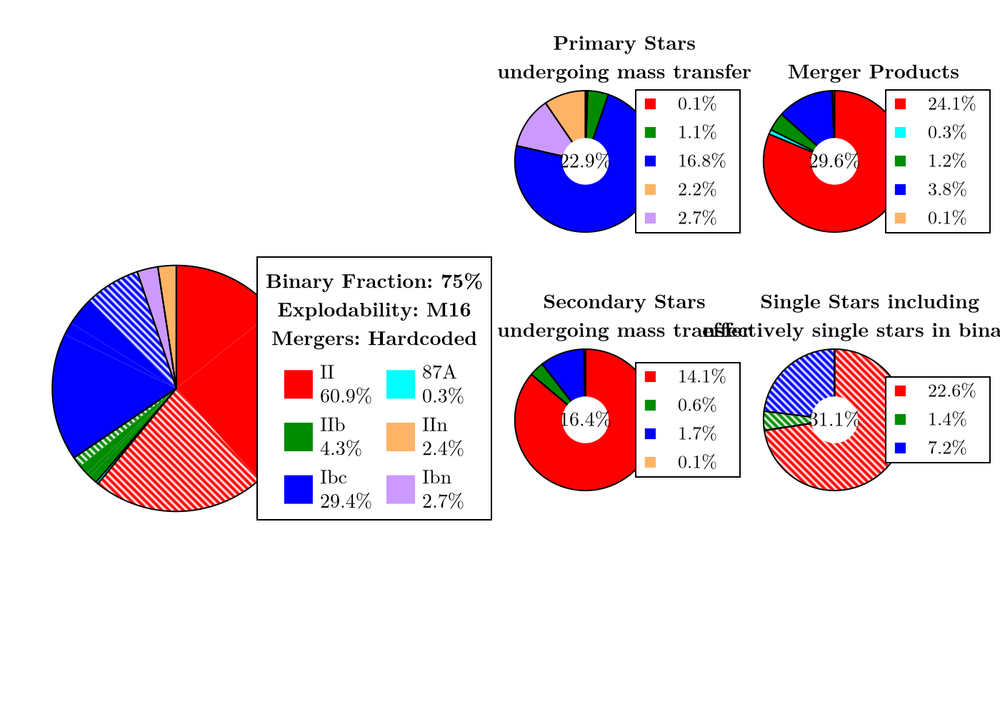

In [72]:

FIG = Figure(size=(700, 500), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

left_axis = 3
right_axis = 4
left_right = first(left_axis):last(right_axis)
left_right = 1:2
big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 1
sub_bot = 2
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")

ax_pie["1-MT"] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars\nundergoing mass transfer")

ax_pie["2-MT"] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars\nundergoing mass transfer")


ax_pie["M"] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie["S+NI"] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars including \neffectively single stars in binaries ")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i"]


alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne; r_in = 0, r_out = 1)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    # if prgs_col != ["tot"]
    #     push!(SN_numbers,     100*(1 - normer))
    #     push!(SN_numbers_sub, 100*(1 - normer))
    #     push!(SN_colors, :white)
    #     push!(SN_colors_sub, :white)
    # else

    # end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_pie["all"], SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in ["1-MT", "2-MT",  "M", "S+NI"]

    # prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], [tt], sntypes)
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]) < 1e-6 && continue
        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%3.1f%%%s", bhs[1], 100*sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]), bhs[2]))
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks=  1, titleposition=:left, rowgap=0,colgap=0, 
                labelsize=13, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false


barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("87A\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("IIn\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibn\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
# barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"], "Binary Fraction: 75%\nExplodability: M16\nMergers: Hardcoded", position=:rc, 
    nbanks=2, labelsize=14, rowgap =6, colgap =10, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("pies_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

In [18]:

FIG = Figure(size=(400, 400), figure_padding = 0)

ax = plot_settings( FIG[1,1],
                ylabel = " ",
                xlabel =  " ",
                title = "", titlesize=30, xticklabelsvisible=false, yticklabelsvisible=false,
                xticks=[NaN], yticks = [NaN])
sntypes =  ["IIP", "IIP-B", "IIb", "Ibc",
              "Ibc-i", "II-i"]

function sn_pie_charter(SN_DATA, prgs, sne, sne_hatch)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs for sn in sne ]
    SN_colors  = [color_coding[sn] for prg in prgs for sn in sne ]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs for sn in sne_hatch ]
    SN_colors_sub =  [color_coding_pie[sn][prg] for prg in prgs for sn in sne_hatch ]

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1, strokecolor=:white)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1)

end
color_coding_pie = Dict() 
colorhatch(color) = make_hatch_pattern(size = 900, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 

color_coding["1"]    = RGBAf(1,0,1,alpha)    
color_coding["1-MT"] = RGBAf(1,0,1,alpha)    
color_coding["2"]    = RGBAf(0,1,1,alpha)    
color_coding["2-MT"] = RGBAf(0,1,1,alpha)   
color_coding["M"]    = RGBAf(1,1,0,alpha) 
color_coding["S"]    = RGBAf(.5,.5,.5,alpha) 
color_coding["S+NI"] = RGBAf(.5,.5,.5,alpha) 


for sn in sntypes 
    color_coding_pie[sn]=Dict()
    color_coding_pie[sn]["1-MT"] = color_coding[sn]
    color_coding_pie[sn]["2-MT"] = color_coding[sn]
    color_coding_pie[sn]["M"]    = color_coding[sn]
    color_coding_pie[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_pie[sn]["1"] = color_coding[sn]
    color_coding_pie[sn]["2"] = color_coding[sn]
    color_coding_pie[sn]["M"] = color_coding[sn]
    color_coding_pie[sn]["S"] = color_coding[sn]
end
for prg in ["1", "2", "S+NI", "M", "1-MT", "2-MT",  "M", "S+NI"] 
    color_coding_pie[prg]=Dict()
    color_coding_pie[prg]["1-MT"] = color_coding[prg]
    color_coding_pie[prg]["2-MT"] = color_coding[prg]
    color_coding_pie[prg]["M"]    = color_coding[prg]
    color_coding_pie[prg]["S+NI"] = Pattern(colorhatch(color_coding[prg]))
    color_coding_pie[prg]["1"]    = color_coding[prg]
    color_coding_pie[prg]["2"]    = color_coding[prg]
    color_coding_pie[prg]["M"]    = color_coding[prg]
    color_coding_pie[prg]["S"]    = color_coding[prg]
end

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]
# progenitors_pie = ["1", "2",  "M", "S"]

sn_pie_charter(SN_DATA, progenitors_pie, sntypes, )
ax.rightspinevisible = false
ax.topspinevisible = false
ax.leftspinevisible = false
ax.bottomspinevisible = false

save("Pie.pdf", FIG)
FIG

MethodError: MethodError: no method matching sn_pie_charter(::Dict{Any, Any}, ::Vector{String}, ::Vector{String})
The function `sn_pie_charter` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  sn_pie_charter(::Any, ::Any, ::Any, !Matched::Any)
   @ Main /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl:12


In [ ]:

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.05


bins = d1/2:d1:2.5

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


                
                
what_to_plot = "Mi"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 20, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

stacked_barplot!(ax1["all"], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

                     
for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax1[prg], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%4.1f%% %s  ", bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.65, 2.05)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]

SN_numbers2   = [100 * sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sntypes for prg in progenitors_pie]
SN_colors2    =  [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_pie]
# pie!(ax_extra, reverse!(SN_numbers2), 
#          color=(SN_colors2), 
#          offset = pi/2, inner_radius = 0., radius = 0.4)

for tt in ["1", "2", "M", "S"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_progenitor_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



In [ ]:
FIG = Figure(size=(500, sqrt(2)*500))
using StatsBase 
using GeometryBasics

what_to_plot = "Mf"

d1 = 0.5
bins = 0:d1:50
xticks = 0:5:50
xmticks=0:1:50
xticks_t = [@sprintf("%2.0f", t)  for t in xticks ]
limits1=[0, 25]

yticklabelsize=14
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.5
yticklabelspace = 10.
ylabelpadding = 16
legend_margersize = 15


grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax1["all"] = plot_settings( grid[0:1,1],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize =yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["IIP"] = plot_settings( grid[2,1],
                ylabel = "II [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["IIb"] = plot_settings( grid[3,1],
                ylabel = "IIb [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["Ibc"] = plot_settings( grid[4,1],
                ylabel = "Ibc [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
# ax1["IIP-B"] = plot_settings( grid[5,1],
#                 ylabel = "II-BSG [%]",
#                 xlabel =  " ",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks= (xticks,xticks_t), xticklabelrotation=0)

# ax1["II-i"] = plot_settings( grid[6,1],
#                 ylabel = "II-i [%]",
#                 xlabel =  " ",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks= (xticks,xticks_t), xticklabelrotation=0)
# ax1["Ibc-i"] = plot_settings( grid[7,1],
#                 xlabel =  " ",
#                 ylabel =  "Ibc-i [%]",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["BH"] = plot_settings( grid[5,1],
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]",
                ylabel =  "BH  [%]",
                title = "", titlesize=30,
                                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)



                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
sntypes = ["IIP",  "IIb", "Ibc", "BH"]


#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  (SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)

                     


                    
progenitors = ["1-MT", "1-NI", "2-MT", "2-NI", "M", "S"]

alpha = 0.66
color_coding["1"]      = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["1-MT"]   = color_coding["1"]
pattern_ni(color) = make_hatch_pattern(size = 20, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))
c_1_ni = pattern_ni(color_coding["1"]) 
color_coding["1-NI"]   =  Pattern(c_1_ni)   
color_coding["2"]      =  RGBAf(250/255,0,227/255,alpha)    
c_2_ni = pattern_ni(color_coding["2"]) 
color_coding["2-MT"]   =  color_coding["2"]    
color_coding["2-NI"]   = Pattern(c_2_ni)  
color_coding["M"]   = RGBAf(200/255, 200/255, 0,alpha)   
color_coding["S"]   = RGBAf(0.5, .5, .5,alpha) 
c_s_ni = pattern_ni(color_coding["S"]) 
color_coding["S"]   =  Pattern(c_s_ni)   





for ttp in sntypes

    hst1 = fit(Histogram,  (SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
    hist1 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist1[prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        length(get_idx(prg, ttp)) == 0 && continue


    end
    y_bars = [hist1[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]

    stacked_barplot!(ax1[ttp], x_bar, y_bars;
                          width=d1, direction=:y, colors=colors)
    

    if ttp == "IIP"
        scatter!(ax1[ttp], [-100], [0], color = color_coding["1-MT"], marker = :rect, markersize=legend_margersize, label = @sprintf("Pri(MT) %.1f%%", 100*sum(SN_DATA["pdf"]["1-MT"][get_idx("1-MT", ttp)])))
        # scatter!(ax1[ttp], [-100], [0], color = color_coding["1-NI"], marker = :rect, markersize=legend_margersize, label = @sprintf("Pri(NI) %.1f%%", 100*sum(SN_DATA["pdf"]["1-NI"][get_idx("1-NI", ttp)])))
        scatter!(ax1[ttp], [-100], [0], color = color_coding["2-MT"], marker = :rect, markersize=legend_margersize, label = @sprintf("Sec(MT) %.1f%%", 100*sum(SN_DATA["pdf"]["2-MT"][get_idx("2-MT", ttp)])))
        # scatter!(ax1[ttp], [-100], [0], color = color_coding["2-NI"], marker = :rect, markersize=legend_margersize, label = @sprintf("Sec(NI) %.1f%%", 100*sum(SN_DATA["pdf"]["2-NI"][get_idx("2-NI", ttp)])))
        scatter!(ax1[ttp], [-100], [0], color = color_coding["M"], marker = :rect, markersize=legend_margersize, label = @sprintf("Mer. %.1f%%", 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])))
        # scatter!(ax1[ttp], [-100], [0], color = color_coding["S"], marker = :rect, markersize=legend_margersize, label = @sprintf("Sin. %.1f%%", 100*sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)])))
    else 
        for prg in progenitors
            # sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)]) >0 && scatter!(ax1[ttp], [-100], [0], color = color_coding[prg], marker = :rect, markersize=legend_margersize, label = @sprintf("%.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])))
        end 
    end




    #@printf("%s -> %.2f \n", ttp, sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100))

end


for ttp in sntypes
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, nothing)
end 
xlims!(ax1["all"], limits1[1], limits1[2])
ylims!(ax1["all"], 0, nothing)



# axislegend(ax1["IIP"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["IIb"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["Ibc"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["II-i"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["Ibc-i"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["IIP-B"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left,labelsize=12, rowgap = 0, colgap = 0, padding = 0)
#     axislegend(ax1["BH"],  position=:rt, framevisible=false,
#     nbanks=2, titleposition=:left, labelsize=12, rowgap = 0, colgap = 0, padding = 0)

    

scatter!(ax1["all"], [-100], [0], color = color_coding["IIP"],   marker = :rect, markersize=legend_margersize,label =  @sprintf("II: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["IIb"],   marker = :rect, markersize=legend_margersize,label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["IIP-B"], marker = :rect, markersize=legend_margersize,label = @sprintf("II-BSG: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["II-i"],  marker = :rect, markersize=legend_margersize,label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["Ibc"],   marker = :rect, markersize=legend_margersize,label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], marker = :rect, markersize=legend_margersize,label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
scatter!(ax1["all"], [-100], [0], color = color_coding["BH"],    marker = :rect, markersize=legend_margersize,label = @sprintf("[BH: %.1f%%]", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))

axislegend(ax1["all"],  position=:lt, framevisible =false, 
    nbanks=2, titleposition=:left, labelsize=12, rowgap = 0, colgap = 0, padding = 0)

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 2,   5)
#rowgap!(grid, 2,   0)
rowgap!(grid, 3,  3)
rowgap!(grid, 4,  3)
rowgap!(grid, 5,  3)
# rowgap!(grid, 6,  3)
# rowgap!(grid, 7,  3)
# rowgap!(grid, 8,  3)
colgap!(grid, 5)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_type_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



## Mbar

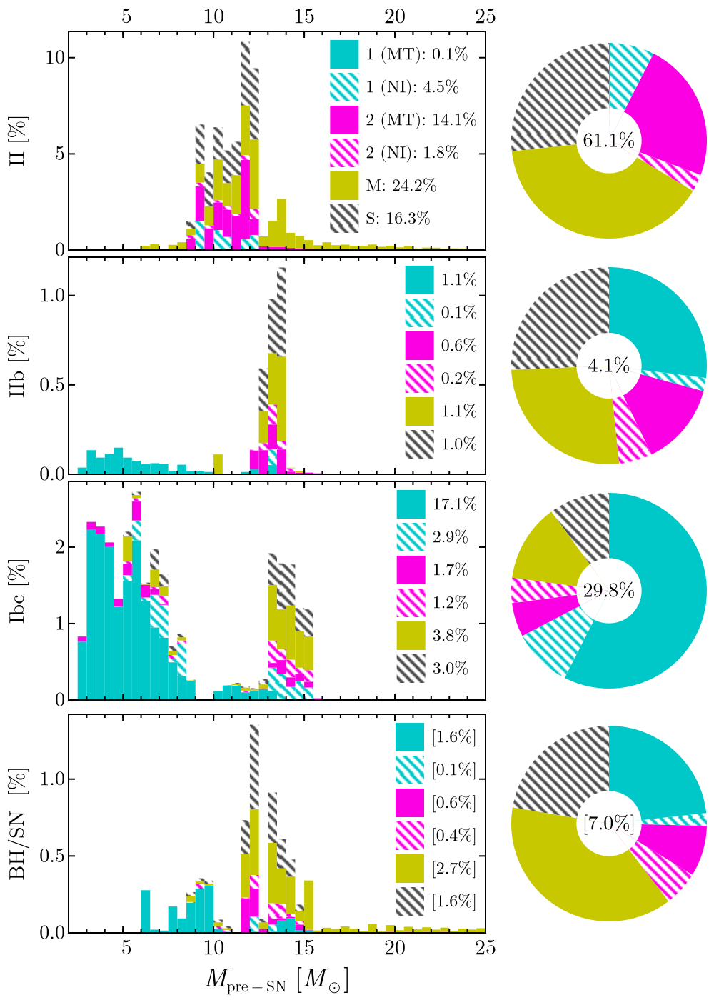

In [7]:
FIG = Figure(size=(500, 700), figure_padding=5)
using StatsBase 
using GeometryBasics

what_to_plot = "Mf"

d1 = 0.5
bins = 0:d1:50
xticks = 0:5:50
xmticks=0:1:50
xticks_t = [@sprintf("%2.0f", t)  for t in xticks ]
limits1=[2, 25]

yticklabelsize=14
ylabelsize=15
xticklabelsize = 14
xlabelsize = 18
yticklabelpad = 1.5
yticklabelspace = 10.
ylabelpadding = 16
legend_margersize = 15

right_axis = 3
left_axis = 1:2
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax1["IIP"] = plot_settings( grid[1,left_axis],
                ylabel = "II [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize, xticklabelsvisible=true, xaxisposition=:top,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["IIb"] = plot_settings( grid[2,left_axis],
                ylabel = "IIb [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["Ibc"] = plot_settings( grid[3,left_axis],
                ylabel = "Ibc [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["BH"] = plot_settings( grid[4,left_axis],
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]",
                ylabel =  "BH/SN  [%]",
                title = "", titlesize=30,
                                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax_pie["IIP"] = Axis( grid[1,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["IIb"] = Axis( grid[2,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["Ibc"] = Axis( grid[3,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["BH"] = Axis( grid[4,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")



                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
sntypes = ["IIP",  "IIb", "Ibc", "BH"]



alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]                     

                     
progenitors = ["1-MT", "1-NI", "2-MT", "2-NI", "M", "S"]

alpha = 1
color_coding["1"]      = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["1-MT"]   = color_coding["1"]
pattern_ni(color) = make_hatch_pattern(size = 64, spacing=7, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))
c_1_ni = pattern_ni(color_coding["1"]) 
color_coding["1-NI"]   =  Pattern(c_1_ni)   
color_coding["2"]      =  RGBAf(250/255,0,227/255,alpha)    
c_2_ni = pattern_ni(color_coding["2"]) 
color_coding["2-MT"]   =  color_coding["2"]    
color_coding["2-NI"]   = Pattern(c_2_ni)  
color_coding["M"]   = RGBAf(200/255, 200/255, 0,alpha)   
color_coding["S"]   = RGBAf(0.3, .3, .3,alpha) 
c_s_ni = pattern_ni(color_coding["S"]) 
color_coding["S"]   =  Pattern(c_s_ni)   





for ttp in sntypes

    hst1 = fit(Histogram,  (SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
    hist1 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist1[prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        length(get_idx(prg, ttp)) == 0 && continue


    end
    y_bars = [hist1[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]

    stacked_barplot!(ax1[ttp], x_bar, y_bars;
                          width=d1, direction=:y, colors=colors)
    
    showlabel = ttp=="IIP"
    brack1, brack2 = (ttp == "BH" ? ("[", "]") : ("", ""))

    barplot!(ax1[ttp], [-100], [0], color = color_coding["1-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (MT): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-MT"][get_idx("1-MT", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["1-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-NI"][get_idx("1-NI", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["2-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (MT): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-MT"][get_idx("2-MT", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["2-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-NI"][get_idx("2-NI", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["M"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "M: "      : "" , brack1, 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])      , brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["S"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "S: "      : "" , brack1, 100*sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)])      , brack2))


    axislegend(ax1[ttp],  position=:rt, framevisible=false,
        nbanks= 1 , titleposition=:left,labelsize=12, rowgap = 3, colgap = 5, padding = 0)



end


for ttp in sntypes
    xlims!(ax1[ttp], 2, 25)
    ylims!(ax1[ttp], 0, nothing)
end 



function sn_pie_chart(ax, SN_DATA, prgs, sn)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs]
    SN_colors  = Any[color_coding[prg] for prg in prgs]
    # SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs_hatch]
    # SN_colors_sub =  Any[color_coding[prg] for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs] ) 
    
    # push!(SN_numbers,     100*(1 - normer))
    # push!(SN_numbers_sub, 100*(1 - normer))
    # push!(SN_colors, :white)
    # push!(SN_colors_sub, :white)


    hatched_pie!(ax, reverse!(SN_numbers),
         colors=reverse!(SN_colors), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 0)
    pie!(ax, SN_numbers, 
         color=RGBAf(1,1,1,1), offset = pi/2, inner_radius = 0, radius = 0.333, strokewidth = 0)
    
    # print(SN_numbers, "\n")
    return normer 

end

progenitors_int_and_non = ["1", "2", "M", "S"]
progenitors_st = ["1-MT", "1-NI", "2-MT", "2-NI", "M", "S"]
sntypes =     ["IIP",   "IIb", "Ibc", "BH"]

for sn in sntypes
    tt = sn
    tot_sn_tt = sn_pie_chart(ax_pie[sn], SN_DATA, progenitors_st, sn)
    brack1, brack2 = (sn == "BH" ? ("[", "]") : ("", ""))
    text!(ax_pie[tt], 0., 0, text=@sprintf("%s%.1f%%%s", brack1, 100*tot_sn_tt, brack2), rotation =0,  align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    ax_pie[sn].rightspinevisible = false
    ax_pie[sn].topspinevisible = false
    ax_pie[sn].leftspinevisible = false
    ax_pie[sn].bottomspinevisible = false
    xlims!(ax_pie[sn],-1, 1)
    ylims!(ax_pie[sn],-1, 1)

end
 
     

    


rowgap!(grid, 1,   5)
rowgap!(grid, 2,   5)
rowgap!(grid, 3,  10)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"
outfilename = @sprintf("bar_MpreSN_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



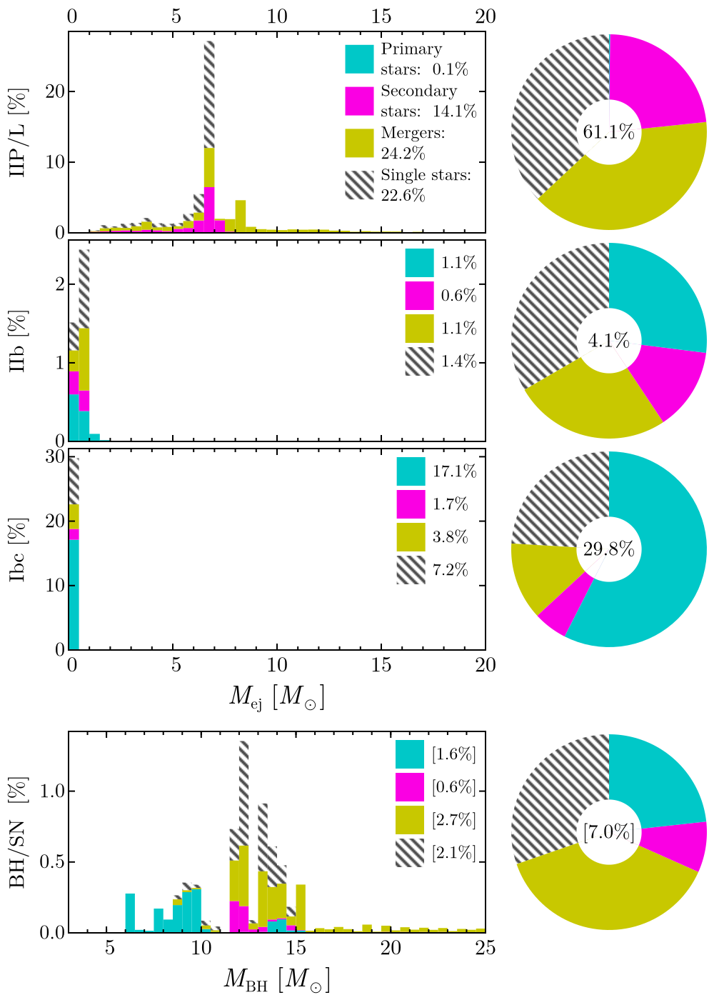

In [3]:
FIG = Figure(size=(500, 700), figure_padding=5)
using StatsBase 
using GeometryBasics

what_to_plot = "Menv"

d1 = 0.5
bins = 0:d1:50
xticks = 0:5:50
xmticks=0:1:50
xticks_t = [@sprintf("%2.0f", t)  for t in xticks ]
limits1=[0, 25]

yticklabelsize=14
ylabelsize=15
xticklabelsize = 14
xlabelsize = 18
yticklabelpad = 1.5
yticklabelspace = 10.
ylabelpadding = 16
legend_margersize = 15

right_axis = 3
left_axis = 1:2
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax1["IIP"] = plot_settings( grid[1,left_axis],
                ylabel = "IIP/L [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize, xticklabelsvisible=true, xaxisposition=:top,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["IIb"] = plot_settings( grid[2,left_axis],
                ylabel = "IIb [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["Ibc"] = plot_settings( grid[3,left_axis],
                ylabel = "Ibc [%]",
                xlabel = L"M_\mathrm{ej} \ [M_\odot]",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["BH"] = plot_settings( grid[4,left_axis],
                xlabel = L"M_\mathrm{BH} \ [M_\odot]",
                ylabel =  "BH/SN  [%]",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax_pie["IIP"] = Axis( grid[1,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["IIb"] = Axis( grid[2,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["Ibc"] = Axis( grid[3,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_pie["BH"] = Axis( grid[4,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")



                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
sntypes = ["IIP",  "IIb", "Ibc", "BH"]



alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]                     


progenitors = ["1-MT",   "2-MT",  "M", "S+NI"]

alpha = 1
color_coding["1"]      = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["1-MT"]   = color_coding["1"]
pattern_ni(color) = make_hatch_pattern(size = 70, spacing=7, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))
c_1_ni = pattern_ni(color_coding["1"]) 
color_coding["1-NI"]   =  Pattern(c_1_ni)   
color_coding["2"]      =  RGBAf(250/255,0,227/255,alpha)    
c_2_ni = pattern_ni(color_coding["2"]) 
color_coding["2-MT"]   =  color_coding["2"]    
color_coding["2-NI"]   = Pattern(c_2_ni)  
color_coding["M"]   = RGBAf(200/255, 200/255, 0,alpha)   
color_coding["S"]   = RGBAf(0.3, .3, .3,alpha) 
c_s_ni = pattern_ni(color_coding["S"]) 
color_coding["S"]   =  Pattern(c_s_ni)   
color_coding["S+NI"]   = color_coding["S"]





for ttp in sntypes
    what =  (ttp == "BH") ? "Mf" : what_to_plot 
    hst1 = fit(Histogram,  (SN_DATA[what]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
    hist1 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist1[prg] = fit(Histogram,  (SN_DATA[what][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        length(get_idx(prg, ttp)) == 0 && continue


    end
    y_bars = [hist1[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]

    stacked_barplot!(ax1[ttp], x_bar, y_bars;
                          width=d1, direction=:y, colors=colors)
    
    showlabel = ttp=="IIP"
    brack1, brack2 = (ttp == "BH" ? ("[", "]") : ("", ""))

    barplot!(ax1[ttp], [-100], [0], color = color_coding["1-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "Primary\nstars:  " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-MT"][get_idx("1-MT", ttp)]), brack2))
    # barplot!(ax1[ttp], [-100], [0], color = color_coding["1-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-NI"][get_idx("1-NI", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["2-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "Secondary\nstars:  " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-MT"][get_idx("2-MT", ttp)]), brack2))
    # barplot!(ax1[ttp], [-100], [0], color = color_coding["2-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-NI"][get_idx("2-NI", ttp)]), brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["M"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "Mergers:\n"      : "" , brack1, 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])      , brack2))
    barplot!(ax1[ttp], [-100], [0], color = color_coding["S+NI"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "Single stars:\n"      : "" , brack1, 100*sum(SN_DATA["pdf"]["S+NI"][get_idx("S+NI", ttp)])      , brack2))


    axislegend(ax1[ttp],  position=:rt, framevisible=false,
        nbanks= 1 , titleposition=:left,labelsize=12, rowgap = 3, colgap = 5, padding = 0)



end


for ttp in sntypes
    xlims!(ax1[ttp], 0, 20)
    ylims!(ax1[ttp], 0, nothing)
end 
xlims!(ax1["BH"], 3, 25)



function sn_pie_chart(ax, SN_DATA, prgs, sn)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs]
    SN_colors  = Any[color_coding[prg] for prg in prgs]
    # SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs_hatch]
    # SN_colors_sub =  Any[color_coding[prg] for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for prg in prgs] ) 
    
    # push!(SN_numbers,     100*(1 - normer))
    # push!(SN_numbers_sub, 100*(1 - normer))
    # push!(SN_colors, :white)
    # push!(SN_colors_sub, :white)


    hatched_pie!(ax, reverse!(SN_numbers),
         colors=reverse!(SN_colors), 
         offset = pi/2, inner_radius = 0.0, radius = 1, strokewidth = 0)
    pie!(ax, SN_numbers, 
         color=RGBAf(1,1,1,1), offset = pi/2, inner_radius = 0, radius = 0.333, strokewidth = 0)
    
    # print(SN_numbers, "\n")
    return normer 

end

progenitors_int_and_non = ["1", "2", "M", "S"]
progenitors_st = ["1-MT",   "2-MT",  "M", "S+NI"]
sntypes =     ["IIP",   "IIb", "Ibc", "BH"]

for sn in sntypes
    tt = sn
    tot_sn_tt = sn_pie_chart(ax_pie[sn], SN_DATA, progenitors_st, sn, )
    brack1, brack2 = (sn == "BH" ? ("[", "]") : ("", ""))
    text!(ax_pie[tt], 0., 0, text=@sprintf("%s%.1f%%%s", brack1, 100*tot_sn_tt, brack2), rotation =0,  align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    ax_pie[sn].rightspinevisible = false
    ax_pie[sn].topspinevisible = false
    ax_pie[sn].leftspinevisible = false
    ax_pie[sn].bottomspinevisible = false
    xlims!(ax_pie[sn],-1, 1)
    ylims!(ax_pie[sn],-1, 1)

end
 
     

    


rowgap!(grid,   5)
# rowgap!(grid, 1,   5)
# rowgap!(grid, 2,   5)
rowgap!(grid, 3,  15)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"
outfilename = @sprintf("bar_MpreSN_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



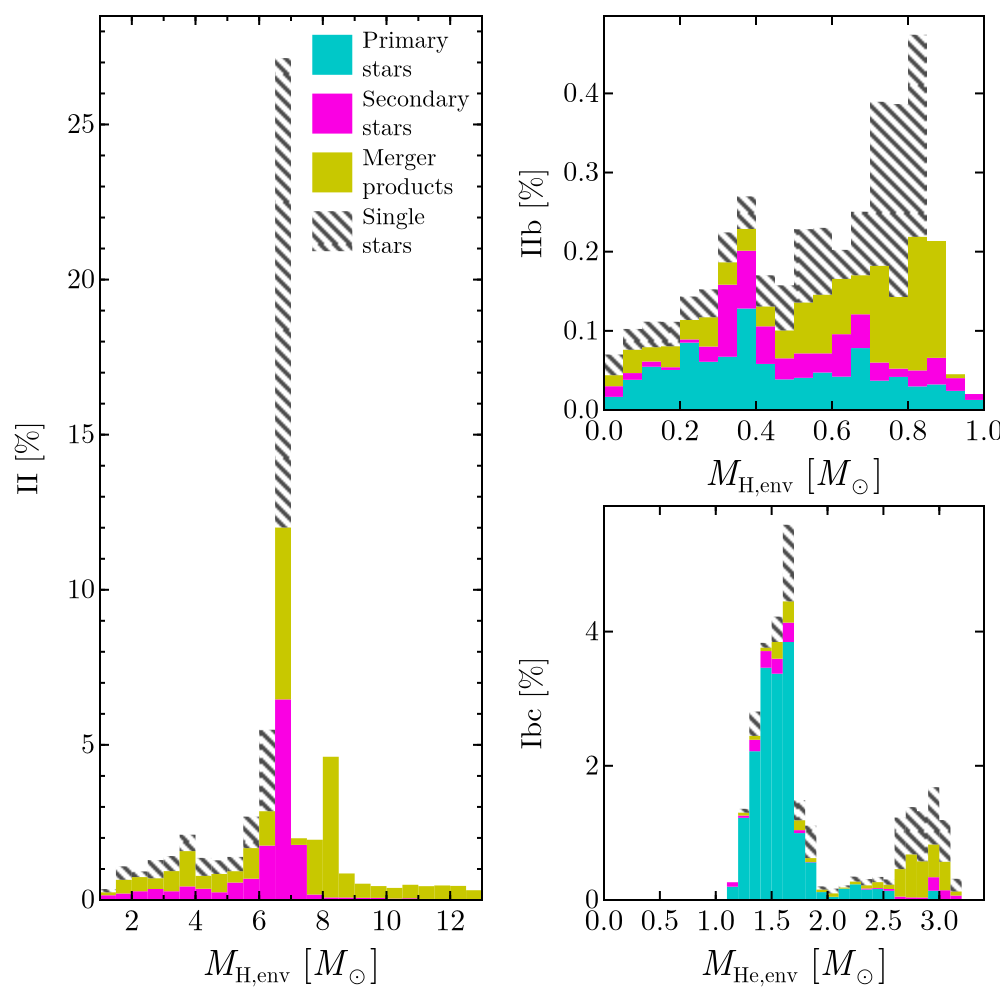

In [18]:
FIG = Figure(size=(500, 500), figure_padding=8)
using StatsBase 
using GeometryBasics

what_to_plot = "Menv"

d1 = 0.25
bins = 0:d1:50
xticks = 0:5:50
xmticks=0:1:50
xticks_t = [@sprintf("%2.0f", t)  for t in xticks ]
limits1=[0, 15]

yticklabelsize=14
ylabelsize=15
xticklabelsize = 14
xlabelsize = 18
yticklabelpad = 1.5
yticklabelspace = 10.
ylabelpadding = 16
legend_margersize = 15

right_axis = 2
left_axis = 1
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax1["IIP"] = plot_settings( grid[1:2,1],
                ylabel = "II [%]",
                xlabel =  L"M_\mathrm{H,env} \ [M_\odot]",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks=  0:2:50, yticks = 0:5:100, ymticks = 0:1:100, xticklabelrotation=0)
ax1["IIb"] = plot_settings( grid[1,right_axis],
                ylabel = "IIb [%]",
                xlabel =  L"M_\mathrm{H,env} \ [M_\odot]",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks=  0:0.2:1, xticklabelrotation=0)
ax1["Ibc"] = plot_settings( grid[2,right_axis],
                ylabel = "Ibc [%]",
                xlabel = L"M_\mathrm{He,env} \ [M_\odot]",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = 15, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks=  0:.5:50, xticklabelrotation=0)
# ax2["IIP"] = plot_settings( grid[1,right_axis],
#                 ylabel = " ",
#                 xlabel =   " ",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks=  0:2:50, xticklabelrotation=0)
# ax2["IIb"] = plot_settings( grid[2,right_axis],
#                 ylabel = " ",
#                 xlabel =  " ",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks=  0:0.2:1, xticklabelrotation=0)
# ax2["Ibc"] = plot_settings( grid[3,right_axis],
#                 ylabel = " ",
#                 xlabel = L"M_\mathrm{NS} \ [M_\odot]",
#                 title = "", titlesize=30,
#                 yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
#                 xticklabelsize = 15, yticklabelsize = yticklabelsize,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
#                 xticks=  0:.5:50, xticklabelrotation=0)



                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
sntypes = ["IIP",  "IIb", "Ibc"]



alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]                     


progenitors = ["1-MT",   "2-MT",  "M", "S+NI"]

alpha = 1
color_coding["1"]      = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["1-MT"]   = color_coding["1"]
pattern_ni(color) = make_hatch_pattern(size = 64, spacing=7, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))
c_1_ni = pattern_ni(color_coding["1"]) 
color_coding["1-NI"]   =  Pattern(c_1_ni)   
color_coding["2"]      =  RGBAf(250/255,0,227/255,alpha)    
c_2_ni = pattern_ni(color_coding["2"]) 
color_coding["2-MT"]   =  color_coding["2"]    
color_coding["2-NI"]   = Pattern(c_2_ni)  
color_coding["M"]   = RGBAf(200/255, 200/255, 0,alpha)   
color_coding["S"]   = RGBAf(0.3, .3, .3,alpha) 
c_s_ni = pattern_ni(color_coding["S"]) 
color_coding["S"]   =  Pattern(c_s_ni)   
color_coding["S+NI"]   = color_coding["S"]





for ttp in sntypes
    what_to_plot = ttp !=  "Ibc" ? "Menv" : "Mheshell" 
    d1 =  ttp !=  "Ibc" ? (ttp == "IIP" ? 0.5 : 0.05) : 0.1
    bins = 0:d1:50

    hst1 = fit(Histogram,  (SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)
    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
    hist1 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
        hist1[prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        length(get_idx(prg, ttp)) == 0 && continue
    end
    y_bars = [hist1[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]
    stacked_barplot!(ax1[ttp], x_bar, y_bars;
                          width=d1, direction=:y, colors=colors)
    
    if ttp=="IIP"
        brack1, brack2 = (ttp == "BH" ? ("[", "]") : ("", ""))

        barplot!(ax1[ttp], [-100], [0], color = color_coding["1-MT"], label = "Primary\nstars")
        # barplot!(ax1[ttp], [-100], [0], color = color_coding["1-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-NI"][get_idx("1-NI", ttp)]), brack2))
        barplot!(ax1[ttp], [-100], [0], color = color_coding["2-MT"], label = "Secondary\nstars")
        # barplot!(ax1[ttp], [-100], [0], color = color_coding["2-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-NI"][get_idx("2-NI", ttp)]), brack2))
        barplot!(ax1[ttp], [-100], [0], color = color_coding["M"],    label = "Merger\nproducts")
        barplot!(ax1[ttp], [-100], [0], color = color_coding["S+NI"],    label = "Single\nstars")


        axislegend(ax1[ttp],  position=:rt, framevisible=false,
            nbanks= 1 , titleposition=:left,labelsize=12, rowgap = 3, colgap = 5, padding = 0)
    end


end



# for ttp in sntypes
#     what_to_plot = "M_rem" 
#     d1 =   0.05
#     bins = 0:d1:50

#     hst1 = fit(Histogram,  (SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)
#     pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
#     x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
#     hist1 = Dict() 
#     for prg in progenitors 
#         pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
#         hist1[prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
#         length(get_idx(prg, ttp)) == 0 && continue
#     end
#     y_bars = [hist1[prg].weights for prg in progenitors]
#     colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]
#     stacked_barplot!(ax2[ttp], x_bar, y_bars;
#                           width=d1, direction=:y, colors=colors)
    


# end

for ttp in sntypes
    ylims!(ax1[ttp], 0, nothing)
    # ylims!(ax2[ttp], 0, nothing)
end 
xlims!(ax1["IIP"], 1, 13)
xlims!(ax1["IIb"], 0, 1)
xlims!(ax1["Ibc"], 0, 3.4)
# xlims!(ax2["IIP"], 1.15, 2.2)
# xlims!(ax2["IIb"], 1.15, 2.2)
# xlims!(ax2["Ibc"], 1.15, 2.2)


    


rowgap!(grid,   5)
# rowgap!(grid, 1,   5)
# rowgap!(grid, 2,   5)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"
outfilename = @sprintf("bar_Menv.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



## Mbar Ibn/Ibc

done 1
[IIP: 5.77] [II-BSG: 0.00] [IIb: 1.49] [Ibc:25.19] [II-i: 2.75] [Ibc-i: 2.97] tot : 38.172934 
done 1
[IIP: 5.77] [II-BSG: 0.00] [IIb: 1.49] [Ibc:25.19] [II-i: 2.75] [Ibc-i: 2.97] tot : 38.172934 


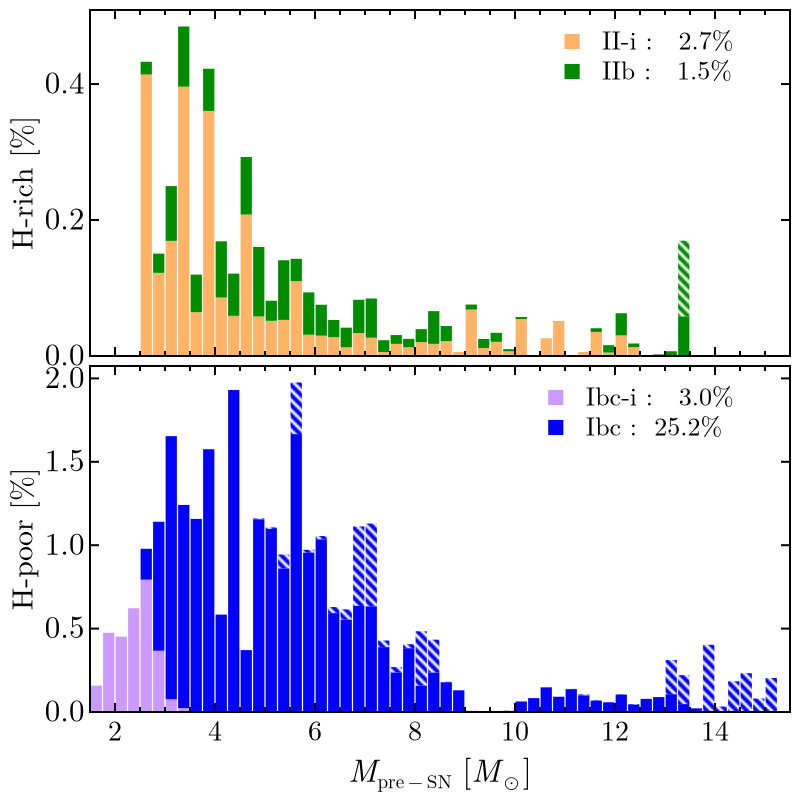

In [3]:

FIG = Figure(size=(400, 400), figure_padding = 5)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.25

bins = 0:d1:30

xticks = 0:2:30
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
xmticks = 0:0.5:30 

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 13.


ax1["1"] = plot_settings( grid[1,left_axis],
                ylabel = "H-rich [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)

ax1["2"] = plot_settings( grid[2,left_axis],
                ylabel = "H-poor [%]",
                xlabel =  L"M_\mathrm{pre-SN} \ [M_\odot]", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)




                
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]



                     

counter = 0
for sntypes in [ ["II-i", "IIb"], ["Ibc-i", "Ibc"]]
    ax = (counter==0 ) ? ax1["1"] : ax1["2"]
    counter+=1
    prg = "1"
    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax, x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax, [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s : %s%4.1f%% %s  ", sn, bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end




for prg in [ "1", "2"]
    xlims!(ax1[prg], 1.5, 15.5)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=13, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5)
colgap!(grid, 5)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_interSN.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



done 1
[IIP: 5.77] [II-BSG: 0.00] [IIb: 1.49] [Ibc:25.19] [II-i: 2.75] [Ibc-i: 2.97] tot : 38.172934 
done 1
[IIP: 5.77] [II-BSG: 0.00] [IIb: 1.49] [Ibc:25.19] [II-i: 2.75] [Ibc-i: 2.97] tot : 38.172934 


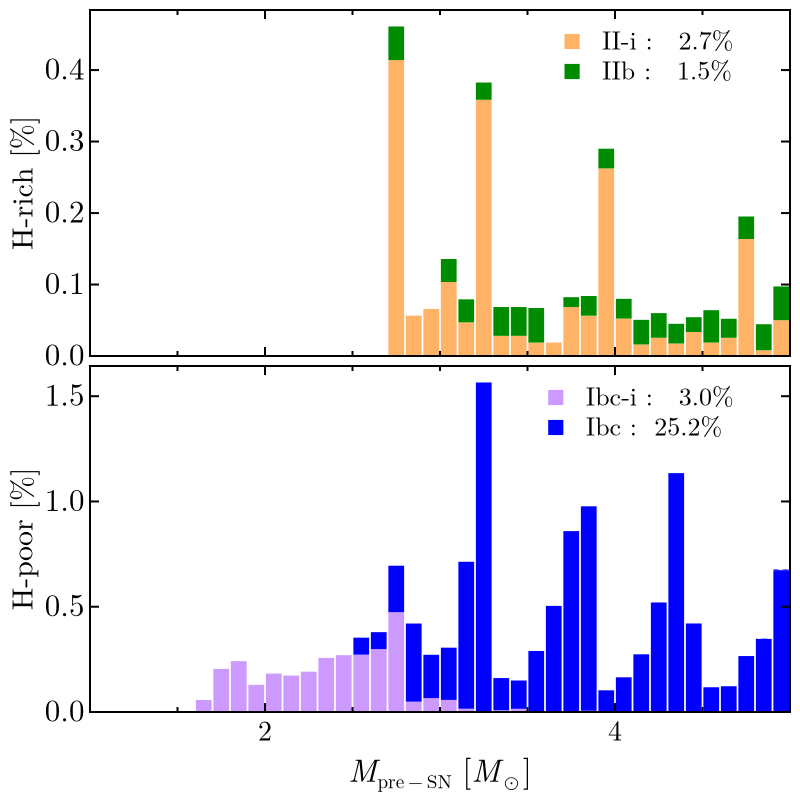

In [7]:

FIG = Figure(size=(400, 400), figure_padding = 5)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.1

bins = 0:d1:30

xticks = 0:2:30
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
xmticks = 0:0.5:30 

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 13.


ax1["1"] = plot_settings( grid[1,left_axis],
                ylabel = "H-rich [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)

ax1["2"] = plot_settings( grid[2,left_axis],
                ylabel = "H-poor [%]",
                xlabel =  L"M_\mathrm{pre-SN} \ [M_\odot]", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)




                
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]



                     

counter = 0
for sntypes in [ ["II-i", "IIb"], ["Ibc-i", "Ibc"]]
    ax = (counter==0 ) ? ax1["1"] : ax1["2"]
    counter+=1
    prg = "1"
    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax, x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax, [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s : %s%4.1f%% %s  ", sn, bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end




for prg in [ "1", "2"]
    xlims!(ax1[prg], 1, 5)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=13, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5)
colgap!(grid, 5)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_interSN.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



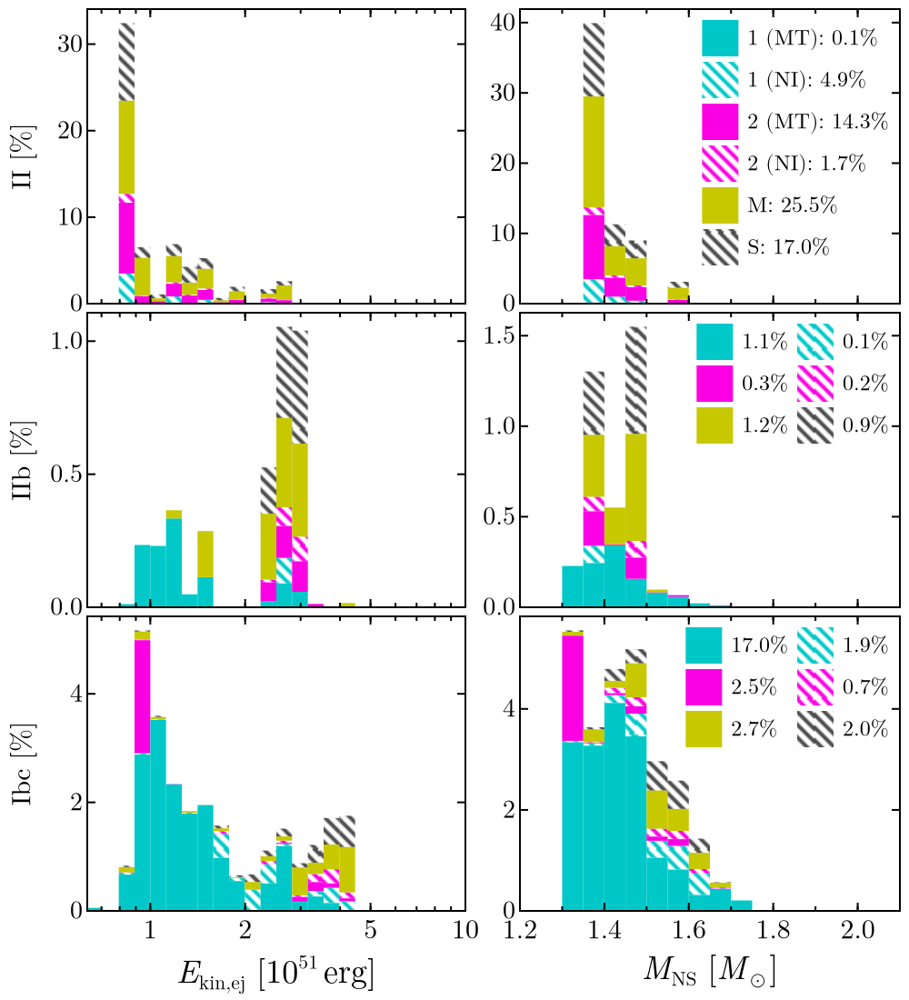

In [56]:

FIG = Figure(size=(500, 550), figure_padding=5)
using StatsBase 
using GeometryBasics

what_to_plot = "E_exp"

d1 = 0.05
bins = 50.6:d1:52
xticks = [log10(1e51), log10(2e51), log10(5e51), log10(1e52)]
xmticks=log10.(union(1e49:1e49:1e50, 1e50:1e50:1e51, 1e51:1e51:1e52))
xticks_t = ["1", "2", "5", "10" ]
limits1=[50.6, 52]


what_to_plot2 = "M_rem"
d2 = 0.05
bins2 = 1.1:d2:2.9
xticks2 = 1.0:0.2:2.2
xmticks2= 1.0:0.1:2.2
xticks_t2 = [@sprintf("%3.1f", t)  for t in xticks2 ]
limits2=[1,2]

yticklabelsize=14
ylabelsize=15
xticklabelsize = 14
xlabelsize = 18
yticklabelpad = 1.5
yticklabelspace = 10.
ylabelpadding = 16
legend_margersize = 15
xticklabelsize = 15 

legend_size = 12
right_axis = 3:4
left_axis = 1:2
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax1["IIP"] = plot_settings( grid[1,left_axis],
                ylabel = "II [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["IIb"] = plot_settings( grid[2,left_axis],
                ylabel = "IIb [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)
ax1["Ibc"] = plot_settings( grid[3,left_axis],
                ylabel = "Ibc [%]",
                xlabel =  L"E_\mathrm{kin,ej} \ [10^{51}\,\mathrm{erg}]",
                title = "", 
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks,
                xticks= (xticks,xticks_t), xticklabelrotation=0)

ax2["IIP"] = plot_settings( grid[1,right_axis],
                ylabel = " ",
                xlabel =  " ",
                title = "", 
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks2,
                xticks= (xticks2,xticks_t2), xticklabelrotation=0)
ax2["IIb"] = plot_settings( grid[2,right_axis],
                ylabel = " ",
                xlabel =  " ",
                title = "", 
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks2,
                xticks= (xticks2,xticks_t2), xticklabelrotation=0)
ax2["Ibc"] = plot_settings( grid[3,right_axis],
                ylabel = " ",
                xlabel =  L"M_\mathrm{NS} \ [M_\odot]",
                title = "", 
                yticklabelpad=yticklabelpad,yticklabelspace=yticklabelspace,ylabelpadding=ylabelpadding,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xmticks=xmticks2,
                xticks= (xticks2,xticks_t2), xticklabelrotation=0)
                
sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
sntypes = ["IIP",  "IIb", "Ibc"]



alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]                     

                     
progenitors = ["1-MT", "1-NI", "2-MT", "2-NI", "M", "S"]

alpha = 1
color_coding["1"]      = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["1-MT"]   = color_coding["1"]
pattern_ni(color) = make_hatch_pattern(size = 64, spacing=7, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))
c_1_ni = pattern_ni(color_coding["1"]) 
color_coding["1-NI"]   =  Pattern(c_1_ni)   
color_coding["2"]      =  RGBAf(250/255,0,227/255,alpha)    
c_2_ni = pattern_ni(color_coding["2"]) 
color_coding["2-MT"]   =  color_coding["2"]    
color_coding["2-NI"]   = Pattern(c_2_ni)  
color_coding["M"]   = RGBAf(200/255, 200/255, 0,alpha)   
color_coding["S"]   = RGBAf(0.3, .3, .3,alpha) 
c_s_ni = pattern_ni(color_coding["S"]) 
color_coding["S"]   =  Pattern(c_s_ni)   





for ttp in sntypes

    hst1 = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1) ]
    hist1 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist1[prg] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins)  
        length(get_idx(prg, ttp)) == 0 && continue


    end
    y_bars = [hist1[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]

    stacked_barplot!(ax1[ttp], x_bar, y_bars;
                          width=d1, direction=:y, colors=colors)
    


    hist2 = fit(Histogram,  (SN_DATA[what_to_plot2]["tot"][get_idx("tot", ttp)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)]*100), bins2)

    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1) ]
    hist2 = Dict() 
    for prg in progenitors 
        pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

        hist2[prg] = fit(Histogram,  (SN_DATA[what_to_plot2][prg][get_idx(prg,ttp)]), weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100), bins2)  
        length(get_idx(prg, ttp)) == 0 && continue

    end
    y_bars2 = [hist2[prg].weights for prg in progenitors]
    colors= [color_coding[progenitors[i]] for i in range(1,length(progenitors)) ]

    stacked_barplot!(ax2[ttp], x_bar2, y_bars2;
                          width=d2, direction=:y, colors=colors)

    showlabel = ttp=="IIP"
    brack1, brack2 = (ttp == "BH" ? ("[", "]") : ("", ""))

    barplot!(ax2[ttp], [-100], [0], color = color_coding["1-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (MT): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-MT"][get_idx("1-MT", ttp)]), brack2))
    barplot!(ax2[ttp], [-100], [0], color = color_coding["1-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "1 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["1-NI"][get_idx("1-NI", ttp)]), brack2))
    barplot!(ax2[ttp], [-100], [0], color = color_coding["2-MT"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (MT): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-MT"][get_idx("2-MT", ttp)]), brack2))
    barplot!(ax2[ttp], [-100], [0], color = color_coding["2-NI"], label = @sprintf("%s%s%.1f%%%s", showlabel ? "2 (NI): " : "" , brack1, 100*sum(SN_DATA["pdf"]["2-NI"][get_idx("2-NI", ttp)]), brack2))
    barplot!(ax2[ttp], [-100], [0], color = color_coding["M"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "M: "      : "" , brack1, 100*sum(SN_DATA["pdf"]["M"][get_idx("M", ttp)])      , brack2))
    barplot!(ax2[ttp], [-100], [0], color = color_coding["S"],    label = @sprintf("%s%s%.1f%%%s", showlabel ? "S: "      : "" , brack1, 100*sum(SN_DATA["pdf"]["S"][get_idx("S", ttp)])      , brack2))


    axislegend(ax2[ttp],  position=:rt, framevisible=false,
        nbanks= ttp == "IIP" ? 1 : 2 , titleposition=:left,labelsize=legend_size, rowgap = 3, colgap = 5, padding = 0)



end


for ttp in sntypes
    xlims!(ax1[ttp],50.8, 52)
    ylims!(ax1[ttp], 0, nothing)
    xlims!(ax2[ttp],1.2,2.1)
    ylims!(ax2[ttp], 0, nothing)
end 


     

    


rowgap!(grid, 1,   5)
rowgap!(grid, 2,   5)

directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"
outfilename = @sprintf("bar_Ek_Mns_type.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



# Case C 

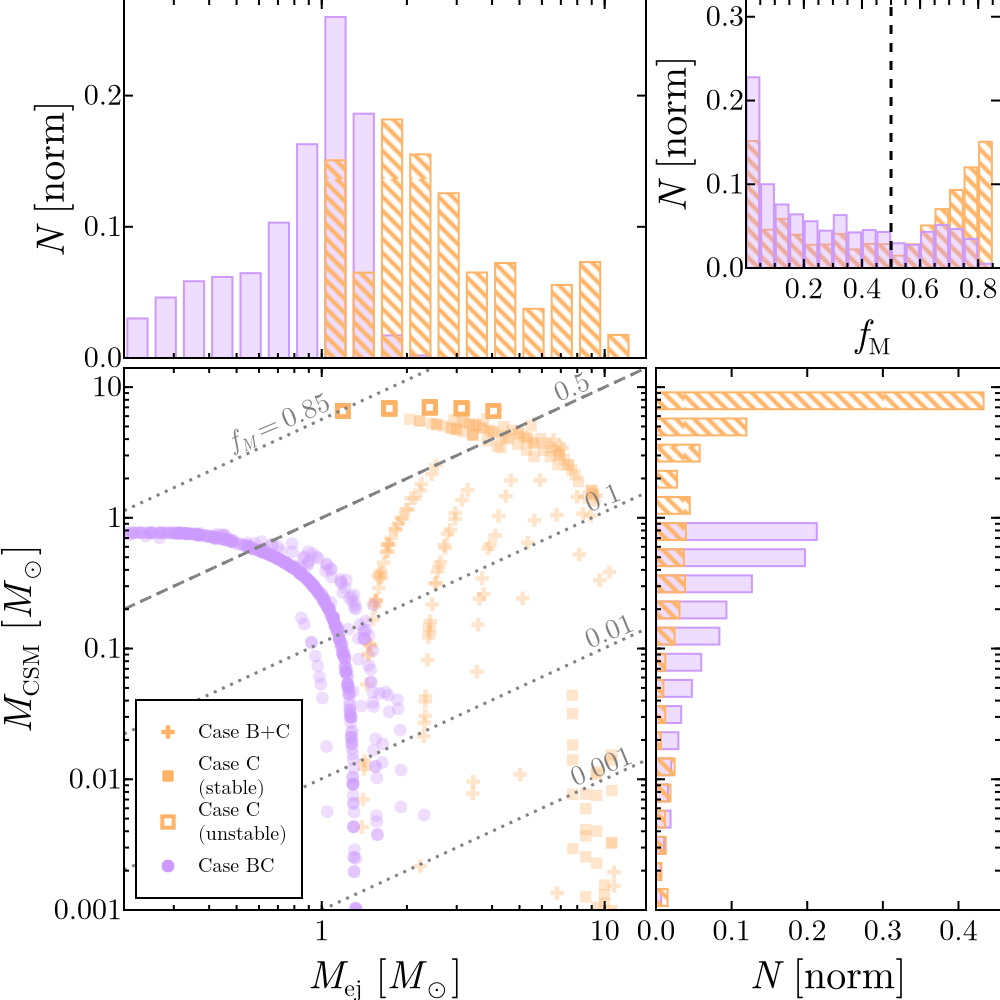

In [7]:



x1  = SN_DATA["Mf"]["1"][get_idx("1", "II-i")]
dx1 = SN_DATA["M_rem_b"]["1"][get_idx("1", "II-i")]
y1 = SN_DATA["dM_C"]["1"][get_idx("1", "II-i")]
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])][get_idx("1", "II-i")]
case = SN_DATA["case"]["1"][get_idx("1", "II-i")]

x2   = SN_DATA["Mf"]["1"][get_idx("1", "Ibc-i")]
dx2 = SN_DATA["M_rem_b"]["1"][get_idx("1", "Ibc-i")]
y2 = SN_DATA["dM_C"]["1"][get_idx("1", "Ibc-i")]
pdf2 = SN_DATA["pdf"]["1"][get_idx("1", "Ibc-i")]

sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
# hatcher = make_hatch_pattern(size=40, spacing=5, thickness=1,  style=:slash,     line_color=color_coding["Ibc-i-cont"], bg_color=RGBAf(0,0,0,0))
# color_coding["Ibc-i2"] = Pattern(hatcher)
hatcher2 = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, direction = :y)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  what[4:end] : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)].*sintheta .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  datascale == log10 ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  1,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 


FIGURE = Figure(size=(500,500), figure_padding = 0)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10)


grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4:5 
grid_top  = 1:2 
grid_bottom = 3:5
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",
            ylabel=L" M_\mathrm{CSM} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [\mathrm{norm}]",
            ylabel=L"M_\mathrm{CSM} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [\mathrm{norm}]", xmticks=mticks,
            title =" ", xscale = log10 
            )
ax_fm = plot_settings(FIGURE[grid_top, grid_right]; 
            xlabel=L"f_\mathrm{M}",
            ylabel=L"N \ [\mathrm{norm}]", 
            title =" ", xscale = identity, 
            xticks=0:0.2:1,#([0.001, 0.01,0.1,1,10], ["0.001", "0.01", "0.1", "1", "10"]),
            xmticks=0:0.05:1#mticks
            )

scatter!(ax, (x1 .- dx1)[case .!== "C"],y1[case .!== "C"],                             color=color_coding["II-i"], marker = :cross, )
scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0,0,0), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
scatter!(ax, (x2 .- dx2)[y2 .> 0],y2[y2 .>.0],                                         color=color_coding["Ibc-i"] )
scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :cross, label = "Case B+C")
scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
scatter!(ax, [1e-99], [1e-99], color=RGBAf(0,0,0,0), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")
scatter!(ax, [1e-99], [1e-99], color=color_coding["Ibc-i-cont"], label = "Case BC")
axislegend(ax,  position=:lb, 
    nbanks=1, titleposition=:left, framealpha=0.5, rowgap =1, colgap =1, labelsize=10)

w = 0.2
run_histogram(ax_dM, "1", "Ibc-i", "dM_C", -3:w:2, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"], datascale = log10, direction = :x)
run_histogram(ax_dM, "1", "II-i", "dM_C",  -3:w:2, w; color=color_coding["II-i2"] , colorcont=color_coding["II-i-cont"], datascale = log10, direction = :x)
w = 0.1
run_histogram(ax_Mend, "1", "Ibc-i", "Mej", -3:w:2, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"],datascale = log10, direction = :y)
run_histogram(ax_Mend, "1", "II-i", "Mej",  -3:w:2, w; color=color_coding["II-i2"] , colorcont=color_coding["II-i-cont"],datascale = log10, direction = :y)
lines!(ax, [0.1,10,100], [0.1, 10, 100], color = :gray, linestyle = :dash)


f_M(Mcsm, Mej) = Mcsm/(Mej+Mcsm)
Mcsm_from_f_M(Mej, f_M) = f_M/(1-f_M) * Mej 
Mejs = [0.1,10,100]
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.85), color = :gray, linestyle = :dot)
text!(ax, 0.5, Mcsm_from_f_M(0.5, 0.85), text = L"f_M=0.85", color = :gray, rotation=pi/8)
text!(ax, 7, Mcsm_from_f_M(7, 0.5), text = L"0.5", color = :gray, rotation=pi/8)
text!(ax, 9, Mcsm_from_f_M(9, 0.1), text = L"0.1", color = :gray, rotation=pi/8)
text!(ax, 9, Mcsm_from_f_M(9, 0.01), text = L"0.01", color = :gray, rotation=pi/8)
text!(ax, 8, Mcsm_from_f_M(8, 0.001), text = L"0.001", color = :gray, rotation=pi/8)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.5), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.1), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.01), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.001), color = :gray, linestyle = :dot)

w = 0.05
scale = identity
run_histogram(ax_fm, "1", "II-i", "f_M",  -3:w:1.1, w; color=color_coding["II-i2"], colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)
run_histogram(ax_fm, "1", "Ibc-i", "f_M", -3:w:1.1, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"], datascale = scale, direction = :y)
lines!(ax_fm, [0.5,0.5], [0, 1], color = :black, linestyle = :dash)


xmin, xmax = 0.2, 14
ymin, ymax = 0.001, 14
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
xlims!(ax_fm, 0.0009, 0.875)
ylims!(ax_fm, 0, 0.32)


colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_stats.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


## II-i multipanel

Tot of elements 359 - filter lenght 359 
extrafilter got 157 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 96 elements.
Tot of elements 359 - filter lenght 1 
extrafilter got 359 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 157 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 96 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 106 elements.


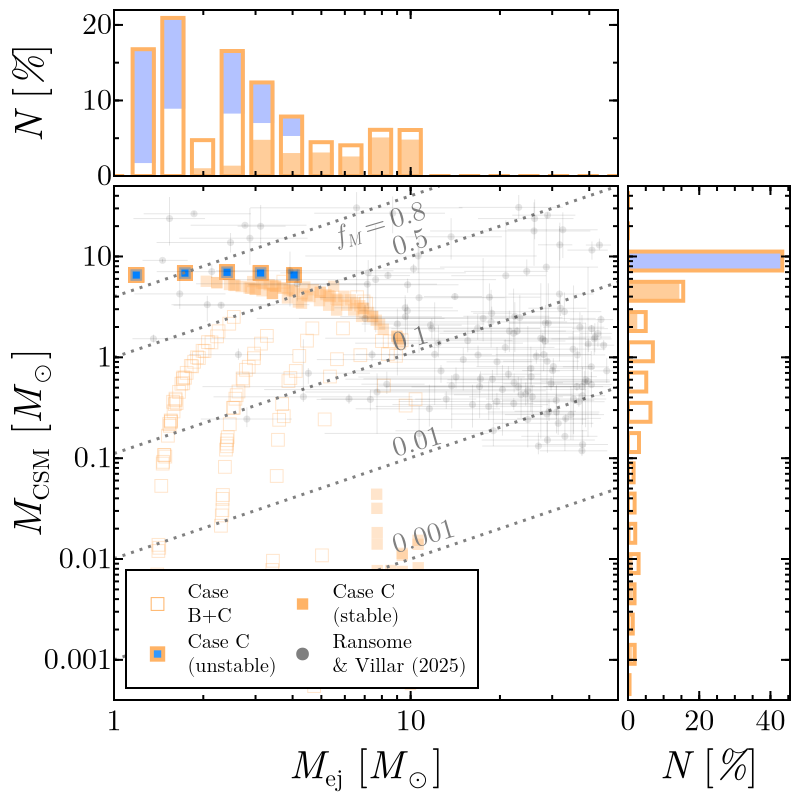

In [6]:



x1  = SN_DATA["Mf"]["1"][get_idx("1", "II-i")]
dx1 = SN_DATA["M_rem_b"]["1"][get_idx("1", "II-i")]
y1 = SN_DATA["dM_C"]["1"][get_idx("1", "II-i")]
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])][get_idx("1", "II-i")]
case = SN_DATA["case"]["1"][get_idx("1", "II-i")]


sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
# hatcher = make_hatch_pattern(size=40, spacing=5, thickness=1,  style=:slash,     line_color=color_coding["Ibc-i-cont"], bg_color=RGBAf(0,0,0,0))
# color_coding["Ibc-i2"] = Pattern(hatcher)
hatcher2 = make_hatch_pattern(size=100, spacing=9, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)
color_coding["II-i2"] =  RGBAf(1,179/255,102/255 , 0.66) 

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  what[4:end] : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)].*sintheta .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  (datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 

function run_histogram_filtered(ax, prg, ttp, what, bins, width; filter = true, color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0
    @printf("Tot of elements %d - filter lenght %d \n", length(get_idx(prg, ttp)), length(filter))

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

    extrafilter = [] 
    if length(filter) > 1
        for ix in range(1,length(get_idx(prg, ttp)))
            filter[ix] && push!(extrafilter, get_idx(prg, ttp)[ix])
        end
    else
        extrafilter = get_idx(prg, ttp)
    end
    @printf("extrafilter got %d elements.\n", length(extrafilter))
    # (length(extrafilter) != length(get_idx(prg, ttp))) && throw(ErrorException("Filter and Data have different sizes!"))
    
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what || occursin("f_M", what) )
        data = datascale.(SN_DATA[what][prg][extrafilter])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  parse(Float64, what[4:end]) : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][extrafilter] ./(SN_DATA["Mej"][prg][extrafilter].*sintheta .+ SN_DATA["dM_C"][prg][extrafilter])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][extrafilter]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][extrafilter]/pdf)
 
    reverse_f(x) = ( datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

     to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)

    return x_bar, y_bar
end 

function run_histogram(ax, data_raw, pdf_data, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1, norm = true)
    (length(data_raw) == 0)           && return 0
    (length(data_raw) != length(pdf_data)) && throw(ErrorException("Data and pdf are not the same size"))

    data = nothing 
    normalize = typeof(norm) == Bool ? (norm ? sum(pdf_data) : 1) : norm 
    data = datascale.(data_raw)
    dataweights = weights(pdf_data / normalize)

    reverse_f(x) =  (datascale == log10 && !keep_log ) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
    return x_bar, y_bar

end 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10, 10:10:100)


# grid = FIGURE[1:5, 1:5] = GridLayout()
# grid_left = 1:3
# grid_right = 4:5 
# grid_top  = 1:2 
# grid_bottom = 3:5
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4
grid_top  = 1 
grid_bottom = 2:4
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",
            ylabel=L" M_\mathrm{CSM} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks, ylabelpadding=-5,
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [%]",
            xticks =( 0:0.2:1, [@sprintf("%.0d", i*100) for i in 0:0.2:1]), xmticks=0:0.05:1,
            ylabel=L"M_\mathrm{CSM} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,

            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [%]", xmticks=mticks,
            title =" ", xscale = log10, ylabelpadding=15,
            yticks =( 0:0.1:1, [@sprintf("%.0d", i*100) for i in 0:0.1:1]), ymticks=0:0.05:1
            )
# ax_fm = plot_settings(FIGURE[grid_top, grid_right]; 
#             xlabel=L"f_{M}",
#             ylabel=L"N \ [\mathrm{norm}]", 
#             title =" ", 
#             xticks=([-3, -2, -1, 0, 1], ["0.001", "0.01", "0.1", "1", "10"]),
#             xmticks=log10.(mticks)
#             )

f_stableC = q1 .>= 0.7 .|| case .!= "C"
f_unstabC = q1 .<  0.7 .&& case .== "C"

scatter!(ax, (x1 .- dx1)[case .!== "C"],y1[case .!== "C"],                             color=color_coding["II-i"], marker = '□', )
scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0.5,1,0.3), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = '□', label = "Case\nB+C")
scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0.5,1,0.8), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")
scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0,0,0.5), marker = :circle,   label ="Ransome\n& Villar (2025)")





# maxMej = 0
# Mend = 0 
# Mrem = 0
# Mhe_end = 0
# first_SN_was = nothing
# for logM in keys(MODELS)
#     for logP in keys(MODELS["1.10"]) 
#         for q in keys(MODELS["1.10"]["1.00"])

#             mod=MODELS[logM][logP][q]
#             !(mod["SN2"]["IIP"]>0 || mod["SN2"]["IIb"]>0 || mod["SN2"]["II-i"] > 0) && continue 

#             Mej = mod["M2end"] -mod["endvals2"].M_remnant_b
#             if Mej > maxMej 
#                 maxMej = Mej
#                 Mend = mod["M2end"]
#                 Mrem = mod["endvals2"].M_remnant_b
#                 Mhe_end = mod["M2_he"]
#                 first_SN_was = mod["SN1"]
#             else
#                 continue 
#             end
#         end
#     end
# end

# @printf("Max Mej  = %.2f\n", maxMej)
# @printf("Max Mcsm = %.2f\n", Mend-Mhe_end)
# @printf("Mend = %.2f, Mns = %.2f, Mhe = %.2f\n", Mend, Mrem, Mhe_end)
# print(first_SN_was)
# lines!(ax, ((Mend-0.1):-0.1:Mhe_end) .- Mrem, 0.1:0.1:(Mend-Mhe_end),  color=:red,   label ="max Ej+CSM\n2nd SN", linestyle = :dash)



axislegend(ax,  position=:lb, 
    nbanks=2, titleposition=:left, framealpha=0.5, rowgap =3, colgap =3, labelsize=10)


f_stableC   = q1 .>= 0.7 .&& case .== "C" .&& y1 .>= 0.001
f_stableC   = q1 .>= 0.7 .&& case .== "C"  
f_stableC_F = q1 .>= 0.7 .&& case .== "C" .&& y1 .<  0.001
f_unstabC   = q1 .<  0.7 .&& case .== "C" .&& y1 .>= 0.001
f_unstabC   = q1 .<  0.7 .&& case .== "C" 
f_unstabC_F = q1 .<  0.7 .&& case .== "C" .&& y1 .<  0.001
f_BC   =      case .!= "C" .&& y1 .>= 0.001
f_BC   =      case .!= "C"  
f_BC_F =      case .!= "C" .&& y1 .<  0.001





f_M(Mcsm, Mej) = Mcsm/(Mej+Mcsm)
Mcsm_from_f_M(Mej, f_M) = f_M/(1-f_M) * Mej 
Mejs = 0.01:0.01:100
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.80), color = :gray, linestyle = :dot)
text!(ax, 5.8, Mcsm_from_f_M(5.8, 0.65), text = L"f_M=0.8", color = :gray, rotation=pi/11)
text!(ax, 9, Mcsm_from_f_M(9, 0.5), text = L"0.5", color = :gray, rotation=pi/11)
text!(ax, 9, Mcsm_from_f_M(9, 0.1), text = L"0.1", color = :gray, rotation=pi/11)
text!(ax, 9, Mcsm_from_f_M(9, 0.01), text = L"0.01", color = :gray, rotation=pi/11)
text!(ax, 9, Mcsm_from_f_M(10, 0.001), text = L"0.001", color = :gray, rotation=pi/11)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.5), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.1), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.01), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.001), color = :gray, linestyle = :dot)


f_obs_IIn = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/RansomeVillar25_IIn.data", 
            DataFrame, header=64, delim=" ", ignorerepeated=true)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)

w = 0.3
run_histogram_filtered(ax_dM, "1", "II-i", "dM_C",  -4:w:2, w*1.1; filter = f_unstabC,   color=RGBAf(0,0.2,1,0.3),            colorcont=:white,                    datascale = log10, direction = :x)
run_histogram_filtered(ax_dM, "1", "II-i", "dM_C",  -4:w:2, w*1.1; filter = f_stableC,   color=color_coding["II-i2"],         colorcont=:white,                    datascale = log10, direction = :x)
run_histogram_filtered(ax_dM, "1", "II-i", "dM_C",  -4:w:2, w*1.1;                       color=RGBAf(0,0,0,0),                colorcont=color_coding["II-i-cont"], datascale = log10, direction = :x, strokewidth=2)
# run_histogram(ax_dM, (f_obs_IIn.Mcsm), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=:gray, datascale = log10, direction = :x)

w = 0.10
scale = log10
xb, yb1  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_unstabC,   color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
stacked_barplot!(ax_Mend, log10.(xb), [yb2, yb3, yb1], 
                    width=w*0.8, colors = [color_coding["II-i2"], RGBAf(0,0,0,0), RGBAf(0,0.2,1,0.3)])
run_histogram(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; color=RGBAf(0,0,0,0) , colorcont=color_coding["II-i-cont"],datascale = scale, direction = :y, strokewidth=2)
# run_histogram(ax_Mend, (f_obs_IIn.Mej), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=RGBAf(0,0,0,0.5), datascale = log10, direction = :y)

# w = 0.1333
# scale = log10
# xb, yb1 = run_histogram_filtered(ax_fm, "1", "II-i", "f_M",  -4:w:1.1, w; filter = f_unstabC,   color=RGBAf(0,0.2,1,0.3),     colorcont=:white, datascale = scale, keep_log = true, direction = :y, to_plot=false)
# _,  yb2 = run_histogram_filtered(ax_fm, "1", "II-i", "f_M",  -4:w:1.1, w; filter = f_stableC,   color=color_coding["II-i2"],  colorcont=:white, datascale = scale, keep_log = true, direction = :y, to_plot=false)
# # _,  yb3 = run_histogram_filtered(ax_fm, "1", "II-i", "f_M",  -4:w:1.1, w; filter = f_BC,        color=color_coding["II-i2"],  colorcont=:white, datascale = scale, keep_log = true, direction = :y, to_plot=false)
# print(xb, "\n") 
# stacked_barplot!(ax_fm, (xb), [yb2,  yb1], 
#                     width=w*0.8, colors =  [color_coding["II-i2"],  RGBAf(0,0.2,1,0.3)])
# run_histogram_filtered(ax_fm, "1", "II-i", "f_M",  -4:w:1.1, w;                       color=RGBAf(0,0,0,0),                colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)
# E_sn = 1/2 .* f_obs_IIn.Mej .* Msun .* (f_obs_IIn.vej .* km) .^ 2
# # run_histogram(ax_fm,  (10 .^ f_obs_IIn.E_LC200) ./ (E_sn), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:1.1, w; color=RGBAf(0,0,0,0.), colorcont=RGBAf(0,0,0,0.25), datascale = log10, keep_log=true, direction = :y)
# # run_histogram(ax_fm,  f_obs_IIn.Mcsm ./( f_obs_IIn.Mcsm .+ f_obs_IIn.Mej), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:1.1, w; color=Pattern(obs_hatch), colorcont=RGBAf(0,0,0,0.5), datascale = log10, keep_log=true, direction = :y)



function add_observation_to_scatter(ax, name, data, marker, color; errors = true, ylog = false, markersize=15)
    x = data["Mej"]
    y = ylog ? Dict("mu"=> 10^data["Mcsm"]["mu"]) : data["Mcsm"] 

    scatter!(ax,   x["mu"], y["mu"], color = color, marker = marker, markersize=markersize)
    if errors 
        if ylog
            y["s+"]= +10^(data["Mcsm"]["mu"] + data["Mcsm"]["s+"]) - 10^data["Mcsm"]["mu"]
            y["s-"]= -10^(data["Mcsm"]["mu"] - data["Mcsm"]["s-"]) + 10^data["Mcsm"]["mu"]
        end
        errorbars!(ax, [x["mu"]], [y["mu"]],
                    [y["s-"]], [y["s+"]],direction=:y, color = color, linewidth=0.5)
        errorbars!(ax, [x["mu"]], [y["mu"]], 
                    [x["s-"]], [x["s+"]], direction=:x, color = color, linewidth=0.5)
    end
end

# RV25 = Dict("Mej"=>Dict(), "Mcsm"=>Dict())
# RV25["Mcsm"] = Dict("mu"=>0.10, "s+"=>0.80, "s-"=>0.57) 
# RV25["Mej"]  = Dict("mu"=>20.1, "s+"=>19.0, "s-"=>14.9) 
# add_observation_to_scatter(ax, L"Ransome\&Villar 2025", RV25, :circle, :black, ylog = true)
scatter!(ax,  [1e-9, 1e-9], color = :gray, marker = :circle, markersize=10, label =  L"Ransome\&Villar 2025" )

for i in range(1,length(f_obs_IIn.SN))
    obs = Dict("Mej"=>Dict(), "Mcsm"=>Dict())
    obs["Mcsm"] = Dict("mu"=>f_obs_IIn.Mcsm[i], 
                       "s+"=>f_obs_IIn[!, "Mcsm+"][i], 
                       "s-"=>f_obs_IIn[!, "Mcsm-"][i]) 
    obs["Mej"] = Dict("mu"=>f_obs_IIn.Mej[i], 
                       "s+"=>f_obs_IIn[!, "Mej+"][i], 
                       "s-"=>f_obs_IIn[!, "Mej-"][i]) 
    add_observation_to_scatter(ax, f_obs_IIn.SN[i], obs, :circle, RGBAf(0,0,0,.1), ylog = false, errors=true, markersize=5)
end

w = 0.2
w = 0.05
w = 0.15
# run_histogram(ax_fm, f_obs_IIn.Mcsm ./ ( f_obs_IIn.Mcsm .+ f_obs_IIn.Mej), f_obs_IIn.Mcsm .* 0 .+ 1, -2:w:2, w*0.8; color=RGBAf(0,0,0,0.0), colorcont=RGBAf(0,0,0,0.5), datascale = identity, direction = :y)

# run_histogram(ax_fm, "1", "II-i", "f_M",  -3:w:1.1, w; color=color_coding["II-i2"], colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)


xmin, xmax = 1, 50
ymin, ymax = 0.0004, 50
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
# xlims!(ax_fm, -2.5, 0.2)
# ylims!(ax_fm, 0, nothing)



colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_stats_IIi.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png



FIGURE


In [24]:
type = "Ibc-i"
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])]
case = SN_DATA["case"]["1"]
dMC = SN_DATA["dM_C"]["1"]

f_stableC   = q1 .>= 0.7 .&& case .== "C"  
f_unstabC   = q1 .<  0.7 .&& case .== "C" 
f_BC        = case .!= "C" 
f_dM        = dMC .> 0.1
the_filter = f_BC
# report_stats(SN_DATA, "Mej",   "1", type; filter=the_filter, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1, "Msun"))
# report_stats(SN_DATA, "E_exp", "1", type; filter=the_filter, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1e51, "1e51 erg"))
# report_stats(SN_DATA, "M_rem", "1", type; filter=the_filter, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1, "Msun"))
# report_stats(SN_DATA, "dM_C",  "1", type; filter=nothing, print2screen = true, format_str = "%6.2f", multip_percentiles=10:0.5:15, unit = (1, "Msun"))

# report_stats(SN_DATA, "M_rem", "1", type; filter=f_stableC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1, "Msun"))
# report_stats(SN_DATA, "M_rem", "1", type; filter=f_unstabC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1, "Msun"))
# report_stats(SN_DATA, "M_rem", "1", type; filter=f_BC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1, "Msun"))


# report_stats(SN_DATA, "E_exp", "1", type; filter=f_stableC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1e51, "1e51 erg"))
# report_stats(SN_DATA, "E_exp", "1", type; filter=f_unstabC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1e51, "1e51 erg"))
# report_stats(SN_DATA, "E_exp", "1", type; filter=f_BC, print2screen = true, format_str = "%5.1f", multip_percentiles=0:5:100, unit = (1e51, "1e51 erg"))

report_stats(SN_DATA, "Mej",  "1", type; filter=nothing, print2screen = true, format_str = "%6.2f", multip_percentiles=0:5:100, unit = (1, "Msun"))
report_stats(SN_DATA, "dM_C",  "1", type; filter=nothing, print2screen = true, format_str = "%6.3f", multip_percentiles=0:1:10, unit = (1, "Msun"))


  Mej -   0.15<  0.91[+  0.57-  0.64]<  2.30 [ Msun]- 
Perc. Analysis
     0     5    10    15    20    25    30    35    40    45    50    55    60    65    70
    75    80    85    90    95   100
  0.15  0.27  0.34  0.42  0.49  0.61  0.69  0.76  0.84  0.90  0.96  1.01  1.07  1.12  1.18
  1.22  1.26  1.29  1.31  1.48  2.30
 dM_C -  0.000< 0.335[+ 0.432- 0.333]< 0.769 [ Msun]- 
Perc. Analysis
     0     1     2     3     4     5     6     7     8     9    10
 0.000 0.000 0.000 0.001 0.001 0.003 0.004 0.005 0.006 0.009 0.010


1-element Vector{Any}:
 [0.33530242834887886, 0.4319936727211187, 0.3327811014988775, 0.29659453516575957]

┌ Warning: Halign outside of (0, 1)!  Be warned.
└ @ Main /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/Plot_defs.jl:415


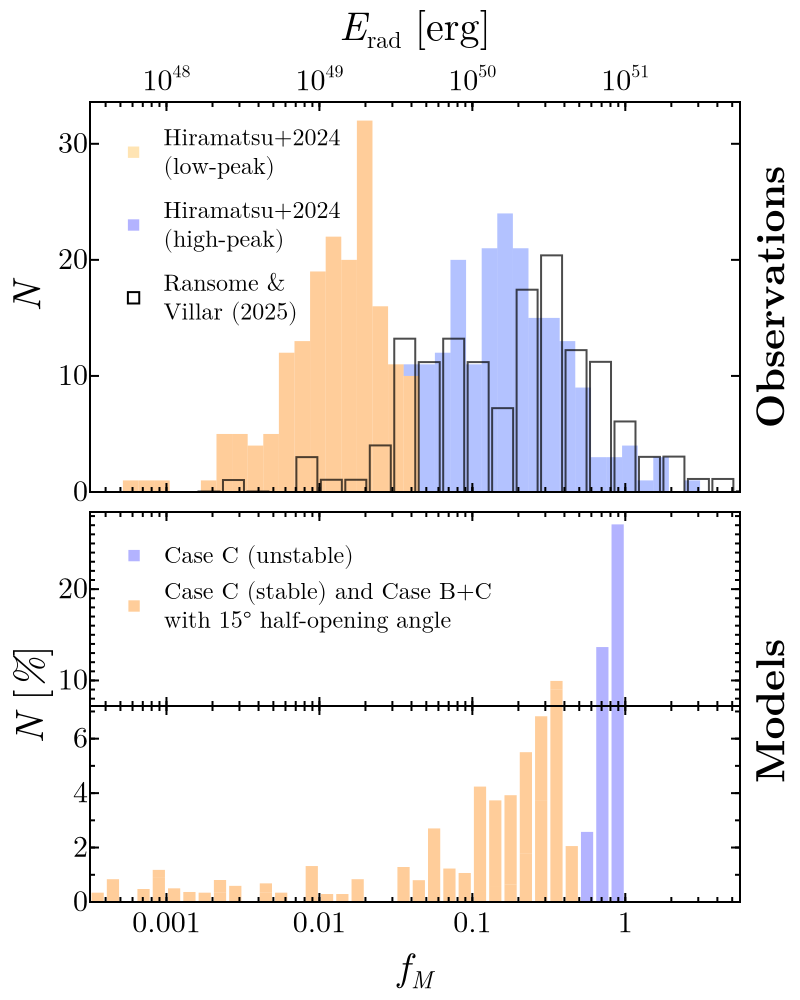

In [7]:
dm = SN_DATA["dM_C"]["1"]
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])]
case = SN_DATA["case"]["1"]

f_stableC   = q1 .>= 0.7 .&& case .== "C" .&& dm .>= 0.001
f_stableC   = q1 .>= 0.7 .&& case .== "C"  
f_stableC_F = q1 .>= 0.7 .&& case .== "C" .&& dm .<  0.001
f_unstabC   = q1 .<  0.7 .&& case .== "C" .&& dm .>= 0.001
f_unstabC   = q1 .<  0.7 .&& case .== "C" 
f_unstabC_F = q1 .<  0.7 .&& case .== "C" .&& dm .<  0.001
f_BC   =      case .!= "C" .&& dm .>= 0.001
f_BC   =      case .!= "C"  
f_BC_F =      case .!= "C" .&& dm .<  0.001
f_IIi = f_BC .|| f_unstabC .|| f_stableC



dM  = SN_DATA["dM_C"]["1"]
Mej = SN_DATA["Mej"]["1"]
f_M(;theta=0, filter = Int[]) = sin.(theta) .* (dM ./ (dM .+ Mej .* sin.(theta)))[get_idx("1", "II-i", filter=filter)]
pdfs(;filter = Int[]) = SN_DATA["pdf"]["1"][get_idx("1", "II-i", filter=filter)]
inch = 96
FIGURE = Figure(size=(400,500), figure_padding = 5, px_per_unit = 600/inch)

mticks = union([k for i in -100:1:100 for k in (10. ^i):(10. ^i):(10. ^ (i+1))])

hticks_val = 0:0.1:1
hticks_flab(ticks) = [@sprintf("%2d", i*100) for i in ticks]
hticks_f(ticks) = (ticks, hticks_flab(ticks))
hmticks = 0:0.025:1


grid = FIGURE[0:3, 1] = GridLayout()

ax_fm = plot_settings(grid[2,1]; 
            xlabel=" ", xticklabelsvisible=false,
            ylabel=" ", 
            title =" ", yticks =hticks_f(0:0.1:1), ymticks=0:0.01:1,
            xticks=([-3, -2, -1, 0, 1], ["0.001", "0.01", "0.1", "1", "10"]),
            xmticks=log10.(mticks), 

            )
ax_fmb = plot_settings(grid[3,1]; 
            xlabel=L"f_{M}", 
            ylabel=L" N \ [%]", ylabelpadding=5, 
            title =" ", yticks =hticks_f(0:0.02:1), ymticks=0:0.01:1,
            xticks=([-3, -2, -1, 0, 1], ["0.001", "0.01", "0.1", "1", "10"]),
            xmticks=log10.(mticks),  
            )
ax_fm2 = plot_settings(grid[0:1,1]; 
            xlabel=L"E_\mathrm{rad} \ [\mathrm{erg}]",
            ylabel=L"N ", 
            title =" ", xaxisposition = :top, 
            xticks=(48:1:52, [L"10^{%$(i)}" for i in 48:1:52]),
            xmticks=log10.(mticks)
            )

ax_fmb_mirror = plot_settings(grid[3,1]; 
            xlabel=" ", xticklabelsvisible=false,
            ylabel=L"\textbf{Models}",yaxisposition = :right,
            title =" ", yticks =[1e100],
            xticks =[1e100],
            )
ax_fm2_mirror = plot_settings(grid[0:1,1]; 
            xlabel=" ",
            ylabel=L"\textbf{Observations}", yaxisposition = :right,
            title =" ", yticks =[1e100],
            xticks =[1e100],
            )


# sideinfo = Label(FIGURE[2:3, 0], "Models", fontsize =20, rotation = pi/2)
# sideinfo = Label(FIGURE[0:1, 0], "Observations", fontsize =20, rotation = pi/2)



f_obs_IIn = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/RansomeVillar25_IIn.data", 
            DataFrame, header=64, delim=" ", ignorerepeated=true)
f_obs_IIn_hist = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/RamsoneVillari25_E200pdf.data", 
            DataFrame, header=1, delim=" ", ignorerepeated=true)

f_obs_H24_low= CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/Hiramatsu24_low.data", 
            DataFrame, header=1, delim=" ", ignorerepeated=true)
f_obs_H24_high= CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/Hiramatsu24_high.data", 
            DataFrame, header=1, delim=" ", ignorerepeated=true)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)
hatcher_inline(style, color) = Pattern(make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=style, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=color))

w = 0.1
scale = log10
xb, yb1 = run_histogram(ax_fmb, f_M(theta=30/360*2*pi, filter = f_stableC), pdfs(filter=f_stableC),  -4:w:1.1, w;   norm = sum(pdfs(filter=f_IIi)),    color=(:blue,    0.20),              datascale = scale, keep_log=true, direction = :y, strokewidth=1, to_plot=false)
 _, yb2 = run_histogram(ax_fmb, f_M(theta=30/360*2*pi, filter = f_BC     ), pdfs(filter=f_BC     ),  -4:w:1.1, w;   norm = sum(pdfs(filter=f_IIi)),    color=(:blue,    0.20),              datascale = scale, keep_log=true, direction = :y, strokewidth=1, to_plot=false)
 _, yb3 = run_histogram(ax_fmb, f_M(theta=pi/2, filter = f_unstabC     ), pdfs(filter=f_unstabC     ),  -4:w:1.1, w;   norm = sum(pdfs(filter=f_IIi)),    color=(:blue,    0.20),           datascale = scale, keep_log=true, direction = :y, strokewidth=1, to_plot=false)
stacked_barplot!(ax_fmb, (xb), [yb1,  yb2, yb3], 
                    width=w*0.8, colors = [color_coding["II-i2"], color_coding["II-i2"], RGBAf(0,0,1,0.3)])
# run_histogram(ax_fmb, f_M(theta=pi/2, filter = f_IIi), pdfs(filter= f_IIi),  -4:w:1.1, w; norm = sum(pdfs(filter=f_IIi)), color=(:blue,    0.0),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1, to_plot=true)
stacked_barplot!(ax_fm, (xb), [yb1,  yb2, yb3], 
                    width=w*0.8, colors = [color_coding["II-i2"], color_coding["II-i2"], RGBAf(0,0,1,0.3)])
# run_histogram(ax_fm, f_M(theta=pi/2, filter = f_IIi), pdfs(filter= f_IIi),  -4:w:1.1, w; norm = sum(pdfs(filter=f_IIi)), color=(:blue,    0.0),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1, to_plot=true)

# run_histogram_filtered(ax_fm, "1", "II-i", "f_M", filter = f_unstabC,   -4:w:1.1, w;  color=(:red,    0.20),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)
w= 0.1
# run_histogram(ax_fm, f_M(theta=pi/2, filter = .! f_unstabC), pdfs(filter=.! f_unstabC),   -4:w:1.1, w;  color=(:red,    0.20),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)
# run_histogram(ax_fm, f_M(theta=pi/2, filter = f_unstabC), pdfs(filter=f_unstabC), norm=sum(pdfs(filter=f_IIi)),   -4:w:1.1, w;  color=(:blue,    0.20),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)
# run_histogram(ax_fm, .5*f_M(theta=pi/6, filter = f_stableC), pdfs(filter=f_stableC),   -4:w:1.1, w;  color=(:green,    0.20),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)
# run_histogram(ax_fm, .5*f_M(theta=15/360*pi, filter = f_stableC), pdfs(filter=f_stableC),   -4:w:1.1, w;  color=(:blue,    0.20),              colorcont=color_coding["II-i-cont"], datascale = scale, keep_log=true, direction = :y, strokewidth=1)


stacked_barplot!(ax_fm2, (f_obs_H24_low.logEtot), [f_obs_H24_low.N , f_obs_H24_high.N ], 
                    width=0.102, colors = [color_coding["II-i2"], RGBAf(0,0.2,1,0.3)])
run_histogram(ax_fm2,  f_obs_IIn_hist.logE200 , f_obs_IIn_hist.N, (49.00-0.16/2*10):0.16:60, 0.156; norm=sum(f_obs_IIn_hist.N)/142, color=RGBAf(0,0,0,0.), colorcont=RGBAf(0,0,0,0.7), direction = :y)

scatter!(ax_fm, [-99, -99], [1e-9, 1e-9], color = (:blue, 0.3),   label = "Case C (unstable)", marker = :rect)
scatter!(ax_fm, [-99, -99], [1e-9, 1e-9], color =color_coding["II-i2"],        label = "Case C (stable) and Case B+C\nwith 15° half-opening angle",   marker = :rect)
# scatter!(ax_fm, [-99, -99], [1e-9, 1e-9], color = :white,       strokewidth = 1, strokecolor = :orange, label = "Case B + C",        marker = :rect)
axislegend(ax_fm, position=:lt, labelsize=12, rowgap = 2, framevisible = false)

scatter!(ax_fm2, [-99, -99], [1e-9, 1e-9], color = (:orange, 0.3), label = "Hiramatsu+2024\n(low-peak)", marker = :rect)
scatter!(ax_fm2, [-99, -99], [1e-9, 1e-9], color = (:blue, 0.3)  , label = "Hiramatsu+2024\n(high-peak)",   marker = :rect)
scatter!(ax_fm2, [-99, -99], [1e-9, 1e-9], color = :white, strokecolor = :black, strokewidth=1,  label = "Ransome &\nVillar (2025)",   marker = :rect)
axislegend(ax_fm2, position=:lt, labelsize=12, rowgap = 10, framevisible = false)

xmin = -3.5
xmax = 0.75
ycut = 0.072
xlims!(ax_fm,xmin, xmax)
ylims!(ax_fm,ycut, nothing)
xlims!(ax_fmb,xmin, xmax)
ylims!(ax_fmb, 0.0, ycut)

ylims!(ax_fm2,0.0, nothing)
xlims!(ax_fm2, 51+xmin, 51+xmax)


save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("IIn_compare.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

rowgap!(grid, 3, 0)
rowgap!(grid, 2, 10)
rowgap!(grid, 1, 0)


move_axislabel!(ax_fmb, which = :y, align = 0.25)
move_axislabel!(ax_fmb_mirror, which = :y, align = 1.3)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_IIi_fm.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


In [214]:
"""
    count_matches(list1::Vector{String}, list2::Vector{String}; partial::Bool=false)

Returns a tuple `(count, matches)` where:
- `count` is the number of elements in `list1` that match any element in `list2`
- `matches` is a list of those elements

If `partial=true`, also includes partial matches where all but one letter are the same.
"""
function count_matches(list1, list2; partial=false)
    matches = String[]
    
    for word1 in list1
        if word1 in list2
            push!(matches, word1)
        elseif partial
            for word2 in list2
                if length(word1) == length(word2) &&
                   count(!=, word1, word2) == 1
                    push!(matches, word1)
                    break
                end
            end
        end
    end

    return length(matches), matches
end



HiramatsuList = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/Hiramatsu24_SNlist.data", 
            DataFrame, header=1, delim=" ", ignorerepeated=true)
names_H = HiramatsuList.SN
names_R = f_obs_IIn.SN 
count_matches(names_R, names_H)

sum(f_obs_H24_low.N/sum(f_obs_H24_low.N .+ f_obs_H24_high.N ))

0.48633879781420764

 PSc130812 - Esn = 1.38e+51  fm = 0.015 => Esn = 9.11e+52
 PSc150582 - Esn = 4.77e+51  fm = 0.096 => Esn = 4.97e+52
 PSc300140 - Esn = 2.48e+51  fm = 0.564 => Esn = 4.40e+51
 PSc550221 - Esn = 1.49e+51  fm = 0.010 => Esn = 1.51e+53
  PTF10qwu - Esn = 1.27e+51  fm = 0.013 => Esn = 9.72e+52
  PTF10weh - Esn = 1.03e+51  fm = 0.072 => Esn = 1.43e+52
  SN2006gy - Esn = 2.58e+51  fm = 0.489 => Esn = 5.27e+51
 SN2020hem - Esn = 2.01e+51  fm = 0.425 => Esn = 4.73e+51
 SN2020uaq - Esn = 1.05e+51  fm = 0.039 => Esn = 2.72e+52
 SN2020vci - Esn = 1.43e+51  fm = 0.011 => Esn = 1.32e+53
 SN2021lhy - Esn = 1.21e+51  fm = 0.534 => Esn = 2.26e+51
 SN2021qug - Esn = 1.11e+51  fm = 0.570 => Esn = 1.95e+51
SN2022aahy - Esn = 1.55e+51  fm = 0.470 => Esn = 3.30e+51
 SN2022mma - Esn = 1.69e+51  fm = 0.476 => Esn = 3.55e+51


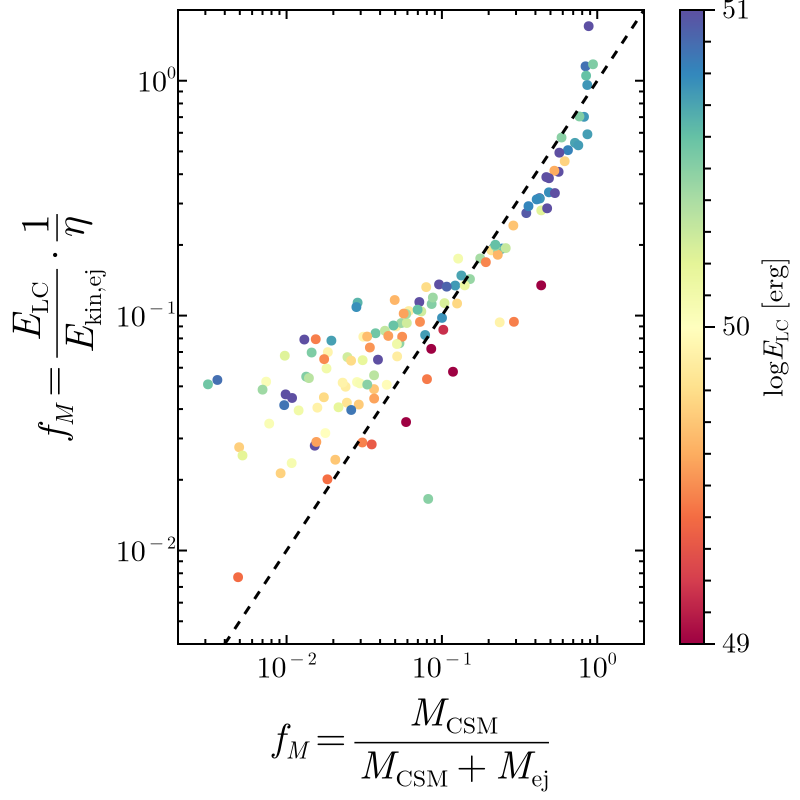

In [53]:
FIGURE = Figure(size=(400,400), figure_padding = 5)
f_obs_IIn = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/RansomeVillar25_IIn.data", 
            DataFrame, header=64, delim=" ", ignorerepeated=true)

ax = plot_settings(FIGURE[1, 1]; 
            xlabel=L"f_M = \frac{M_\mathrm{CSM}}{M_\mathrm{CSM}+M_\mathrm{ej}}",
            ylabel=L"f_M = \frac{E_\mathrm{LC}}{E_\mathrm{kin,ej}} \cdot \frac{1}{\eta}", 
            title =" ", xscale=log10, yscale = log10,
            )

w = 0.10
SN_name = f_obs_IIn.SN
E_LC = 10 .^ f_obs_IIn.E_LC200
E_sn = 1/2 .* f_obs_IIn.Mej .* Msun .* (f_obs_IIn.vej .* km) .^ 2
fm = f_obs_IIn.Mcsm ./ (f_obs_IIn.Mcsm .+ f_obs_IIn.Mej)
vcsm = max.(killnan(f_obs_IIn.vcsm, replacewith=0.), killnan(f_obs_IIn.vcsm_ll, replacewith=-0.))
vej = f_obs_IIn.vej
fv = (vej .- vcsm) ./ vej
fm_eff   = 1/0.5 *  E_LC ./ (E_sn)

# run_histogram(ax, , f_obs_IIn.Mcsm .* 0 .+ 1, -2:w:1, w*0.9; color=RGBAf(0,0,0,0.2), colorcont=RGBAf(0,0,0,0.5), datascale = log10, direction = :y)
# w = 0.05
# run_histogram_filtered(ax, "1", "II-i", "f_M",  -3:w:1.1, w;                       color=RGBAf(0,0,0,0),                colorcont=color_coding["II-i-cont"], datascale = log10, direction = :y, strokewidth=1)
ms = 7
plt = scatter!(ax, fm, fm_eff, color = log10.(E_LC), marker = :circle, markersize = ms, colormap = :Spectral, colorrange=(49,51))
lines!(ax, 10 .^ (-5.:.1:10), 10 .^(-5.:.1:10), linestyle = :dash, color = :black)

for k in range(1,length(f_obs_IIn.SN))
    
    if E_LC[k]>1e51
        @printf("%10s - Esn = %7.2e  fm = %.3f => Esn = %7.2e\n", SN_name[k], E_LC[k], fm[k],  1*E_LC[k]/fm[k])
    end

end
Colorbar(FIGURE[1,2], plt, ticks = 49:1:51, minorticks=49:0.1:51, minorticksvisible=true, label = L"\log E_\mathrm{LC} \ [\mathrm{erg}]")

xlims!(ax, 2e-3, 2e0)
ylims!(ax, 4e-3, 2)
FIGURE
# print(1.26/(20.1+1.26))

In [159]:
xb, yb1  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -4:w:2, w; filter = f_unstabC,   color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -4:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -4:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
@printf("Case C (UNST) %.2f,  case C (STB) %.2f   Case B+C  %.2f", sum(yb1), sum(yb2), sum(yb3))

Tot of elements 359 - filter lenght 359 
extrafilter got 157 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 96 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 106 elements.
Case C (UNST) 0.43,  case C (STB) 0.26   Case B+C  0.31

In [156]:
# FIGURE = Figure(size=(500 * sqrt(2),500))
# ax = plot_settings(FIGURE[1, 1]; 
#     xlabel = L"\log M_\mathrm{i} \ [M_\odot]", 
#     ylabel=L"\log P_\mathrm{i} \ [\mathrm{d}]", xticks=(1:0.05:1.4, [@sprintf("%.2f", i) for i in 1:0.05:1.4]),
#     title ="", mirror_y=false)
function SN_to_C(SN)
    if SN == "WD"
        return RGBAf(0,0,0,0)
    elseif SN == "Ibc-i"
        return RGBAf(1,0,1,0.1)
    elseif SN == "Ibc"
        return RGBAf(0,0,0,0)
    else  
        return RGBAf(0,0,0,0)
    end

end 

function simple_SN(Mco, Mhedep, Mconvhemax, CaseBC,  Mh)
    if isnan(Mconvhemax) .|| (Mh >= 0.001)
        return "X"
    end 


    if ! does_it_CC(Mhe=Mhedep, Mco=Mco, Mconvhe=Mconvhemax)
        return "WD"
    end

    if CaseBC
        return "Ibc-i"
    else
        return "Ibc"
    end


end


dlogms = 0.002
dlogms = 0.005
logms = 0.95:dlogms:1.45
subpoints = Dict("logm"=>[], "logp"=>[], "dM"  => [], "pdf" => [], "Mend" => [])

Salpeter_IMF(x;  power=alpha_m) = x ^ (power)
function integrate_logM(logMmin, logMmax)
    m_min = 10 .^ logMmin
    m_max = 10 .^ logMmax
    return quadgk(m -> Salpeter_IMF(m),  m_min, m_max, rtol=1e-9)
end 
integral_logM, _ = integrate_logM( 0.70-delta, 2.00+delta )

dM_W = []
for i in range(1,length(f_MW.age_1_end_BURN_He_1))
    dm =  f_MW.M_1_end_BURN_He_1[i] .- (f_MW.M_1_ini_RLOF_C[i] > 0 ? f_MW.M_1_ini_RLOF_C[i] : f_MW.M_1_end_1[i])
    push!(dM_W, dm)
end

for q in  0.10:0.05:0.95
    @printf("q : %.2f\n", q)
    for logP in 0.10:0.05:3.70
        (logP % 0.10 == 0) && @printf("     %.2f ", logP)

        ix_submodels = []
        bad_endings = []
        sub_pdf = 0
        for logM in 0.95:0.05:1.45
            model = MODELS[to_key(logM)][to_key(logP)][to_key(q)]
            n = model["mod"]
            bad_ending = (  occursin("mer", model["case"]) || 
                            occursin("IMT", model["case"]) ||
                            model["first"] == "M")
            push!(bad_endings, bad_ending)
            push!(ix_submodels, n)
            sub_pdf = model["pdf"]["logP_q"]
        end

        logM = [x for x in f_MW.logM[ix_submodels]]

        function put_nans(array, ix_isnan) 
            new_array = []
            for ix in range(1,length(array))
                push!( new_array,  ix_isnan[ix] ? NaN : array[ix])
            end
            return new_array
        end

        mx   = put_nans([x for x in f_MW.Mconv_max_Heburn_1[ix_submodels]],        bad_endings)
        dmw  = put_nans([x for x in dM_W[ix_submodels]],                           bad_endings)
        mc   = put_nans([x for x in f_MW.M_co_core_1_end_1[ix_submodels]],         bad_endings)
        mh   = put_nans([x for x in f_MW.M_he_core_1_end_BURN_He_1[ix_submodels]], bad_endings)
        mhend=  mh .- dmw
        max_rad(mconvhe) =  10. .^ log_RL_m["max"](mconvhe)
        R_RL =  put_nans([x for x in f_MW.Rl_1_end_BURN_He_1[ix_submodels]],       bad_endings)
        Rmaxs = [max_rad(m) for m in mx]
        Mhh  =  put_nans([x for x in (f_MW.M_1_end_1-f_MW.M_he_core_1_end_1)[ix_submodels]], bad_endings)
        mr      = (Rmaxs ./ R_RL)
        RLOF_BC = [Rmaxs[i] > R_RL[i] for i in range(1, length(R_RL))]


        f_mx = interpolator(logM, log10.(mx) ;)
        f_mc = interpolator(logM, log10.(mc) ;)
        f_mh = interpolator(logM, log10.(mh) ;)
        f_mhe_end = interpolator(logM, log10.(mhend) ;)
        f_mr = interpolator(logM, log10.(mr) ;)
        f_mhh= interpolator(logM, log10.(Mhh);)

        GRID_SN = [simple_SN(mc[i], mhend[i], mx[i], RLOF_BC[i], Mhh[i]) for i in range(1, length(R_RL))]

        SNs = [simple_SN(10 ^ f_mc(logm), 10 ^ f_mhe_end(logm), 10 ^ f_mx(logm), f_mr(logm)>0, 10 ^f_mhh(logm)) for logm in logms]
        #nearest neighbor 
        for ix in range(1,length(logms))
            (SNs[ix] != "X") && continue 
            
            ix_grid = find_nearest(logM, logms[ix])
            SNs[ix] = GRID_SN[ix_grid]
            #@printf("%5.3f  ->  %5.3f  ::  %3d -> %3d :: %5s\n", logms[ix], logM[ix_grid], ix, ix_grid, SNs[ix])
        end
        ! ( "Ibc-i" in SNs) && continue 
        dt = [ (isnan(mx[i]) || isnan(R_RL[i])) ? NaN : retrieve_tpreCC(mx[i], R_RL[i]) ./ 1e3 for i in range(1,length(R_RL))] 
        dM = 0.789 .* ( 1 .- exp.( .- (dt ./ 5.22) .^ 1.31) )
        f_dm= interpolator(logM, log10.(dM);)


        for i in range(1,length(ix_submodels))
            GRID_SN[i] != "Ibc-i" && continue
            logm = f_MW.logM[ix_submodels[i]]
            logp = f_MW.logP[ix_submodels[i]]

            # scatter!(ax, logm, logp, marker = :circle, markersize = 10, color = SN_to_C(GRID_SN[i]), strokecolor = :black, strokewidth = 1)
            booster = 1.03
            booster2 = 1.1
            delta = 0.005
            # edges = Point2f[(logm-delta/booster, logp-delta/booster2), 
            #                 (logm-delta/booster, logp+delta/booster2), 
            #                 (logm+delta/booster, logp+delta/booster2), 
            #                 (logm+delta/booster, logp-delta/booster2)]
            # poly!(ax, edges, color = SN_to_C(GRID_SN[i]), alpha = 0.5)
        end

        for ix in range(1,length(logms))
            # (logms[ix] in f_MW.logM[ix_submodels]) && continue 
            SNs[ix] != "Ibc-i" && continue
            dM = 10 .^ f_dm(logms[ix])
            isnan(dM) && continue
            # scatter!(ax, logms[ix], logP, marker = :circle, markersize = 5, color = SN_to_C(SNs[ix]))
            push!(subpoints["logm"], logms[ix])
            push!(subpoints["logp"], logP)
            push!(subpoints["dM"],    dM)
            push!(subpoints["Mend"], 10 .^f_mhe_end(logms[ix]) .- dM)
            pdf_logM, _ = integrate_logM(logms[ix]-dlogms/2, logms[ix]+dlogms/2)
            push!(subpoints["pdf"], sub_pdf * pdf_logM/integral_logM  )
        end

    end    
    @printf("\n")

end 
# xlims!(ax, 0.95,1.45)
# ylims!(ax, 0.3,3)



# FIGURE


q : 0.10
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.15
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.20
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.25
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.30
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.35
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.40
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.45
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.50
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.55
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.60
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.65
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.70
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.75
     0.10      0.20      0.40      0.80      1.60      3.20 
q : 0.80
     0.10  

## logP-logM diagram

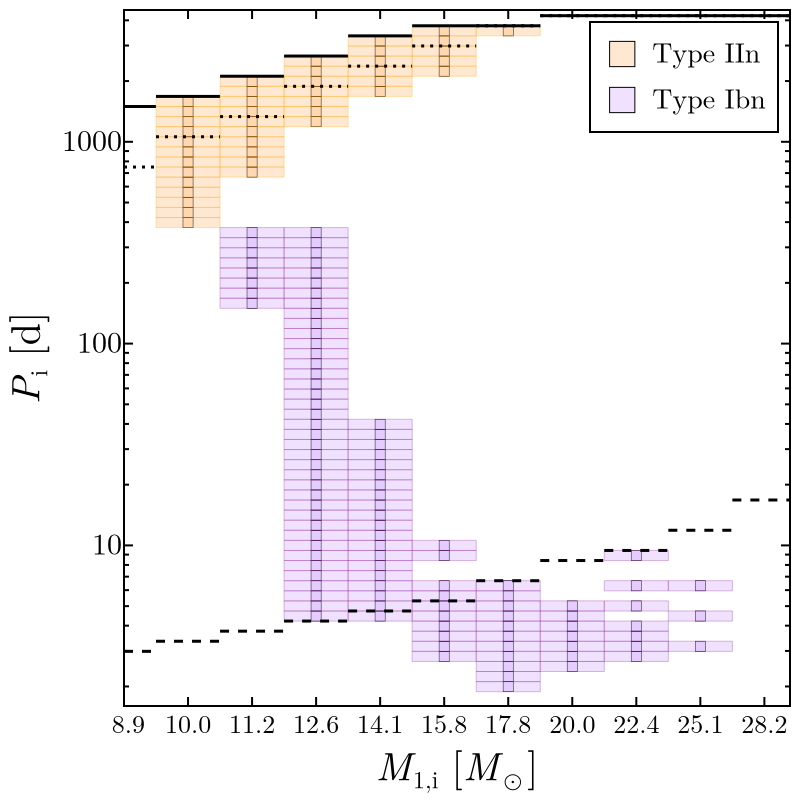

In [ ]:
logPs_IIi = Dict()
logPs_Ibci = Dict()
CaseA = Dict()
CaseB = Dict()
CaseC = Dict()
alpha = 0.3
color_coding = Dict()
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(102/255,0,0,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 

# @printf("analyzing logM = ")

for logM in logMs
    # @printf(" %.2f ", logM) 
    logPs_IIi[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)
    logPs_Ibci[to_key(logM)] = Dict("min"=> 5., "max"=>-5.)
    
    CaseA[to_key(logM)]  = Dict("max"=>-5.)
    CaseB[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)
    CaseC[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)

    mod_logM = MODELS[to_key(logM)]
    for logP_t in keys(mod_logM)
        mod_logP = mod_logM[logP_t]
        logP = parse(Float64, logP_t) 
        for q_t in keys(mod_logP) 
            mod = mod_logP[q_t]
            q_t == "0.80" && continue 
            if mod["SN1"]["II-i"]>0 && mod["first"] != "M"
                logPs_IIi[to_key(logM)]["min"] = min(logPs_IIi[to_key(logM)]["min"], logP)
                logPs_IIi[to_key(logM)]["max"] = max(logPs_IIi[to_key(logM)]["max"], logP)
            end
            if mod["SN1"]["Ibc-i"]>0 && mod["first"] != "M"
                logPs_Ibci[to_key(logM)]["min"] = min(logPs_Ibci[to_key(logM)]["min"], logP)
                logPs_Ibci[to_key(logM)]["max"] = max(logPs_Ibci[to_key(logM)]["max"], logP)
            end

            length(mod["case"]) < 1 && continue
            ("A" == mod["case"]) && (CaseA[to_key(logM)]["max"] = max(CaseA[to_key(logM)]["max"], logP))
            if occursin("B", mod["case"])
                CaseB[to_key(logM)]["max"] = max(CaseB[to_key(logM)]["max"], logP)
            end 
            if occursin("C", mod["case"])
                CaseC[to_key(logM)]["max"] = max(CaseC[to_key(logM)]["max"], logP)
            end 

        end

    end


    (logPs_IIi[to_key(logM)]["min"] == 5.) && (logPs_IIi[to_key(logM)]["min"] = NaN)
    (logPs_IIi[to_key(logM)]["max"] == -5.) && (logPs_IIi[to_key(logM)]["max"] = NaN)
    (logPs_Ibci[to_key(logM)]["min"] == 5.) && (logPs_Ibci[to_key(logM)]["min"] = NaN)
    (logPs_Ibci[to_key(logM)]["max"] == -5.) && (logPs_Ibci[to_key(logM)]["max"] = NaN)

end

FIG = Figure(size=(400,400), figure_padding=5)

ax = plot_settings(FIG[1,1], xlabel = L"M_\mathrm{1,i} \ [M_\odot]", 
                yticks = ([1.,10.,100., 1000], ["1", "10", "100", "1000"]),
                ylabel = L"P_\mathrm{i} \ [\mathrm{d}]",
                title = "", yscale = log10, xticklabelsize=13,
        xticks = (0:0.05:2, [@sprintf("%4.1f", 10^logm) for logm in 0:0.05:2]))

# scatter!(ax, subpoints["logm"], 10 .^ subpoints["logp"], color =color_coding["Ibc-i"], marker = :rect, markersize=4.75)
ms = 8
mt = :rect
for logm in logMs 
    # ! isnan(logPs_IIi[to_key(logm)]["min"]) && fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
    #              10 .^ [logPs_IIi[to_key(logm)]["min"]-0.05/2, logPs_IIi[to_key(logm)]["min"]-0.05/2], 
    #              10 .^ [logPs_IIi[to_key(logm)]["max"]+0.05/2, logPs_IIi[to_key(logm)]["max"]+0.05/2],
    #              color = color_coding["II-i"])
    # ! isnan(logPs_Ibci[to_key(logm)]["min"]) && fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
    #              10 .^ [logPs_Ibci[to_key(logm)]["min"]-0.05/2, logPs_Ibci[to_key(logm)]["min"]-0.05/2], 
    #              10 .^ [logPs_Ibci[to_key(logm)]["max"]+0.05/2, logPs_Ibci[to_key(logm)]["max"]+0.05/2],
    #              color = color_coding["Ibc-i"])
    if ! isnan(logPs_IIi[to_key(logm)]["min"])
        for logP in logPs_IIi[to_key(logm)]["min"]:0.05:logPs_IIi[to_key(logm)]["max"]
            is_there_at_least_one = false
            for q in 0.10:0.05:0.95
                is_there_at_least_one =  is_there_at_least_one || MODELS[to_key(logm)][to_key(logP)][to_key(q)]["SN1"]["II-i"] > 0
            end
            ! is_there_at_least_one && continue 
            scatter!(ax, [logm], [10^logP], color = color_coding["II-i"], marker = mt, strokewidth=0.3, markersize=ms)
            fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
                 10 .^ [logP-0.05/2, logP-0.05/2], 
                 10 .^ [logP+0.05/2, logP+0.05/2],
                 color = color_coding["II-i"])
                lines!(ax, [logm-0.05/2, logm+0.05/2], 10 .^ [logP-0.05/2, logP-0.05/2], color =  (:orange, 0.3 ), linewidth=0.5)
                lines!(ax, [logm-0.05/2, logm+0.05/2], 10 .^ [logP+0.05/2, logP+0.05/2], color =  (:orange, 0.3 ), linewidth=0.5)
                lines!(ax, [logm-0.05/2, logm-0.05/2], 10 .^ [logP-0.05/2, logP+0.05/2], color =  (:orange, 0.3 ), linewidth=0.5)
                lines!(ax, [logm+0.05/2, logm+0.05/2], 10 .^ [logP-0.05/2, logP+0.05/2], color =  (:orange, 0.3 ), linewidth=0.5)

            end
    end
    if ! isnan(logPs_Ibci[to_key(logm)]["min"])
        for logP in logPs_Ibci[to_key(logm)]["min"]:0.05:logPs_Ibci[to_key(logm)]["max"]
            is_there_at_least_one = false
            for q in 0.10:0.05:0.95
                is_there_at_least_one = is_there_at_least_one || MODELS[to_key(logm)][to_key(logP)][to_key(q)]["SN1"]["Ibc-i"] > 0
            end
            ! is_there_at_least_one && continue 

            scatter!(ax, [logm], [10^logP], color = color_coding["Ibc-i"], marker = mt, strokewidth=0.3, markersize=ms)
            lines!(ax, [logm-0.05/2, logm+0.05/2], 10 .^ [logP-0.05/2, logP-0.05/2], color =  (:purple, 0.3 ), linewidth=0.5)
            lines!(ax, [logm-0.05/2, logm+0.05/2], 10 .^ [logP+0.05/2, logP+0.05/2], color =  (:purple, 0.3 ), linewidth=0.5)
            lines!(ax, [logm-0.05/2, logm-0.05/2], 10 .^ [logP-0.05/2, logP+0.05/2], color =  (:purple, 0.3 ), linewidth=0.5)
            lines!(ax, [logm+0.05/2, logm+0.05/2], 10 .^ [logP-0.05/2, logP+0.05/2], color =  (:purple, 0.3 ), linewidth=0.5)
            fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
                 10 .^ [logP-0.05/2, logP-0.05/2], 
                 10 .^ [logP+0.05/2, logP+0.05/2],
                 color = color_coding["Ibc-i"])
        end
    end

    if ! isnan(CaseA[to_key(logm)]["max"])
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseA[to_key(logm)]["max"]+0.05/2), 10^ (CaseA[to_key(logm)]["max"]+0.05/2)], color = :black, linestyle=:dash)
    end
    if ! isnan(CaseC[to_key(logm)]["max"]) && logm < 1.3
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseC[to_key(logm)]["max"]+0.05/2), 10^ (CaseC[to_key(logm)]["max"]+0.05/2)], color = :black, linestyle = :solid)
    end
    if ! isnan(CaseB[to_key(logm)]["max"]) && logm >= 1.3
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseB[to_key(logm)]["max"]+0.05/2), 10^ (CaseB[to_key(logm)]["max"]+0.05/2)], color = :black, linestyle = :solid)
    end
    if ! isnan(CaseB[to_key(logm)]["max"])
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseB[to_key(logm)]["max"]+0.05/2), 10^ (CaseB[to_key(logm)]["max"]+0.05/2)], color = :black, linestyle = :dot)
    end
end


scatter!(ax, [1e9], [1e9], marker = mt, markersize = 20,  color = color_coding["II-i"], strokecolor = :black, strokewidth = 0.5, label = "Type IIn")
scatter!(ax, [1e9], [1e9], marker = mt, markersize = 20,  color = color_coding["Ibc-i"], strokecolor = :black, strokewidth = 0.5, label = "Type Ibn")
axislegend(ax, title = "")
# [lines!(ax, [0.5, 1.5], [P, P], color = :gray, linestyle=:dot, linewidth=0.5) for P in 10 .^ (logPs .+ 0.05/2 )]
# [lines!(ax, [logm+0.05/2, logm+0.05/2], [0.5, 1e4], color = :gray, linestyle=:dot, linewidth=0.5) for logm in logMs ]
ylims!(ax, 1.6, 4500)
xlims!(ax, 0.950, 1.47)
save("caseC_parameterspace_logMP.pdf", FIG)
FIG

## Ibc-i

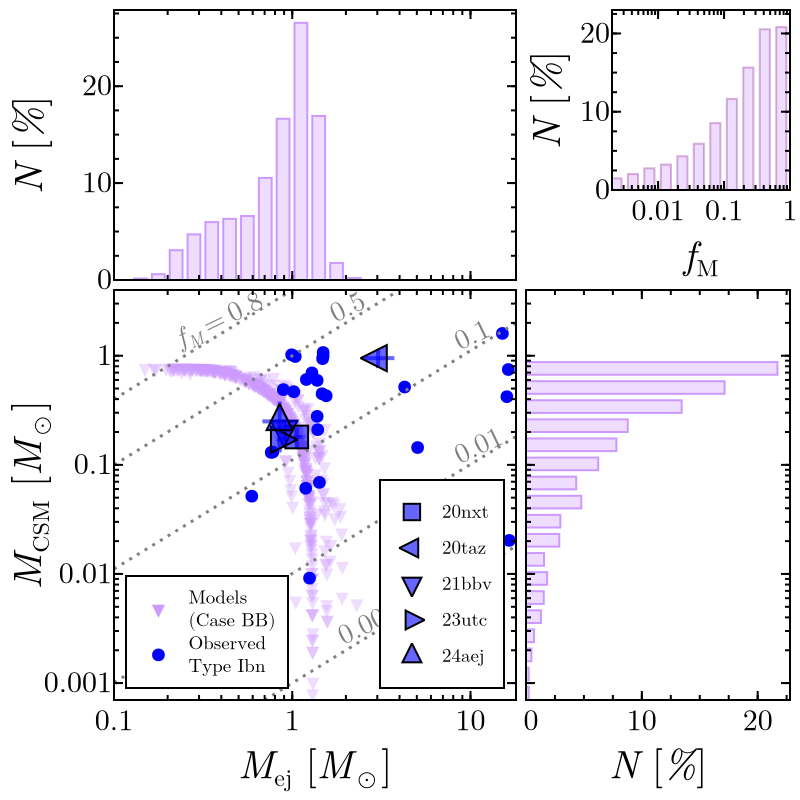

In [3]:
x2   = SN_DATA["Mf"]["1"][get_idx("1", "Ibc-i")]
dx2 = SN_DATA["M_rem_b"]["1"][get_idx("1", "Ibc-i")]
y2 = SN_DATA["dM_C"]["1"][get_idx("1", "Ibc-i")]
pdf2 = SN_DATA["pdf"]["1"][get_idx("1", "Ibc-i")]

sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
# hatcher = make_hatch_pattern(size=40, spacing=5, thickness=1,  style=:slash,     line_color=color_coding["Ibc-i-cont"], bg_color=RGBAf(0,0,0,0))
# color_coding["Ibc-i2"] = Pattern(hatcher)
hatcher2 = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, direction = :y)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  what[4:end] : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)].*sintheta .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  datascale == log10 ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  1,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 
function run_histogram(ax, data_raw, pdf_data, bins, width; color=:gray, colorcont=:black, datascale = identity, direction = :y)
    (length(data_raw) == 0)           && return 0
    (length(data_raw) != length(pdf_data)) && throw(ErrorException("Data and pdf are not the same size"))

    pdf = sum(  pdf_data )
    data = nothing 
    data = datascale.(data_raw)
    dataweights = weights(pdf_data/pdf)

    reverse_f(x) =  datascale == log10 ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  1,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10)

hticks_val = 0:0.1:1
hticks_lab = [@sprintf("%2d", i*100) for i in hticks_val]
hticks = (hticks_val, hticks_lab)
hmticks = 0:0.025:1
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4:5 
grid_top  = 1:2 
grid_bottom = 3:5
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",
            ylabel=L" M_\mathrm{CSM} \ [M_\odot]",
            ylabelpadding = -5, 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [%]",
            ylabel=L"M_\mathrm{CSM} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            xticks = hticks, xmticks = hmticks)

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{ej} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [%]", xmticks=mticks,
            title =" ", xscale = log10,
            yticks=hticks, ymticks = hmticks, ylabelpadding=15,
            )
ax_fm = plot_settings(FIGURE[grid_top, grid_right]; 
            xlabel=L"f_\mathrm{M}",
            ylabel=L"N \ [%]", 
            title =" ", xscale = log10, 
            xticks=([10 .^ t for t in [-5.,-4.,-3.,-2.,-1.,0.]], [L"10^{-5}", L"10^{-4} ", "0.001", "0.01", "0.1", "1"]),
            xmticks=mticks, yticks=hticks, ymticks = hmticks
            )

# mend_intp = subpoints["Mend"]
# mns_intp = 1.33
# mej_intp = (subpoints["Mend"] .- mns_intp)[subpoints["Mend"] .> 1.333333]
# pdf_intp = subpoints["pdf"][subpoints["Mend"] .> 1.333333]
# dm_intp   = (subpoints["dM"])[subpoints["Mend"] .> 1.333333] .+ 1e-5
# scatter!(ax, mej_intp,  dm_intp, color = :gray, marker = :cross, alpha = 0.05)


scatter!(ax, (x2 .- dx2)[y2 .> 0],y2[y2 .>.0],   marker = :dtriangle, color=color_coding["Ibc-i"] )
plt_mod = scatter!(ax, [1e-99], [1e-99], color=color_coding["Ibc-i-cont"], label = "Case BC", marker = :dtriangle)
xdata_E25_Ibn = Dict(
    "Mej"=>[5.93e-1, 7.62e-1, 7.78e-1, 8.91e-1, 9.92e-1, 1.02e+0, 1.04e+0,
1.19e+0, 1.20e+0, 1.25e+0, 1.29e+0, 1.38e+0, 1.38e+0, 1.39e+0, 1.42e+0,
1.47e+0, 1.48e+0, 1.49e+0, 1.49e+0, 1.55e+0, 4.27e+0, 4.90e+0, 5.05e+0,
1.51e+1, 1.60e+1, 1.63e+1, 1.65e+1,],
"Mcsm"=> [ 5.16e-2, 1.30e-1, 1.31e-1, 4.89e-1, 1.02e+0, 4.68e-1, 9.83e-1,
 6.10e-2, 6.05e-1, 9.16e-3, 6.96e-1, 5.94e-1,  2.78e-1,  2.10e-1,  6.90e-2,
 4.48e-1, 9.40e-1,  9.91e-1, 1.07e+0, 4.29e-1, 5.16e-1, 1.20e-2, 1.44e-1,
 1.60e+0, 4.21e-1, 7.47e-1, 2.03e-2]) 
 xdata_E25_Icn = Dict(
    "Mej"=> [3.20e-1, 6.05e-1, 6.50e-1, 1.20e+0, 1.25e+0, 1.51e+0, 2.13e+0, 
 1.82e+0, 4.77e+0, 1.20e+1],
 "Mcsm"=>[1.19e-1, 1.69e-1, 1.79e-1, 2.01e-1, 2.47e-1, 2.58e-1, 3.79e-1,
4.56e-1, 1.30e+0, 3.28e+0,] )
plt_obs = scatter!(ax, xdata_E25_Ibn["Mej"], xdata_E25_Ibn["Mcsm"], color=:blue, label = "Observed\n Ibn (Paper II)" )
# scatter!(ax, xdata_E25_Icn["Mej"], xdata_E25_Icn["Mcsm"], color=:red, label = "Observed Icn" )

w = 0.175
run_histogram(ax_dM, "1", "Ibc-i", "dM_C", -3.35:w:2, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"], datascale = log10, direction = :x)
# run_histogram(ax_dM, dm_intp, pdf_intp, -3:w:2, w; color=RGBAf(0,0,0,0), colorcont=:gray, datascale = log10, direction = :x)
w = 0.1
run_histogram(ax_Mend, "1", "Ibc-i", "Mej", -3:w:2, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"],datascale = log10, direction = :y)
# run_histogram(ax_Mend, mej_intp, pdf_intp, -3:w:2, w; color=RGBAf(0,0,0,0), colorcont=:gray, datascale = log10, direction = :y)
# run_histogram(ax_Mend, mej_intp, pdf_intp, -3:w:2, w; color=RGBAf(0,0,0,.0), colorcont=:gray, datascale = log10, direction = :y)


f_M(Mcsm, Mej) = Mcsm/(Mej+Mcsm)
Mcsm_from_f_M(Mej, f_M) = f_M/(1-f_M) * Mej 
Mejs = [0.1,10,100]
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.8), color = :gray, linestyle = :dot)
text!(ax, 0.25, Mcsm_from_f_M(0.25, 0.8), text = L"f_M=0.8", color = :gray, rotation=pi/7)
text!(ax, 1.8, Mcsm_from_f_M(1.8, 0.5), text = L"0.5", color = :gray, rotation=pi/7)
text!(ax, 9, Mcsm_from_f_M(9, 0.1), text = L"0.1", color = :gray, rotation=pi/7)
text!(ax, 9, Mcsm_from_f_M(9, 0.01), text = L"0.01", color = :gray, rotation=pi/7)
text!(ax, 2, Mcsm_from_f_M(2, 0.001), text = L"0.001", color = :gray, rotation=pi/7)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.5), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.1), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.01), color = :gray, linestyle = :dot)
lines!(ax, Mejs, Mcsm_from_f_M(Mejs, 0.001), color = :gray, linestyle = :dot)

function valpm(value, plus, minus) 
    return Dict("mu"=> value, "s+" => plus, "s-" => minus)
end
SN2020nxt = Dict("label" => "20nxt", "Mej" => valpm(1.06, 0.08, 0.04), "Mcsm"=>valpm(0.18, 0.04,0.04),   "color" => (:blue, 0.6), "marker" => :rect     )
SN2020taz = Dict("label" => "20taz", "Mej" => valpm(3.03, 0.71, 0.57), "Mcsm"=>valpm(0.95, 0.19, 0.18),  "color" => (:blue, 0.6), "marker" => :ltriangle)
SN2021bbv = Dict("label" => "21bbv", "Mej" => valpm(0.90, .11, .09),   "Mcsm"=>valpm(.21, .05, .04),     "color" => (:blue, 0.6), "marker" => :dtriangle)
SN2023utc = Dict("label" => "23utc", "Mej" => valpm(.85, .07, .03),    "Mcsm"=>valpm(.17, .06, .04),     "color" => (:blue, 0.6), "marker" => :rtriangle)
SN2024aej = Dict("label" => "24aej", "Mej" => valpm(.85,.23,.17),      "Mcsm"=>valpm(.25,.13,.06),       "color" => (:blue, 0.6), "marker" => :utriangle)
SNe = [SN2020nxt, SN2020taz, SN2021bbv, SN2023utc,SN2024aej]
plt_SNe = []
for SN in SNe
    errorbars!(ax, [SN["Mej"]["mu"]], [SN["Mcsm"]["mu"]], 
                        [SN["Mej"]["s-"]], [SN["Mej"]["s+"]], direction=:x, color = SN["color"], linewidth=2)
    errorbars!(ax, [SN["Mej"]["mu"]], [SN["Mcsm"]["mu"]], 
                        [SN["Mcsm"]["s-"]], [SN["Mcsm"]["s+"]], direction=:y, color =SN["color"], linewidth=2)
    scatter!(ax,   [SN["Mej"]["mu"]], [SN["Mcsm"]["mu"]], color = SN["color"], marker = SN["marker"], strokecolor = :black, strokewidth=1, markersize=18)
    p = scatter!(ax,   [1e-100], [1e-100], color = SN["color"], marker = SN["marker"], strokecolor = :black, strokewidth=1, markersize=13, label = SN["label"])
    push!(plt_SNe, p)
end

axislegend(ax, [plt_mod, plt_obs], ["Models\n(Case BB)", "Observed\nType Ibn"], position=:lb, 
    nbanks=1, titleposition=:left, rowgap =2, colgap =-2, labelsize=9.5, framevisible=true)
axislegend(ax, plt_SNe, [SN["label"] for SN in SNe],  position=:rb, 
    nbanks=1, titleposition=:left, rowgap =-2, colgap =-2, labelsize=9.5, framevisible=true)


w = 0.25
scale = log10
run_histogram(ax_fm, "1", "Ibc-i", "f_M", -3:w:1.1, w; color=color_coding["Ibc-i"], colorcont=(:purple,0.3), datascale = scale, direction = :y)
# fm_intp = dm_intp ./ (dm_intp .+ mej_intp)
# run_histogram(ax_fm, fm_intp, pdf_intp,-3:w:1.1, w; color=RGBAf(0,0,0,0), colorcont=:gray, datascale = scale, direction = :y)

xmin, xmax = 0.1, 18
ymin, ymax = 0.0007, 4
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
xlims!(ax_fm, 0.002, 1)
ylims!(ax_fm, 0, 0.23)


colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_stats_Ibn.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


In [4]:
# report_stats(SN_DATA, "f_M", "tot", "Ibc-i" ; print2screen = true, format_str = "%5.2f", multip_percentiles=0:5:100)
Mej  = SN_DATA["Mej"]["1-MT"][get_idx("1-MT", "Ibc-i")]
Mcsm  = SN_DATA["dM_C"]["1-MT"][get_idx("1-MT", "Ibc-i")]
pdfs = SN_DATA["pdf"]["1-MT"][get_idx("1-MT", "Ibc-i")]
fm = Mcsm ./ ( Mcsm .+ Mej)

report_stats(fm, pdfs, label = "f_M", print2screen=true, format_str="%6.2f",multip_percentiles=0:2.5:100 )

  f_M -   0.00<  0.30[+  0.44-  0.29]<  0.84 [     ]- 
Perc. Analysis
   0.0   2.5   5.0   7.5  10.0  12.5  15.0  17.5  20.0  22.5  25.0  27.5  30.0  32.5  35.0
  37.5  40.0  42.5  45.0  47.5  50.0  52.5  55.0  57.5  60.0  62.5  65.0  67.5  70.0  72.5
  75.0  77.5  80.0  82.5  85.0  87.5  90.0  92.5  95.0  97.5 100.0
  0.00  0.00  0.00  0.01  0.01  0.02  0.02  0.04  0.04  0.05  0.07  0.08  0.09  0.11  0.12
  0.14  0.16  0.17  0.19  0.22  0.24  0.26  0.28  0.31  0.34  0.35  0.38  0.41  0.44  0.46
  0.49  0.52  0.58  0.61  0.64  0.67  0.69  0.71  0.73  0.77  0.84


1-element Vector{Any}:
 [0.2957233430498249, 0.4388997753405099, 0.29239341691293513, 0.24277354730513223]


    0.77  err:  0.01  moe(%5): 0.025  ci(95%): 0.744-0.794
    5.49  err:  0.15  moe(%5): 0.297  ci(95%): 5.193-5.788
    0.84  err:  0.10  moe(%5): 0.199  ci(95%): 0.644-1.042


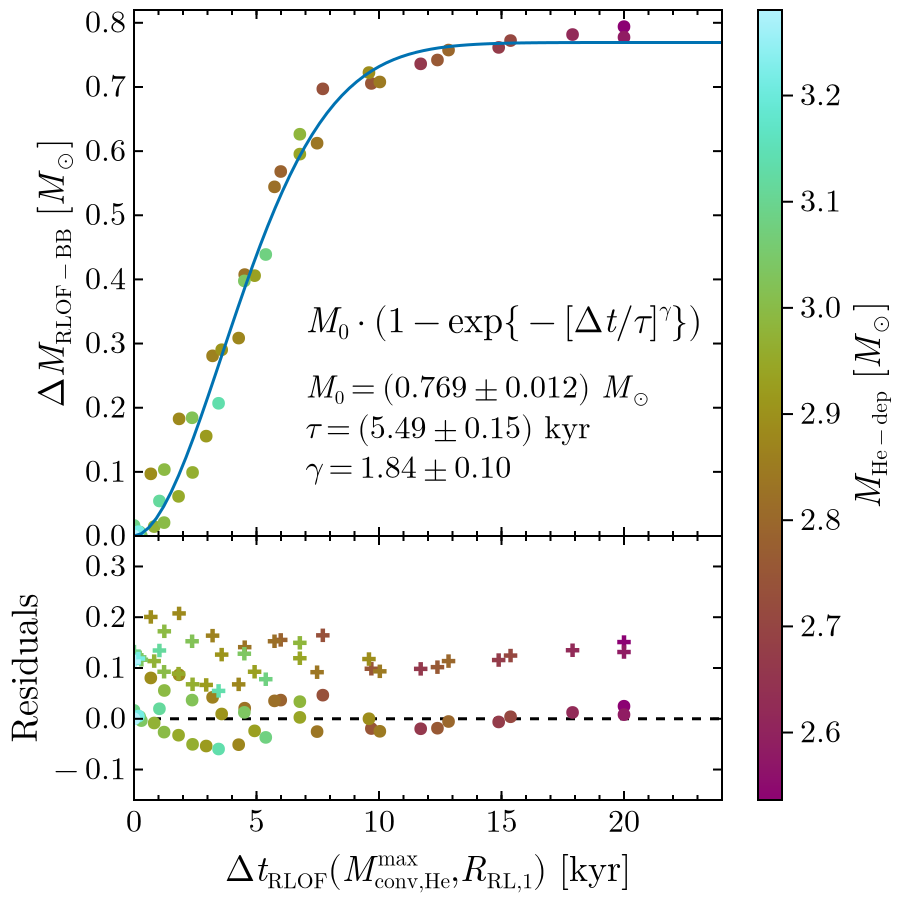

In [10]:
f_ibn = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/Ibc/CORR_Ibc_GRID.dat", 
                DataFrame, delim=' ',ignorerepeated=true)

using LsqFit 

fIbc_m = f_ibn.Mconv_max_Heburn
fIbc_mhedep = f_ibn.M_he_core_end_BURN_He
fIbc_r = f_ibn.Rl1_end_BURN_He
fIbc_dM = f_ibn.deltaM_C
fIbc_dM_pw = f_ibn.M_he_core_end_BURN_He - f_ibn.M_he_core_1yrpreCC

FIGURE = Figure(size=(450,450), figure_padding = 5)

grid = FIGURE[1,1] = GridLayout()

xticks=0:5:30
xmticks = 0:1:100
yticks=-1:0.1:1
yticks_t = [L"%$(tick)" for tick in yticks]
xticks_t = [L"%$(tick)" for tick in xticks]
ax = plot_settings(grid[1:2, 1]; 
    xlabel=" ", 
    ylabel=L"\Delta M_\mathrm{RLOF-BB} \ [M_\odot]", 
    title ="", xmticks=xmticks,
    yticks=(yticks, yticks_t),xticks=(xticks, xticks_t),
    xticklabelsize=0, yticklabelsize=16, xlabelsize=18, ylabelsize=18)
axR = plot_settings(grid[3, 1]; 
    xlabel=L"\Delta t_\mathrm{RLOF}(M_\mathrm{conv,He}^\mathrm{max}, R_\mathrm{RL,1}) \ [\mathrm{kyr}]", 
    ylabel=L"\mathrm{Residuals}", 
    title ="", xmticks=xmticks,
    yticks=(yticks, yticks_t),xticks=(xticks, xticks_t),
    xticklabelsize=16, yticklabelsize=16, xlabelsize=18, ylabelsize=18)


xlims!(ax, 0,24)
xlims!(axR, 0,24)
ylims!(ax, 0, 0.85)
ylims!(axR, -0.16, 0.36)
fIbc_dt = retrieve_tpreCC.(fIbc_m, fIbc_r)
scatter!(ax, fIbc_dt/1e3, fIbc_dM, color = fIbc_mhedep,  colormap = :hawaii)
# scatter!(ax, fIbc_dt/1e3, fIbc_dM_pw, color = fIbc_mhedep,  colormap = :hawaii, marker = :-)

rowgap!(grid, 0)
colgap!(grid, 0)



nans= findall(isnan, fIbc_dt)
fIbc_x = [] 
fIbc_y = [] 
for ix in range(1, length(fIbc_dM))
    ix in nans ? continue : nothing  
    push!(fIbc_x, fIbc_dt[ix])
    push!(fIbc_y, fIbc_dM[ix])
end 
# convert(Array{Float64}, fIbc_c)
# for ix in range(1,length(fIbc_x))
#     @printf("%10.2e %10.3f\n", fIbc_x[ix], fIbc_y[ix])
# end 

model(x,p) = p[1] ./  (x .+ p[4]) .^p[2] .+ p[3]
model(x,p) = p[1] .* (log10.(abs.(x .+ p[3])))  .+ p[2]
# model(x,p) = p[1] .* (x) .^ p[3] .+  .+ p[2]
model(x,p) = -p[1] .* exp.( -(x ./ p[2] ) .^ (1+p[3]) ) .+ p[1]
p = [0.8, 5, 1]
the_fit = LsqFit.curve_fit(model, fIbc_x/1e3, fIbc_y, p)  
err = stderror(the_fit)
margin_of_error = margin_error(the_fit, 0.05)
confidence_inter = confint(the_fit; level=0.95)
print("\n")

for i in range(1,length(the_fit.param))
    @printf(" %7.2f  err: %5.2f  moe(%%5): %5.3f  ci(95%%): %5.3f-%5.3f\n", the_fit.param[i], err[i], margin_of_error[i], confidence_inter[i][1], confidence_inter[i][2])
end
# margin_of_error = margin_error(the_fit, 0.05)
# confidence_inter = confint(the_fit; level=0.95)
# @printf("\n  moe   [%5.3f %5.3f %5.3f %5.3f]", margin_of_error[1], margin_of_error[2], margin_of_error[3], margin_of_error[4])
# @printf("\n  ci    [%5.3f %5.3f %5.3f %5.3f]", confidence_inter[1], confidence_inter[2], confidence_inter[3], confidence_inter[4])

xx = range(0.,30,100)
lines!(ax, xx, model(xx, the_fit.param))
lines!(axR, xx, zeros(length(xx)), color = "black", linestyle = :dash)
myplot = scatter!(axR, fIbc_dt/1e3, fIbc_dM - model(fIbc_dt/1e3, the_fit.param), color = fIbc_mhedep,  colormap = :hawaii)

scatter!(axR, fIbc_dt/1e3, fIbc_dM_pw - model(fIbc_dt/1e3, the_fit.param), color = fIbc_mhedep,  colormap = :hawaii, marker = :+)
Colorbar(grid[1:3, 2], myplot, flipaxis = true, label = L"$M_\mathrm{He-dep} \ [M_\odot]$",
ticks = ([i for i in 2:0.1:4], [L"%$(i)" for i in 2:0.1:4]),ticklabelsize=16, labelsize=18 )

ax.yticklabelpad =3.
axR.yticklabelpad =3.

text!(ax, 
            L"M_0 \cdot \left( 1 - \mathrm{exp} \left{ -   \left[{\Delta t}/{\tau}\right]^\gamma \right} \right)  ", 
            position=(7,0.3), fontsize=18)
i=1
a1 = @sprintf("(%.3f \\pm %.3f) \\ M_\\mathrm{\\odot}", the_fit.param[i], err[i])
text!(ax, 
            L"M_0 = {%$(a1)} ", 
            position=(7,0.2), fontsize=16)
i=2
a1 = @sprintf("(%.2f \\pm %.2f) \\  \\mathrm{kyr}", the_fit.param[i], err[i])
text!(ax, 
            L" \ \tau = {%$(a1)} ", 
            position=(7,0.14), fontsize=16)
i=3
a1 = @sprintf("%.2f \\pm %.2f", 1+the_fit.param[i], err[i])
text!(ax, 
            L" \ \ \ \gamma = {%$(a1)} ", 
            position=(7,0.08), fontsize=16)

ylims!(ax, 0, 0.82)

save("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/Ibc_deltaM_fit.pdf", FIGURE)    # 1600 × 1200 px png

FIGURE



In [15]:
using StatsBase 
mean(fIbc_dM - model(fIbc_dt/1e3, the_fit.param))

0.002932906130810724

In [11]:
Ibn_template = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/Hosseinzadeh17.data",
            DataFrame, header=1, delim=" ", ignorerepeated=true)

t = Ibn_template.t*day
l_avg = Ibn_template.L_bol
l_max = Ibn_template.L_max
l_min = Ibn_template.L_min

L_avg_t = interpolator(t, 10 .^ l_avg, extrapolation=:flat)
L_max_t = interpolator(t, 10 .^ l_max, extrapolation=:flat)
L_min_t = interpolator(t, 10 .^ l_min, extrapolation=:flat)


Erad_avg, _ = quadgk(L_avg_t, minimum(t), maximum(t), rtol=1e-8)
Erad_max, _ = quadgk(L_max_t, minimum(t), maximum(t), rtol=1e-8)
Erad_min, _ = quadgk(L_min_t, minimum(t), maximum(t), rtol=1e-8)

@printf("%5.2e  <  %5.2e  <  %5.2e\n", Erad_min, Erad_avg, Erad_max)
@printf("%5.2f +%5.2f  -%5.2f", Erad_avg/1e49, (Erad_max-Erad_avg)/1e49, (Erad_avg-Erad_min)/1e49)


1.61e+49  <  2.71e+49  <  3.61e+49
 2.71 + 0.90  - 1.11

In [7]:



x1  = SN_DATA["Mf"]["1"][get_idx("1", "II-i")]
dx1 = SN_DATA["M_rem_b"]["1"][get_idx("1", "II-i")]
y1 = SN_DATA["dM_C"]["1"][get_idx("1", "II-i")]
q1 = f_MW.q[Int.(SN_DATA["model_n"]["1"])][get_idx("1", "II-i")]
case = SN_DATA["case"]["1"][get_idx("1", "II-i")]

x2   = SN_DATA["Mf"]["1"][get_idx("1", "Ibc-i")]
dx2 = SN_DATA["M_rem_b"]["1"][get_idx("1", "Ibc-i")]
y2 = SN_DATA["dM_C"]["1"][get_idx("1", "Ibc-i")]
pdf2 = SN_DATA["pdf"]["1"][get_idx("1", "Ibc-i")]

sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["Ibc-cont"]   = RGBAf(0,0,1 ,1)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
# hatcher = make_hatch_pattern(size=40, spacing=5, thickness=1,  style=:slash,     line_color=color_coding["Ibc-i-cont"], bg_color=RGBAf(0,0,0,0))
# color_coding["Ibc-i2"] = Pattern(hatcher)
hatcher2 = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,1,0,0.5))
hatcher_stb = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
hatcher_unst = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:slash, line_color=color_coding["Ibc-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = RGBAf(0,1,0,.5)
color_coding["II-i_unst"] = Pattern(hatcher_stb)
color_coding["II-i_stab"] =  RGBAf(0,0,1 ,alpha)   #Pattern(hatcher_unst)

function run_histogram_filtered(ax, prg, ttp, what, bins, width; filter = true, color=:gray, colorcont=:black, datascale = identity, direction = :y, to_plot = true)
    length(get_idx(prg, ttp)) == 0 && return 0
    @printf("Tot of elements %d - filter lenght %d \n", length(get_idx(prg, ttp)), length(filter))

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

    extrafilter = [] 
    if length(filter) > 1
        for ix in range(1,length(get_idx(prg, ttp)))
            filter[ix] && push!(extrafilter, get_idx(prg, ttp)[ix])
        end
    else
        extrafilter = get_idx(prg, ttp)
    end
    @printf("extrafilter got %d elements.\n", length(extrafilter))
    # (length(extrafilter) != length(get_idx(prg, ttp))) && throw(ErrorException("Filter and Data have different sizes!"))
    
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what || occursin("f_M", what) )
        data = datascale.(SN_DATA[what][prg][extrafilter])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  parse(Float64, what[4:end]) : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][extrafilter] ./(SN_DATA["Mej"][prg][extrafilter].*sintheta .+ SN_DATA["dM_C"][prg][extrafilter])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][extrafilter]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][extrafilter]/pdf)
 
    reverse_f(x) =  datascale == log10 ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

     to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  1,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)

    return x_bar, y_bar
end 



FIGURE = Figure(size=(300,300), figure_padding = 0)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10)


grid = FIGURE[1, 1:2] = GridLayout()
grid_left = 1
grid_right = 1:2
grid_top  = 1
grid_bottom = 3:5

ax_fm_lin = plot_settings(FIGURE[grid_top, grid_right]; 
            xlabel=L"f_{M}",
            ylabel=L"N \ [\mathrm{norm}]", 
            title =" ", xscale = identity, 
            xticks=0:0.2:1,#([0.001, 0.01,0.1,1,10], ["0.001", "0.01", "0.1", "1", "10"]),
            xmticks=0:0.05:1#mticks
            )
# ax_fm_log = plot_settings(FIGURE[grid_top, grid_left]; 
#             xlabel=L"f_{M}",
#             ylabel=L"N \ [\mathrm{norm}]", 
#             title =" ", xscale = log10, 
#             xticks=([0.001, 0.01,0.1,1,10], ["0.001", "0.01", "0.1", "1", "10"]),
#             xmticks=union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1)
#             )


            

f_M(Mcsm, Mej) = Mcsm/(Mej+Mcsm)
Mcsm_from_f_M(Mej, f_M) = f_M/(1-f_M) * Mej 
Mejs = [0.1,10,100]## Ibc


w = 0.05
scale = identity

f_stableC   = q1 .>= 0.7 .&& case .== "C" .&& y1 .>= 0.001
f_stableC_F = q1 .>= 0.7 .&& case .== "C" .&& y1 .<  0.001
f_unstabC   = q1 .<  0.7 .&& case .== "C" .&& y1 .>= 0.001
f_unstabC_F = q1 .<  0.7 .&& case .== "C" .&& y1 .<  0.001
f_BC   =      case .!= "C" .&& y1 .>= 0.001
f_BC_F =      case .!= "C" .&& y1 .<  0.001

# run_histogram(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = q1 .< 0.7 .&& case .== "C", color=color_coding["II-i_unst"], colorcont=:white, datascale = scale, direction = :y)
# run_histogram(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = case .!== "C", color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y)
# run_histogram(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = q1 .>= 0.7 .&& case .== "C", color=color_coding["II-i_stab"], colorcont=:white, datascale = scale, direction = :y)
xb, yb1 = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_unstabC, color=color=RGBAf(0,0.2,1,0.3),  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
xb, yb1F = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_unstabC_F, color=color=RGBAf(0,0.2,1,0.3),  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_, yb2   = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_stableC, color=color_coding["II-i"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_, yb2F   = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_stableC_F, color=color_coding["II-i"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_, yb3   = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_BC,      color=color_coding["II-i_unst"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
_, yb3F   = run_histogram_filtered(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter = f_BC_F,      color=color_coding["II-i_unst"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# _, yb3   = run_histogram(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w;                     color=RGBAf(0.5,0.5,0.5,0), colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)
# run_histogram(ax_fm_lin, "1", "II-i", "f_M",  -3:w:1.1, w; filter =  case .!== "C", color=color_coding["IIb"], colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)
# run_histogram(ax_fm_lin, "1", "Ibc-i", "f_M", -3:w:1.1, w; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"], datascale = scale, direction = :y)
stacked_barplot!(ax_fm_lin, xb1, [yb2, yb2F, yb1, yb1F, yb3, yb3F], width=w, colors = [:orange, :yellow, :blue, :cyan, :magenta, :pink])
# w = 0.2
# scale = log10
# run_histogram(ax_fm_log, "1", "II-i", "f_M",  -3:w:1.1, w*1.2; filter = q1 .< 0.7 .&& case .== "C", color=color_coding["II-i_unst"], colorcont=:white, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M",  -3:w:1.1, w*1.2; filter = case .!== "C", color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M",  -3:w:1.1, w*1.2; filter = q1 .>= 0.7 .&& case .== "C", color=color_coding["II-i_stab"], colorcont=:white, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M",  -2:w:1.1, w*1.2;  color=RGBAf(0.5,0.5,0.5,0), colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M30",  -3:w:1.1, w*1.2;  color=RGBAf(0.5,0.5,0.5,0), colorcont=:black, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M20",  -3:w:1.1, w*1.2;  color=RGBAf(0.5,0.5,0.5,0), colorcont=:blue, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M10",  -3:w:1.1, w*1.2;  color=RGBAf(0.5,0.5,0.5,0), colorcont=:green, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M05",  -3:w:1.1, w*1.2;  color=RGBAf(0.5,0.5,0.5,0), colorcont=:red, datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "II-i", "f_M",  -3:w:1.1, w*1.2; filter =  case .!== "C", color=color_coding["IIb"], colorcont=color_coding["II-i-cont"], datascale = scale, direction = :y)
# run_histogram(ax_fm_log, "1", "Ibc-i", "f_M", -3:w:1.1, w*1.2; color=color_coding["Ibc-i"], colorcont=color_coding["Ibc-i-cont"], datascale = scale, direction = :y)



xlims!(ax_fm_lin, 0.0009, 0.875)
ylims!(ax_fm_lin, 0, 0.18)
# xlims!(ax_fm_log, 0.001, 1.2)
# ylims!(ax_fm_log, 0, 0.5)


colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_fM.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


Tot of elements 359 - filter lenght 359 
extrafilter got 157 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 0 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 92 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 4 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 103 elements.
Tot of elements 359 - filter lenght 359 
extrafilter got 3 elements.


UndefVarError: UndefVarError: `xb1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

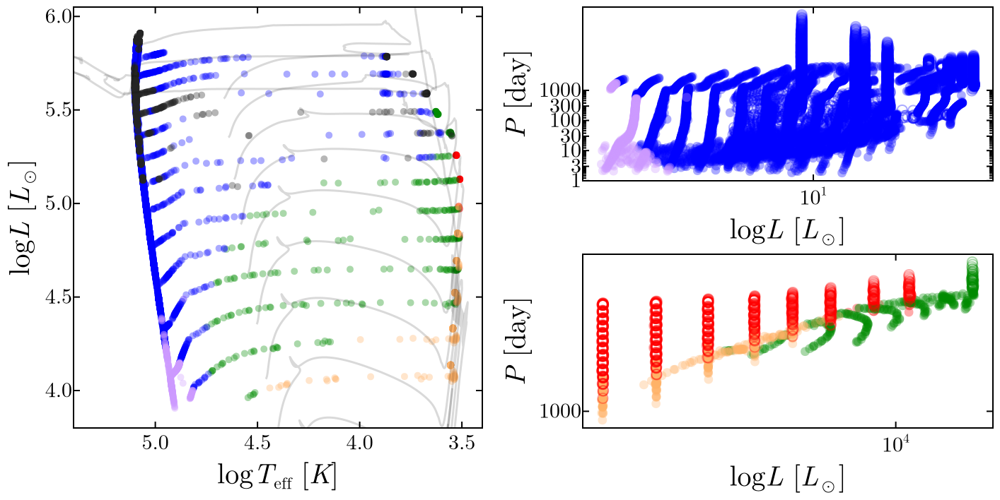

In [146]:



sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
# hatcher = make_hatch_pattern(size=40, spacing=5, thickness=1,  style=:slash,     line_color=color_coding["Ibc-i-cont"], bg_color=RGBAf(0,0,0,0))
# color_coding["Ibc-i2"] = Pattern(hatcher)
hatcher2 = make_hatch_pattern(size=100, spacing=7, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, direction = :y)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what
        f_m = SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)] .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  datascale == log10 ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  1,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 


FIGURE = Figure(size=(500*sqrt(2),500*sqrt(2)/2), figure_padding = 5)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10)


grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1
grid_right = 2 
grid_top  = 2
grid_bottom = 3:5
grid_bottom = 1
ax1 = plot_settings(grid[grid_bottom:grid_top, grid_left]; 
            xlabel=L"\log T_\mathrm{eff} \ [K]",
            ylabel=L" \log L \ [L_\odot]", 
            title =" ", 
            )
ax2 = plot_settings(grid[grid_bottom, grid_right]; 
            ylabel=L"P \ [\mathrm{day}]",
            xlabel=L"\log L \ [L_\odot]", 
            title =" ", yscale = log10, yticks = [1,3,10,30,100,300,1000], xscale = log10,
            )
ax2b = plot_settings(grid[grid_top, grid_right]; 
            ylabel=L"P \ [\mathrm{day}]",
            xlabel=L"\log L \ [L_\odot]", 
            title =" ", yscale = log10, yticks = [1,3,10,30,100,300,1000], xscale = log10,
            )




filt(type; prg = "1-MT") =  Int.(SN_DATA["model_n"][prg])[get_idx(prg, type)]

when = "ini_BURN_C_1"
when = "BURN_He_50_1"
for ttp in ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH" ]
    ff=filt(ttp)
    scatter!(ax1, f_MW[!, "logT_1_"*when][ff], f_MW[!, "logL_1_"*when][ff], color=  color_coding[ttp], marker = :circle, markersize = 7 )
        qq = f_MW[!, "M_2_"*when][ff] ./ f_MW[!, "M_1_"*when][ff]
        qq = f_MW[!, "M_1_"*when][ff]
        # qq = f_MW[!, "logL_1_"*when][ff] - (f_MW[!, "logL_2_"*when])[ff]
    qq2 = 10. .^ f_MW[!, "logL_1_"*when][ff] ./ f_MW[!, "M_1_"*when][ff]
        pp = f_MW[!, "period_"*when][ff] 
        # pp =   f_MW[!, "v_orb_1_"*when][ff]

    if ttp in ["Ibc", "Ibc-i"]
        scatter!(ax2, qq, pp, color = color_coding[ttp])
    elseif ttp in ["IIP", "IIb", "II-i"]
        scatter!(ax2b, qq2, pp, color = color_coding[ttp])
    end
end
for ttp in ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH" ]
    ff=filt(ttp, prg = "1-NI")
    # scatter!(ax1, f_MW[!, "logT_1_"*when][ff], f_MW[!, "logL_1_"*when][ff], color=  color_coding[ttp], marker = '+', markersize = 10)

    qq = f_MW[!, "logL_1_"*when][ff]
        # qq = f_MW[!, "logL_1_"*when][ff] - (f_MW[!, "logL_2_"*when])[ff]
    qq = f_MW[!, "M_2_"*when][ff] ./ f_MW[!, "M_1_"*when][ff]
    qq = f_MW[!, "M_1_"*when][ff]
    qq2 = 10. .^ f_MW[!, "logL_1_"*when][ff] ./ f_MW[!, "M_1_"*when][ff]

    pp =f_MW[!, "period_"*when][ff]
    # pp =   f_MW[!, "v_orb_1_"*when][ff]
    if ttp in ["Ibc", "Ibc-i"]
        scatter!(ax2, qq, pp, strokecolor = color_coding[ttp], strokewidth=1, color = RGBAf(0,0,0,0), marker = :circle, markersize = 10)
    elseif ttp in ["IIP", "IIb", "II-i"]
        scatter!(ax2b, qq2, pp, strokecolor = color_coding[ttp], strokewidth=1, color = RGBAf(0,0,0,0), marker = :circle, markersize = 10)
    end

    # scatter!(ax2, qq, pp, strokecolor = color_coding[ttp], strokewidth=1, color = RGBAf(0,0,0,0), marker = :circle, markersize = 10)
end


for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(ax1, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
end
for logm in 1.10:0.10:1.7
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(ax1, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
end

# scatter!(ax2, qact1, period1, color = color_coding["II-i"], label = "case C")
# scatter!(ax2, qact2, period2, color = color_coding["Ibc-i"], label = "case BC")

# axislegend(ax1,  position=:lt, 
#     nbanks=1, titleposition=:left, framealpha=0.5, rowgap =1, colgap =1, labelsize=10)


    
colgap!(grid, 15)
rowgap!(grid, 5)
xlims!(ax1, 5.4, 3.4)
ylims!(ax1, 3.8, 6.05)
# xlims!(ax2, 0.08, 12)
colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_HRD.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


In [11]:
available_marker_symbols()

Marker Symbols:
    :+
    :hexagon
    :circle
    :pentagon
    :diamond
    :star4
    :vline
    :cross
    :xcross
    :rect
    :ltriangle
    :dtriangle
    :utriangle
    :star5
    :star8
    :star6
    :rtriangle
    :octagon
    :hline
    :x


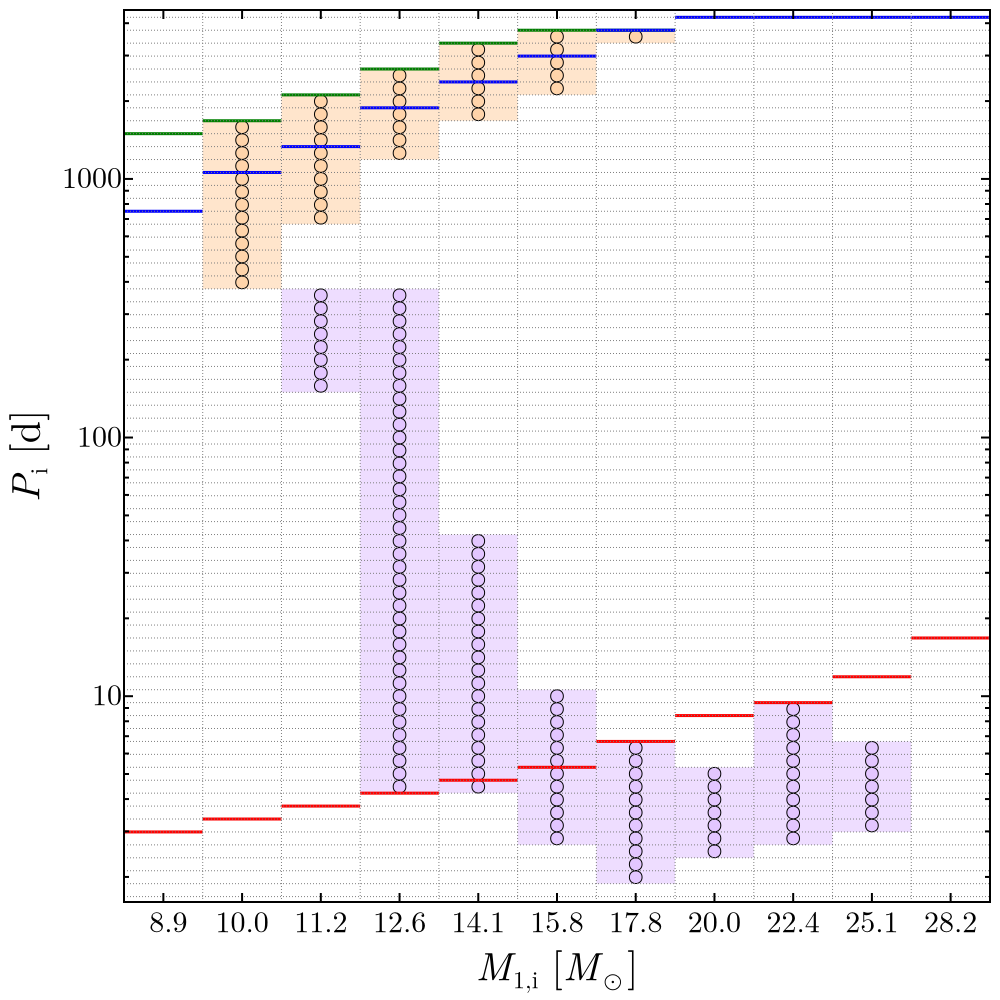

In [12]:
logPs_IIi = Dict()
logPs_Ibci = Dict()
CaseA = Dict()
CaseB = Dict()
CaseC = Dict()
for logM in logMs 
    logPs_IIi[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)
    logPs_Ibci[to_key(logM)] = Dict("min"=> 5., "max"=>-5.)
    
    CaseA[to_key(logM)]  = Dict("max"=>-5.)
    CaseB[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)
    CaseC[to_key(logM)]  = Dict("min"=> 5., "max"=>-5.)

    mod_logM = MODELS[to_key(logM)]
    for logP_t in keys(mod_logM)
        mod_logP = mod_logM[logP_t]
        logP = parse(Float64, logP_t) 
        for q_t in keys(mod_logP) 
            mod = mod_logP[q_t]
            q_t == "0.80" && continue 
            if mod["SN1"]["II-i"]>0 && mod["first"] != "M"
                logPs_IIi[to_key(logM)]["min"] = min(logPs_IIi[to_key(logM)]["min"], logP)
                logPs_IIi[to_key(logM)]["max"] = max(logPs_IIi[to_key(logM)]["max"], logP)
            end
            if mod["SN1"]["Ibc-i"]>0 && mod["first"] != "M"
                logPs_Ibci[to_key(logM)]["min"] = min(logPs_Ibci[to_key(logM)]["min"], logP)
                logPs_Ibci[to_key(logM)]["max"] = max(logPs_Ibci[to_key(logM)]["max"], logP)
            end

            length(mod["case"]) < 1 && continue
            ("A" == mod["case"]) && (CaseA[to_key(logM)]["max"] = max(CaseA[to_key(logM)]["max"], logP))
            if occursin("B", mod["case"])
                CaseB[to_key(logM)]["max"] = max(CaseB[to_key(logM)]["max"], logP)
            end 
            if occursin("C", mod["case"])
                CaseC[to_key(logM)]["max"] = max(CaseC[to_key(logM)]["max"], logP)
            end 

        end

    end


    (logPs_IIi[to_key(logM)]["min"] == 5.) && (logPs_IIi[to_key(logM)]["min"] = NaN)
    (logPs_IIi[to_key(logM)]["max"] == -5.) && (logPs_IIi[to_key(logM)]["max"] = NaN)
    (logPs_Ibci[to_key(logM)]["min"] == 5.) && (logPs_Ibci[to_key(logM)]["min"] = NaN)
    (logPs_Ibci[to_key(logM)]["max"] == -5.) && (logPs_Ibci[to_key(logM)]["max"] = NaN)

end

FIG = Figure(size=(500,500), figure_padding=5)

ax = plot_settings(FIG[1,1], xlabel = L"M_\mathrm{1,i} \ [M_\odot]", 
                yticks = ([1.,10.,100., 1000], ["1", "10", "100", "1000"]),
                ylabel = L"P_\mathrm{i} \ [\mathrm{d}]",
                title = "", yscale = log10,
        xticks = (0:0.05:2, [@sprintf("%4.1f", 10^logm) for logm in 0:0.05:2]))
for logm in logMs 
    ! isnan(logPs_IIi[to_key(logm)]["min"]) && fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
                 10 .^ [logPs_IIi[to_key(logm)]["min"]-0.05/2, logPs_IIi[to_key(logm)]["min"]-0.05/2], 
                 10 .^ [logPs_IIi[to_key(logm)]["max"]+0.05/2, logPs_IIi[to_key(logm)]["max"]+0.05/2],
                 color = color_coding["II-i"])
    ! isnan(logPs_Ibci[to_key(logm)]["min"]) && fill_between!(ax, [logm-0.05/2, logm+0.05/2], 
                 10 .^ [logPs_Ibci[to_key(logm)]["min"]-0.05/2, logPs_Ibci[to_key(logm)]["min"]-0.05/2], 
                 10 .^ [logPs_Ibci[to_key(logm)]["max"]+0.05/2, logPs_Ibci[to_key(logm)]["max"]+0.05/2],
                 color = color_coding["Ibc-i"])
    if ! isnan(logPs_IIi[to_key(logm)]["min"])
        for logP in logPs_IIi[to_key(logm)]["min"]:0.05:logPs_IIi[to_key(logm)]["max"]
             scatter!(ax, [logm], [10^logP], color = color_coding["II-i"], marker = :circle, strokewidth=0.5)
        end
    end
    if ! isnan(logPs_Ibci[to_key(logm)]["min"])
        for logP in logPs_Ibci[to_key(logm)]["min"]:0.05:logPs_Ibci[to_key(logm)]["max"]
             scatter!(ax, [logm], [10^logP], color = color_coding["Ibc-i"], marker = :circle, strokewidth=0.5)
        end
    end

    if ! isnan(CaseA[to_key(logm)]["max"])
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseA[to_key(logm)]["max"]+0.05/2), 10^ (CaseA[to_key(logm)]["max"]+0.05/2)], color = :red)
    end
    if ! isnan(CaseC[to_key(logm)]["max"]) && logm < 1.3
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseC[to_key(logm)]["max"]+0.05/2), 10^ (CaseC[to_key(logm)]["max"]+0.05/2)], color = :green)
    end
    if ! isnan(CaseB[to_key(logm)]["max"])
        lines!(ax, [logm-0.05/2, logm+0.05/2], [10^ (CaseB[to_key(logm)]["max"]+0.05/2), 10^ (CaseB[to_key(logm)]["max"]+0.05/2)], color = :blue)
    end
end
[lines!(ax, [0.5, 1.5], [P, P], color = :gray, linestyle=:dot, linewidth=0.5) for P in 10 .^ (logPs .+ 0.05/2 )]
[lines!(ax, [logm+0.05/2, logm+0.05/2], [0.5, 1e4], color = :gray, linestyle=:dot, linewidth=0.5) for logm in logMs ]
ylims!(ax, 1.6, 4500)
xlims!(ax, 0.925, 1.475)

FIG

## progenitors

In [27]:
stats = Dict()
when =  "BURN_He_50_1"
# when =  "ini_BURN_C_1"
# when =  "end_1"

for Type in ["IIP", "Ibc", "IIb", "Ibc-i", "II-i", "BH", "WD"]
    stats[Type]  = Dict("M1"=>Float64[], "M2"=>Float64[], "P"=>Float64[], 
                        "v1"=>Float64[], "v2"=>Float64[], "L1"=>Float64[], 
                        "L2"=>Float64[], "T1"=>Float64[], "T2"=>Float64[], 
                        "mh"=>Float64[], "case"=>[], "logg1" => Float64[],
                        "logg2" => Float64[], "cL1" => Float64[], "cL2"=>Float64[])
    @printf("Gathering %s\n", Type)
    for logM in keys(MODELS)
        for logP in keys(MODELS["1.10"]) 
            for q in keys(MODELS["1.10"]["1.00"])
                mod = MODELS[logM][logP][q]
                n = mod["mod"]
                (mod["SN1"][Type] == 0 || mod["first"] != "1" || n == 13497) && continue 
                mod["case"] == "" && continue 
                push!(stats[Type]["M1"], f_MW[!, "M_1_"*when][n])
                push!(stats[Type]["M2"], f_MW[!, "M_2_"*when][n])
                push!(stats[Type]["mh"], f_MW[!, "M_tot_h_1_"*when][n])
                push!(stats[Type]["P"], f_MW[!, "period_"*when][n])
                push!(stats[Type]["v1"], f_MW[!, "v_orb_1_"*when][n])
                push!(stats[Type]["v2"], f_MW[!, "v_orb_2_"*when][n])
                
                if !( (Type == "Ibc-i" || Type == "WD") && (when == "ini_BURN_C_1" || when == "end_BURN_C_1" || when == "end_1"))
                    push!(stats[Type]["L1"], f_MW[!, "logL_1_"*when][n])
                    push!(stats[Type]["T1"], f_MW[!, "logT_1_"*when][n])

                else 
                    L = f_MW[!, "logL_1_ini_BURN_C_1"][n]
                    push!(stats[Type]["L1"], L)
                    R_L = f_MW[!, "Rl_1_ini_BURN_C_1"][n]
                    sigma_boltz = 5.6704e-5 #gs-3K-4
                    Teff = (10^L*Lsun/(4*pi*(R_L*Rsun)^2*sigma_boltz)) ^ (1/4)
                    push!(stats[Type]["T1"], log10(Teff))
                end
                push!(stats[Type]["L2"], f_MW[!, "logL_2_"*when][n])
                push!(stats[Type]["T2"], f_MW[!, "logT_2_"*when][n])
                push!(stats[Type]["case"], mod["case"])
                push!(stats[Type]["logg1"], f_MW[!, "log_g_1_"*when][n])
                push!(stats[Type]["logg2"], f_MW[!, "log_g_2_"*when][n])
                push!(stats[Type]["cL1"], log10( (10 ^ f_MW[!, "logT_1_"*when][n]) ^4 / 10^f_MW[!, "log_g_1_"*when][n]) - 10.61)
                push!(stats[Type]["cL2"], log10( (10 ^ f_MW[!, "logT_2_"*when][n]) ^4 / 10^f_MW[!, "log_g_2_"*when][n]) - 10.61)
                # @printf(" Ibc-i : M1 - M2 - P  =  %5.2f  %5.2f %5.1f \n", f_MW.M_1_BURN_He50_1[n], f_MW.M_2_BURN_He50_1[n], f_MW.period_BURN_He50_1[n])
                
                # (f_MW[!, "M_1_"*when][n] > 4) && report_model(f_MW, MODELS, parse(Float64,logM), parse(Float64,q), parse(Float64,logP), ["M_1", "M_he_core_1", "M_2"])

            end
        end
    end
end
print("Done")



function get_mag(logTeff, logL, filter_name) #ref- @aschoot
    Mbolsol = 4.74  # Solar absolute bolometric magnitude
    if filter_name == "Swift_UVW2"
        a4, a3, a2, a1, c = -8.02856541, 147.84794758, -1023.68153538, 3154.37423668, -3647.32490721  
    elseif filter_name == "Swift_UVM2"
        a4, a3, a2, a1, c = -5.22797198, 97.2026256, -680.8992009, 2125.0070657, -2489.94672688
    elseif filter_name == "Swift_UVW1"
        a4, a3, a2, a1, c = -1.76117616, 34.15960966, -251.49575839, 826.40300307, -1018.57421309
    elseif filter_name == "Swift_U"
        a4, a3, a2, a1, c = 0.6633483, -10.82914035, 62.1125729, -147.47842155, 118.27928732
    elseif filter_name == "Swift_B"
        a4, a3, a2, a1, c = -7.27886604, 131.53752019, -890.69806389, 2672.7992971, -2995.23669657
    elseif filter_name == "Swift_V"
        a4, a3, a2, a1, c = -5.93731188, 106.88971327, -720.81664342, 2151.96403082, -2396.04099567
    else 
        throw(ErrorException("You provided the wrong filter name. Try again."))
    end
    boco = c + a1*logTeff + a2*logTeff^2 + a3*logTeff^3 + a4*logTeff^4
    Mbol = -2.5*logL + Mbolsol
    abs_mag  = Mbol - boco
    return abs_mag
end 

function sum_mag(mag1, mag2; add_or_subtract = "+")
    flux_1 = 10. .^ ( - mag1 ./ 2.5) 
    flux_2 = 10. .^ ( - mag2 ./ 2.5)
    res = nothing 
    if add_or_subtract == "+"
        res = -2.5 .* log10.(flux_1 + flux_2)
    elseif add_or_subtract == "-"
        res = -2.5 .* log10.(flux_1 - flux_2)
    else 
        throw(ErrorException("Wrong Operator."))
    end 

    return res
end



Gathering IIP
Gathering Ibc
Gathering IIb
Gathering Ibc-i
Gathering II-i
Gathering BH
Gathering WD
Done

sum_mag (generic function with 1 method)

In [55]:

minorlogticks = union( [ k  for i in -5:1:5  for k in (10. ^i):(10. ^i):(10. ^(i+1)) ] )

FIG = Figure(size=(400*2,900), figure_padding=5)
ax = plot_settings(FIG[1,1], xlabel = L"M_\mathrm{1} \ [M_\odot]", 
                ylabel =  L"M_\mathrm{2} \ [M_\odot]",
                title = "Interacting H-rich SN progenitor systems\nduring core He-burning", titlesize = 15,
                yscale = identity, xscale = identity,
                xticks = 15:-5:0, xmticks=1:1:20, yticks = 15:-5:0, ymticks=1:1:20)
ax2 = plot_settings(FIG[1,2], xlabel = L"M_\mathrm{1} \ [M_\odot]", 
                ylabel =  L"M_\mathrm{2} \ [M_\odot]",
                title = "Interacting H-free SN progenitor systems\nduring core He-burning", titlesize = 15,
                yscale = identity, xscale = identity,
                xticks = 0:.5:10, xmticks=1:0.1:20, yticks = 15:-5:0, ymticks=1:1:20)
cmap = reverse(Makie.ColorSchemes.rust)
cmap2 = reverse(to_colormap([:black, :purple, :violet]))

crange = (800,4500)
crange2 = (log10(2), log10(2000))
# pl = scatter!(ax, IIi_heburn["M1"][IIi_heburn["case"] .=="Cs"], IIi_heburn["M2"][IIi_heburn["case"] .=="Cs"], color= IIi_heburn["P"][IIi_heburn["case"] .=="Cs"], 
#               colormap=cmap, colorrange=crange, marker = :circle)
# pl = scatter!(ax, IIi_heburn["M1"][IIi_heburn["case"] .=="Cu"], IIi_heburn["M2"][IIi_heburn["case"] .=="Cu"], color= IIi_heburn["P"][IIi_heburn["case"] .=="Cu"], 
#               colormap=cmap, colorrange=crange, marker = :star4)
# pl = scatter!(ax, IIi_heburn["M1"][IIi_heburn["case"] .=="BC"], IIi_heburn["M2"][IIi_heburn["case"] .=="BC"], color= IIi_heburn["P"][IIi_heburn["case"] .=="BC"], 
#               colormap=cmap, colorrange=crange, marker = :rect)
pl = scatter!(ax, stats["II-i"]["M1"], stats["II-i"]["M2"] , color= IIi_heburn["P"], 
              colormap=cmap, colorrange=crange)
scatter!(ax, stats["IIb"]["M1"], stats["IIb"]["M2"] , color= :green, marker = :cross )
scatter!(ax, stats["IIP"]["M1"],   stats["IIP"]["M2"] , color= :red  , marker = :cross )
scatter!(ax2, stats["Ibc"]["M1"],   stats["Ibc"]["M2"] , color= :blue  , marker = :cross )
scatter!(ax2, stats["Ibc-i"]["M1"] , stats["Ibc-i"]["M2"],  color =  (:red, 1), marker = '.', markersize = 15)


Colorbar(FIG[3,1], pl, ticks = 0:1000:5000, 
                   vertical = false, flipaxis=false, minorticks=0:100:5000, minorticksvisible=true, 
                   label = L"P \ [\mathrm{d}]", labelsize=15)
Colorbar(FIG[3,2], pl2, ticks = (log10.([1,3,10,30,100,300,1000,3000]), ["1", "3", "10", "30", "100", "300", "1000", "3000"]), 
                   vertical = false, flipaxis=false, minorticks=log10.(minorlogticks), minorticksvisible=true, 
                   label = L"P \ [\mathrm{d}]", labelsize=15)

axb = plot_settings(FIG[2,1], xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]", 
                ylabel = L"\log L \ [L_\odot]",
                title = "", xticks = 0.:.5:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)
axb2 = plot_settings(FIG[2,2],xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]",
                ylabel = L"\log L \ [L_\odot]",
                title = "", xticks = 0.:.2:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)

plb = scatter!(axb, IIi_heburn["T1"], IIi_heburn["L1"], color= IIi_heburn["P"], colormap=cmap, colorrange=crange)
plbb = scatter!(axb, IIi_heburn["T2"], IIi_heburn["L2"], color= IIi_heburn["P"], colormap=cmap, colorrange=crange, marker = '○')
plb2 = scatter!(axb2, Ibci_heburn["T1"], Ibci_heburn["L1"] ,  color= log10.(Ibci_heburn["P"]), colormap=cmap2, colorrange=crange2)
plb2 = scatter!(axb2, Ibci_heburn["T1"][Ibci_heburn["mh"] .>1e-3], Ibci_heburn["L1"][Ibci_heburn["mh"] .>1e-3] ,  color =  (:red, 1), marker = '.', markersize = 15)
plb2b = scatter!(axb2, Ibci_heburn["T2"], Ibci_heburn["L2"] , color= log10.(Ibci_heburn["P"]), colormap=cmap2, colorrange=crange2, marker = '○')

# for i in range(1,length(IIi_heburn["T1"]))
    # IIi_heburn["P"][i] < 1500 && lines!(axb, [IIi_heburn["T1"][i], IIi_heburn["T2"][i]], [IIi_heburn["L1"][i], IIi_heburn["L2"][i]], color = (:gray, 0.1))
# end
# for i in range(1,length(Ibci_heburn["T1"]))
    # lines!(axb2, [Ibci_heburn["T1"][i], Ibci_heburn["T2"][i]], [Ibci_heburn["L1"][i], Ibci_heburn["L2"][i]], color = (:gray, 0.1))
# end

xlims!(axb,  4.5,3.45)
xlims!(axb2, 5.0,4.15)
ylims!(axb,  2.8,5.1)
ylims!(axb2, 2.8,4.9)


for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    lines!(axb2, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.1)
    # print(ix_txt, " ")
    text!(axb, 4.1, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
    ix_txt = find_nearest(h.log_Teff, 4.21)
    # print(ix_txt, " ")
   text!(axb2, 4.21, h.log_L[ix_txt],text =  @sprintf("%.1f", 10^logm), color = :gray)
end
for logm in 1.10:0.10:1.7
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    lines!(axb2, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15)) 
    ix_txt = find_nearest(h.log_Teff, 4.1)
    # print(ix_txt, " ")
    text!(axb, 4.1, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
    ix_txt = find_nearest(h.log_Teff, 4.23)
    # print(ix_txt, " ")
    text!(axb2, 4.23, h.log_L[ix_txt],text =  @sprintf("%.1f", 10^logm), color = :gray)
    logm == 1.30 && text!(axb2, h.log_Teff[200], h.log_L[200],text =  @sprintf("%.1f", 10^logm), color = :gray)

end

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("case_C_HeBurn.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG


UndefVarError: UndefVarError: `IIi_heburn` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

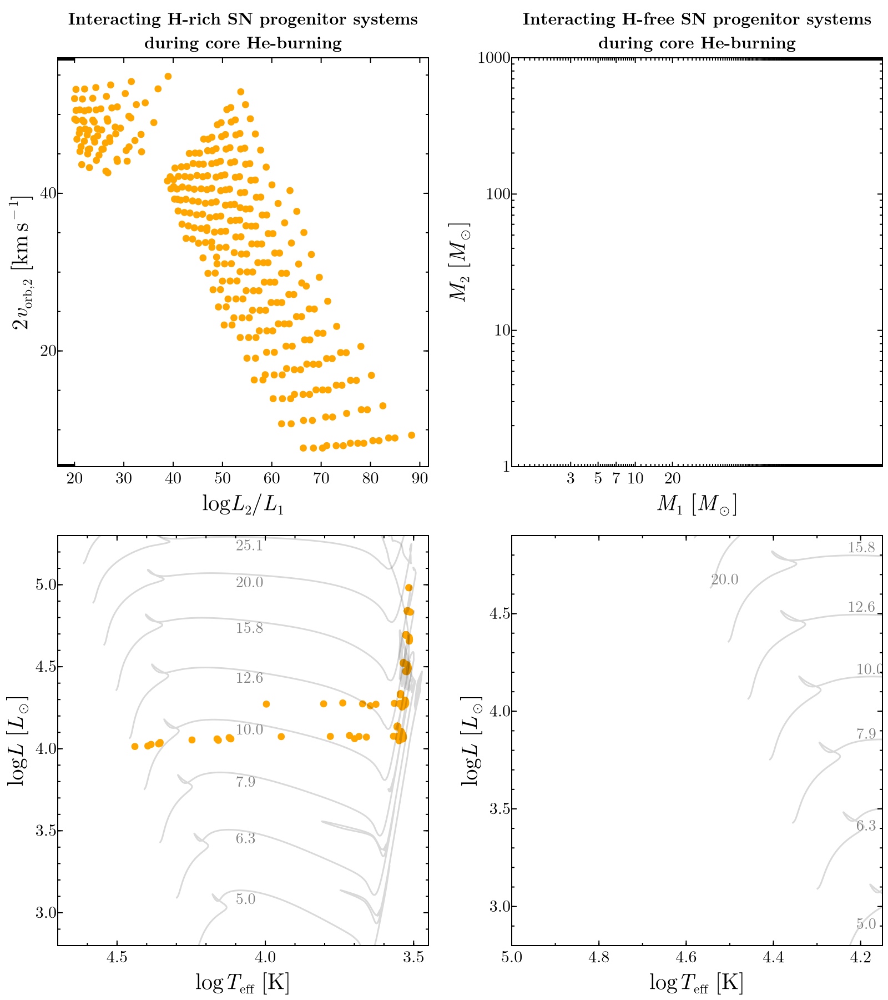

In [33]:

minorlogticks = union( [ k  for i in -5:1:5  for k in (10. ^i):(10. ^i):(10. ^(i+1)) ] )

FIG = Figure(size=(400*2,900), figure_padding=5)

ax = plot_settings(FIG[1,1], xlabel = L"\log L_2/L_1  ", 
                ylabel =  L"2 v_\mathrm{orb, 2} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                title = "Interacting H-rich SN progenitor systems\nduring core He-burning", titlesize = 15,
                yscale = identity, xscale = identity,
                xticks = -10:10:100, xmticks=-20:0.1:20, yticks = 0.:20:200, ymticks=0.:5:200)
ax2 = plot_settings(FIG[1,2], xlabel = L"M_\mathrm{1} \ [M_\odot]", 
                ylabel =  L"M_\mathrm{2} \ [M_\odot]",
                title = "Interacting H-free SN progenitor systems\nduring core He-burning", titlesize = 15,
                yscale = log10, xscale = log10,
                xticks = [3,5,7,10,20],yticks =[1,10,100,1000])
cmap = reverse(Makie.ColorSchemes.rust)
cmap2 = reverse(to_colormap([:black, :purple, :violet]))

crange = (800,4500)
crange2 = (log10(2), log10(2000))
extram = :rect 
extrams = 3

f1(Type)   = stats[Type]["T1"] .< 3.7  .&&   3.9 .< stats[Type]["L1"] .< 5.1
my_x(Type) = (stats[Type]["v2"] .* 2 )[f1(Type)]
my_y(Type) = (stats[Type]["v1"] .* 2 )[f1(Type)]
c1(Type)   = stats[Type]["P"][f1(Type)]
pl = scatter!(ax, my_x("II-i"), my_y("II-i") , color= :orange, colormap=cmap, colorrange=crange)
    #  scatter!(ax, my_x("IIP"),  my_y("IIP"),  color= :red,   marker = extram, markersize = extrams)
    #  scatter!(ax, my_x("IIb"), my_y("IIb"), color= :green, marker = extram, markersize = extrams)
    #  scatter!(ax, my_x("Ibc"), my_y("Ibc"), color= :blue,  marker = extram, markersize = extrams)
# pl = scatter!(ax, IIi_heburn["M2"], IIi_heburn["v2"] .* 2 , color= IIi_heburn["P"], 
#               colormap=cmap, colorrange=crange, marker = '○')
# pl2 = scatter!(ax2, Ibci_heburn["M1"], Ibci_heburn["v1"] .* 2, color= log10.(Ibci_heburn["P"]), 
#                 colormap=cmap2, colorrange=crange2)
# pl2 = scatter!(ax2, Ibci_heburn["M2"], Ibci_heburn["v2"] .* 2, color= log10.(Ibci_heburn["P"]), 
#                 colormap=cmap2, colorrange=crange2, marker = '○')
# scatter!(ax2, Ibci_heburn["M1"][Ibci_heburn["mh"] .>1e-3], Ibci_heburn["M2"][Ibci_heburn["mh"] .>1e-3] ,  color =  (:red, 1), marker = '.', markersize = 15)


# Colorbar(FIG[3,1], pl, ticks = 0:1000:5000, 
#                    vertical = false, flipaxis=false, minorticks=0:100:5000, minorticksvisible=true, 
#                    label = L"P \ [\mathrm{d}]", labelsize=15)
# Colorbar(FIG[3,2], pl2, ticks = (log10.([1,3,10,30,100,300,1000,3000]), ["1", "3", "10", "30", "100", "300", "1000", "3000"]), 
#                    vertical = false, flipaxis=false, minorticks=log10.(minorlogticks), minorticksvisible=true, 
#                    label = L"P \ [\mathrm{d}]", labelsize=15)

axb = plot_settings(FIG[2,1], xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]", 
                ylabel = L"\log L \ [L_\odot]",
                title = "", xticks = 0.:.5:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)
axb2 = plot_settings(FIG[2,2],xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]",
                ylabel = L"\log L \ [L_\odot]",
                title = "", xticks = 0.:.2:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)

new_x(Type) = stats[Type]["T1"]
new_y(Type) = stats[Type]["L1"]
scatter!(axb, new_x("II-i"), new_y("II-i"), color= :orange, marker = :circle)
# scatter!(axb, new_x("Ibc-i"),new_y("Ibc-i"), color= :purple, marker = :circle)
# scatter!(axb, new_x("IIP" ), new_y("IIP" ), color= :red   , marker = 'x', markersize = 8)
# scatter!(axb, new_x("IIb"), new_y("IIb"), color= :green , marker = 'x', markersize = 8)
# scatter!(axb, new_x("Ibc"), new_y("Ibc"), color= :blue  ,  marker = 'x', markersize = 8)
# scatter!(axb, new_x("WD" ), new_y("WD" ), color= :gray  ,  marker = 'x', markersize = 8)
# plbb = scatter!(axb, IIi_heburn["T2"], IIi_heburn["L2"], color= IIi_heburn["P"], colormap=cmap, colorrange=crange, marker = '○')
# plb2 = scatter!(axb2, Ibci_heburn["T1"], Ibci_heburn["L1"] ,  color= log10.(Ibci_heburn["P"]), colormap=cmap2, colorrange=crange2)
# plb2 = scatter!(axb2, Ibci_heburn["T1"][Ibci_heburn["mh"] .>1e-3], Ibci_heburn["L1"][Ibci_heburn["mh"] .>1e-3] ,  color =  (:red, 1), marker = '.', markersize = 15)
# plb2b = scatter!(axb2, Ibci_heburn["T2"], Ibci_heburn["L2"] , color= log10.(Ibci_heburn["P"]), colormap=cmap2, colorrange=crange2, marker = '○')
# scatter!(axb2, II_heburn["T1"] , II_heburn["L1"],  color= :red  , marker = 'x', markersize = 8)
# scatter!(axb2, IIb_heburn["T1"], IIb_heburn["L1"], color= :green, marker = 'x', markersize = 8)
# scatter!(axb2, Ibc_heburn["T1"], Ibc_heburn["L1"], color= :blue,  marker = 'x', markersize = 8)
# scatter!(axb2, WD_heburn["T1"], WD_heburn["L1"], color= :gray,  marker = 'x', markersize = 8)

# for i in range(1,length(IIi_heburn["T1"]))
    # IIi_heburn["P"][i] < 1500 && lines!(axb, [IIi_heburn["T1"][i], IIi_heburn["T2"][i]], [IIi_heburn["L1"][i], IIi_heburn["L2"][i]], color = (:gray, 0.1))
# end
# for i in range(1,length(Ibci_heburn["T1"]))
    # lines!(axb2, [Ibci_heburn["T1"][i], Ibci_heburn["T2"][i]], [Ibci_heburn["L1"][i], Ibci_heburn["L2"][i]], color = (:gray, 0.1))
# end

xlims!(axb,  4.7,3.45)
xlims!(axb2, 5.0,4.15)
ylims!(axb,  2.8,5.3)
ylims!(axb2, 2.8,4.9)


for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    lines!(axb2, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.1)
    # print(ix_txt, " ")
    text!(axb, 4.1, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
    ix_txt = find_nearest(h.log_Teff, 4.21)
    # print(ix_txt, " ")
   text!(axb2, 4.21, h.log_L[ix_txt],text =  @sprintf("%.1f", 10^logm), color = :gray)
end
for logm in 1.10:0.10:1.7
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    lines!(axb2, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15)) 
    ix_txt = find_nearest(h.log_Teff, 4.1)
    # print(ix_txt, " ")
    text!(axb, 4.1, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
    ix_txt = find_nearest(h.log_Teff, 4.23)
    # print(ix_txt, " ")
    text!(axb2, 4.23, h.log_L[ix_txt],text =  @sprintf("%.1f", 10^logm), color = :gray)
    logm == 1.30 && text!(axb2, h.log_Teff[200], h.log_L[200],text =  @sprintf("%.1f", 10^logm), color = :gray)

end

# save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
# outfilename = @sprintf("case_C_HeBurn.pdf")
# save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG


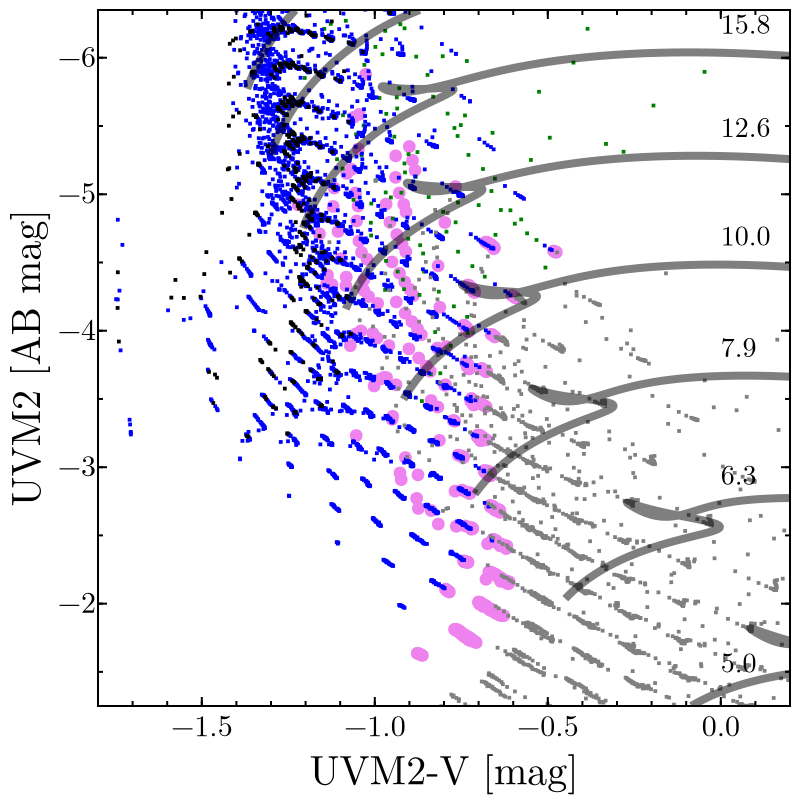

In [27]:

minorlogticks = union( [ k  for i in -5:1:5  for k in (10. ^i):(10. ^i):(10. ^(i+1)) ] )

FIG = Figure(size=(400,400), figure_padding=5)
grid = FIG[1,1] = GridLayout()

axb = plot_settings(grid[1,1], xlabel = "UVM2-V [mag]", 
                ylabel = "UVM2 [AB mag]",
                title = "", xticks = -100.:.5:100, xmticks= -100.:0.1:100, yticks = -100.:1:100, ymticks = -100.:0.5:100)

cmap = reverse(Makie.ColorSchemes.rust)
cmap2 = reverse(to_colormap([:black, :purple, :violet]))

crange = (800,4500)
crange2 = (log10(2), log10(2000))
extram = :rect 
extrams = 3


new_x(Type) = sum_mag.( (get_mag.(stats[Type]["T1"],  stats[Type]["L1"], "Swift_UVM2")), (get_mag.(stats[Type]["T2"],  stats[Type]["L2"], "Swift_UVM2"))) .- 
              sum_mag.( (get_mag.(stats[Type]["T1"],  stats[Type]["L1"], "Swift_V")   ), (get_mag.(stats[Type]["T2"],  stats[Type]["L2"], "Swift_V")   ))
new_y(Type) = sum_mag.( (get_mag.(stats[Type]["T1"],  stats[Type]["L1"], "Swift_UVM2")), (get_mag.(stats[Type]["T2"],  stats[Type]["L2"], "Swift_UVM2")))
new_x2(Type) = stats[Type]["T1"]
new_y2(Type) = stats[Type]["cL1"]
# scatter!(axb, new_x("II-i"), new_y("II-i"), color= :orange, marker = :circle)
scatter!(axb, new_x("Ibc-i"),new_y("Ibc-i"), color= :violet, marker = :circle)
# scatter!(axb, new_x("IIP" ), new_y("IIP" ), color= :red   , marker = extram, markersize = extrams)
scatter!(axb, new_x("IIb"),  new_y("IIb"), color= :green ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("Ibc"),  new_y("Ibc"), color= :blue  ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("BH"),   new_y("BH"), color= :black  ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("WD" ),  new_y("WD" ), color= :gray  ,  marker = extram, markersize = extrams)


for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1, :center_he4])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99

    ms =  (0.50 .< h.center_he4 ) .&& ( h.center_h1 .< 0.99 * h.center_h1[1])
    the_x = (get_mag.(h.log_Teff[ms],  h.log_L[ms], "Swift_UVM2")) - (get_mag.(h.log_Teff[ms],  h.log_L[ms], "Swift_V"))
    the_y = (get_mag.(h.log_Teff[ms],  h.log_L[ms], "Swift_UVM2"))

    lines!(axb, the_x, the_y, color = RGBAf(0,0,0,0.5), linewidth = 4)   
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61
    ix_txt = find_nearest(the_x, 0)
    text!(axb, 0, the_y[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :black)
 end
for logm in 1.10:0.10:1.4
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1, :center_he4])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    ms =  (0.50 .< h.center_he4) .&& ( h.center_h1 .< 0.99 * h.center_h1[1])
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61

    the_x = (get_mag.(h.log_Teff,  h.log_L, "Swift_UVM2")) - (get_mag.(h.log_Teff,  h.log_L, "Swift_V"))
    the_y = (get_mag.(h.log_Teff,  h.log_L, "Swift_UVM2"))

    lines!(axb, the_x[ms], the_y[ms], color = RGBAf(0,0,0,0.5), linewidth = 4)   

    ix_txt = find_nearest(the_x, 0)
    text!(axb, 0, the_y[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :black)

end
colgap!(grid, 50)

xlims!(axb, -1.8,.2)
ylims!(axb,  -1.25, -6.35)
 

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("caseC_mags_Heburn.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png



FIG


filename = case_C_BURN_He_50_1.pdf

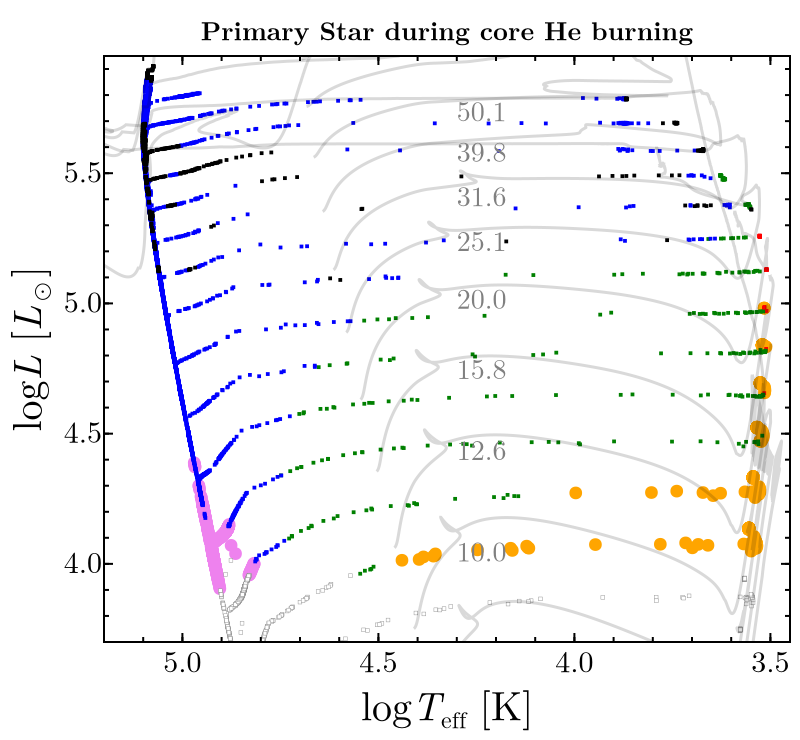

In [36]:

minorlogticks = union( [ k  for i in -5:1:5  for k in (10. ^i):(10. ^i):(10. ^(i+1)) ] )

FIG = Figure(size=(400,370), figure_padding=5)
grid = FIG[1,1] = GridLayout()

axb = plot_settings(grid[1,1], xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]", 
                ylabel = L"\log L \ [L_\odot]", titlesize=13,
                title = "Primary Star during core He burning", xticks = 0.:.5:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)
                cmap = reverse(Makie.ColorSchemes.rust)
cmap2 = reverse(to_colormap([:black, :purple, :violet]))

crange = (800,4500)
crange2 = (log10(2), log10(2000))
extram = :rect 
extrams = 3


new_x(Type) = stats[Type]["T1"]
new_y(Type) = stats[Type]["L1"]
new_x2(Type) = stats[Type]["T1"]
new_y2(Type) = stats[Type]["L1"]-stats[Type]["cL1"]
scatter!(axb, new_x("II-i"), new_y("II-i"), color= :orange, marker = :circle)
scatter!(axb, new_x("Ibc-i"),new_y("Ibc-i"), color= :violet, marker = :circle)
scatter!(axb, new_x("IIP" ), new_y("IIP" ), color= :red   , marker = extram, markersize = extrams)
scatter!(axb, new_x("IIb"),  new_y("IIb"), color= :green ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("Ibc"),  new_y("Ibc"), color= :blue  ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("BH"),   new_y("BH"), color= :black  ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("WD" ),  new_y("WD" ),  color= :white, strokewidth = 0.2, strokecolor = :gray,  marker = extram, markersize = extrams)
xlims!(axb,  5.2,3.45)
 ylims!(axb,  3.7,5.95)
# xlims!(axb2,  5.1,3.45)
#  ylims!(axb2,  .1,1.5)
 

for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))   
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61
    # lines!(axb2, h.log_Teff[post_zams], log_cL[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.3)
    # @printf("%.2f logL-T = %.2f/%.2f\n", logm, h.log_Teff[ix_txt], h.log_L[ix_txt], logc_L)
    text!(axb, 4.3, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
 end
for logm in 1.10:0.10:1.9
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    # lines!(axb2, h.log_Teff[post_zams], log_cL[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.3)
    # print(ix_txt, " ")
    text!(axb, 4.3, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)

end
colgap!(grid, 50)


save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("case_C_%s.pdf", when)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png
@printf("filename = %s",outfilename )


FIG


filename = case_C_end_1.pdf

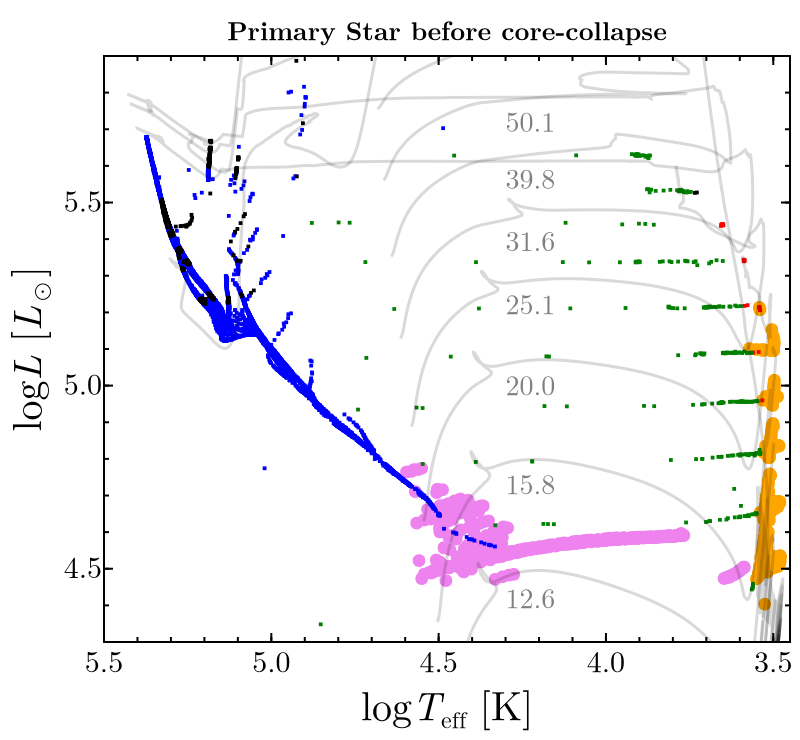

In [38]:

minorlogticks = union( [ k  for i in -5:1:5  for k in (10. ^i):(10. ^i):(10. ^(i+1)) ] )

FIG = Figure(size=(400,370), figure_padding=5)
grid = FIG[1,1] = GridLayout()

axb = plot_settings(grid[1,1], xlabel = L"\log T_\mathrm{eff} \ [\mathrm{K}]", 
                ylabel = L"\log L \ [L_\odot]",titlesize=13,
                title = "Primary Star before core-collapse",  xticks = 0.:.5:100, xmticks= 0.:0.1:100, yticks = 0.:.5:100, ymticks = 0.:0.1:100)
                cmap = reverse(Makie.ColorSchemes.rust)
cmap2 = reverse(to_colormap([:black, :purple, :violet]))

crange = (800,4500)
crange2 = (log10(2), log10(2000))
extram = :rect 
extrams = 3


new_x(Type) = stats[Type]["T1"]
new_y(Type) = stats[Type]["L1"]
new_x2(Type) = stats[Type]["T1"]
new_y2(Type) = stats[Type]["L1"]-stats[Type]["cL1"]
scatter!(axb, new_x("II-i"), new_y("II-i"), color= :orange, marker = :circle)
scatter!(axb, new_x("Ibc-i"),new_y("Ibc-i"), color= :violet, marker = :circle)
scatter!(axb, new_x("IIP" ), new_y("IIP" ), color= :red   , marker = extram, markersize = extrams)
scatter!(axb, new_x("IIb"),  new_y("IIb"), color= :green ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("Ibc"),  new_y("Ibc"), color= :blue  ,  marker = extram, markersize = extrams)
scatter!(axb, new_x("BH"),   new_y("BH"), color= :black  ,  marker = extram, markersize = extrams)
# scatter!(axb, new_x("WD" ),  new_y("WD" ), color= :gray  ,  marker = extram, markersize = extrams)
xlims!(axb,  5.5,3.45)
 ylims!(axb,  4.3,5.9)
# xlims!(axb2,  5.1,3.45)
#  ylims!(axb2,  .1,1.5)
 

for logm in 0.70:0.10:1.09
    h = CSV.read(SG_dir*@sprintf("%5.3f_150.data", logm), 
    header=1, DataFrame, delim = ' ' , ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))   
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61
    # lines!(axb2, h.log_Teff[post_zams], log_cL[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.3)
    # @printf("%.2f logL-T = %.2f/%.2f\n", logm, h.log_Teff[ix_txt], h.log_L[ix_txt], logc_L)
    text!(axb, 4.3, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)
 end
for logm in 1.10:0.10:1.9
    h = CSV.read(CC_dir*@sprintf("single_star/%4.2f.data", logm), 
    header=1, DataFrame, delim = ' ' ,ignorerepeated=true,
    select=[:log_Teff, :log_L, :log_g, :center_h1])
    post_zams = h.center_h1 .< h.center_h1[1]*0.99
    log_cL =  log10.((10 .^h.log_Teff) .^ 4 ./ 10 .^ h.log_g )  .-10.61
    lines!(axb, h.log_Teff[post_zams], h.log_L[post_zams], color = RGBAf(0,0,0,0.15))    
    # lines!(axb2, h.log_Teff[post_zams], log_cL[post_zams], color = RGBAf(0,0,0,0.15))    
    ix_txt = find_nearest(h.log_Teff, 4.3)
    # print(ix_txt, " ")
    text!(axb, 4.3, h.log_L[ix_txt]-.1,text =  @sprintf("%.1f", 10^logm), color = :gray)

end
colgap!(grid, 50)


save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("case_C_%s.pdf", when)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png
@printf("filename = %s",outfilename )


FIG


In [165]:
minMenv = +Inf 
when = "ini_RLOF_C"
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])
            mod = MODELS[logM][logP][q]
            n = mod["mod"]
            (mod["SN1"]["II-i"] == 0 || mod["first"] != "1") && continue 
            
            M = f_MW[!, "M_1_"*when][n]
            Mhe = f_MW[!, "M_he_core_1_"*when][n]
            dM = mod["dM_C"]
            dM > 0.01 && (minMenv = min(minMenv, M-Mhe ))

            @printf(" II-i  : Menv =  %5.2f  dM_C = %.2f \n", M-Mhe, dM)
            
        end
    end
end
print(minMenv)

 II-i  : Menv =   0.27  dM_C = 0.00 
 II-i  : Menv =   0.32  dM_C = 0.01 
 II-i  : Menv =   0.31  dM_C = 0.01 
 II-i  : Menv =   0.39  dM_C = 0.05 
 II-i  : Menv =   0.49  dM_C = 0.10 
 II-i  : Menv =   0.32  dM_C = 0.01 
 II-i  : Menv =   0.46  dM_C = 0.09 
 II-i  : Menv =   0.58  dM_C = 0.17 
 II-i  : Menv =   0.67  dM_C = 0.23 
 II-i  : Menv =   0.32  dM_C = 0.01 
 II-i  : Menv =   0.48  dM_C = 0.11 
 II-i  : Menv =   0.64  dM_C = 0.21 
 II-i  : Menv =   0.76  dM_C = 0.29 
 II-i  : Menv =   0.86  dM_C = 0.35 
 II-i  : Menv =   0.30  dM_C = 0.00 
 II-i  : Menv =   0.48  dM_C = 0.11 
 II-i  : Menv =   0.68  dM_C = 0.23 
 II-i  : Menv =   0.84  dM_C = 0.34 
 II-i  : Menv =   1.00  dM_C = 0.45 
 II-i  : Menv =   1.15  dM_C = 0.55 
 II-i  : Menv =   0.45  dM_C = 0.09 
 II-i  : Menv =   0.68  dM_C = 0.24 
 II-i  : Menv =   0.88  dM_C = 0.38 
 II-i  : Menv =   1.12  dM_C = 0.55 
 II-i  : Menv =   1.34  dM_C = 0.70 
 II-i  : Menv =   1.53  dM_C = 0.81 
 II-i  : Menv =   6.58  dM_C = 6.58 
 





# logPq Diagrams 

In [20]:
set_theme!(theme_latexfonts())

logM = 1.00

which_SN = "1"
@printf("\nworking with logM=%.2f\n", logM)

@printf("printing %s\n", which_SN)
logM_t = to_key(logM)
#MAkE SURE MODELS ARRAY IS LOADED FROM SN_calculator_MW.jl 
#x = f.q
#y = f.logP
xticks = range(0,1,step=0.1)
xmticks = range(0,1,step=0.05)
xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
yticks = range(0,4,step=0.2)
ymticks = range(0,4,step=0.05)
yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]




qs = unique(f_MW.q)
range_q = range(minimum(qs), maximum(qs), step=0.05)
len_q = length(range_q)
ps = unique(f_MW.logP)
range_p = range(minimum(ps), maximum(ps), step=0.05)
len_p = length(range_p)
xx = hcat([ [q for q in range_q] for p in  range_p]...) 
yy = hcat([ [p for q in range_q] for p in  range_p]...) 

outcomes = ["WD", "IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "X"]
ctick_label = outcomes 
ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
alpha = 0.66
color_coding = OrderedDict()
#https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.1, .1, .1 ,alpha) 
color_coding["X"]     = RGBAf(1,1,1 ,alpha)   
color_coding["WD"]     = RGBAf(0.7,0.7,0.7 ,alpha)   
mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

zz =  zeros(size(xx))
fill!(zz, 1e99)
z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5


yticklabelsize=15.5
ylabelsize=16
xticklabelsize = 15.5
xlabelsize = 16
yticklabelpad = 1.8
d=0.050/2


logM_t = to_key(logM)
M_t = to_key(10^logM)
FIGURE = Figure(size=(500,500), figure_padding = 0)
#FIGURE = Figure(size=(900,900))
string = L"M_\mathrm{1,i}=%$(M_t)\ M_\odot"
ax = plot_settings(FIGURE[1, 1]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title =string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )
myplot = heatmap!(ax, qs, ps, zz, colormap=mycmap, 
                colorrange=(z_min,z_max), alpha=alpha)


@printf("Populating plot...\n")

cases = Dict()
cases["along_q"]    = Dict()
cases["along_logP"]    = Dict()
for q in qs 
    cases["along_q"][to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
end 
for logP in logPs 
    cases["along_logP"][to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
end

for i in range(1,length(f_MW.q))
    
    f_MW.logM[i] != logM && continue 
    
    q = f_MW.q[i]
    logP = f_MW.logP[i]
    logM = f_MW.logM[i]

    q_t = to_key(q)
    logP_t = to_key(logP)
    logM_t = to_key(logM)
    if ! ( (logM in logMs) && (logP in logPs) && (q in qs))
        continue 
    end 
    try 
        MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
    catch 
         continue
    end 
    
    model = MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
    case = nothing
    if length(MODELS[logM_t][logP_t][q_t]["case"]) > 0 
        case = MODELS[logM_t][logP_t][q_t]["case"][1]
    else
        casus =  MODELS[logM_t][logP_t][q_t]["casus"]
        occursin("A", casus) && (case = 'A')
        occursin("B", casus) && (case = 'B')
        occursin("C", casus) && (case = 'C')
        isnothing(case)      && (case = 'N') 
    end 

    push!(cases["along_q"][q_t]["logP"],       logP)
    push!(cases["along_q"][q_t]["case"],       logP < 0.30 ? 'A' : case)
    push!(cases["along_logP"][logP_t]["q"],    q)
    push!(cases["along_logP"][logP_t]["case"], case)


    master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

    offset = 0


    for outcome in outcomes 
        model[outcome] == 0 && (1 in [model[out] for out in outcomes]) ? continue : nothing 
        background_color = color_coding[outcome]

        q_min = q-d + offset*2*d
        q_max = q_min + model[outcome]*2*d
        sub_point = Point2f[(q_min,logP-d),
                            (q_max,logP-d),
                            (q_max,logP+d),
                            (q_min,logP+d)]

        mer_patter = Pattern("\\", linecolor=:black, backgroundcolor=:transparent, width=3)
        imt_patter = Pattern("\\", linecolor=:white, backgroundcolor=:transparent, width=3)
        # imt_patter = mer_patter  
        poly!(sub_point,
                strokewidth=0,  color = background_color, strokecolor = :black, transparency=false,
        )

        if occursin("mer", MODELS[logM_t][logP_t][q_t]["casus"]) || (case == "C" && q < 0.70) 
            poly!(sub_point,
            strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
            )
        elseif occursin("IMT", MODELS[logM_t][logP_t][q_t]["casus"])
            poly!(sub_point,
            strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
            )
        end 

        offset += model[outcome]

    end 

    # poly!(master_point,
    # strokewidth=0.1,  color = :transparent,  strokecolor = :black, transparency=true,
    # )

end 

                        
xlims!(ax, 1-0.025, 0.10-0.025)
ylims!(ax, 0.15-0.025, 3.70+0.025)
# Colorbar(FIGURE[1, 2], myplot, size =25, label = "Outcome Star "*which_SN, 
#     ticks=(ctick, ctick_label) 
# )

cc2 = Dict()
cc2["IIP"]   = RGBAf(1,0,0,1)    
cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

plot_the_star(x,y, c, ec; m=:rect)= scatter!(ax, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)
if logM == 1.10 && which_SN == "1"

    pts =[]
    ec = "black"
    c = "gray"
    for logP in 2.75:0.05:3.45
        for q in 0.10:0.05:0.95
            if  logP == 3.45  
                (q == 0.95) && plot_the_star(q,logP, cc2["IIP"],   ec)
            elseif logP == 3.40 
                (0.65 <= q <= 0.95) && plot_the_star(q,logP,  cc2["II-i"],   ec)
                (0.50 <= q <  0.65) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.35
                (q>=0.35) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.30) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.30
                (q>=0.20) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.15) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.25
                (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (0.55>=q>=0.15) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.10) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.20
                (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.25) && plot_the_star(q,logP, cc2["II-i"],   ec)
            elseif logP == 3.15
                (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
                (q<=0.10) && plot_the_star(q,logP, cc2["II-i"],   ec)
            elseif logP == 3.10
                (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 3.05
                (q>=0.75) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q==0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 3.00
                (q>=0.80) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.80>q>0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.95
                (q>=0.90) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.70) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.90>q>0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.90
                (q==0.95) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.75) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.95>q>0.75) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.85
                (q==0.80) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q >0.80) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.80
                (q==0.90) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q==0.95) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif  logP == 2.75 
                (q == 0.95) && plot_the_star(q,logP,   cc2["Ibc"],   ec)
            end

        end 
    end

    for logP in [0.7, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
        plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
    end
end 


case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                "BC"=>:dot, "CB"=>:dot,
                "AC"=>:dashdot,"CA"=>:dashdot,
                "AN"=>:solid,"NA"=>:solid,
                "BN"=>:solid,"NB"=>:solid,
                "CN"=>:solid,"NC"=>:solid)

case_prev = 'A'
direction = "along_q"
irregularities = 0
for q_t in keys(cases[direction]) 
    q=parse(Float64, q_t)
    coord_prev = cases[direction][q_t]["logP"][1]
    case_prev =  cases[direction][q_t]["case"][1]

    # @printf("q = %.2f\n", q)
    for i in range(2, length(cases[direction][q_t]["case"]))
        coord = cases[direction][q_t]["logP"][i]
        case_id = cases[direction][q_t]["case"][i]
        if (case_id != case_prev) 
            case_boundary = @sprintf("%s%s", case_prev, case_id)
            
            if case_boundary in keys(case_style)
                lines!(ax, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
            else
                @printf("WARNING")
                @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                # @printf("\n\n this is irregular: previous model ")
                # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                # @printf("\n\n following model ")
                # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                irregularities += 1
            end 
        end
        case_prev = case_id
        coord_prev = coord 
    end 
end

case_prev = 'A'
direction = "along_logP"
irregularities = 0
for logP_t in keys(cases[direction]) 
    logP=parse(Float64, logP_t)
    coord_prev = cases[direction][logP_t]["q"][1]
    case_prev =  cases[direction][logP_t]["case"][1]

    # @printf("logP = %.2f\n", q)
    for i in range(2, length(cases[direction][logP_t]["case"]))
        coord = cases[direction][logP_t]["q"][i]
        case_id = cases[direction][logP_t]["case"][i]
        if (case_id != case_prev) 
            case_boundary = @sprintf("%s%s", case_prev, case_id)
            
            if case_boundary in keys(case_style)
                lines!(ax, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
            else
                @printf("WARNING")
                @printf(" boundary @ logP %s, q %.3f -> %.3f [%3d] (%s -> %s: %s)\n", logP_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                # @printf("\n\n this is irregular: previous model ")
                # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                # @printf("\n\n following model ")
                # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                irregularities += 1
            end 
        end
        case_prev = case_id
        coord_prev = coord 
    end 
end

irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)







label_mer_patt =   Pattern("\\", linecolor=:black, background_color=:lightgray, width=3)
label_imt_patt =   Pattern("\\", linecolor=:white, background_color=:lightgray, width=3)

# scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
logM == 1.10 && scatter!(ax, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
logM in [1.10,1.15] && scatter!(ax, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")
# barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
barplot!(ax, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
barplot!(ax, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
barplot!(ax, [-100], [0], color = color_coding["IIP"],   strokewidth=0.1, label =  "SN IIP/L")
barplot!(ax, [-100], [0], color = color_coding["IIP-B"], strokewidth=0.1, label = "SN 87A")
barplot!(ax, [-100], [0], color = color_coding["IIb"],   strokewidth=0.1, label = "SN IIb")
barplot!(ax, [-100], [0], color = color_coding["II-i"],  strokewidth=0.1, label = "SN IIn")
barplot!(ax, [-100], [0], color = color_coding["Ibc"],   strokewidth=0.1, label = "SN Ibc")
barplot!(ax, [-100], [0], color = color_coding["Ibc-i"], strokewidth=0.1, label = "SN Ibn")
barplot!(ax, [-100], [0], color = color_coding["WD"],    strokewidth=0.1, label = "WD")

# axislegend(ax,  position=:rc, 
#     nbanks=1, labelsize=12, rowgap =2, colgap =0)
FIGURE[1,2] = Legend(FIGURE, ax,  position=:rt, 
            nbanks=1, titleposition=:top, labelsize = 12, framevisible = false)


@printf("Plot successfull, saving !\n\n\n")
resize_to_layout!

# outfilename = @sprintf("logPQ_SN%s_%s.pdf", which_SN, logM_t)
# save(outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [1]

In [31]:
logM, logP, q = 2.00, 1.0, 0.55
# logM, logP, q = 1.15, 0.65, 0.900
@printf("logM,q,logP = %.3f/%.3f/%.3f", logM, q, logP)
report_model(f_MW, MODELS, logM, q, logP, ["M_1", "M_he_core_1", "M_2", "M_he_core_2"])

logM,q,logP = 2.000/0.550/1.000
History for model 36424
STAGE                 |  Age (Myr)         M_1 M_he_core_1        M_2 M_he_core_2
          end_BURN_H_1|    3.405500  10.986800   7.616030  46.529200   0.000000
         ini_BURN_He_1|    3.482500   9.465140   8.451180  45.806300   0.000000
           stripping_1|    3.535400   8.455640   8.455640  44.852410   0.000000
                 end_1|    3.758821   7.223660   7.223660  41.248550   0.000000
                 end_2|    3.758821   7.223660   7.223660  41.248550   0.000000
Star 1 termination:     HeB
Star 1 termination:     MS
Reason for termination: IMT-B(1)-early
Mass transfer case(s):  

SN order : M - X

First SN       Type     X solver pathway: X
Mf   NaN Mhe   NaN Mco   NaN
dM_C NaN Eexp   NaN  Mni   NaN Mremg   NaN
Second SN       Type IIP-B solver pathway: (CORE) SINGLE_SN
Mf  13.4 Mhe   5.5 Mco   4.1
dM_C -1.00 Eexp 2.3e+51  Mni   0.1 Mremg   1.6


In [ ]:
set_theme!(theme_latexfonts())


logP_range = 0.05:0.05:3.70
function logPq_plotter_SN(FIGURE::Figure, logM::Float64, which::String; show_legend = true, location = [1,1], savefig = true, customtitle = nothing)

    
    which_SN = which
    @printf("\nworking with logM=%.2f\n", logM)
    @printf("printing %s\n", which_SN)

    logM_t = to_key(logM)
    M_t = @sprintf("%.1f", 10^logM)
    xticks = range(0,1,step=0.1)
    xmticks = range(0,1,step=0.05)
    xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
    yticks = range(0,4,step=0.2)
    ymticks = range(0,4,step=0.05)
    yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]
    title_string = isnothing(customtitle) ? L"M_\mathrm{1,i}=%$(M_t)\ M_\odot" : customtitle

    yticklabelsize=15.5
    ylabelsize=16
    xticklabelsize = 15.5
    xlabelsize = 16
    yticklabelpad = 1.8
    d=0.050/2

    axis = plot_settings(FIGURE[location[1], location[2]]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title = title_string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )

    qs = unique(f_MW.q)
    range_q = range(minimum(qs), maximum(qs), step=0.05)
    len_q = length(range_q)
    ps = unique(f_MW.logP)
    range_p = range(minimum(ps), maximum(ps), step=0.05)
    len_p = length(range_p)
    xx = hcat([ [q for q in range_q] for p in  range_p]...) 
    yy = hcat([ [p for q in range_q] for p in  range_p]...) 

    outcomes = ["WD", "IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "X"]
    ctick_label = outcomes 
    ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
    alpha = 0.66
    color_coding = OrderedDict()
    #https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
    color_coding = Dict() 
    color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
    color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
    color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
    color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
    color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
    color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
    color_coding["BH"] = RGBAf(.1, .1, .1 ,alpha) 
    color_coding["X"]     = RGBAf(1,1,1 ,alpha)   
    color_coding["WD"]     = RGBAf(0.7,0.7,0.7 ,alpha)   
    mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

    zz =  zeros(size(xx))
    fill!(zz, 1e99)
    z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5



    myplot = heatmap!(axis, qs, ps, zz, colormap=mycmap, 
                    colorrange=(z_min,z_max), alpha=alpha)


    @printf("Populating plot...\n")

    cases = Dict()
    cases["along_q"]    = Dict()
    cases["along_logP"]    = Dict()
    for q in qs 
        cases["along_q"][to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
    end 
    for logP in logP_range 
        cases["along_logP"][to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
    end

    for i in range(1,length(f_MW.q))
        
        f_MW.logM[i] != logM && continue 
        
        q = f_MW.q[i]
        logP = f_MW.logP[i]
        logM = f_MW.logM[i]

        q_t = to_key(q)
        logP_t = to_key(logP)
        logM_t = to_key(logM)
        if ! ( (logM in logMs) && (logP in logP_range) && (q in qs))
            continue 
        end 
        try 
            MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
        catch 
            continue
        end 
        
        model = MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
        casus =  MODELS[logM_t][logP_t][q_t]["casus"]

        case = nothing
        if length(MODELS[logM_t][logP_t][q_t]["case"]) > 0 
            case = MODELS[logM_t][logP_t][q_t]["case"][1]
        elseif ! occursin("IMT", casus) 
            
            occursin("A", casus) && (case = 'A')
            occursin("B", casus) && (case = 'B')
            occursin("C", casus) && (case = 'C')
            isnothing(case)      && (case = 'N') 
        else 
            case = 'N'
        end 

        push!(cases["along_q"][q_t]["logP"],       logP)
        push!(cases["along_q"][q_t]["case"],       logP < 0.30 ? 'A' : case)
        push!(cases["along_logP"][logP_t]["q"],    q)
        push!(cases["along_logP"][logP_t]["case"], case)


        master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

        offset = 0


        for outcome in outcomes 
            model[outcome] == 0 && (1 in [model[out] for out in outcomes]) ? continue : nothing 
            background_color = color_coding[outcome]

            q_min = q-d + offset*2*d
            q_max = q_min + model[outcome]*2*d
            sub_point = Point2f[(q_min,logP-d),
                                (q_max,logP-d),
                                (q_max,logP+d),
                                (q_min,logP+d)]

            mer_patter = Pattern("\\", linecolor=:black, backgroundcolor=:transparent, width=3)
            imt_patter = Pattern("\\", linecolor= which_SN == "1" ? :white : :gray, backgroundcolor=:transparent, width=3)
            # imt_patter = mer_patter  
            poly!(sub_point,
                    strokewidth=0,  color = background_color, strokecolor = :black, transparency=false,
            )

            if occursin("mer", MODELS[logM_t][logP_t][q_t]["casus"]) || (case == 'C' && q < 0.70)
                poly!(sub_point,
                strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
                )
            elseif occursin("IMT", MODELS[logM_t][logP_t][q_t]["casus"])
                poly!(sub_point,
                strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
                )
            end 

            offset += model[outcome]

        end 

        # poly!(master_point,
        # strokewidth=0.1,  color = :transparent,  strokecolor = :black, transparency=true,
        # )

    end 

                            
    xlims!(axis, 1-0.025, 0.10-0.025)
    ylims!(axis, 0.05-0.025, 3.70+0.025)
    # Colorbar(FIGURE[1, 2], myplot, size =25, label = "Outcome Star "*which_SN, 
    #     ticks=(ctick, ctick_label) 
    # )

    cc2 = Dict()
    cc2["IIP"]   = RGBAf(1,0,0,1)    
    cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
    cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
    cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
    cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

    plot_the_star(x,y, c, ec; m=:rect)= scatter!(axis, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)
    # if logM == 1.10 && which_SN == "1"

    #     pts =[]
    #     ec = "black"
    #     c = "gray"
    #     for logP in 2.75:0.05:3.45
    #         for q in 0.10:0.05:0.95
    #             if  logP == 3.45  
    #                 (q == 0.95) && plot_the_star(q,logP, cc2["IIP"],   ec)
    #             elseif logP == 3.40 
    #                 (0.65 <= q <= 0.95) && plot_the_star(q,logP,  cc2["II-i"],   ec)
    #                 (0.50 <= q <  0.65) && plot_the_star(q,logP,  cc2["IIP"],   ec)
    #             elseif logP == 3.35
    #                 (q>=0.35) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q<=0.30) && plot_the_star(q,logP,  cc2["IIP"],   ec)
    #             elseif logP == 3.30
    #                 (q>=0.20) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q<=0.15) && plot_the_star(q,logP,  cc2["IIP"],   ec)
    #             elseif logP == 3.25
    #                 (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (0.55>=q>=0.15) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.10) && plot_the_star(q,logP,  cc2["IIP"],   ec)
    #             elseif logP == 3.20
    #                 (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q<=0.25) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #             elseif logP == 3.15
    #                 (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #                 (q<=0.10) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #             elseif logP == 3.10
    #                 (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 3.05
    #                 (q>=0.75) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (q==0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 3.00
    #                 (q>=0.80) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (0.80>q>0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 2.95
    #                 (q>=0.90) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.70) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (0.90>q>0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 2.90
    #                 (q==0.95) && plot_the_star(q,logP, cc2["II-i"],   ec)
    #                 (q==0.75) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (0.95>q>0.75) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 2.85
    #                 (q==0.80) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (q >0.80) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif logP == 2.80
    #                 (q==0.90) && plot_the_star(q,logP, cc2["Ibc"],   ec)
    #                 (q==0.95) && plot_the_star(q,logP, cc2["IIb"],   ec)
    #             elseif  logP == 2.75 
    #                 (q == 0.95) && plot_the_star(q,logP,   cc2["Ibc"],   ec)
    #             end

    #         end 
    #     end

    #     for logP in [0.7, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
    #         plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
    #     end
    # end 
    # if logM == 1.15 && which_SN == "1"
    #     for logP in [0.7, 0.8, 1]
    #         plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
    #     end
    #     plot_the_star(0.5,1.2,  cc2["Ibc"],  "black", m=:circle)

    # end

    case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                    "BC"=>:dot, "CB"=>:dot,
                    "AC"=>:dashdot,"CA"=>:dashdot,
                    "AN"=>:solid,"NA"=>:solid,
                    "BN"=>:solid,"NB"=>:solid,
                    "CN"=>:solid,"NC"=>:solid)

    case_prev = 'A'
    direction = "along_q"
    irregularities = 0
    for q_t in keys(cases[direction]) 
        q=parse(Float64, q_t)
        coord_prev = cases[direction][q_t]["logP"][1]
        case_prev =  cases[direction][q_t]["case"][1]

        # @printf("q = %.2f\n", q)
        for i in range(2, length(cases[direction][q_t]["case"]))
            coord = cases[direction][q_t]["logP"][i]
            case_id = cases[direction][q_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    case_prev = 'A'
    direction = "along_logP"

    for logP_t in keys(cases[direction]) 
        logP=parse(Float64, logP_t)
        print(cases[direction][logP_t])
        coord_prev = cases[direction][logP_t]["q"][1]
        case_prev =  cases[direction][logP_t]["case"][1]

        # @printf("logP = %.2f\n", q)
        for i in range(2, length(cases[direction][logP_t]["case"]))
            coord = cases[direction][logP_t]["q"][i]
            case_id = cases[direction][logP_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ logP %s, q %.3f -> %.3f [%3d] (%s -> %s: %s)\n", logP_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    # irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)







    label_mer_patt =   Pattern("\\", linecolor=:black, background_color=:lightgray, width=3)
    label_imt_patt =   Pattern("\\", linecolor=:white, background_color=:lightgray, width=3)

    # scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
    # logM == 1.10 && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
    # logM in [1.10,1.15] && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")
    # barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
    barplot!(axis, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
    barplot!(axis, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
    barplot!(axis, [-100], [0], color = "white",     label =  " ")
    barplot!(axis, [-100], [0], color = color_coding["BH"],   strokewidth=0.1, label =  "BH")
    barplot!(axis, [-100], [0], color = color_coding["IIP"],   strokewidth=0.1, label = "SN IIP/L")
    barplot!(axis, [-100], [0], color = color_coding["II-i"],  strokewidth=0.1, label = "SN IIn")
    barplot!(axis, [-100], [0], color = color_coding["IIb"],   strokewidth=0.1, label = "SN IIb")
    barplot!(axis, [-100], [0], color = color_coding["IIP-B"], strokewidth=0.1, label = "SN 87A")
    barplot!(axis, [-100], [0], color = color_coding["Ibc"],   strokewidth=0.1, label = "SN Ibc")
    barplot!(axis, [-100], [0], color = color_coding["Ibc-i"], strokewidth=0.1, label = "SN Ibn")
    barplot!(axis, [-100], [0], color = color_coding["WD"],    strokewidth=0.1, label = "WD")

    # axislegend(ax,  position=:rc, 
    #     nbanks=1, labelsize=12, rowgap =2, colgap =0)
    if show_legend
        if isa(location[2],UnitRange)
            i=first(location[2])+1
            s=step(location[2])
            e=last(location[2])+1
            location[2] = i:s:e
            location[2]= e
        else   
            location[2]+=1
        end

        FIGURE[location[1],location[2]] = Legend(FIGURE, axis,  position=:rt, 
                nbanks=1, titleposition=:top, labelsize = 12, framevisible = false)
    end

    resize_to_layout!

    if savefig
        outfilename = @sprintf("../output/logPq_SN/SNnew_%s_%s.pdf", which_SN, logM_t)
        save(outfilename, FIGURE)     
        outfilename_png = @sprintf("../output/logPq_SN/SNnew_%s_%s.png", which_SN, logM_t)
        save(outfilename_png, FIGURE)    
    end
end

for logM in 1.15:0.05:2.00 #0.70:0.05:2.00
    FIGURE = Figure(size=(500,500), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "1", show_legend = true)
    FIGURE

    FIGURE = Figure(size=(500,500), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "2", show_legend = true)
    FIGURE

    logM_t=to_key(logM)

    logm_sne = 0.
    for logP in logP_range 
        logP_t = to_key(logP)
        for q in qs
            q_t = to_key(q)
            mod = MODELS[logM_t][logP_t][q_t]
            sn1 = mod["SN1"]
            sn2 = mod["SN2"]
            pdf = mod["pdf"]["tot"]

            is_sn1_cc = sn1["IIP"]+sn1["IIP-B"]+sn1["IIb"]+sn1["Ibc"]+sn1["Ibc-i"]+sn1["II-i"]
            is_sn2_cc = sn2["IIP"]+sn2["IIP-B"]+sn2["IIb"]+sn2["Ibc"]+sn2["Ibc-i"]+sn2["II-i"]
            is_sn1_cc>0 && (logm_sne += pdf)
            is_sn2_cc>0 && (logm_sne += pdf)
        end
    end

    fraction_sne = @sprintf("%.1f",(logm_sne/total_SNe*100))
    M_t = @sprintf("%.1f",(10^logM))
    FIGURE = Figure(size=(1000,1000*sqrt(2)/3), figure_padding = 0)
    frac_of_bin = @sprintf("%.1f",((10^logM)^(-1.35)/0.777*100))
    title_string = L"M_\mathrm{1,i}=%$(M_t)\ M_\odot \  \ (%$(frac_of_bin)% \ \mathrm{of \ Binaries}, \  %$(fraction_sne)% \ \mathrm{of \ SNe})"
    FIGURE[0, 0:10] = Label(FIGURE, title_string, fontsize = 30 )
    logPq_plotter_SN(FIGURE, logM, "1", show_legend = true, location=[1,0:4], savefig=false, customtitle = "Primary + Merger Product")
    logPq_plotter_SN(FIGURE, logM, "2", show_legend = false, location=[1,6:10], savefig=false, customtitle = "Secondary" )
    outfilename = @sprintf("../output/logPq_SN/combined_SNe_%s_new.pdf", logM_t)
    save(outfilename, FIGURE)     
    outfilename_png = @sprintf("../output/logPq_SN/combined_SNe_%s_new.png", logM_t)
    save(outfilename_png, FIGURE)    


end 



In [38]:
directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
set_theme!(theme_latexfonts())


function find_transition_boundaries(df::DataFrame, logM_val; delta_cols=[:deltaM_A, :deltaM_B, :deltaM_C])
    # Filter models with the specified logM
    df_filtered = df[df.logM .== logM_val, :]
    
    # Sort for consistency (optional but helpful)
    sort!(df_filtered, [:logP, :q])
    
    # Function to detect transition edges (0 -> >0 or >0 -> 0)
    function find_edges(vec)
        return (vec[2:end] .> 0) .!= (vec[1:end-1] .> 0)    end
    
    boundaries = Dict()

    for col in delta_cols
        # Create mask of where a transition occurs
        edges = find_edges(df_filtered[!, col])
        
        # Collect midpoint coordinates of transitions
        coords = [(mean(df_filtered.logP[i:i+1]), mean(df_filtered.q[i:i+1])) for i in findall(edges)]
        
        boundaries[col] = coords
    end

    return boundaries
end


for logM in 0.700:0.050:2.000

    @printf("\nworking with logM=%.2f\n", logM)

    logM_t = to_key(logM)
    #MAkE SURE MODELS ARRAY IS LOADED FROM SN_calculator_MW.jl 
    #x = f.q
    #y = f.logP
    xticks = range(0,1,step=0.1)
    xmticks = range(0,1,step=0.05)
    xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
    yticks = range(0,4,step=0.2)
    ymticks = range(0,4,step=0.05)
    yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]





    qs = unique(f_MW.q)
    range_q = range(minimum(qs), maximum(qs), step=0.05)
    len_q = length(range_q)
    ps = unique(f_MW.logP)
    range_p = range(minimum(ps), maximum(ps), step=0.05)
    len_p = length(range_p)
    xx = hcat([ [q for q in range_q] for p in  range_p]...) 
    yy = hcat([ [p for q in range_q] for p in  range_p]...) 
    cases = Dict()
    cases["along_q"]    = Dict()
    cases["along_logP"]    = Dict()
    for q in qs 
        cases["along_q"][to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
    end 
    for logP in logPs 
        cases["along_logP"][to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
    end

    outcomes = ["WD", "IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "X"]
    ctick_label = outcomes 
    ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
    alpha = 0.66
    color_coding = OrderedDict()
    #https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
    color_coding = Dict() 
    color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
    color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
    color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
    color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
    color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
    color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
    color_coding["BH"] = RGBAf(.1, .1, .1 ,alpha) 
    color_coding["X"]     = RGBAf(1,1,1 ,alpha)   
    color_coding["WD"]     = RGBAf(.5,.5,.5 ,alpha) 
    
    cc2 = Dict()
    cc2["IIP"]   = RGBAf(1,0,0,1)    
    cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
    cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
    cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
    cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

    mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

    zz =  zeros(size(xx))
    fill!(zz, 1e99)
    z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5


    yticklabelsize=15.5
    ylabelsize=16
    xticklabelsize = 15.5
    xlabelsize = 16
    yticklabelpad = 1.8


    logM_t = to_key(logM)
    M_t = to_key(10^logM)
    FIGURE = Figure(size=(1000,500), figure_padding = 0)

    frac_of_bin = to_key((10^logM)^(-1.35)/0.777*100)
    string = L"M_\mathrm{1,i}=%$(M_t)\ M_\odot \  \ \ \ (%$(frac_of_bin)% \ \mathrm{of \ Binaries})"

    FIGURE[0, 0:10] = Label(FIGURE, string, fontsize = 30 )

    ax1 = plot_settings(FIGURE[1, 0:4]; 
                            xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                            ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                            title ="Primary star + Merger product", titlesize = 20,
                            yticklabelsize=yticklabelsize,
                            ylabelsize=ylabelsize,
                            xticklabelsize=xticklabelsize,
                            xlabelsize=xlabelsize,
                            yticklabelpad=yticklabelpad,
                            xticks=(xticks,xticks_text), xmticks=xmticks,
                            yticks=(yticks,yticks_text), ymticks=ymticks,
                            )
    ax2 = plot_settings(FIGURE[1, 6:10]; 
                            xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                            ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                            title ="Secondary star", titlesize = 20,
                            yticklabelsize=yticklabelsize,
                            ylabelsize=ylabelsize,
                            xticklabelsize=xticklabelsize,
                            xlabelsize=xlabelsize,
                            yticklabelpad=yticklabelpad,
                            xticks=(xticks,xticks_text), xmticks=xmticks,
                            yticks=(yticks,yticks_text), ymticks=ymticks,
                            )
    myplot = heatmap!(ax1, qs, ps, zz, colormap=mycmap, 
          colorrange=(z_min,z_max), alpha=alpha)
    myplot2 = heatmap!(ax2, qs, ps, zz, colormap=mycmap, 
             colorrange=(z_min,z_max), alpha=alpha)
                

    @printf("Populating plot...\n")
    for which_SN in ["1", "2"]
        for i in range(1,length(f_MW.q))
            ax = which_SN == "1" ? ax1 : ax2
            f_MW.logM[i] != logM && continue 
            
            q = f_MW.q[i]
            logP = f_MW.logP[i]
            logM = f_MW.logM[i]

            q_t = to_key(q)
            logP_t = to_key(logP)
            logM_t = to_key(logM)
            d=0.050/2
            if ! ( (logM in logMs) && (logP in logPs) && (q in qs))
                continue 
            end 
            try 
                MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
            catch 
                continue
            end 
            model = MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
            
            case = nothing
            if length(MODELS[logM_t][logP_t][q_t]["case"]) > 0 
                case = MODELS[logM_t][logP_t][q_t]["case"][1]
                (case == 'X') && (case = 'N')
            else
                casus =  MODELS[logM_t][logP_t][q_t]["casus"]
                occursin("A", casus) && (case = 'A')
                occursin("B", casus) && (case = 'B')
                occursin("C", casus) && (case = 'C')
                isnothing(case)      && (case = 'N') 
            end 

            push!(cases["along_q"][q_t]["logP"],       logP)
            push!(cases["along_q"][q_t]["case"],       logP < 0.30 ? 'A' : case)
            push!(cases["along_logP"][logP_t]["q"],    q)
            push!(cases["along_logP"][logP_t]["case"], case)

            
            
            master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

            offset = 0


            for outcome in outcomes 
                model[outcome] == 0 && (1 in [model[out] for out in outcomes]) ? continue : nothing 
                background_color = color_coding[outcome]

                q_min = q-d + offset*2*d
                q_max = q_min + model[outcome]*2*d
                sub_point = Point2f[(q_min,logP-d),
                                    (q_max,logP-d),
                                    (q_max,logP+d),
                                    (q_min,logP+d)]

                mer_patter = Pattern("\\", linecolor=:black, background_color=:transparent, width=3)
                imt_patter = Pattern("\\", linecolor=:white, background_color=:transparent, width=3)
                imt_patter = mer_patter  
                poly!(ax, sub_point,
                strokewidth=0,  color = background_color, strokecolor = :black, transparency=true,
                )

                if occursin("mer", MODELS[logM_t][logP_t][q_t]["casus"])
                    poly!(ax, sub_point,
                    strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
                    )
                elseif occursin("IMT", MODELS[logM_t][logP_t][q_t]["casus"])
                    poly!(ax, sub_point,
                    strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
                    )
                end 

                offset += model[outcome]

            end 

            xlims!(ax, 1-0.025, 0.10-0.025)
            ylims!(ax, 0.05-0.025, 3.70+0.025)
    

        end 

    
    end 
    

    plot_the_star(x,y, c, ec; m=:rect)= scatter!(ax1, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)

    
    if logM == 1.10

        pts =[]
        ec = "black"
        c = "gray"
        for logP in 2.75:0.05:3.45
            for q in 0.10:0.05:0.95
                if  logP == 3.45  
                    (q == 0.95) && plot_the_star(q,logP, cc2["IIP"],   ec)
                elseif logP == 3.40 
                    (0.65 <= q <= 0.95) && plot_the_star(q,logP,  cc2["II-i"],   ec)
                    (0.50 <= q <  0.65) && plot_the_star(q,logP,  cc2["IIP"],   ec)
                elseif logP == 3.35
                    (q>=0.35) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q<=0.30) && plot_the_star(q,logP,  cc2["IIP"],   ec)
                elseif logP == 3.30
                    (q>=0.20) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q<=0.15) && plot_the_star(q,logP,  cc2["IIP"],   ec)
                elseif logP == 3.25
                    (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (0.55>=q>=0.15) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.10) && plot_the_star(q,logP,  cc2["IIP"],   ec)
                elseif logP == 3.20
                    (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q<=0.25) && plot_the_star(q,logP, cc2["II-i"],   ec)
                elseif logP == 3.15
                    (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
                    (q<=0.10) && plot_the_star(q,logP, cc2["II-i"],   ec)
                elseif logP == 3.10
                    (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 3.05
                    (q>=0.75) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (q==0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 3.00
                    (q>=0.80) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (0.80>q>0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 2.95
                    (q>=0.90) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.70) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (0.90>q>0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 2.90
                    (q==0.95) && plot_the_star(q,logP, cc2["II-i"],   ec)
                    (q==0.75) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (0.95>q>0.75) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 2.85
                    (q==0.80) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (q >0.80) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif logP == 2.80
                    (q==0.90) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                    (q==0.95) && plot_the_star(q,logP, cc2["IIb"],   ec)
                elseif  logP == 2.75 
                    (q == 0.95) && plot_the_star(q,logP,   cc2["Ibc"],   ec)
                end

            end 
        end

        for logP in [0.7, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
            plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
        end


    elseif logM == 1.15
        for logP in [0.7, 0.8, 1]
            plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
        end
        for logP in [1.2]
            plot_the_star(0.5,logP,  cc2["Ibc"],  "black", m=:circle)
        end

    end 

    case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                    "BC"=>:dot, "CB"=>:dot,
                    "AC"=>:dashdot,"CA"=>:dashdot,
                    "AN"=>:solid,"NA"=>:solid,
                    "BN"=>:solid,"NB"=>:solid,
                    "CN"=>:solid,"NC"=>:solid)

    case_prev = 'A'
    direction = "along_q"
    irregularities = 0
    for q_t in keys(cases[direction]) 
        q=parse(Float64, q_t)
        coord_prev = cases[direction][q_t]["logP"][1]
        case_prev =  cases[direction][q_t]["case"][1]

        # @printf("q = %.2f\n", q)
        for i in range(2, length(cases[direction][q_t]["case"]))
            coord = cases[direction][q_t]["logP"][i]
            case_id = cases[direction][q_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                (abs(coord-coord_prev) > d) && continue
                if case_boundary in keys(case_style)
                    lines!(ax1, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                    lines!(ax2, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    @printf("WARNING")
                    @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # @printf("\n\n this is irregular: previous model ")
                    # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # @printf("\n\n following model ")
                    # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    direction = "along_logP"
    irregularities = 0
    for logP_t in keys(cases[direction]) 
        logP=parse(Float64, logP_t)
        coord_prev = cases[direction][logP_t]["q"][1]
        case_prev =  cases[direction][logP_t]["case"][1]

        # @printf("logP = %.2f\n", q)
        for i in range(2, length(cases[direction][logP_t]["case"]))
            coord = cases[direction][logP_t]["q"][i]
            case_id = cases[direction][logP_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                (abs(coord-coord_prev) > d) && continue

                if case_boundary in keys(case_style)
                    lines!(ax1, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                    lines!(ax2, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    @printf("WARNING:")
                    @printf(" boundary @ logP %s, q %.3f -> %.3f [%3d] (%s -> %s: %s)\n", logP_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # @printf("\n\n this is irregular: previous model ")
                    # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # @printf("\n\n following model ")
                    # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)



    logM == 1.10 && scatter!(ax1, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
    1.10 <= logM <= 1.15 && scatter!(ax1, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")

    label_mer_patt =   Pattern("\\", linecolor=:black, background_color=:lightgray, width=3)
    label_imt_patt =   Pattern("\\", linecolor=:white, background_color=:lightgray, width=3)

    # scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
    # barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
    barplot!(ax1, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
    # barplot!(ax, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
    barplot!(ax1, [-100], [0], color = color_coding["BH"],   strokewidth=0.1, label =  "BH")
    barplot!(ax1, [-100], [0], color = color_coding["IIP"],   strokewidth=0.1, label =  "SN II")
    barplot!(ax1, [-100], [0], color = color_coding["IIP-B"], strokewidth=0.1, label = "SN II-BSG")
    barplot!(ax1, [-100], [0], color = color_coding["IIb"],   strokewidth=0.1, label = "SN IIb")
    barplot!(ax1, [-100], [0], color = color_coding["II-i"],  strokewidth=0.1, label = "SN II-i")
    barplot!(ax1, [-100], [0], color = color_coding["Ibc"],   strokewidth=0.1, label = "SN Ibc")
    barplot!(ax1, [-100], [0], color = color_coding["Ibc-i"], strokewidth=0.1, label = "SN Ibc-i")
    barplot!(ax1, [-100], [0], color = color_coding["WD"],    strokewidth=0.1, label = "WD")
    barplot!(ax1, [-100], [0], color = color_coding["X"],    strokewidth=0.1, label = "n.a.")

    # axislegend(ax1,  position=:rb, 
    #     nbanks=1, labelsize=12, rowgap =2, colgap =0)
    FIGURE[1, 5] = Legend(FIGURE, ax1,  position=:rt, 
            nbanks=1, titleposition=:top, labelsize = 15, framevisible = false)


    @printf("Plot successfull, saving !\n")
    resize_to_layout!

    outfilename = @sprintf("logPQ_SNe_%s.png", logM_t)
    save(directory*outfilename, FIGURE)    # 1600 × 1200 px png

    FIGURE
end



working with logM=0.70
Populating plot...
Plot successfull, saving !

working with logM=0.75
Populating plot...
Plot successfull, saving !

working with logM=0.80
Populating plot...
Plot successfull, saving !

working with logM=0.85
Populating plot...
Plot successfull, saving !

working with logM=0.90
Populating plot...
Plot successfull, saving !

working with logM=0.95
Populating plot...
Plot successfull, saving !

working with logM=1.00
Populating plot...
Plot successfull, saving !

working with logM=1.05
Populating plot...
Plot successfull, saving !

working with logM=1.10
Populating plot...
Plot successfull, saving !

working with logM=1.15
Populating plot...
Plot successfull, saving !

working with logM=1.20
Populating plot...
Plot successfull, saving !

working with logM=1.25
Populating plot...
Plot successfull, saving !

working with logM=1.30
Populating plot...
Plot successfull, saving !

working with logM=1.35
Populating plot...
Plot successfull, saving !

working with logM=1

InterruptException: InterruptException:

In [39]:
q = 0.85 
logM = 1.10 
logPs_lim = 0.15:0.05:3.60
q_t = to_key(q)
logM_t = to_key(logM)
mods = []
M_env = []
M_hecore = []
M_cocore = []
dM_C = []
dM_B = []
dM_A = []
dM_BC = []
dM_wind = []

killnan(x::Float64, replacewith=-Inf) =  isnan.(x) ? replacewith : x
killnan(x::Vector{Float64}, replacewith=-Inf) =  [isnan(x_n) ? replacewith : x_n for x_n in x ]



FIGURE = Figure(size=(600,800))
grid = FIGURE[1,1] = GridLayout()
ax = plot_settings(grid[1, 1]; 
            xlabel="",
            ylabel="", yticks=1:1:20, ymticks=1:1:30,
            title = "", 
            )



for logP in logPs_lim 
    logP_t = to_key(logP)
    model = MODELS[logM_t][logP_t][q_t]
    mod = model["mod"]
    
    push!(mods, model["mod"])
    push!(M_env,  model["M1end"]-model["M1_he"])
    push!(M_hecore,  model["M1_he"]-model["M1_co"])
    push!(M_cocore,  model["M1_co"])
    Mmax = model["first"] != "M" ? 10^logM : 10^logM * (1+q)

    dm_a = killnan(f_MW[logM_t].deltaM_A[model["mod"]], 0.)
    dm_b = killnan(f_MW[logM_t].deltaM_B[model["mod"]], 0.)

    if model["first"]=="M"

        if occursin("A", model["casus"])
            dMA_1 = abs(f_MW[logM_t].M_1_end_1[mod] - f_MW[logM_t].M_1_ini_RLOF_A[mod])
            dMA_2 = abs(f_MW[logM_t].M_2_end_1[mod] - f_MW[logM_t].M_2_ini_RLOF_A[mod])
            dm_a = dMA_1-dMA_2
        else 
            dMA_1 = abs(f_MW[logM_t].M_1_end_RLOF_A[mod] - f_MW[logM_t].M_1_ini_RLOF_A[mod])
            dMA_2 = abs(f_MW[logM_t].M_2_end_RLOF_A[mod] - f_MW[logM_t].M_2_ini_RLOF_A[mod])
            dm_a = dMA_1-dMA_2

        end
        isnan(dm_a) && throw(ErrorException)
        
        if occursin("B", model["casus"])
            dMB_1 = abs(f_MW[logM_t].M_1_end_1[mod] - f_MW[logM_t].M_1_ini_RLOF_B[mod])
            dMB_2 = abs(f_MW[logM_t].M_2_end_1[mod] - f_MW[logM_t].M_2_ini_RLOF_B[mod])
            dm_b = dMB_1-dMB_2
            isnan(dm_b) && (dm_b = 0)
        elseif occursin("A", model["casus"])
            dm_b = 0
        end
        isnan(dm_b) && throw(ErrorException)

    end 
    push!(dM_C,  ( model["SN1"]["II-i"] > 0 )  ?  model["dM_C"] : 0 )
    push!(dM_A,   dm_a)
    push!(dM_B,   dm_b)
    push!(dM_BC,  (model["SN1"]["Ibc-i"] > 0 ) ?  model["dM_C"] : 0)
    
    push!(dM_wind, Mmax-model["M1end"]-dM_C[end]-dM_BC[end]-dM_B[end]-dM_A[end])
    (dM_wind[end] < .0) && print(model, "\n")


    # text!(ax, logP+0.05/2, 18, text= model["casus"], 
    #         fontsize=12, color=:black, rotation=pi/2, )#:red)

end 
print(dM_wind)

barplot!(ax, logPs_lim, M_cocore*0, fillto=M_cocore, color = "green", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore, fillto=M_hecore+M_cocore, color = "blue", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore+M_hecore, fillto=M_hecore+M_cocore+M_env, color = "red", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore*0, fillto=M_hecore+M_cocore+M_env, color = RGBAf(0,0,0,0), alpha = 0.5, strokewidth=3)
barplot!(ax, logPs_lim, M_cocore+M_hecore+M_env, fillto=M_hecore+M_cocore+M_env+dM_BC, color = "violet", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore+M_hecore+M_env+dM_BC,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C, color = "orange", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind, color = "gray", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B, color = "cyan", alpha = 0.5)
barplot!(ax, logPs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B+dM_A, color = "magenta", alpha = 0.5)

# scatter!(ax, logPs_lim, M_cocore, color = "green")
# scatter!(ax, logPs_lim, M_cocore .+ M_hecore, color = "blue")
# scatter!(ax, logPs_lim, M_cocore .+ M_hecore .+ M_env, color = "black", marker = '_', strokewidth=4)

# scatter!(ax, logPs_lim, M_cocore .+ M_hecore .+ M_env .+ dM_BC, color = "purple")
# scatter!(ax, logPs_lim, M_cocore .+ M_hecore .+ M_env .+ dM_BC .+ dM_C, color = "orange")
# scatter!(ax, logPs_lim, M_cocore .+ M_hecore .+ M_env .+ dM_BC .+ dM_C .+ dM_A, color = "magenta")
# scatter!(ax, logPs_lim, M_cocore .+ M_hecore .+ M_env .+ dM_BC .+ dM_C .+ dM_A .+ dM_B, color = "cyan")
lines!(ax, [0.5+0.05/2,4], [10^logM, 10^logM], color = :black, linewidth = 2 )
ylims!(0,12.59*1.86)
xlims!(0.125, 3.625)
FIGURE 

ArgumentError: ArgumentError: syntax df[column] is not supported use df[!, column] instead

In [40]:
q = 0.85 
logMs_lim = 0.70:0.05:2.00 
logP =3.20
q_t = to_key(q)
logP_t = to_key(logP)
mods = []
M_env = []
M_hecore = []
M_cocore = []
dM_C = []
dM_B = []
dM_A = []
dM_BC = []
dM_wind = []

killnan(x::Float64, replacewith=-Inf) =  isnan.(x) ? replacewith : x
killnan(x::Vector{Float64}, replacewith=-Inf) =  [isnan(x_n) ? replacewith : x_n for x_n in x ]



FIGURE = Figure(size=(600,800))
grid = FIGURE[1,1] = GridLayout()
ax = plot_settings(grid[1, 1]; 
            xlabel="",
            ylabel="", yticks=1:1:20, ymticks=1:1:30,
            title = "", yscale = log10
            )



for logM in logMs_lim 
    logM_t = to_key(logM)
    model = MODELS[logM_t][logP_t][q_t]
    mod = model["mod"]
    
    push!(mods, model["mod"])
    push!(M_env,  model["M1end"]-model["M1_he"])
    push!(M_hecore,  model["M1_he"]-model["M1_co"])
    push!(M_cocore,  model["M1_co"])
    Mmax = model["first"] != "M" ? 10^logM : 10^logM * (1+q)

    dm_a = killnan(f_MW[logM_t].deltaM_A[model["mod"]], 0.)
    dm_b = killnan(f_MW[logM_t].deltaM_B[model["mod"]], 0.)

    if model["first"]=="M"

        if occursin("A", model["casus"])
            dMA_1 = abs(f_MW[logM_t].M_1_end_1[mod] - f_MW[logM_t].M_1_ini_RLOF_A[mod])
            dMA_2 = abs(f_MW[logM_t].M_2_end_1[mod] - f_MW[logM_t].M_2_ini_RLOF_A[mod])
            dm_a = dMA_1-dMA_2
        else 
            dMA_1 = abs(f_MW[logM_t].M_1_end_RLOF_A[mod] - f_MW[logM_t].M_1_ini_RLOF_A[mod])
            dMA_2 = abs(f_MW[logM_t].M_2_end_RLOF_A[mod] - f_MW[logM_t].M_2_ini_RLOF_A[mod])
            dm_a = dMA_1-dMA_2

        end
        isnan(dm_a) && (dm_a = 0)
        
        if occursin("B", model["casus"])
            dMB_1 = abs(f_MW[logM_t].M_1_end_1[mod] - f_MW[logM_t].M_1_ini_RLOF_B[mod])
            dMB_2 = abs(f_MW[logM_t].M_2_end_1[mod] - f_MW[logM_t].M_2_ini_RLOF_B[mod])
            dm_b = dMB_1-dMB_2
            isnan(dm_b) && (dm_b = 0)
        elseif occursin("A", model["casus"])
            dm_b = 0
        end
        isnan(dm_b) && throw(ErrorException)

    end 
    push!(dM_C,  ( model["SN1"]["II-i"] > 0 )  ?  model["dM_C"] : 0 )
    push!(dM_A,   dm_a)
    push!(dM_B,   dm_b)
    push!(dM_BC,  (model["SN1"]["Ibc-i"] > 0 ) ?  model["dM_C"] : 0)
    
    push!(dM_wind, Mmax-model["M1end"]-dM_C[end]-dM_BC[end]-dM_B[end]-dM_A[end])
    (dM_wind[end] < .0) && print(model, "\n")


    # text!(ax, logP+0.05/2, 18, text= model["casus"], 
    #         fontsize=12, color=:black, rotation=pi/2, )#:red)

end 
print(dM_wind)

barplot!(ax, logMs_lim, M_cocore*0 .+ 0.01, fillto=M_cocore, color = "green", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore, fillto=M_hecore+M_cocore, color = "blue", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore+M_hecore, fillto=M_hecore+M_cocore+M_env, color = "red", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore*0 .+ 0.01, fillto=M_hecore+M_cocore+M_env, color = RGBAf(0,0,0,0), alpha = 0.5, strokewidth=3)
barplot!(ax, logMs_lim, M_cocore+M_hecore+M_env, fillto=M_hecore+M_cocore+M_env+dM_BC, color = "violet", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore+M_hecore+M_env+dM_BC,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C, color = "orange", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind, color = "gray", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B, color = "cyan", alpha = 0.5)
barplot!(ax, logMs_lim, M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B,
                 fillto=M_cocore+M_hecore+M_env+dM_BC+dM_C+dM_wind+dM_B+dM_A, color = "magenta", alpha = 0.5)

# lines!(ax, [0.5+0.05/2,4], [10^logM, 10^logM], color = :black, linewidth = 2 )
ylims!(0.5, 121)
xlims!(0.7-0.05/2, 2.00+0.05/2)
FIGURE 

ArgumentError: ArgumentError: syntax df[column] is not supported use df[!, column] instead

["II-i", "Ibc-i", "Ibc", "IIb", "IIP-B", "IIP"]
[2.142, 2.177, 29.233, 5.178, 0.573, 60.698]

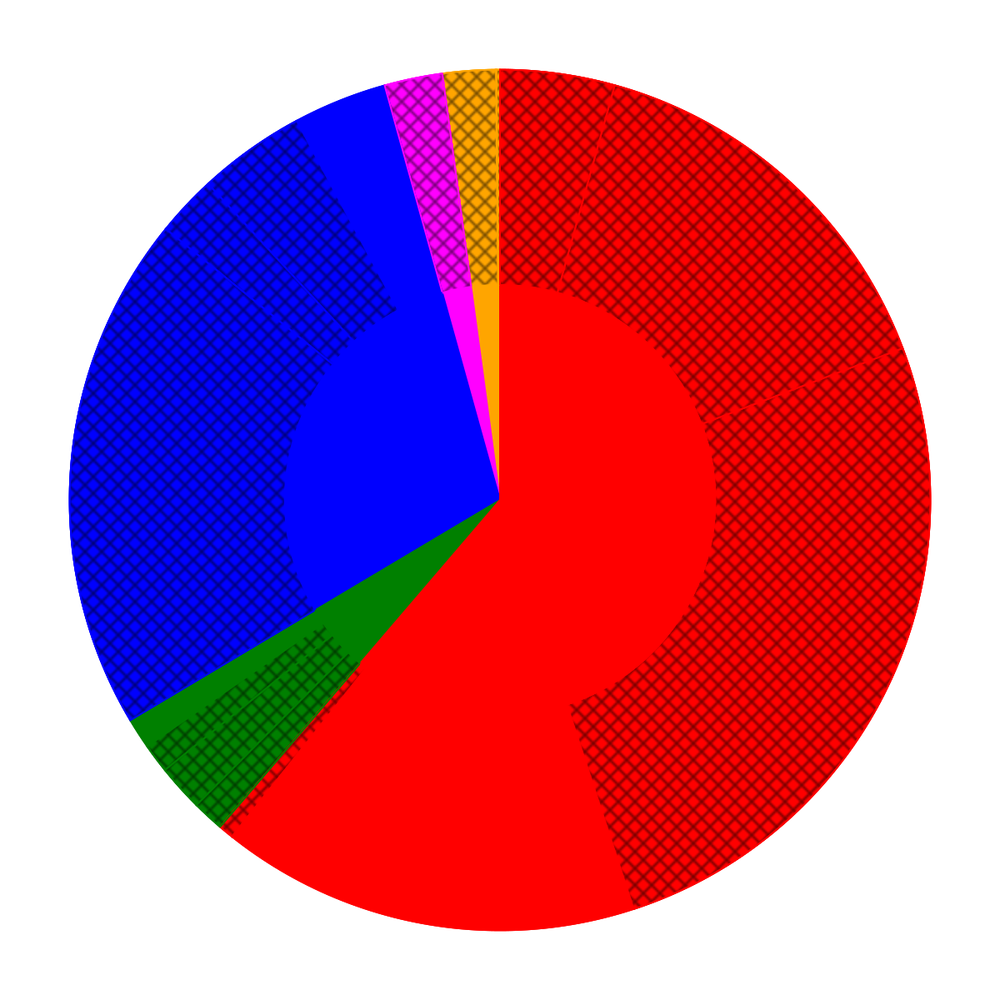

In [41]:
#include("defs.jl")
#include("SN_support.jl")
#using CairoMakie
f_SN = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/tot_SN_CORR.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)

types = ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]
stars = ["1", "2", "M", "S"]
reverse!(types)
reverse!(stars)

function type_to_color(type)
    if type == "IIP"
        return :red
    elseif type == "IIP-B"
        # return :brown
        return :red
    elseif type == "IIb"
        return :green
    elseif type == "Ibc"
        return :blue
    elseif type == "Ibc-i"
        return :magenta
    elseif type == "II-i"
        return :orange
    elseif type == "Ic-BL"
        return :lightblue
    elseif type == "SLSN-I"
        return :purple
    end
end

function star_to_hatch(star)
    if star == "1"
        pat = "x"
    elseif star == "2"
        pat = "x"
    elseif star == "M"
        pat = "x"
    elseif star == "S"
        pat = nothing
    else 
        throw(ErrorException("AAA"))
    end
    return Pattern(pat, background_color=:transparent, 
    linecolor = RGBAf(0,0,0,0.5), width = 2) 
end

which = 4
labels = [type*"_"*star for type in types for star in stars ]
data = [f_SN[!, type*"_"*star][which] for type in types for star in stars ]
data_CUMUL = [f_SN[!, type][which] for type in types]
labels_CUMUL = [type for type in types]
data_access = SortedDict()
extras=0 #0.089
for k in range(1,length(types))
    data_access[types[k]] = f_SN[!, types[k]][which]/(1+extras)
end 
for k in range(1,length(data))
    data[k] /= (1+extras)
    data_access[labels[k]] = data[k]
end 
data_CUMUL /= (1+extras)
    

colores = [type_to_color(type) for type in types for star in stars]
colores_CUMUL = [type_to_color(type) for type in types ]


FIGURE = Figure(size=(600,600))
grid = FIGURE[1,1] = GridLayout()
ax = plot_settings(grid[1, 1]; 
            xlabel="",
            ylabel="",
            title = "",
            )

print(types, "\n", data_CUMUL)
r_div = 0.75
r_div = 0.5

pie!(ax, data_CUMUL, color=colores_CUMUL, offset = pi/2, inner_radius = 0, radius=[1,1,1.0,1.0,1,1,1,1],
        offset_radius = [0.0,0.0,0,0,0,0,0,0], strokecolor=colores_CUMUL)

pie!(ax, data, color=colores, offset = pi/2, inner_radius = r_div, strokecolor=colores)
pie!(ax, data_CUMUL, color=colores_CUMUL, offset = pi/2, inner_radius = 0, radius=r_div, strokecolor=colores_CUMUL)

for star in stars
     star=="S" && continue 
     hatch = star_to_hatch(star)
     #radius = star=="S" ? r_div : 1
     radius = 1
     is_it = [(occursin(star, labels[k]) ? radius : r_div) for k in range(1,length(data))]
     pie!(ax,  data; radius=is_it, inner_radius=r_div, color=hatch, offset = pi/2, strokecolor=colores)
 end

plot_adjust(ax, 
            leftspinevisible = false,
            rightspinevisible = false,
            topspinevisible = false,
            bottomspinevisible = false,
            yticklabelsvisible = false,
            xticklabelsvisible = false,
            xtickvisible=false,
            ytickvisible=false)
resize_to_layout!
FIGURE

stars = ["1", "2", "M", "S"]
stars_lab = ["Primary", "Secondary", "Merger", "Single"]
for ix in [4]
    lbl = @sprintf("\\mathrm{%9s}", stars_lab[ix] )
    newlbl = L"%$(lbl)"
    newlbl = L"\mathrm{Single \ Stars}"

    barplot!(ax, [NaN], [NaN], 
                        color = "white",
                        label = newlbl)
    ix += 1
end
for ix in range(1,length(stars))
    stars[ix]!="M" && continue
    lbl = @sprintf("\\mathrm{%9s}", stars_lab[ix] )
    newlbl = L"%$(lbl)"
    newlbl = L"\mathrm{Binaries}"
    barplot!(ax, [NaN], [NaN], 
                        color = star_to_hatch(stars[ix]),
                        label = newlbl)
end

#axislegend(ax,  position=:rt, 
#    nbanks=1)

outfilename = @sprintf("pie_SN.pdf")
save("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"*outfilename, FIGURE)    # 1600 × 1200 px png
FIGURE


In [ ]:
#include("defs.jl")
#include("SN_support.jl")
#using CairoMakie
f_SN = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/tot_SN_CORR.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)

types = ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]
stars = ["1", "2", "M", "S"]
reverse!(types)
reverse!(stars)

function type_to_color(type)
    if type == "IIP"
        return :red
    elseif type == "IIP-B"
        # return :brown
        return :red
    elseif type == "IIb"
        return :green
    elseif type == "Ibc"
        return :blue
    elseif type == "Ibc-i"
        return :magenta
    elseif type == "II-i"
        return :orange
    elseif type == "Ic-BL"
        return :lightblue
    elseif type == "SLSN-I"
        return :purple
    end
end

function star_to_hatch(star)
    if star == "1"
        pat = "x"
    elseif star == "2"
        pat = "x"
    elseif star == "M"
        pat = "x"
    elseif star == "S"
        pat = nothing
    else 
        throw(ErrorException("AAA"))
    end
    return Pattern(pat, background_color=:transparent, 
    linecolor = RGBAf(0,0,0,0.5), width = 2) 
end

which = 1

labels = [star for star in stars ]
data = [sum([f_SN[!, type*"_"*star][which] for type in types]) for star in stars ]
data_CUMUL = [f_SN[!, type][which] for type in types]
labels_CUMUL = [type for type in types]
data_access = SortedDict()
extras=0 #0.089
for k in range(1,length(types))
    data_access[types[k]] = f_SN[!, types[k]][which]/(1+extras)
end 
for k in range(1,length(data))
    data[k] /= (1+extras)
    data_access[labels[k]] = data[k]
end 
data_CUMUL /= (1+extras)
    

colores = [type_to_color(type) for type in types for star in stars]
colores_CUMUL = [type_to_color(type) for type in types ]


#pie!(ax, data_CUMUL, color=colores_CUMUL, offset = pi/2, inner_radius = 0, radius=[1,1,1.0,1.0,1,1,1,1],
#        offset_radius = [0.0,0.0,0,0,0,0,0,0], strokecolor=colores_CUMUL)

#pie!(ax, data, color=colores, offset = pi/2, inner_radius = r_div, strokecolor=colores)
#pie!(ax, data_CUMUL, color=colores_CUMUL, offset = pi/2, inner_radius = 0, radius=r_div, strokecolor=colores_CUMUL)
alpha = 0.5
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 



color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 


In [ ]:

# which |     IIP   IIP-B     IIb     Ibc    II-i   Ibc-i (     BH)
#     1 |    4.38    0.00    0.85   20.11    2.00    2.58 (   0.06) |   29.92
#     2 |   14.69    0.00    1.73    2.49    0.08    0.00 (   0.02) |   19.00
#     M |    7.12   15.88    2.39    5.86    0.00    0.00 (   0.61) |   31.25
#     S |   14.42    0.00    1.28    4.14    0.00    0.00 (   0.40) |   19.84
# TOTAL |   40.62   15.88    6.24   32.59    2.08    2.58 (   1.09)
FIGURE = Figure(size=(600,600))
grid = FIGURE[1,1] = GridLayout()
ax = plot_settings(grid[1, 1]; 
            xlabel="",
            ylabel="",
            title = "",
            )

print(types, "\n", data_CUMUL)
r_div = 0.75
r_div = 0.


#pie!(ax, reverse!([29.92, 19.00, 31.25, 19.84]), color=reverse!([color_coding["1"], color_coding["2"], color_coding["M"], color_coding["S"]]), offset = pi/2, inner_radius = 0.)

#pie!(ax, reverse!([4.38, 14.69, 7.12+15.88, 14.42]), color=reverse!([color_coding["1"], color_coding["2"], color_coding["M"], color_coding["S"]]), offset = pi/2, inner_radius = 0.66)
# pie!(ax, reverse!([19.85, 2.33, 4.18, 4.24]), color=reverse!([color_coding["1"], color_coding["2"], color_coding["M"], color_coding["S"]]), offset = pi/2, inner_radius = 0.66)
#pie!(ax, reverse!([14.42, 1.28, 4.14, 0, 0]), color=reverse!([color_coding["IIP"], color_coding["IIb"], color_coding["Ibc"], color_coding["II-i"], color_coding["Ibc-i"]]), offset = pi/2, inner_radius = 0.)
pie!(ax, reverse!([4.38, 0.85, 20.11, 2, 2.58]), color=reverse!([color_coding["IIP"], color_coding["IIb"], color_coding["Ibc"], color_coding["II-i"], color_coding["Ibc-i"]]), offset = pi/2, inner_radius = 0.)
#pie!(ax, reverse!([15.878+40.62,    6.245,    32.593, 2.581,2.083  ]), color=reverse!([color_coding["IIP"], color_coding["IIb"], color_coding["Ibc"], color_coding["II-i"], color_coding["Ibc-i"]]), offset = pi/2, inner_radius = 0.)
#pie!(ax, reverse!([ 15.29   ,  1.73  ,  2.33  ,  0.00  ,  0.00  ]), color=reverse!([color_coding["IIP"], color_coding["IIb"], color_coding["Ibc"], color_coding["II-i"], color_coding["Ibc-i"]]), offset = pi/2, inner_radius = 0.)

# for star in stars
#      star=="S" && continue 
#      hatch = star_to_hatch(star)
#      #radius = star=="S" ? r_div : 1
#      radius = 1
#      is_it = [(occursin(star, labels[k]) ? radius : r_div) for k in range(1,length(data))]
#      pie!(ax,  data; radius=is_it, inner_radius=r_div, color=hatch, offset = pi/2, strokecolor=colores)
#  end

 
plot_adjust(ax, 
            leftspinevisible = false,
            rightspinevisible = false,
            topspinevisible = false,
            bottomspinevisible = false,
            yticklabelsvisible = false,
            xticklabelsvisible = false,
            xtickvisible=false,
            ytickvisible=false)
resize_to_layout!
FIGURE

# stars = ["1", "2", "M", "S"]
# stars_lab = ["Primary", "Secondary", "Merger", "Single"]
# for ix in [4]
#     lbl = @sprintf("\\mathrm{%9s}", stars_lab[ix] )
#     newlbl = L"%$(lbl)"
#     newlbl = L"\mathrm{Single \ Stars}"

#     barplot!(ax, [NaN], [NaN], 
#                         color = "white",
#                         label = newlbl)
#     ix += 1
# end
# for ix in range(1,length(stars))
#     stars[ix]!="M" && continue
#     lbl = @sprintf("\\mathrm{%9s}", stars_lab[ix] )
#     newlbl = L"%$(lbl)"
#     newlbl = L"\mathrm{Binaries}"
#     barplot!(ax, [NaN], [NaN], 
#                         color = star_to_hatch(stars[ix]),
#                         label = newlbl)
# end

#axislegend(ax,  position=:rt, 
#    nbanks=1)

outfilename = @sprintf("pie2_SN.pdf")
save("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"*outfilename, FIGURE)    # 1600 × 1200 px png
FIGURE


In [ ]:
xticks = 0:0.10:2.5
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]

FIGURE = Figure(size=(500,500))
grid = FIGURE[1,1] = GridLayout()
ax0 = plot_settings(grid[1:2, 1]; 
            xlabel="",
            ylabel="",
            title = "",
            xticks=(xticks,xticks_t),                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
            xlabelsize = 15, ylabelsize = 15,  xticklabelrotation=pi/2)
# ax1 = plot_settings(grid[2, 1]; 
#             xlabel="",
#             ylabel="",
#             title = "",
#             xticks=(xticks,xticks_t),                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
#             xlabelsize = 15, ylabelsize = 15,  xticklabelrotation=pi/2)
# ax2 = plot_settings(grid[3, 1]; 
#             xlabel="",
#             ylabel="",
#             title = "",
#             xticks=(xticks,xticks_t),                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=false,
#             xlabelsize = 15, ylabelsize = 15,  xticklabelrotation=pi/2)
ax3 = plot_settings(grid[3, 1]; 
            xlabel="",
            ylabel="",
            title = "",
            xticks=(xticks,xticks_t),                xticklabelsize = 15, yticklabelsize = 15,xticklabelsvisible=true,
            xlabelsize = 15, ylabelsize = 15,  xticklabelrotation=pi/2)

            color_coding = Dict()
alpha = 0.5
color_coding["1"]   = RGBAf(0,100/255,0,alpha)    
color_coding["2"]   = RGBAf(255/255, 165/255, 0,alpha)    
color_coding["M"]   = RGBAf(128/255,0,128/255 ,alpha)   
color_coding["S"]   = RGBAf(0, 0, 0,alpha) 
            

hist = Dict()
d1 = 0.10
bins = 0.5:d1:1.8
for prg in progenitors 
    hist[prg] = fit(Histogram,  log10.(SN_DATA["Mf"][prg][get_idx(prg,"BH")]), weights(SN_DATA["pdf"][prg][get_idx(prg,"BH")]*100), bins)  

    pdf = sum([ SN_DATA["pdf"][prg][ix] for ix in get_idx(prg, "BH")])
    weighted_mean = sum([SN_DATA["Mf"][prg][ix]*SN_DATA["pdf"][prg][ix]/ pdf for ix in get_idx(prg, "BH")])
    weighted_err = sqrt(  sum(  [  (SN_DATA["Mf"][prg][ix]-weighted_mean)^2 * SN_DATA["pdf"][prg][ix] for ix in get_idx(prg, "BH")]   )/ pdf )
    vlines!(ax, log10(weighted_mean), ymin=0, ymax=2, color = color_coding[prg], linewidth=2, linestyle = :dash,alpha = 1)
    @printf("%s  M %7.2f ± %7.2f;", prg, weighted_mean, weighted_err)

end

x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1)   for i in range(1, length(progenitors)) ]

y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for prg in progenitors
        push!(y_bar,  hist[prg].weights[ix]+0.00001) 
    end
end 

order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(progenitors)) ]
colors= [color_coding[progenitors[i]] for ix in range(1,length(bins)-1) for i in range(1,length(progenitors)) ]
# ylims!(1e-2,1)
for ax in [ax0,ax3]
    barplot!(ax, x_bar , 
    y_bar, 
    stack= order,
    color = colors,
    width=d1)
    vspan!(ax,log10(21.2-2.2),  log10(21.2+2.2), ymin=0, ymax=1, alpha = 0.2, color = "black")

end 
ylims!(ax0, 0.1, 8)
#ylims!(ax1, 0.1, 1)
#ylims!(ax2, 0.01, 0.1)
ylims!(ax3, 0. , 0.1)
rowgap!(grid, 0)
FIGURE 
#MILLER-JONES(2021) CYGX1: Mbh = 21.2±2.2; MO=40.6+7.7-7.1
outfilename = @sprintf("BH_MASS.pdf")
save("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"*outfilename, FIGURE)    # 1600 × 1200 px png
FIGURE


In [ ]:
BH1 = get_idx("1","BH")
for ix in range(1,length(SN_DATA["Mf"]["1"]))
   if ix in BH1 && (21.2-2.2 < SN_DATA["Mf"]["1"][ix] <21.2+2.2)
      print(SN_DATA["id"]["1"][ix], "  ", round(SN_DATA["mod"]["1"][ix]["M2end"],digits=2))
      if 40.6-7.1 < SN_DATA["mod"]["1"][ix]["M2max"] < 40.6 + 7.7
         print(" Secondary as massive as Cyg-X1, orbital Period =")
         logM = parse(Float64, SN_DATA["id"]["1"][ix]["logM"])
         logP = parse(Float64,SN_DATA["id"]["1"][ix]["logP"])
         q = parse(Float64,SN_DATA["id"]["1"][ix]["q"])
         fff = f_MW[@sprintf("%.2f", logM)]
         for i in range(1,length(fff.logM))
            (fff.logP[i] != logP) && continue 
            (fff.q[i] != q) && continue 
            print(round(fff.period_end_1[i],digits=2))
         end
      end
      print("\n")
   end
end
print(total_SNe)


# Mf vs Mi (single)

Reading & cleaning single-star CORR files...done!
Building Case BC interpolator (PythonCall)...done
Building merger Mi +f_acc -> Mco, BSG interpolators: Retrieving data ...building interpolators...done!
Building merger/partial stripped outcome -> core He dep. Retrieving data ...Building interpolation library...done!
Building Explosion criteria......PS20...M16-E16 - imported CC grids, explodability files and interpolants

Initializing plot
Plot successfull!




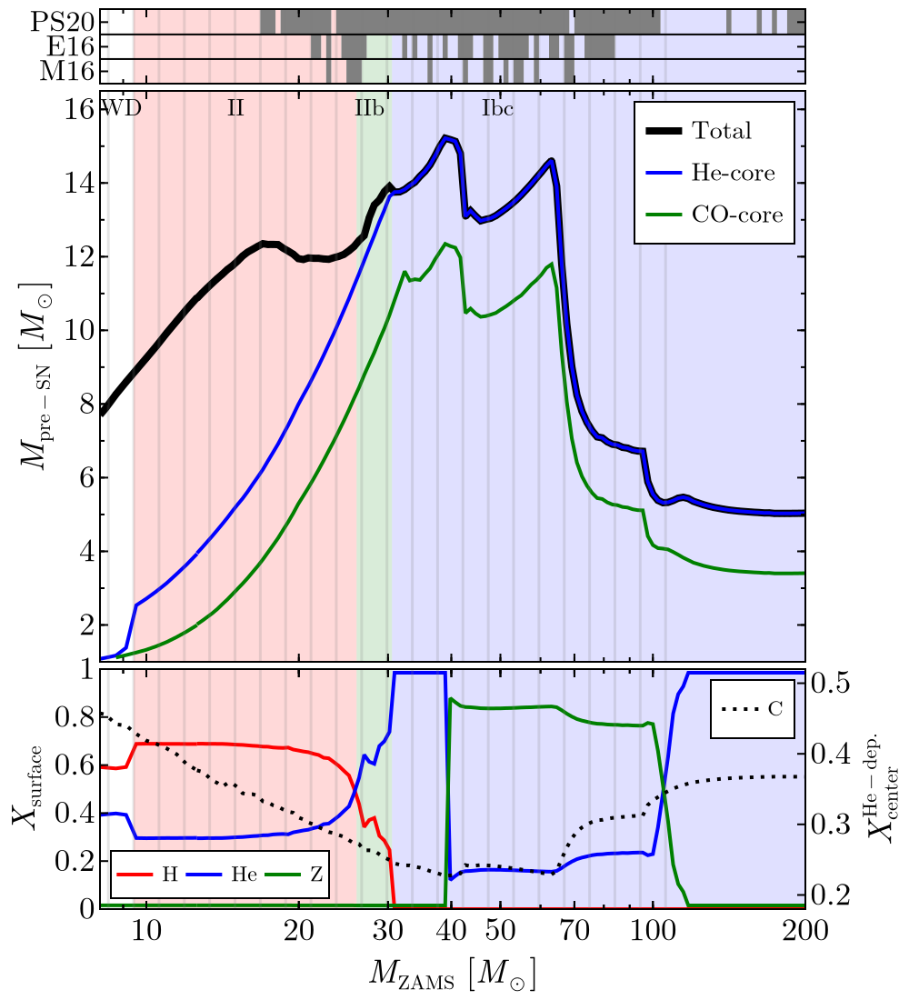

In [131]:
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/defs.jl")
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/SN_support.jl")
#using GLMakie
# using CairoMakie
######


include(include_dir*"SN_support.jl")


the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)


set_theme!(theme_latexfonts())

#deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )
###
@printf("\nInitializing plot\n")

M_tot(when, f=f_singleCC) = f[!, "M_"*when]
M_he_core(when, f = f_singleCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_singleCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_singleCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_singleCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_singleCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_singleCC) =  f[!, "Xs_"*when]
Ys(when, f = f_singleCC) =  f[!, "Ys_"*when]
Cc(when, f = f_singleCC) =  f[!, "Cc_"*when]
M_He_env(when, f = f_singleCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = 10. .^ f_singleCC.logM
Mi_og = 10. .^ f_single_og.logM

sss = Dict("type" => [], "m" => []) 
for ix in range(1,length(Mi)) 
    m = 10 ^f_singleCC.logM[ix]
    SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
    "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
#    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
    SN_OUTPUT_manual(SN, f_singleCC.M_end[ix],
                         f_singleCC.M_he_core_end[ix], 
                         f_singleCC.M_co_core_end[ix], 
                         m, 
                         f_singleCC.M_end[ix]-f_singleCC.M_he_core_end[ix], 
                         f_singleCC.Cc_ini_BURN_C[ix]/0.99, 
                         "end_BURN_C",
                         "X", reference_grid = "MW-ZAMS")
    for out in keys(SN)
         if SN[out]>0
             push!(sss["type"], out)
             push!(sss["m"], m)
         end 
    end 
end 




function boundary_builder(explosion_criterion)
    boundaries = Dict("WD" =>Any[0], "IIP" =>Any[0], "IIb" =>Any[0], "Ibc"=>Any[0], "BH" =>Any[0])


    dm= 0.01
    boundaries["WD"][1]+=1
    push!(boundaries["WD"], [10^(0.70-dm/2)])
    previous = "WD";
    for logm in 0.70:dm:2.300
        m = 10^logm
        Mend = interpol_single_Mmax["M_end"](m)
        Mhecore = interpol_single_Mmax["M_hecore_end"](m)
        Mcocore = interpol_single_Mmax["M_cocore_end"](m)
        M_env = Mend-Mhecore
        Xc = interpol_single_Mmax["X_C"](m)
        SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
                "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
    #    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
        SN_OUTPUT_manual(SN, Mend,
                            Mhecore, 
                            Mcocore, 
                            m, 
                            M_env, 
                            Xc, 
                            "end_BURN_C",
                            explosion_criterion, reference_grid = "MW-ZAMS")
        out = "X"
        for k in keys(SN)
            if SN[k]>0
                #@printf("m %6.3f %5s",m, k)
                out = k
                break
            end 
        end 
        
        if out == previous 
            #print("\n"); 
            continue
        end 

        #@printf("----> CHANGE <-----")
        ix = boundaries[previous][1]+1
        push!(boundaries[previous][ix],10^(logm-dm/2))
        #print("\n", boundaries, "\n")


        boundaries[out][1] += 1
        ix_new = boundaries[out][1]+1
        push!(boundaries[out], [])
        #print("\n", boundaries, "\n")

        push!(boundaries[out][ix_new], 10^(logm-dm/2))
        #print("\n", boundaries, "\n")

        previous = out 

    end
    #print("\n", boundaries, "\n")
    ix = boundaries[previous][1]+1
    push!(boundaries[previous][ix], 10^(2.30+dm/2))
    #print("\n", boundaries, "\n")

    return boundaries 
end 

boundaries = boundary_builder("X")
boundary_MM = boundary_builder("MM-S21")
boundary_ER = boundary_builder("Ertl-N20_new")
#boundary_xi = boundary_builder("comp0.35")
boundary_PS = boundary_builder("PS20")
#boundaries = Dict("WD"    => [1, [ 5.00, 9.518]],
#                  "IIP"   => [1, [ 9.518,19.235]],
#                  "IIb"   => [1, [23.235,27.463]],
#                  "BH"    => [2, [37.888,40.649], [43.018,62.323]],
#                  "Ibc"   => [3, [27.463,37.888],[40.649,43.018], [62.323,100.00] ],
#                 )
color_alpha = 0.15
colores = Dict("WD"    => RGBAf(1.,1,1,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)


FIG = Figure(size=(500,550),  figure_padding = 5)
grid = FIG[1,1] = GridLayout()
xticks = [7, 10, 20,30,40,50,70,100, 200, 300]
xticks_label = [L"%$(t)" for t in xticks]

yticks = range(0,20,step=2)
yticks_label = [L"%$(t)" for t in yticks]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]
ymticks = range(0,20,step=1)
ax_bh = plot_settings(grid[1, 0:1]; 
                        xlabel="", ylabel="", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=false,   
                        yticks=([0.33/2, 0.99/2, (.99+.66)/2], [L"\mathrm{M16}", L"\mathrm{E16}",  L"\mathrm{PS}20" ]), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=16,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10)
ax = plot_settings(grid[2:8, 0:1]; 
                        xlabel="", ylabel=L"M_\mathrm{pre-SN} \ [M_\odot]", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=false,   
                        yticks=(yticks, yticks_label), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=yticklabelsize, yticklabelpad=yticklabelpad,
                        ylabelsize=ylabelsize,
                        xscale = log10)

ax2 = plot_settings(grid[9:11, 0:1]; 
                        xlabel=L"M_\mathrm{ZAMS} \ [M_\odot]", ylabel=L"X_\mathrm{surface}", title ="",
                        xticks=(xticks,xticks_label),  
                        yticks=([0., 0.2, 0.4, 0.6, 0.8, 1.0], [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1"]), 
                        xmticks=xmticks,
                        xlabelsize = ylabelsize, ylabelsize=ylabelsize, yticklabelpad=yticklabelpad,
                        yticklabelsize=yticklabelsize,xticklabelsize=yticklabelsize,
                        xscale = log10, mirror_y=false)
ax2_center = plot_settings(grid[9:11, 0:1]; 
                        xlabel= " ", ylabel=L"X_\mathrm{center}^\mathrm{He-dep.}", title ="",
                        xticks=(xticks,xticks_label),  
                        yticks=(0:0.1:1), xticklabelsvisible=false,
                        xmticks=xmticks,yaxisposition=:right,
                        xlabelsize = ylabelsize, ylabelsize=ylabelsize, yticklabelpad=yticklabelpad,
                        yticklabelsize=yticklabelsize,xticklabelsize=yticklabelsize,
                        xscale = log10, mirror_y=false)




# for i in range(1, length(sss["m"]))
    # print(sss["type"][1])
    # sss["type"][i] != "IIb" && continue 
    # scatter!(ax,sss["m"][i], 2, color = colores[sss["type"][i]], marker = '|', markersize = 20, strokewidth = 1.2, strokecolor=colores[sss["type"][i]])
# end


when_line = "end"
# lines!(ax, [0.1,9.5], [1.38,1.38], 
#             color = :black, linestyle = :dot)
scatterlines!(ax, Mi , M_tot("end"), 
            color = :black, linewidth = 4, alpha=1,  label = "Total", markersize = 5)
scatterlines!(ax, Mi_og , M_tot("end", f_single_og), 
            color = :black, linewidth = 4, alpha=1, markersize = 5  )

lines!(ax, Mi , M_he_core(when_line), 
            color = :blue, linewidth = 2, alpha=1, label = "He-core" )
lines!(ax, Mi_og , M_he_core(when_line, f_single_og), 
            color = :blue, linewidth = 2, alpha=1 )

lines!(ax, Mi , M_co_core("end_BURN_C"), 
            color = :green, linewidth = 2, alpha=1,  label = "CO-core")
lines!(ax, Mi_og , M_co_core("end_BURN_C", f_single_og), 
            color = :green, linewidth = 2, alpha=1 )

lines!(ax2, Mi , Xs("end") .+0.00001,
            color = :red,  linewidth = 2,alpha=1, label="H")
lines!(ax2, Mi_og , Xs("end", f_single_og) .+0.00001,
            color = :red,  linewidth = 2,alpha=1)

lines!(ax2, Mi , Ys("end") .+0.00001, 
            color = :blue,  linewidth = 2,alpha=1, label = "He")
lines!(ax2, Mi_og , Ys("end", f_single_og) .+0.00001, 
            color = :blue,  linewidth = 2,alpha=1)

lines!(ax2, Mi , 1. .- Xs("end") .- Ys("end"), 
            color = :green,  linewidth = 2,alpha=1, label = "Z")
lines!(ax2, Mi_og , 1. .- Xs("end", f_single_og) .- Ys("end", f_single_og), 
            color = :green,  linewidth = 2,alpha=1)


lines!(ax2_center, Mi ,  Cc("end_BURN_He"), 
            color = :black,  linewidth = 2,alpha=1, label="C", linestyle=:dot)
lines!(ax2_center, Mi_og ,  Cc("end_BURN_He", f_single_og), 
            color = :black,  linewidth = 2,alpha=1,  linestyle=:dot)

axislegend(ax,  position=:rt, 
            nbanks=1, titleposition=:top)
axislegend(ax2,  position=:lb, 
            nbanks=3, titleposition=:top, labelsize = 12, rowgap=0, colgap =4, padding=(3,3,3,3) )
axislegend(ax2_center,  position=:rt, 
            nbanks=1, titleposition=:top, labelsize = 12,rowgap =0, colgap =4)
xmin = 8.1
xlims!(ax, xmin, 200)
xlims!(ax2_center, xmin, 200)
ylims!(ax, 1, 16.5)
xlims!(ax2,xmin, 200)
ylims!(ax2, 0.0, 1)
ylims!(ax2_center, 0.18, 0.52)

xlims!(ax_bh,xmin, 200)
ylims!(ax_bh, 0, 1)

rowgap!(grid, 4)
colgap!(grid, 1)
for outcome in collect(keys(colores))
    fill = colores[outcome]
    for ix in range(2, boundaries[outcome][1]+1)
        filler1=vspan!(ax, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        filler2=vspan!(ax2, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        translate!(filler1, 0, 0, -0.1)
        translate!(filler2, 0, 0, -0.1)
    end
    BH = occursin("BH", outcome)
    #BH ? continue : nothing  
    for ix in range(2, boundary_MM[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_MM[outcome][ix][1]], [boundary_MM[outcome][ix][2]], 
                    # ymin=0, ymax=0.25,  color= fill) 
                    ymin=0, ymax=0.33,  color= fill) 
        translate!(filler3, 0, 0, -0.1)
    end    
    for ix in range(2, boundary_ER[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_ER[outcome][ix][1]], [boundary_ER[outcome][ix][2]], 
                    # ymin=0.25, ymax=0.5,  color= fill) 
                    ymin=0.33, ymax=0.66,  color= fill) 
        translate!(filler3, 0, 0, -0.1)
    end
    for ix in range(2, boundary_PS[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_PS[outcome][ix][1]], [boundary_PS[outcome][ix][2]], 
                    # ymin=0.5, ymax=0.75,  color= fill) 
                    ymin=0.66, ymax=1,  color= fill) 
        translate!(filler3, 0, 0, -0.1)
    end
    
        
end

tt = text!(FIG.scene, 0.11, 0.88, text= L"\mathrm{WD}", 
            fontsize=13, space=:relative, color=:black)#RGBAf(0,0.5,0.5,1))
text!(FIG.scene, 0.25, 0.88, text= L"\mathrm{II}", 
            fontsize=13, space=:relative, color=:black)#:red)
text!(FIG.scene, 0.39, 0.88, text= L"\mathrm{IIb}", 
            fontsize=13, space=:relative, color=:black)# color=RGBAf(0.,0.5,0.,1.))
text!(FIG.scene, 0.53, 0.88, text= L"\mathrm{Ibc}", 
            fontsize=13, space=:relative, color=:black)# color=:blue)



# scatter!(ax_bh, Mi_og, Mi_og .* 0 .+ 0.25, color = :gray, marker='.', markersize = 21.5)
# scatter!(ax_bh, 10. .^ exp_corr_S[!, "logM"][exp_corr_S[!, "E_exp"]  .>0], exp_corr_S[!, "logM"][exp_corr_S[!, "E_exp"]  .>0] .* 0 .+ 0.25, color = :black, marker='.', markersize = 21.5)
# scatter!(ax_bh, 10. .^ exp_corr_S[!, "logM"][exp_corr_S[!, "E_exp"]  .==0], exp_corr_S[!, "logM"][exp_corr_S[!, "E_exp"] .==0] .* 0 .+ 0.25, color = :white, marker='.', markersize = 21.5)
for logm in 0.70:0.05:2.00
    m = 10. ^ (logm+0.025)
    lines!(ax_bh, [m, m],
                [0, 100], color = :gray, linestyle = :solid, alpha = 0.2)
    lines!(ax2, [m, m],
                [0, 100], color = :gray, linestyle = :solid, alpha = 0.2)
    lines!(ax, [m, m],
                [0, 100], color = :gray, linestyle = :solid, alpha = 0.2)
end

# for ix in range(1,length(Mi_og))
#     ! (  to_key( log10(Mi_og[ix]) ) in [to_key(i) for i in 0.70:0.05:1.10]   ) && continue 
#     scatter!(ax, Mi_og[ix] , M_co_core("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax, Mi_og[ix] , M_he_core("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax, Mi_og[ix] , M_tot("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi_og[ix] , Xs("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi_og[ix] , Ys("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi_og[ix] , 1 .- Xs("end_BURN_C", f_single_og)[ix] .- Ys("end_BURN_C", f_single_og)[ix], 
#                 color = :gray, marker = '.', markersize=50 )
# end
# for ix in range(1,length(Mi))
#     ! (  to_key( log10(Mi[ix]) )    in [to_key(i) for i in 1.10:0.05:2.00]   ) && continue 
#     scatter!(ax, Mi[ix] , M_co_core("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax, Mi[ix] , M_he_core("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax, Mi[ix] , M_tot("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi[ix] , Xs("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi[ix] , Ys("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )
#     scatter!(ax2, Mi[ix] , 1 .- Xs("end_BURN_C")[ix] .- Ys("end_BURN_C")[ix], 
#                 color = :gray, marker = '.', markersize=50 )

# end

lines!(ax_bh, [0.1, 500], [0.66,0.66], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [0.33,0.33], linestyle = :solid, linewidth = 1, color = :black)

@printf("Plot successfull!\n\n\n")
resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/SINGLE_OUTCOME_SN.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG 




In [7]:
boundaries

Dict{String, Vector{Any}} with 5 entries:
  "IIb" => [1, Any[26.0016, 30.5492]]
  "Ibc" => [1, Any[30.5492, 201.837]]
  "IIP" => [1, Any[9.44061, 26.0016]]
  "BH"  => [0]
  "WD"  => [1, [4.9545, 9.44061]]

# Mf vs Mi (heS)


Initializing plot

Dict{String, Vector{Any}}("IIb" => [0], "Ibc" => [1, Any[2.53667, 15.7821]], "IIP" => [0], "BH" => [0], "WD" => [1, [2.4998563903753643, 2.53667]])

Dict{String, Vector{Any}}("IIb" => [0], "Ibc" => [5, Any[2.53667, 6.28427], Any[6.42853, 8.0331], Any[8.17019, 8.72668], Any[8.88728, 9.05255], Any[9.95182, 13.73757]], "IIP" => [0], "BH" => [5, Any[6.28427, 6.42853], Any[8.0331, 8.17019], Any[8.72668, 8.88728], Any[9.05255, 9.95182], Any[13.73757, 15.7821]], "WD" => [1, [2.4998563903753643, 2.53667]])

Dict{String, Vector{Any}}("IIb" => [0], "Ibc" => [6, Any[2.53667, 6.28427], Any[6.42853, 6.89491], Any[6.99358, 7.35961], Any[7.67157, 7.90503], Any[8.17019, 8.57573], Any[10.3727, 13.13477]], "IIP" => [0], "BH" => [6, Any[6.28427, 6.42853], Any[6.89491, 6.99358], Any[7.35961, 7.67157], Any[7.90503, 8.17019], Any[8.57573, 10.3727], Any[13.13477, 15.7821]], "WD" => [1, [2.4998563903753643, 2.53667]])

Dict{String, Vector{Any}}("IIb" => [0], "Ibc" => [8, Any[2.53667, 4.213

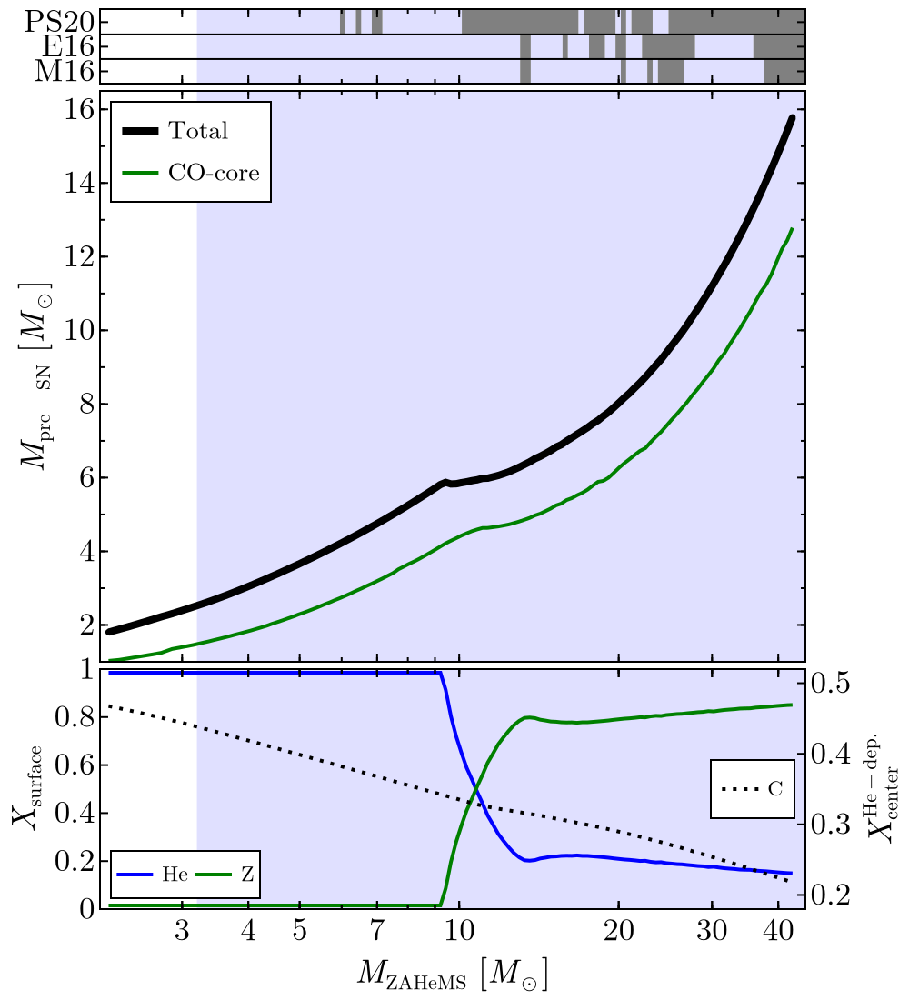

In [43]:
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/defs.jl")
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/SN_support.jl")
#using GLMakie
# using CairoMakie
######
#include("SN_reader_MW.jl")


the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)


set_theme!(theme_latexfonts())

#deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )
###
@printf("\nInitializing plot\n")

M_tot(when, f=f_HeSCC) = f[!, "M_"*when]
M_he_core(when, f = f_HeSCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_HeSCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_HeSCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_HeSCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_HeSCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_HeSCC) =  f[!, "Xs_"*when]
Ys(when, f = f_HeSCC) =  f[!, "Ys_"*when]
M_He_env(when, f = f_HeSCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = f_HeSCC.M_ini_BURN_He
Cc(when, f = f_HeSCC) =  f[!, "Cc_"*when]

sss = Dict("type" => [], "m" => []) 
for ix in range(1,length(Mi)) 
    m =  f_HeSCC.M_ini_BURN_He[ix]
    SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
    "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
    SN_OUTPUT_manual(SN, f_HeSCC.M_end[ix],
                         f_HeSCC.M_he_core_end[ix], 
                         f_HeSCC.M_co_core_end[ix], 
                         m, 
                         f_HeSCC.M_end[ix]-f_HeSCC.M_he_core_end[ix], 
                         f_HeSCC.Cc_ini_BURN_C[ix]/0.99, 
                         "end_BURN_C",
                         "X", reference_grid = "MW-ZAMS")
    for out in keys(SN)
         if SN[out]>0
             push!(sss["type"], out)
             push!(sss["m"], m)
         end 
    end 
end 




function boundary_builder(explosion_criterion)
    boundaries = Dict("WD" =>Any[0], "IIP" =>Any[0], "IIb" =>Any[0], "Ibc"=>Any[0], "BH" =>Any[0])
    boundaries_Mf = Dict("WD" =>Any[0], "IIP" =>Any[0], "IIb" =>Any[0], "Ibc"=>Any[0], "BH" =>Any[0])


    dm= 0.01
    boundaries["WD"][1]+=1
    push!(boundaries["WD"], [10^(0.0-dm/2)])
    boundaries_Mf["WD"][1]+=1
    push!(boundaries_Mf["WD"], [interpol_HeS_Mmax["M_hecore_end"](10 ^ 0.5)])
    previous = "WD";
    for logm in 0.50:dm:1.64
        ix=  find_nearest(f_HeSCC.logM, logm)
        m = f_HeSCC.M_ini_BURN_He[ix]
        Mend = interpol_HeS_Mmax["M_end"](m)
        Mhecore = interpol_HeS_Mmax["M_hecore_end"](m)
        Mcocore = interpol_HeS_Mmax["M_cocore_end"](m)
        M_env = Mend-Mhecore
        Xc = interpol_HeS_Mmax["X_C"](m)
        SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
                "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
    #    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
        SN_OUTPUT_manual(SN, Mend,
                            Mhecore, 
                            Mcocore, 
                            m, 
                            M_env, 
                            Xc, 
                            "end_BURN_C",
                            explosion_criterion, reference_grid = "MW-Stripped")
        out = "X"
        for k in keys(SN)
            if SN[k]>0
                #@printf("m %6.3f %5s",m, k)
                out = k
                break
            end 
        end 
        
        if out == previous 
            #print("\n"); 
            continue
        end 

        #@printf("----> CHANGE <-----")
        ix = boundaries[previous][1]+1
        push!(boundaries[previous][ix], 10^(logm-dm/2))
        push!(boundaries_Mf[previous][ix], Mend)
        #print("\n", boundaries, "\n")


        boundaries[out][1] += 1
        boundaries_Mf[out][1] += 1
        ix_new = boundaries[out][1]+1
        push!(boundaries[out], [])
        push!(boundaries_Mf[out],[])
        #print("\n", boundaries, "\n")

        push!(boundaries[out][ix_new], 10^(logm-dm/2))
        push!(boundaries_Mf[out][ix_new], Mend)
        #print("\n", boundaries, "\n")

        previous = out 

    end
    #print("\n", boundaries, "\n")
    ix = boundaries[previous][1]+1
    push!(boundaries[previous][ix], 10^(2.30+dm/2))
    push!(boundaries_Mf[previous][ix],  interpol_HeS_Mmax["M_end"](10^(2.30+dm/2)))
    print("\n", boundaries_Mf, "\n")

    return boundaries 
end 

boundaries = boundary_builder("X")
boundary_MM = boundary_builder("MM-M16")
boundary_ER = boundary_builder("Ertl-N20_new")
#boundary_xi = boundary_builder("comp0.35")
boundary_PS = boundary_builder("PS20")
#boundaries = Dict("WD"    => [1, [ 5.00, 9.518]],
#                  "IIP"   => [1, [ 9.518,19.235]],
#                  "IIb"   => [1, [23.235,27.463]],
#                  "BH"    => [2, [37.888,40.649], [43.018,62.323]],
#                  "Ibc"   => [3, [27.463,37.888],[40.649,43.018], [62.323,100.00] ],
#                 )
color_alpha = 0.15
colores = Dict("WD"    => RGBAf(1.,1,1,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)


FIG = Figure(size=(500,550),  figure_padding = 5)
grid = FIG[1,1] = GridLayout()
xticks = [1, 2, 3, 4, 5, 7, 10, 20,30,40,50,70,100, 200, 300]
xticks_label = [L"%$(t)" for t in xticks]

yticks = range(0,20,step=2)
yticks_label = [L"%$(t)" for t in yticks]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]
ymticks = range(0,20,step=1)
ax_bh = plot_settings(grid[1, 0:1]; 
                        xlabel="", ylabel="", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=false,   
                        yticks=([0.33/2, 0.99/2, (.99+.66)/2], [L"\mathrm{M16}", L"\mathrm{E16}",  L"\mathrm{PS}20" ]), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10)
ax = plot_settings(grid[2:8, 0:1]; 
                        xlabel="", ylabel=L"M_\mathrm{pre-SN} \ [M_\odot]", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=false,   
                        yticks=(yticks, yticks_label), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=yticklabelsize, yticklabelpad=yticklabelpad,
                        ylabelsize=ylabelsize,
                        xscale = log10)

ax2 = plot_settings(grid[9:11, 0:1]; 
                        xlabel=L"M_\mathrm{ZAHeMS} \ [M_\odot]", ylabel=L"X_\mathrm{surface}", title ="",
                        xticks=(xticks,xticks_label),  
                        yticks=([0., 0.2, 0.4, 0.6, 0.8, 1.0], [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1"]), 
                        xmticks=xmticks,
                        xlabelsize = ylabelsize, ylabelsize=ylabelsize, yticklabelpad=yticklabelpad,
                        yticklabelsize=yticklabelsize,xticklabelsize=yticklabelsize,
                        xscale = log10, mirror_y=false)
ax2_center = plot_settings(grid[9:11, 0:1]; 
                        xlabel= " ", ylabel=L"X_\mathrm{center}^\mathrm{He-dep.}", title ="",
                        xticks=(xticks,xticks_label),  
                        yticks=(0:0.1:1), xticklabelsvisible=false,
                        xmticks=xmticks,yaxisposition=:right,
                        xlabelsize = ylabelsize, ylabelsize=ylabelsize, yticklabelpad=yticklabelpad,
                        yticklabelsize=yticklabelsize,xticklabelsize=yticklabelsize,
                        xscale = log10, mirror_y=false)



when_line = "end"
# lines!(ax, [0.1,9.5], [1.38,1.38], 
#             color = :black, linestyle = :dot)
scatterlines!(ax, Mi , M_tot("end"), 
            color = :black, linewidth = 4, alpha=1,  label = "Total", markersize = 5)

lines!(ax, Mi , M_co_core("end"), 
            color = :green, linewidth = 2, alpha=1,  label = "CO-core")

            
lines!(ax2, Mi , Ys("end") .+0.00001, 
            color = :blue,  linewidth = 2,alpha=1, label = "He")

lines!(ax2, Mi , 1. .- Xs("end") .- Ys("end"), 
            color = :green,  linewidth = 2,alpha=1, label = "Z")


lines!(ax2_center, Mi ,  Cc("end_BURN_He"), 
            color = :black,  linewidth = 2,alpha=1, label="C", linestyle=:dot)

axislegend(ax,  position=:lt, 
            nbanks=1, titleposition=:top)
axislegend(ax2,  position=:lb, 
            nbanks=3, titleposition=:top, labelsize = 12, rowgap=0, colgap =4, padding=(3,3,3,3) )
axislegend(ax2_center,  position=:rc, 
            nbanks=1, titleposition=:top, labelsize = 12,rowgap =0, colgap =4)
xmin = 2.1
xmax = 45
xlims!(ax, xmin, xmax)
xlims!(ax2_center, xmin, xmax)
ylims!(ax, 1, 16.5)
xlims!(ax2,xmin, xmax)
ylims!(ax2, 0.0, 1)
ylims!(ax2_center, 0.18, 0.52)

xlims!(ax_bh,xmin, xmax)
ylims!(ax_bh, 0, 1)

rowgap!(grid, 4)
colgap!(grid, 1)
for outcome in collect(keys(colores))
    fill = colores[outcome]
    for ix in range(2, boundaries[outcome][1]+1)
        filler1=vspan!(ax, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        filler2=vspan!(ax2, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        translate!(filler1, 0, 0, -0.1)
        translate!(filler2, 0, 0, -0.1)
    end
    BH = occursin("BH", outcome)
    #BH ? continue : nothing  
    for ix in range(2, boundary_MM[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_MM[outcome][ix][1]], [boundary_MM[outcome][ix][2]], 
                    # ymin=0, ymax=0.25,  color= fill) 
                    ymin=0, ymax=0.33,  color= fill) 
        translate!(filler3, 0, 0, -0.1)
    end    
    for ix in range(2, boundary_ER[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_ER[outcome][ix][1]], [boundary_ER[outcome][ix][2]], 
                    # ymin=0.25, ymax=0.5,  color= fill) 
                    ymin=0.33, ymax=0.66,  color= fill) 
                    translate!(filler3, 0, 0, -0.1)
    end
    for ix in range(2, boundary_PS[outcome][1]+1)
        filler3=vspan!(ax_bh, 
                    [boundary_PS[outcome][ix][1]], [boundary_PS[outcome][ix][2]], 
                    # ymin=0.5, ymax=0.75,  color= fill) 
                    ymin=0.66, ymax=1,  color= fill) 
        translate!(filler3, 0, 0, -0.1)
    end
    
        
end

# tt = text!(FIG.scene, 0.11, 0.88, text= L"\mathrm{WD}", 
#             fontsize=13, space=:relative, color=:black)#RGBAf(0,0.5,0.5,1))
# text!(FIG.scene, 0.53, 0.88, text= L"\mathrm{Ibc}", 
#             fontsize=13, space=:relative, color=:black)# color=:blue)



# scatter!(ax_bh, Mi_og, Mi_og .* 0 .+ 0.25, color = :gray, marker='.', markersize = 21.5)
# scatter!(ax_bh, 10. .^ exp_corr_He[!, "logM"][exp_corr_He[!, "E_exp"]  .>0],  exp_corr_He[!, "logM"][exp_corr_He[!, "E_exp"]  .>0] .* 0 .+ 0.25, color = :black, marker='.', markersize = 21.5)
# scatter!(ax_bh, 10. .^ exp_corr_He[!, "logM"][exp_corr_He[!, "E_exp"]  .==0], exp_corr_He[!, "logM"][exp_corr_He[!, "E_exp"] .==0] .* 0 .+ 0.25, color = :white, marker='.', markersize = 21.5)



lines!(ax_bh, [0.1, 500], [0.33,0.33], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [0.66,0.66], linestyle = :solid, linewidth = 1, color = :black)

@printf("Plot successfull!\n\n\n")
resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/SINGLE_OUTCOME_HeS_SN.pdf"), 
        FIG, px_per_unit = 1000,   )    # 1600 × 1200 px png

        
FIG




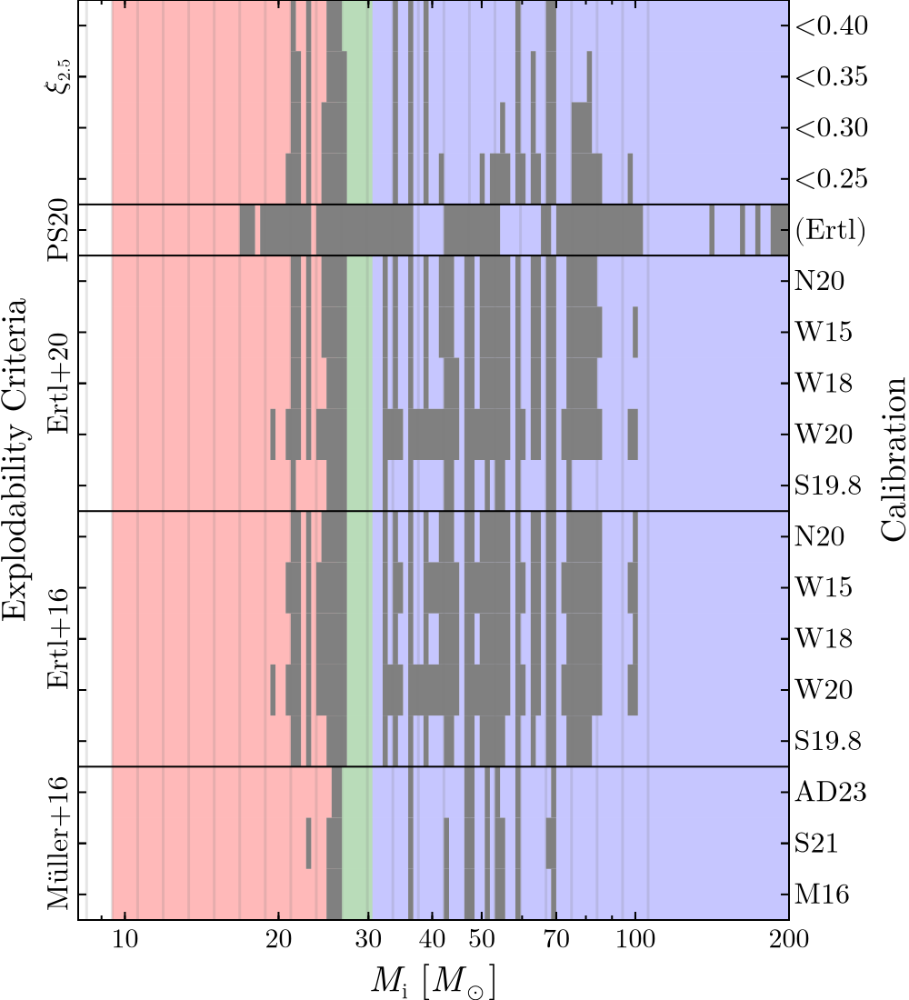

In [39]:
# include(include_dir*"SN_support.jl")

the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)


set_theme!(theme_latexfonts())



deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )

M_tot(when, f=f_singleCC) = f[!, "M_"*when]
M_he_core(when, f = f_singleCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_singleCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_singleCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_singleCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_singleCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_singleCC) =  f[!, "Xs_"*when]
Ys(when, f = f_singleCC) =  f[!, "Ys_"*when]
Cc(when, f = f_singleCC) =  f[!, "Cc_"*when]
M_He_env(when, f = f_singleCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = 10. .^ f_singleCC.logM
Mi_og = 10. .^ f_single_og.logM

sss = Dict("type" => [], "m" => []) 
for ix in range(1,length(Mi)) 
    m = 10 ^f_singleCC.logM[ix]
    SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
    "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
#    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
    SN_OUTPUT_manual(SN, f_singleCC.M_end[ix],
                         f_singleCC.M_he_core_end[ix], 
                         f_singleCC.M_co_core_end[ix], 
                         m, 
                         f_singleCC.M_end[ix]-f_singleCC.M_he_core_end[ix], 
                         f_singleCC.Cc_ini_BURN_C[ix]/0.99, 
                         "end_BURN_C",
                         "X", reference_grid = "MW-ZAMS")
    for out in keys(SN)
         if SN[out]>0
             push!(sss["type"], out)
             push!(sss["m"], m)
         end 
    end 
end 


 exp_criteria = ["MM-M16", "MM-S21", "MM-AD23", 
                 "Ertl-S19.8_old", "Ertl-W20_old", "Ertl-W18_old", "Ertl-W15_old", "Ertl-N20_old", 
                 "Ertl-S19.8_new", "Ertl-W20_new", "Ertl-W18_new", "Ertl-W15_new", "Ertl-N20_new", 
                 "PS20", "comp0.25", "comp0.30", "comp0.35", "comp0.40"]

function boundary_builder(explosion_criterion)
    boundaries = Dict("WD" =>Any[0], "IIP" =>Any[0], "IIb" =>Any[0], "Ibc"=>Any[0], "BH" =>Any[0])


    dm= 0.01
    boundaries["WD"][1]+=1
    push!(boundaries["WD"], [10^(0.70-dm/2)])
    previous = "WD";
    for logm in 0.70:dm:2.300
        m = 10^logm
        Mend = interpol_single_Mmax["M_end"](m)
        Mhecore = interpol_single_Mmax["M_hecore_end"](m)
        Mcocore = interpol_single_Mmax["M_cocore_end"](m)
        M_env = Mend-Mhecore
        Xc = interpol_single_Mmax["X_C"](m)
        SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
                "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
    #    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
        SN_OUTPUT_manual(SN, Mend,
                            Mhecore, 
                            Mcocore, 
                            m, 
                            M_env, 
                            Xc, 
                            "end_BURN_C",
                            explosion_criterion, reference_grid = "MW-ZAMS")
        out = "X"
        for k in keys(SN)
            if SN[k]>0
                #@printf("m %6.3f %5s",m, k)
                out = k
                break
            end 
        end 
        
        if out == previous 
            #print("\n"); 
            continue
        end 

        #@printf("----> CHANGE <-----")
        ix = boundaries[previous][1]+1
        push!(boundaries[previous][ix],10^(logm-dm/2))
        #print("\n", boundaries, "\n")


        boundaries[out][1] += 1
        ix_new = boundaries[out][1]+1
        push!(boundaries[out], [])
        #print("\n", boundaries, "\n")

        push!(boundaries[out][ix_new], 10^(logm-dm/2))
        #print("\n", boundaries, "\n")

        previous = out 

    end
    #print("\n", boundaries, "\n")
    ix = boundaries[previous][1]+1
    push!(boundaries[previous][ix], 10^(2.30+dm/2))
    #print("\n", boundaries, "\n")

    return boundaries 
end 

boundaries = boundary_builder("X")
boundary = Dict()
for exp_crit in exp_criteria
    boundary[exp_crit] = boundary_builder(exp_crit)
end

color_alpha = 0.15
colores = Dict("WD"    => RGBAf(1.,1,1,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)


FIG = Figure(size=(500,550),  figure_padding = 0)
grid = FIG[1,1] = GridLayout()
xticks = [7, 10, 20,30,40,50,70,100, 200, 300]
xticks_label = [L"%$(t)" for t in xticks]

yticks = range(0,20,step=2)
yticks_label = [L"%$(t)" for t in yticks]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

dy=1/length(exp_criteria)

xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]
ymticks = range(0,20,step=1)
ax_bh = plot_settings(grid[1, 0:1]; 
                        xlabel=L"M_\mathrm{i} \ [M_\odot]", ylabel="Explodability Criteria", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=true,   
                        yticks=([dy*3/2, dy*(3+8)/2, dy*(9+12)/2, dy*(13+14)/2, dy*(15+18)/2], 
                        ["Müller+16", "Ertl+16",  "Ertl+20", "PS20", L"\xi_{2.5}"]), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=16, yticklabelrotation=pi/2,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10)
ax_bh2 = plot_settings(grid[1, 0:1]; 
                        xlabel="", ylabel="Calibration", title ="",
                        xticks=[-10],
                        xticklabelsvisible=false,   
                        yaxisposition=:right,
                        yticks=(dy/2:dy:1, 
                        [L"\mathrm{M16}", L"\mathrm{S21}",  L"\mathrm{AD23}",
                         "S19.8", "W20", "W18", "W15", "N20",
                         "S19.8", "W20", "W18", "W15", "N20", 
                         "(Ertl)","<0.25", "<0.30", "<0.35", "<0.40" ]), 
                        yticklabelsize=16,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10, )


when_line = "end"

xmin = 8.1
xlims!(ax_bh,xmin, 200)
ylims!(ax_bh, 0, 1)
ylims!(ax_bh2, 0, 1)

for outcome in collect(keys(colores))

    fill = colores[outcome]
    for ix in range(2, boundaries[outcome][1]+1)
        filler1=vspan!(ax_bh, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        translate!(filler1, 0, 0, -0.1)
    end
    BH = occursin("BH", outcome)

    ylow = 0
    dy=1/length(exp_criteria)
    for exp_crit in exp_criteria
        for ix in range(2, boundary[exp_crit][outcome][1]+1)
            filler3=vspan!(ax_bh, 
                        [boundary[exp_crit][outcome][ix][1]], [boundary[exp_crit][outcome][ix][2]], 
                        ymin=ylow, ymax=ylow+dy,  color= fill) 
            translate!(filler3, 0, 0, -0.1)    
        end    
        ylow+=dy
    end
        
end

for logm in 0.70:0.05:2.00
    m = 10. ^ (logm+0.025)
    lines!(ax_bh, [m, m],
                [0, 100], color = :gray, linestyle = :solid, alpha = 0.2)
end


lines!(ax_bh, [0.1, 500], [3*dy,3*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [8*dy,8*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [13*dy,13*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [14*dy,14*dy], linestyle = :solid, linewidth = 1, color = :black)

resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/implodability_bar.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG 




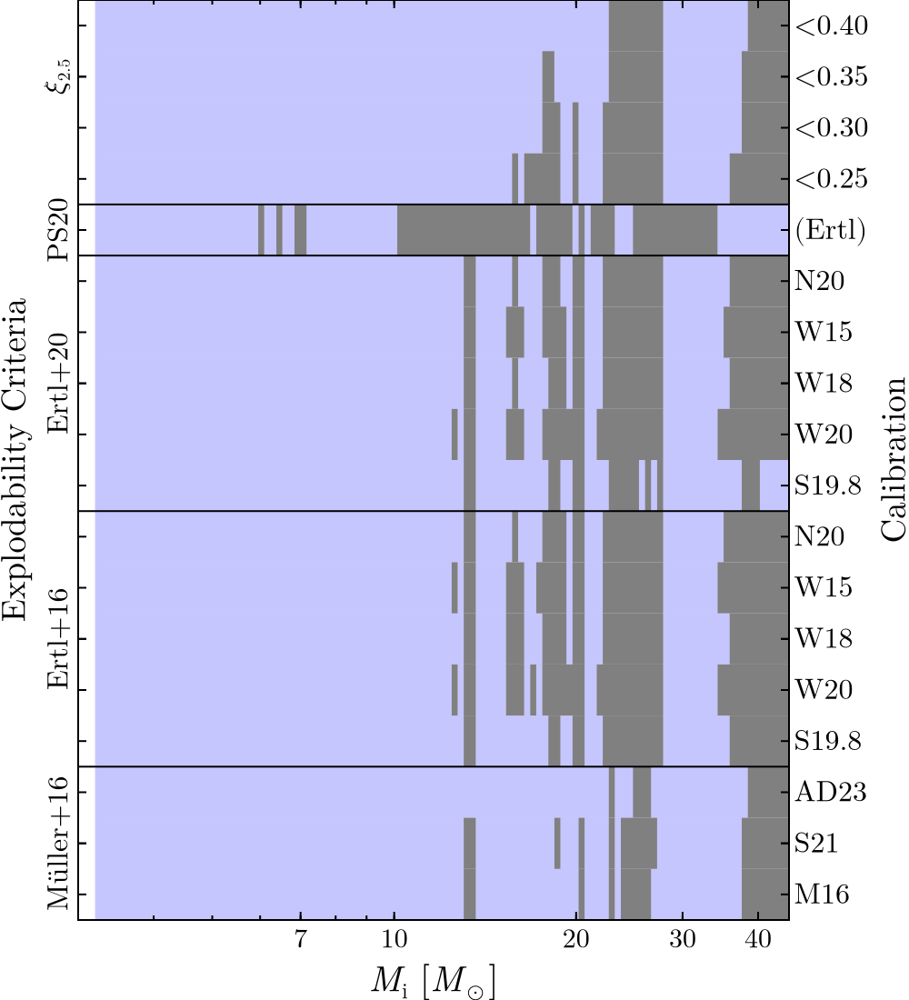

In [44]:
# include(include_dir*"SN_support.jl")

the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)


set_theme!(theme_latexfonts())



deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )

M_tot(when, f=f_HeSCC) = f[!, "M_"*when]
M_he_core(when, f = f_HeSCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_HeSCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_HeSCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_HeSCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_HeSCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_HeSCC) =  f[!, "Xs_"*when]
Ys(when, f = f_HeSCC) =  f[!, "Ys_"*when]
M_He_env(when, f = f_HeSCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = f_HeSCC.M_ini_BURN_He
Cc(when, f = f_HeSCC) =  f[!, "Cc_"*when]


 exp_criteria = ["MM-M16", "MM-S21", "MM-AD23", 
                 "Ertl-S19.8_old", "Ertl-W20_old", "Ertl-W18_old", "Ertl-W15_old", "Ertl-N20_old", 
                 "Ertl-S19.8_new", "Ertl-W20_new", "Ertl-W18_new", "Ertl-W15_new", "Ertl-N20_new", 
                 "PS20", "comp0.25", "comp0.30", "comp0.35", "comp0.40"]

function boundary_builder(explosion_criterion)
    boundaries = Dict("WD" =>Any[0], "IIP" =>Any[0], "IIb" =>Any[0], "Ibc"=>Any[0], "BH" =>Any[0])


    dm= 0.01
    boundaries["WD"][1]+=1
    push!(boundaries["WD"], [10^(0.20-dm/2)])
    previous = "WD";
    for logm in 0.20:dm:2.300
        ix=  find_nearest(f_HeSCC.logM, logm)
        m = f_HeSCC.M_ini_BURN_He[ix]
        Mend = interpol_HeS_Mmax["M_end"](m)
        Mhecore = interpol_HeS_Mmax["M_hecore_end"](m)
        Mcocore = interpol_HeS_Mmax["M_cocore_end"](m)
        M_env = Mend-Mhecore
        Xc = interpol_HeS_Mmax["X_C"](m)
        SN = Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
                "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)
    #    SN_OUTPUT_manual(SN, M,  EXP_CRIT)D
        SN_OUTPUT_manual(SN, Mend,
                            Mhecore, 
                            Mcocore, 
                            m, 
                            M_env, 
                            Xc, 
                            "end_BURN_C",
                            explosion_criterion, reference_grid = "MW-Stripped")
        out = "X"
        for k in keys(SN)
            if SN[k]>0
                #@printf("m %6.3f %5s",m, k)
                out = k
                break
            end 
        end 
        
        if out == previous 
            #print("\n"); 
            continue
        end 

        #@printf("----> CHANGE <-----")
        ix = boundaries[previous][1]+1
        push!(boundaries[previous][ix],10^(logm-dm/2))
        #print("\n", boundaries, "\n")


        boundaries[out][1] += 1
        ix_new = boundaries[out][1]+1
        push!(boundaries[out], [])
        #print("\n", boundaries, "\n")

        push!(boundaries[out][ix_new], 10^(logm-dm/2))
        #print("\n", boundaries, "\n")

        previous = out 

    end
    #print("\n", boundaries, "\n")
    ix = boundaries[previous][1]+1
    push!(boundaries[previous][ix], 10^(2.30+dm/2))
    #print("\n", boundaries, "\n")

    return boundaries 
end 

boundaries = boundary_builder("X")
boundary = Dict()
for exp_crit in exp_criteria
    boundary[exp_crit] = boundary_builder(exp_crit)
end

color_alpha = 0.15
colores = Dict("WD"    => RGBAf(1.,1,1,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)


FIG = Figure(size=(500,550),  figure_padding = 0)
grid = FIG[1,1] = GridLayout()
xticks = [7, 10, 20,30,40,50,70,100, 200, 300]
xticks_label = [L"%$(t)" for t in xticks]

yticks = range(0,20,step=2)
yticks_label = [L"%$(t)" for t in yticks]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

dy=1/length(exp_criteria)

xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]
ymticks = range(0,20,step=1)
ax_bh = plot_settings(grid[1, 0:1]; 
                        xlabel=L"M_\mathrm{i} \ [M_\odot]", ylabel="Explodability Criteria", title ="",
                        xticks=(xticks,xticks_label),
                        xticklabelsvisible=true,   
                        yticks=([dy*3/2, dy*(3+8)/2, dy*(9+12)/2, dy*(13+14)/2, dy*(15+18)/2], 
                        ["Müller+16", "Ertl+16",  "Ertl+20", "PS20", L"\xi_{2.5}"]), 
                        xmticks=xmticks, ymticks=ymticks,
                        yticklabelsize=16, yticklabelrotation=pi/2,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10)
ax_bh2 = plot_settings(grid[1, 0:1]; 
                        xlabel="", ylabel="Calibration", title ="",
                        xticks=[-10],
                        xticklabelsvisible=false,   
                        yaxisposition=:right,
                        yticks=(dy/2:dy:1, 
                        [L"\mathrm{M16}", L"\mathrm{S21}",  L"\mathrm{AD23}",
                         "S19.8", "W20", "W18", "W15", "N20",
                         "S19.8", "W20", "W18", "W15", "N20", 
                         "(Ertl)","<0.25", "<0.30", "<0.35", "<0.40" ]), 
                        yticklabelsize=16,
                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                        xscale = log10, )


when_line = "end"

xmin = 3
xmax = 45

xlims!(ax_bh, xmin, xmax)
ylims!(ax_bh, 0, 1)
ylims!(ax_bh2, 0, 1)

for outcome in collect(keys(colores))

    fill = colores[outcome]
    for ix in range(2, boundaries[outcome][1]+1)
        filler1=vspan!(ax_bh, 
            [boundaries[outcome][ix][1]], [boundaries[outcome][ix][2]], 
            ymin=0, ymax=1,  color=fill)
        translate!(filler1, 0, 0, -0.1)
    end
    BH = occursin("BH", outcome)

    ylow = 0
    dy=1/length(exp_criteria)
    for exp_crit in exp_criteria
        for ix in range(2, boundary[exp_crit][outcome][1]+1)
            filler3=vspan!(ax_bh, 
                        [boundary[exp_crit][outcome][ix][1]], [boundary[exp_crit][outcome][ix][2]], 
                        ymin=ylow, ymax=ylow+dy,  color= fill) 
            translate!(filler3, 0, 0, -0.1)    
        end    
        ylow+=dy
    end
        
end

lines!(ax_bh, [0.1, 500], [3*dy,3*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [8*dy,8*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [13*dy,13*dy], linestyle = :solid, linewidth = 1, color = :black)
lines!(ax_bh, [0.1, 500], [14*dy,14*dy], linestyle = :solid, linewidth = 1, color = :black)

resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/implodability_bar_HeS.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG 




# E_exp, M4mu4

Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Reading & cleaning single-star CORR files...done!
Building Case BC interpolator (PythonCall)...done
Building merger Mi +f_acc -> Mco, BSG interpolators: Retrieving data ...building interpolators...

┌ Warning: Assignment to `logM` in soft scope is ambiguous because a global variable by the same name exists: `logM` will be treated as a new local. Disambiguate by using `local logM` to suppress this warning or `global logM` to assign to the existing global variable.
└ @ nothing /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/SN_support.jl:47


done!
Building merger/partial stripped outcome -> core He dep. Retrieving data ...Building interpolation library...done!
Building Explosion criteria......PS20...M16-E16 - imported CC grids, explodability files and interpolants


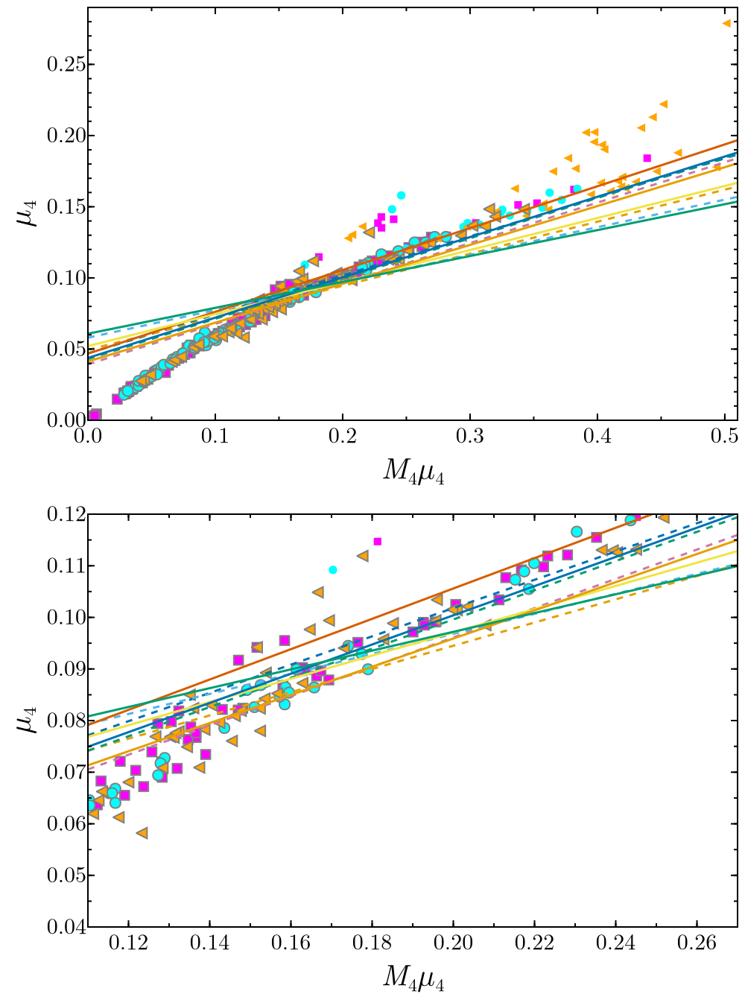

In [23]:
include(include_dir*"SN_reader_MW.jl")

FIG = Figure(size=(500,500*sqrt(1.8)),  figure_padding = 5)


the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)

fexp_single = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/EXP_PROP_M16.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)
fexp_singleHeS = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/HeS/EXP_PROP_M16.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)
fexp_singleHeSDRAD = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/drad/single_he_stars/Z_0.015/EXP_PROP_AD23.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)

set_theme!(theme_latexfonts())

#deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )
###
ax = plot_settings(FIG[1,1]; 
                        xlabel=L"M_4\mu_4", ylabel=L"\mu_4", title ="",
                        xmticks = 0:0.05:1, xticks = 0:0.1:1, ymticks = 0:0.01:1, yticks = 0:0.05:1)
ax2 = plot_settings(FIG[2,1]; 
                        xlabel=L"M_4\mu_4", ylabel=L"\mu_4", title ="",
                        xmticks = 0:0.01:1, xticks = 0:0.02:1, ymticks = 0:0.005:1, yticks = 0:0.01:1)


mu4 = fexp_single.mu4 
M4 = fexp_single.M4 
MMSN = fexp_single.E_exp .> 0
scatter!(ax, M4 .* mu4 , mu4, color = :magenta, marker = :rect, markersize = 8)
scatter!(ax, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :magenta, marker = :rect, strokecolor = :gray, strokewidth = 1, markersize = 10)
scatter!(ax2, M4 .* mu4 , mu4, color = :magenta, marker = :rect, markersize = 8)
scatter!(ax2, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :magenta, marker = :rect, strokecolor = :gray, strokewidth = 1, markersize = 10)

mu4 = fexp_singleHeS.mu4 
M4 = fexp_singleHeS.M4 
MMSN = fexp_singleHeS.E_exp .> 0

scatter!(ax, M4 .* mu4 , mu4, color = :cyan, marker = :circle, markersize = 8)
scatter!(ax, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :cyan, marker = :circle, strokecolor = :gray, strokewidth = 1, markersize = 10)
scatter!(ax2, M4 .* mu4 , mu4, color = :cyan, marker = :circle, markersize = 8)
scatter!(ax2, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :cyan, marker = :circle, strokecolor = :gray, strokewidth = 1, markersize = 10)

mu4 = fexp_singleHeSDRAD.mu4 /2
M4 = fexp_singleHeSDRAD.M4 
MMSN = fexp_singleHeSDRAD.E_exp .> 0

scatter!(ax, M4 .* mu4 , mu4, color = :orange, marker = :ltriangle, markersize = 8)
scatter!(ax, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :orange, marker = :ltriangle, strokecolor = :gray, strokewidth = 1, markersize = 10)
scatter!(ax2, M4 .* mu4 , mu4, color = :orange, marker = :ltriangle, markersize = 8)
scatter!(ax2, (M4 .* mu4)[MMSN] , mu4[MMSN], color = :orange, marker = :ltriangle, strokecolor = :gray, strokewidth = 1, markersize = 10)



exp_line(x, ks = [0.274, 0.0470]) = ks[1]*x .+ ks[2]
m4mu4_s = 0:0.01:1
for a in [ax, ax2]
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.274, 0.0470]), linestyle = :dash)
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.225, 0.0495]), linestyle = :dash)
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.283, 0.0430]), linestyle = :dash)
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.284, 0.0393]), linestyle = :dash)
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.194, 0.0580]), linestyle = :dash)
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.294, 0.0468]))
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.225, 0.0521]))
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.283, 0.0438]))
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.273, 0.0413]))
        lines!(a, m4mu4_s, exp_line(m4mu4_s, [0.182, 0.0608]))
end
xlims!(ax, 0, 0.51)
ylims!(ax, 0, 0.29)
xlims!(ax2, 0.11, 0.27)
ylims!(ax2, 0.04, 0.12)

# axislegend(ax,  position=:rt, 
#             nbanks=1, titleposition=:top)
resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/mu4m4_test.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG




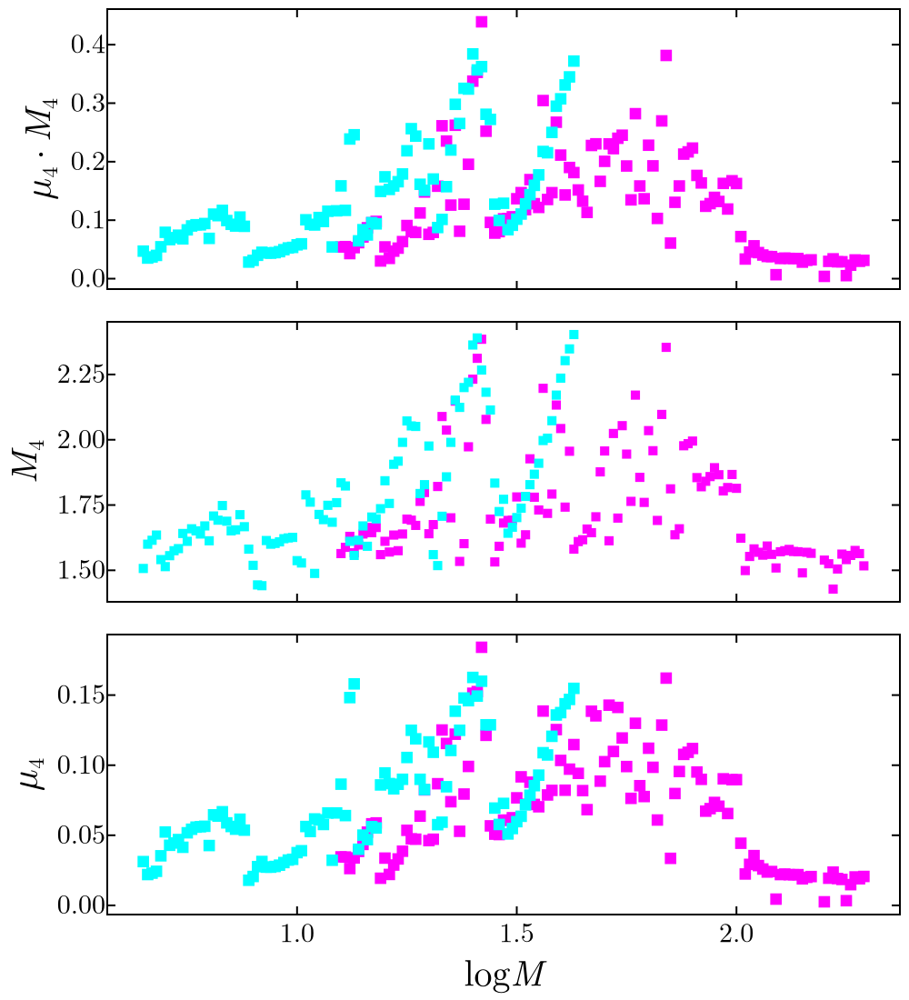

In [6]:
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/defs.jl")
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/SN_support.jl")
#using GLMakie
# using CairoMakie
######
#include("SN_reader_MW.jl")
FIG = Figure(size=(500,550),  figure_padding = 5)


the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
f_singleCC = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_toCC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)

fexp_single = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/EXP_PROP_M16.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)
fexp_singleHeS = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/HeS/EXP_PROP_M16.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)
fexp_singleHeSDRAD = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/drad/single_he_stars/Z_0.015/EXP_PROP_AD23.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)

set_theme!(theme_latexfonts())

#deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )
###
ax1 = plot_settings(FIG[1,1]; 
                        xlabel=L"\log M", ylabel=L"M_4", title ="",  xticklabelsvisible=false, xlabelvisible=false,
                        )
ax2 = plot_settings(FIG[2,1]; 
                        xlabel=L"\log M", ylabel=L"\mu_4", title ="", 
                        )
ax3 = plot_settings(FIG[0,1]; 
                        xlabel=L"\log M", ylabel=L"\mu_4\cdot M_4", title ="", xticklabelsvisible=false, xlabelvisible=false,
                        )


mu4 = fexp_single.mu4 
M4 = fexp_single.M4 
logM = fexp_single.logM
MMSN = fexp_single.E_exp .> 0
scatter!(ax1, logM, M4, color = :magenta, marker = :rect, markersize = 8)
scatter!(ax2, logM, mu4, color = :magenta, marker = :rect, markersize = 10)
scatter!(ax3, logM, mu4 .* M4, color = :magenta, marker = :rect, markersize = 10)

mu4 = fexp_singleHeS.mu4 
M4 = fexp_singleHeS.M4 
MMSN = fexp_singleHeS.E_exp .> 0
logM = fexp_singleHeS.logM

scatter!(ax1, logM, M4, color = :cyan, marker = :rect, markersize = 8)
scatter!(ax2, logM, mu4, color = :cyan, marker = :rect,  markersize = 10)
scatter!(ax3, logM, mu4 .* M4, color = :cyan, marker = :rect,  markersize = 10)



resize_to_layout!

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/mu4m4_test2.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG




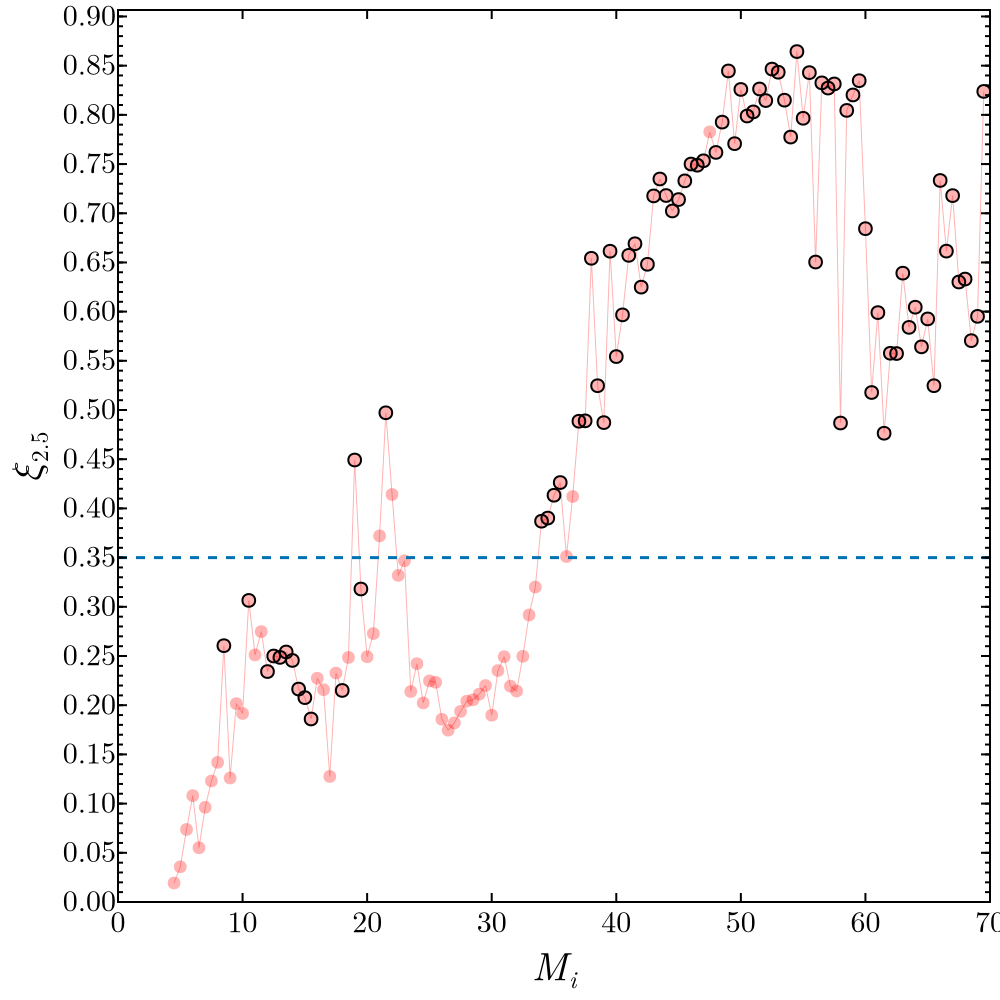

In [47]:
# include(include_dir*"SN_reader_MW.jl")

FIG = Figure(size=(500*sqrt(1),500),  figure_padding = 5)


the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"



ax = plot_settings(FIG[1,1]; 
                        xlabel=L"M_i", ylabel=L"\xi_\mathrm{2.5}", title ="",  
                        ymticks = 0:0.01:1, yticks = 0:0.05:1)

ks_cal = Dict("S19.8"    =>[0.294, 0.0468],
        "S19.8_old"=>[0.274, 0.0470],
        "W20"      =>[0.273, 0.0413],
        "W20_old"  =>[0.284, 0.0393],
        "W15_old"  =>[0.225, 0.0495], 
        "W18_old"  =>[0.283, 0.0438], 
        "N20_old"  =>[0.194, 0.0580]
        )
exp_line(x; ks = [0.274, 0.0470]) = ks[1]*x .+ ks[2]
# [0.274, 0.0470]
# [0.225, 0.0495]
# [0.283, 0.0430]
# [0.284, 0.0393]
# [0.194, 0.0580]
# [0.294, 0.0468]
# [0.225, 0.0521]
# [0.283, 0.0438]
# [0.273, 0.0413]
# [0.182, 0.0608]
ks = [0.274, 0.0470]
implode_single =  (fexp_single("M16").mu4 .> exp_line(fexp_single("M16").mu4 .* fexp_single("M16").M4; ks = ks)) 
implode_HeS =  (fexp_HeS("M16").mu4 .> exp_line(fexp_HeS("M16").mu4 .* fexp_HeS("M16").M4; ks = ks)) 
implode_drad =  (fexp_DRAD.mu4/2 .> exp_line(fexp_DRAD.mu4/2 .* fexp_DRAD.M4; ks = ks)) 

# scatter!(ax, 10. .^ fexp_single.logM, fexp_single.xi25, color = RGBAf(0,0,0,0.3))
# scatter!(ax, 10. .^ fexp_single.logM[implode_single], fexp_single.xi25[implode_single], color = RGBAf(0,0,0,0), strokecolor = RGBAf(0,0,0,1), strokewidth = 1)         
# scatter!(ax, 10. .^ fexp_HeS.logM,    fexp_HeS.xi25, color =  RGBAf(0,0,1,0.3),)         
# scatter!(ax, 10. .^ fexp_HeS.logM[implode_HeS],    fexp_HeS.xi25[implode_HeS], color = RGBAf(0,0,1,0), strokecolor = :blue, strokewidth=1)         
scatterlines!(ax, fexp_DRAD.logM,   fexp_DRAD.xi25, color =  RGBAf(1,0,0,0.3), linewidth = 0.5)         
scatter!(ax, fexp_DRAD.logM[implode_drad],   fexp_DRAD.xi25[implode_drad], color =  RGBAf(1,0,0,0), strokecolor = :black, strokewidth = 1)             
lines!(ax, [0, 100], [ 0.35, 0.35], linestyle = :dash)
ylims!(ax, 0, nothing)
xlims!(ax, 0, 70)

FIG

save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/drad_comp.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG




fexp_single

Mend vs Mini (binary stars)

In [8]:
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/defs.jl")
# include("/vol/aibn133/data1/aercolino/SOFTWARE/Julia/SN_support.jl")
#using GLMakie
# using CairoMakie
######

the_directory = "vol/aibn133/data1/aercolino/GRID_CACHES/hjin/"
# f_single_og = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/CORR_GRID_single_150.dat", 
#                      header=1, DataFrame,delim=' ',ignorerepeated=true)
# f_single = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/CORR_GRID_single_0p2_CC.dat", 
#                      header=1, DataFrame,delim=' ',ignorerepeated=true)

fexp_single = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/single_star/EXP_PROP_S21.data",  
            DataFrame, delim=' ',ignorerepeated=true, silencewarnings=true)

#deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


# deleteat!(f_single_og, findall( !>(0) , f_single_og.M_he_core_end_BURN_He) )
# deleteat!(f_single_og, findall( !<=(1.10) , f_single_og.logM) )
###
MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
EXP_CRIT = "X"
f_B = 0.75
Kicks = Inf
MODELS = predict_SN_from_each_model(MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS, EXP_CRIT, Kicks; logPs = range(0.15, 3.70, step=0.05), )
print("done\n")

Scanning logMs
2.00 
will_it_explode reported  495 Warnings
done


In [9]:
alpha = 0.3
color_coding = Dict()
color_coding["WD"]   = RGBAf(0.5,0.5,0.5,alpha)    
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
# color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 

M_tot(when, f=f_singleCC) = f[!, "M_"*when]
M_he_core(when, f = f_singleCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_singleCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_singleCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_singleCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_singleCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_singleCC) =  f[!, "Xs_"*when]
Ys(when, f = f_singleCC) =  f[!, "Ys_"*when]
M_He_env(when, f = f_singleCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = 10. .^ f_singleCC.logM
Mi_og = 10. .^ f_single_og.logM

    

color_alpha = 0.15
colores = Dict("WD"    => RGBAf(0.,0.8,0.8,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)

set_theme!(theme_latexfonts())
FIG = Figure(size=(1000,400))
grid = FIG[1,1] = GridLayout()


xticks = [7, 10, 14, 20,30,40,50,70,100, 200, 300]
xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

grid_setup = Dict() 
grid_setup["eA"] = 1
grid_setup["lA"] = 2
grid_setup["eB"] = 3
grid_setup["lB"] = 4 
grid_setup["xC"] = 5
grid_setup["NI"] = 6
grid_setup["tot"] = 1:3
grid_setup["he"] = 4:6
grid_setup["co"] = 7:9
grid_setup["xc"] = 10:12
grid_setup["failed"] = 13

yticks  = Dict(
    grid_setup["tot"] => range(0,50,step=5),
    grid_setup["he"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["co"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["xc"] => (-1:0.05:1), 
    grid_setup["failed"] => ([1,10,100]))
ymticks  = Dict(
    grid_setup["tot"] => range(0,20,step=1),
    grid_setup["he"] => (0.1:0.1:3),
    grid_setup["co"] =>(0.1:0.1:3),
    grid_setup["xc"] => (-1:0.01:1), 
    grid_setup["failed"] => (union(1:1:10, 10:10:100,100:100:1000)))

setup_ax(grid_x, grid_y, ylabel, xvisible, panel_title) = plot_settings(grid[grid_x, grid_y]; 
                                        xlabel = xvisible ? L"M_\mathrm{i} \ [M_\odot]" : " ",
                                        ylabel = (grid_y > grid_setup["eA"]) ? "" : ylabel, 
                                        title  = (grid_x == grid_setup["tot"]) ? panel_title : " ",
                                        xticks = (grid_y == grid_setup["failed"]) ? [10,11,12,13,14,15,16,17] : xticks,
                                        xticklabelsvisible=xvisible,   
                                        yticklabelsvisible= (grid_y == grid_setup["eA"]), 
                                        yticks= yticks[grid_x], 
                                        xmticks=xmticks, 
                                        ymticks= ymticks[grid_x], 
                                        yticklabelsize=yticklabelsize,
                                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                                        xscale = ( grid_y == grid_setup["xC"] ) ? identity : log10,
                                        yscale = ( grid_x in [grid_setup["he"],grid_setup["co"],grid_setup["failed"]]) ? log10 : identity,
                                        titlesize=15 )
ax = Dict("eA"=>Dict(), "lA"=>Dict(), "eB"=>Dict(), "lB"=>Dict(), "xC"=>Dict(), "NI"=>Dict()) 
panel_titles = Dict(
    "eA"=>"Early Case A",
    "lA"=>"Late Case A",
    "eB"=>"Early Case B", 
    "lB"=>"Late Case B",
    "xC"=>"Case C",
    "NI"=>"Non-Interacting"
)
for ccc in ["eA", "lA", "eB", "lB", "xC", "NI"]
        ax[ccc]["tot"]    = setup_ax(grid_setup["tot"]   , grid_setup[ccc], L"M_\mathrm{tot} \ [M_\odot]",     true,  panel_titles[ccc])
        # ax[ccc]["he"]     = setup_ax(grid_setup["he"]    , grid_setup[ccc], L"M_\mathrm{He-core}/M_\mathrm{He-core}^\mathrm{single\ star} \ [M_\odot]", false,  "")
        # ax[ccc]["co"]     = setup_ax(grid_setup["co"]    , grid_setup[ccc], L"M_\mathrm{CO-core}/M_\mathrm{CO-core}^\mathrm{single\ star} \ [M_\odot]", false ,  "")
        # ax[ccc]["xc"]     = setup_ax(grid_setup["xc"]    , grid_setup[ccc], L"X_\mathrm{C}-X_\mathrm{C}^{single\ star}", false ,  "")
        # ax[ccc]["failed"] = setup_ax(grid_setup["failed"], grid_setup[ccc], "# Failed", true ,  "")
end
    
var_and_thr = Dict( 
        'A' => Dict("var"=>"Xc_1_ini_RLOF_A", "thr"=>0.15),
        'B' => Dict("var"=>"logT_1_ini_RLOF_B","thr"=>3.6)
)

failed_x = Dict(
    "eA"=>[],
    "lA"=>[],
    "eB"=>[], 
    "lB"=>[],
    "xC"=>[],
    "NI"=>[])


ms = 35 
m = '-'


for select in ["eA", "lA", "eB", "lB", "xC", "NI"]

    print("plotting models with ", select, "\n")

    for logM in logMs
        print()
        logM_t = to_key(logM)  
        # logM != 1.10 && continue
        for logP in logPs 
            logP_t = to_key(logP)
            for q in qs 
                q_t = to_key(q)
                try 
                    MODELS[logM_t][logP_t][q_t]
                catch 
                    continue 
                end 
                model = MODELS[logM_t][logP_t][q_t]
                term = model["end1"]
                n = model["mod"]

                if select != "NI"

                    early = select[1] == 'e'
                    case = select[2]
                    (occursin("mer", model["casus"]) || occursin("IMT", model["casus"]) )&& continue
                    (length(model["case"]) == 0) && continue #it is non-interacting!
                    (model["case"][1] != case) && continue 
                    

                    if case != 'C'
                        if early
                            ok = f_MW[!, var_and_thr[case]["var"]][n] >= var_and_thr[case]["thr"]
                        else 
                            ok = f_MW[!, var_and_thr[case]["var"]][n]  < var_and_thr[case]["thr"]
                        end 
                        !ok && continue
                    end 
                else 
                    (length(model["case"]) > 0) && continue
                    (occursin("mer", model["casus"]) || occursin("IMT", model["casus"]) ) && continue                   
                end 
                c = nothing
                which_SN = model["first"] == "1" ? "SN1" : "SN2"
                which_star = model["first"] == "1" ? "1" : "2"
                Mend    =  min(f_MW.M_1_end_1[n], model["M"*which_star*"end"])
                Mhe_end =  min(f_MW.M_he_core_1_end_1[n], model["M"*which_star*"end"])
                Mco_end =  f_MW.M_co_core_1_end_1[n]
                Xc = f_MW.Cc_1_end_BURN_He_1[n]

                which_SN = model["first"] == "1" ? "SN1" : "SN2"
                (model[which_SN]["IIP"]   > 0) && (c = color_coding["IIP"])
                (model[which_SN]["IIP-B"]   > 0) && (c = color_coding["IIP-B"]; @printf("BSG!\n"))
                (model[which_SN]["Ibc"]   > 0) && (c = color_coding["Ibc"])
                (model[which_SN]["IIb"]   > 0) && (c = color_coding["IIb"])
                (model[which_SN]["II-i"]  > 0) && (c = color_coding["II-i"])
                (model[which_SN]["Ibc-i"] > 0) && (c = color_coding["Ibc-i"])
                (model[which_SN]["WD"]    > 0) && (c = :white)
                if (model[which_SN]["X"]    > 0) 
                   
                    @printf("SN = X ?!?!?! logM/logP/q=%.2f/%.2f/%.2f, flags are %7s/%7s/ P:%15s, S:%7s", 
                              logM, logP, q, model["casus"], model["case"], model["end1"], model["end2"])

                    report_model(f_MW, MODELS, logM, q, logP, ["M_1", "M_2"])
                    throw(ErrorException)
                end
                isnothing(c) && (@printf("HEY!"); throw(ErrorException))
                if ! (occursin("CB", term) || occursin("Cdep", term) || occursin("pHeB", term) || occursin("Hedep", term)) 
                    push!(failed_x[select], 10^logM)
                    Mend = model["M"*which_star*"end"]
                    Mhe = model["M"*which_star*"_he"]
                    Mco = model["M"*which_star*"_co"]
                    Xc = model["Xc"*which_star]
                    ms_fail = ms/2.5
                    m_fail = :rect
                    m_width = 2
                    
                    # @printf("Failed! logM/logP/q=%.2f/%.2f/%.2f, flags are %7s/%7s/ P:%15s, S:%7s;  (Mend,he,co,Xc) = %5.1f/%5.1f/%5.1f/%5.3f\n", 
                    #          logM, logP, q, model["casus"], model["case"], model["end1"], model["end2"], Mend,Mhe,Mco,Xc)
                    scatter!(ax[select]["tot"], 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # scatter!(ax[select]["he"],  10^logM, Mhe ./ interpol_single_Mmax["M_hecore_end"](10^logM), color = c, strokecolor =:black , strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # scatter!(ax[select]["co"],  10^logM, Mco ./ interpol_single_Mmax["M_cocore_end"](10^logM), color = c, strokecolor =:black, strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # scatter!(ax[select]["xc"],  10^logM, Xc -  interpol_single_Mmax["X_C"](10^logM), color = c, strokecolor =:black, strokewidth=m_width, markersize=ms_fail, marker = m_fail)                  
                    continue 
                end 

                # early_or_late = (f_MW[logM_t].logT_1_ini_RLOF_B[n] > 3.6) ? "early" : "late"
                (model[which_SN]["X"]     > 0) && continue
                (model[which_SN]["WD"]    > 0) && continue 

                (model[which_SN]["IIP"]   > 0 && f_MW.logT_1_end_1[n] > 3.9) && (print(n, "HEY BSG!\n"))
                (model[which_SN]["IIP"]   > 0 && f_MW.logT_1_end_1[n] > 3.9) && (c = :black)
                # (Mend > Mhe_end) && scatter!(ax_tot, 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["tot"], 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["he"],  10^logM, Mhe_end ./ interpol_single_Mmax["M_hecore_end"](10^logM), color = c, strokecolor =:blue , strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["co"],  10^logM, Mco_end ./ interpol_single_Mmax["M_cocore_end"](10^logM), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["xc"],  10^logM, Xc -  interpol_single_Mmax["X_C"](10^logM), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)

            end
        end
    end

    # length(failed_x[select])>0  && hist!(ax[select]["failed"], failed_x[select], bins=[10^(logM-0.025) for logM in logMs], color = "gray", strokecolor=:black)

    lw = 1
    a = 1
    when_line = "ini_BURN_C"
    lines!(ax[select]["tot"], Mi_new , M_tot(when_line, f_single_new), 
                color = :black, linewidth = lw, alpha=a  )
    lines!(ax[select]["tot"], Mi_og , M_tot(when_line, f_single_og), 
                color = :black, linewidth = lw, alpha=a , linestyle=:dash )
    lines!(ax[select]["tot"], Mi_new , M_he_core(when_line, f_single_new), 
                color = :blue, linewidth = lw, alpha=a ,   )
    lines!(ax[select]["tot"], Mi_og , M_he_core(when_line, f_single_og), 
                color = :blue, linewidth = lw, alpha=a  , linestyle=:dash  )
    lines!(ax[select]["tot"], Mi_new , M_co_core(when_line, f_single_new), 
                color = :green, linewidth = lw, alpha=a ,  )
    lines!(ax[select]["tot"], Mi_og , M_co_core(when_line, f_single_og), 
                color = :green, linewidth = lw, alpha=a , linestyle=:dash )

    # lines!(ax[select]["he"], Mi , 1 .+ 0 .*Mi, 
    #             color = :blue, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi_og , 1 .+ 0 .* Mi_og, 
    #             color = :blue, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi , M_co_core(when_line) ./ M_he_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi_og ,M_co_core(when_line,f_single) ./ M_he_core(when_line,f_single), 
    #             color = :green, linewidth = lw, alpha=a )

    # lines!(ax[select]["co"], Mi , 1 .+ 0 .*Mi, 
    #             color = :green, linewidth = lw, alpha=a )
    # lines!(ax[select]["co"], Mi_og , 1 .+ 0 .* Mi_og, 
    #             color = :green, linewidth = lw, alpha=a )

    # lines!(ax[select]["xc"], Mi ,  0 .*Mi, 
    #             color = :black, linewidth = lw, alpha=a )
    # lines!(ax[select]["xc"], Mi_og , 0 .* Mi_og, 
    #             color = :black, linewidth = lw, alpha=a )


end

for ccc in  ["eA", "lA", "eB", "lB", "xC", "NI"]
    ylims!(ax[ccc]["tot"], 1, 15.5)
    # ylims!(ax[ccc]["he"],  0.15, 1.19)
    # ylims!(ax[ccc]["co"],  0.2, 1.19)
    # ylims!(ax[ccc]["xc"],  -0.02,0.17)
    # ylims!(ax[ccc]["failed"],  1, 10)
end
for ddd in ["tot"]#, "he", "co", "xc", "failed"]
    xlims!(ax["eA"][ddd], 13, 120)
    xlims!(ax["lA"][ddd], 12, 120)
    xlims!(ax["eB"][ddd], 9.4, 75)
    xlims!(ax["lB"][ddd], 9.4, 45)
    xlims!(ax["xC"][ddd], 9.4, 16.5)
    xlims!(ax["NI"][ddd], 9., 110)
end
#some more specific xranges 

rowgap!(grid, 5)
colgap!(grid, 5)




resize_to_layout!



save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/OUTCOME_SN_PRIMARY_%s_new.pdf",EXP_CRIT), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG


plotting models with eA


UndefVarError: UndefVarError: `f_single_new` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [10]:
alpha = 0.3
color_coding = Dict()
color_coding["WD"]   = RGBAf(0.5,0.5,0.5,alpha)    
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 


M_tot(when, f=f_singleCC) = f[!, "M_"*when]
M_he_core(when, f = f_singleCC) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_singleCC) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_singleCC) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_singleCC) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_singleCC) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_singleCC) =  f[!, "Xs_"*when]
Ys(when, f = f_singleCC) =  f[!, "Ys_"*when]
M_He_env(when, f = f_singleCC) = M_he_core(when, f) - M_co_core(when, f)
Mi = 10. .^ f_singleCC.logM
Mi_og = 10. .^ f_single_og.logM


color_alpha = 0.15
colores = Dict("WD"    => RGBAf(0.,0.8,0.8,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)

set_theme!(theme_latexfonts())
# FIG = Figure(size=(1000,1000*sqrt(2)))
FIG = Figure(size=(1000,400))
grid = FIG[1,1] = GridLayout()


xticks = [7, 10, 14, 20,30,40,50,70,100, 200, 300]
xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

grid_setup = Dict() 
grid_setup["eA"] = 1
grid_setup["lA"] = 2
grid_setup["eB"] = 3
grid_setup["lB"] = 4 
grid_setup["xC"] = 5
grid_setup["NI"] = 6
grid_setup["tot"] = 1:3
grid_setup["he"] = 4:6
grid_setup["co"] = 7:9
grid_setup["xc"] = 10:12
grid_setup["failed"] = 13

yticks  = Dict(
    grid_setup["tot"] => range(0,50,step=5),
    grid_setup["he"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["co"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["xc"] => (-1:0.05:1), 
    grid_setup["failed"] => ([1,10,100]))
ymticks  = Dict(
    grid_setup["tot"] => range(0,20,step=1),
    grid_setup["he"] => (0.1:0.1:3),
    grid_setup["co"] =>(0.1:0.1:3),
    grid_setup["xc"] => (-1:0.01:1), 
    grid_setup["failed"] => (union(1:1:10, 10:10:100,100:100:1000)))

setup_ax(grid_x, grid_y, ylabel, xvisible, panel_title) = plot_settings(grid[grid_x, grid_y]; 
                                        xlabel = xvisible ? L"M_\mathrm{i} \ [M_\odot]" : " ",
                                        ylabel = (grid_y > grid_setup["eA"]) ? "" : ylabel, 
                                        title  = (grid_x == grid_setup["tot"]) ? panel_title : " ",
                                        xticks = (grid_y == grid_setup["failed"]) ? [10,11,12,13,14,15,16,17] : xticks,
                                        xticklabelsvisible=xvisible,   
                                        yticklabelsvisible= (grid_y == grid_setup["eA"]), 
                                        yticks= yticks[grid_x], 
                                        xmticks=xmticks, 
                                        ymticks= ymticks[grid_x], 
                                        yticklabelsize=yticklabelsize,
                                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                                        xscale = ( grid_y == grid_setup["xC"] ) ? identity : log10,
                                        yscale = ( grid_x in [grid_setup["he"],grid_setup["co"],grid_setup["failed"]]) ? log10 : identity,
                                        titlesize=15 )
ax = Dict("eA"=>Dict(), "lA"=>Dict(), "eB"=>Dict(), "lB"=>Dict(), "xC"=>Dict(), "NI"=>Dict()) 
panel_titles = Dict(
    "eA"=>"Early Case A",
    "lA"=>"Late Case A",
    "eB"=>"Early Case B", 
    "lB"=>"Late Case B",
    "xC"=>"Case C",
    "NI"=>"Non-Interacting"
)
for ccc in ["eA", "lA", "eB", "lB", "xC", "NI"]
        ax[ccc]["tot"]    = setup_ax(grid_setup["tot"]   , grid_setup[ccc], L"M_\mathrm{tot} \ [M_\odot]",     true,  panel_titles[ccc])
        # ax[ccc]["he"]     = setup_ax(grid_setup["he"]    , grid_setup[ccc], L"M_\mathrm{He-core}/M_\mathrm{He-core}^\mathrm{single\ star} \ [M_\odot]", false,  "")
        # ax[ccc]["co"]     = setup_ax(grid_setup["co"]    , grid_setup[ccc], L"M_\mathrm{CO-core}/M_\mathrm{CO-core}^\mathrm{single\ star} \ [M_\odot]", false ,  "")
        # ax[ccc]["xc"]     = setup_ax(grid_setup["xc"]    , grid_setup[ccc], L"X_\mathrm{C}-X_\mathrm{C}^{single\ star}", false ,  "")
        # ax[ccc]["failed"] = setup_ax(grid_setup["failed"], grid_setup[ccc], "# Failed", true ,  "")
end
    
var_and_thr = Dict( 
        'A' => Dict("var"=>"Xc_1_ini_RLOF_A", "thr"=>0.15),
        'B' => Dict("var"=>"logT_1_ini_RLOF_B","thr"=>3.6)
)

failed_x = Dict(
    "eA"=>[],
    "lA"=>[],
    "eB"=>[], 
    "lB"=>[],
    "xC"=>[],
    "NI"=>[])


ms = 35 
m = '.'


function remove_nan(value_to_check_for_nan, value_to_replace_the_nan_with)

    isnan(value_to_check_for_nan) ? (return value_to_replace_the_nan_with) : (return value_to_check_for_nan)

end


for select in ["eA", "lA", "eB", "lB", "xC", "NI"]

    print("plotting models with ", select, "\n")

    for logM in logMs
        print()
        logM_t = to_key(logM)  
        for logP in logPs 
            logP_t = to_key(logP)
            for q in qs 
                q_t = to_key(q)
                model = nothing 
                try 
                    model = MODELS[logM_t][logP_t][q_t]
                catch 
                    continue 
                end 
                n = model["mod"]
                term = model["end2"]

                if select != "NI"
                    early = select[1] == 'e'
                    case = select[2]



                    (occursin("mer", model["casus"]) || occursin("IMT", model["casus"]) )&& continue
                    (length(model["case"]) == 0) && continue #it is non-interacting!
                    (model["case"][1] != case) && continue 
                    

                    if case != 'C'
                        if early
                            ok = f_MW[!, var_and_thr[case]["var"]][n] >= var_and_thr[case]["thr"]
                        else 
                            ok = f_MW[!, var_and_thr[case]["var"]][n]  < var_and_thr[case]["thr"]
                        end 
                        !ok && continue
                    end 
                else 
                    (occursin("mer", model["casus"]) || occursin("IMT", model["casus"]) )&& continue
                    !(length(model["case"]) == 0) && continue #it is non-interacting!
                end

                which_SN   = model["first"] == "1" ? "SN2" : "SN1"
                which_star = model["first"] == "1" ? "2" : "1"
                Mend    =  min(f_MW.M_2_end_2[n], model["M"*which_star*"end"])
                Mhe_end =  min(f_MW.M_he_core_2_end_2[n], model["M"*which_star*"end"])
                Mco_end =  f_MW.M_co_core_2_end_2[n]
                Xc = f_MW.Cc_2_end_BURN_He_2[n]

                mass_x_axis = maximum([10^logM*q,   remove_nan(f_MW.M_2_end_RLOF_A[n],0),
                                                    remove_nan(f_MW.M_2_end_RLOF_B[n],0),
                                                    remove_nan(f_MW.M_2_end_RLOF_C[n],0)])
                mass_x_axis = 10^logM * q

                c = nothing
                (model[which_SN]["IIP"]   > 0) && (c = color_coding["IIP"])
                (model[which_SN]["Ibc"]   > 0) && (c = color_coding["Ibc"])
                (model[which_SN]["IIb"]   > 0) && (c = color_coding["IIb"])
                (model[which_SN]["II-i"]  > 0) && (c = color_coding["II-i"])
                (model[which_SN]["Ibc-i"] > 0) && (c = color_coding["Ibc-i"])
                (model[which_SN]["WD"]    > 0) && (c=:white)
                (model[which_SN]["BH"]    > 0) && (throw(ErrorException("BH!")))
                (model[which_SN]["X"]     > 0) && (c=:black)#continue #print(model,"\n"); continue) #don't even count them as failed
                if ! (occursin("CB", term) || occursin("Cdep", term) || occursin("pHeB", term) || occursin("Hedep", term)) 
                    push!(failed_x[select], 10^logM*q)
                    Mend = model["M"*which_star*"end"]
                    Mhe = model["M"*which_star*"_he"]
                    Mco = model["M"*which_star*"_co"]
                    Xc = model["Xc"*which_star]
                    ms_fail = ms/2.5
                    m_fail = :rect
                    m_width = 1
                    strokecolor = :gray

                    # logM >= 1.5 && @printf("Failed! logM/logP/q=%.2f/%.2f/%.2f, flags are %7s/%7s/ P:%15s, S:%7s;  (Mend,he,co,Xc) = %5.1f/%5.1f/%5.1f/%5.3f\n", 
                    #          logM, logP, q, model["casus"], model["case"], model["end1"], term, Mend,Mhe,Mco,Xc)
                    (model[which_SN]["X"]+model[which_SN]["WD"]   == 0) && scatter!(ax[select]["tot"], mass_x_axis, Mend,    color = c, strokecolor =strokecolor, strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # (model[which_SN]["X"]+model[which_SN]["WD"]   == 0) && scatter!(ax[select]["he"],  mass_x_axis, Mhe ./ interpol_single_Mmax["M_hecore_end"](mass_x_axis), color = c, strokecolor =strokecolor , strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # (model[which_SN]["X"]+model[which_SN]["WD"]   == 0) && scatter!(ax[select]["co"],  mass_x_axis, Mco ./ interpol_single_Mmax["M_cocore_end"](mass_x_axis), color = c, strokecolor =strokecolor, strokewidth=m_width, markersize=ms_fail, marker = m_fail)
                    # (model[which_SN]["X"]+model[which_SN]["WD"]   == 0) && scatter!(ax[select]["xc"],  mass_x_axis, Xc -  interpol_single_Mmax["X_C"](mass_x_axis), color = c, strokecolor =strokecolor, strokewidth=m_width, markersize=ms_fail, marker = m_fail)                  
                    continue 
                end 

                # early_or_late = (f_MW[logM_t].logT_1_ini_RLOF_B[n] > 3.6) ? "early" : "late"
                (model[which_SN]["X"]     > 0) && continue
                (model[which_SN]["WD"]    > 0) && continue 
                (model[which_SN]["IIP-B"]   > 0)  &&  print(n, " II-BSG -> BSG! \n")
                (model[which_SN]["IIP"]   > 0 && f_MW.logT_2_end_2[n] > 3.9 ) && print(n, "IIP -> BSG! \n")
                # (model[which_SN]["IIb"]   > 0 && f_MW.logT_2_end_2[n] > 3.9 ) && print(n, "IIb -> BSG! \n")
                # (model[which_SN]["IIP"]   > 0 && f_MW.logT_2_end_2[n] > 3.9) && (print(n, "HEY BSG!\n"))
                (model[which_SN]["IIP"]   > 0 && f_MW.logT_2_end_2[n] > 3.9) && (c = :black)
                # (Mend > Mhe_end) && scatter!(ax_tot, 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["tot"], mass_x_axis, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["he"],  mass_x_axis, Mhe_end ./ interpol_single_Mmax["M_hecore_end"](mass_x_axis), color = c, strokecolor =:blue , strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["co"],  mass_x_axis, Mco_end ./ interpol_single_Mmax["M_cocore_end"](mass_x_axis), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)
                # scatter!(ax[select]["xc"],  mass_x_axis, Xc -  interpol_single_Mmax["X_C"](mass_x_axis), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)

            end
        end
    end

    # length(failed_x[select])>0  && hist!(ax[select]["failed"], failed_x[select], bins=[10^(logM-0.025) for logM in logMs], color = "gray", strokecolor=:black)

    lw = 1
    a = 1
    when_line = "ini_BURN_C"
    lines!(ax[select]["tot"], Mi , M_tot(when_line, f_single), 
                color = :black, linewidth = lw, alpha=a  )
    lines!(ax[select]["tot"], Mi_og , M_tot(when_line, f_single_og), 
                color = :black, linewidth = lw, alpha=a  )
    lines!(ax[select]["tot"], Mi , M_he_core(when_line, f_single), 
                color = :blue, linewidth = lw, alpha=a ,   )
    lines!(ax[select]["tot"], Mi_og , M_he_core(when_line, f_single_og), 
                color = :blue, linewidth = lw, alpha=a  ,   )
    lines!(ax[select]["tot"], Mi , M_co_core(when_line, f_single), 
                color = :green, linewidth = lw, alpha=a ,  )
    lines!(ax[select]["tot"], Mi_og , M_co_core(when_line, f_single_og), 
                color = :green, linewidth = lw, alpha=a ,  )

    # lines!(ax[select]["he"], Mi , 1 .+ 0 .*Mi, 
    #             color = :blue, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi_og , 1 .+ 0 .* Mi_og, 
    #             color = :blue, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi , M_co_core(when_line) ./ M_he_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a )
    # lines!(ax[select]["he"], Mi_og ,M_co_core(when_line,f_single) ./ M_he_core(when_line,f_single), 
    #             color = :green, linewidth = lw, alpha=a )

    # lines!(ax[select]["co"], Mi , 1 .+ 0 .*Mi, 
    #             color = :green, linewidth = lw, alpha=a )
    # lines!(ax[select]["co"], Mi_og , 1 .+ 0 .* Mi_og, 
    #             color = :green, linewidth = lw, alpha=a )

    # lines!(ax[select]["xc"], Mi ,  0 .*Mi, 
    #             color = :black, linewidth = lw, alpha=a )
    # lines!(ax[select]["xc"], Mi_og , 0 .* Mi_og, 
    #             color = :black, linewidth = lw, alpha=a )

    # lines!(ax[select]["he"], Mi , M_he_core(when_line), 
    #             color = :blue, linewidth = lw, alpha=a  )
    # lines!(ax[select]["he"], Mi_og , M_he_core(when_line, f_single_og), 
    #             color = :blue, linewidth = lw, alpha=a  )
    # lines!(ax[select]["co"], Mi , M_he_core(when_line), 
    #             color = :blue, linewidth = lw, alpha=a , linestyle=:dash   )
    # lines!(ax[select]["co"], Mi_og , M_he_core(when_line, f_single_og), 
    #             color = :blue, linewidth = lw, alpha=a , linestyle=:dash   )

    # lines!(ax[select]["co"], Mi , M_co_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a  )
    # lines!(ax[select]["co"], Mi_og , M_co_core(when_line, f_single_og), 
    #             color = :green, linewidth = lw, alpha=a  )
    # lines!(ax[select]["he"], Mi , M_co_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a , linestyle=:dash  )
    # lines!(ax[select]["he"], Mi_og , M_co_core(when_line, f_single_og), 
    #             color = :green, linewidth = lw, alpha=a , linestyle=:dash  )



                
    # axislegend(ax,  position=:rt, 
    #             nbanks=1, titleposition=:top)

end

for ccc in  ["eA", "lA", "eB", "lB", "xC", "NI"]
    ylims!(ax[ccc]["tot"], 1, 27.5)
    # ylims!(ax[ccc]["he"],  0.22, 2.5)
    # ylims!(ax[ccc]["co"],  0.14, 3.2)
    # ylims!(ax[ccc]["xc"],  -0.17,0.17)
    # ylims!(ax[ccc]["failed"],    0.1,  200)

    ylims!(ax[ccc]["tot"],      1.5, 27.5)
    # ylims!(ax[ccc]["he"],     0.3, 3)
    # ylims!(ax[ccc]["co"],     0.2, 3.5)
    # ylims!(ax[ccc]["xc"],    -0.2, 0.15)
    # ylims!(ax[ccc]["failed"],    0.7,  200)

end
for ddd in ["tot"]#, "he", "co", "xc", "failed"]
    xlims!(ax["eA"][ddd], 9, 100)
    xlims!(ax["lA"][ddd], 8, 69)
    xlims!(ax["eB"][ddd], 8, 69)
    xlims!(ax["lB"][ddd], 9, 40)
    xlims!(ax["xC"][ddd], 9, 17)
    xlims!(ax["NI"][ddd], 9, 110)

    xlims!(ax["eA"][ddd], 8, 110)
    xlims!(ax["lA"][ddd], 8, 79)
    xlims!(ax["eB"][ddd], 8, 69)
    xlims!(ax["lB"][ddd], 8, 40)
    xlims!(ax["xC"][ddd], 9, 17)
    xlims!(ax["NI"][ddd], 9, 110)

end
#some more specific xranges 

rowgap!(grid, 5)
colgap!(grid, 5)




resize_to_layout!



save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/OUTCOME_SN_SECONDARY_new.pdf"), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG


plotting models with eA
32137IIP -> BSG! 


DimensionMismatch: DimensionMismatch: arrays could not be broadcast to a common size: a has axes Base.OneTo(119) and b has axes Base.OneTo(64)

In [11]:
alpha = 0.3
color_coding = Dict()
color_coding["WD"]   = RGBAf(0.5,0.5,0.5,alpha)    
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
# color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 

M_tot(when, f=f_single) = f[!, "M_"*when]
M_he_core(when, f = f_single) = f[!, "M_he_core_"*when]
M_co_core(when, f = f_single) = f[!, "M_co_core_"*when]
M_H_env(when, f = f_single) = M_tot(when, f) - M_he_core(when, f)
M_H(when, f = f_single) =  f[!, "M_tot_h_"*when]
M_He(when, f = f_single) =  f[!, "M_tot_he_"*when]
Xs(when, f = f_single) =  f[!, "Xs_"*when]
Ys(when, f = f_single) =  f[!, "Ys_"*when]
M_He_env(when, f = f_single) = M_he_core(when, f) - M_co_core(when, f)
Mi = 10. .^ f_single.logM
Mi_og = 10. .^ f_single_og.logM


color_alpha = 0.15
colores = Dict("WD"    => RGBAf(0.,0.8,0.8,color_alpha),
               "IIP"   => RGBAf(1.,0.,0.,color_alpha),
               "IIb"   => RGBAf(0.,.5,0.,color_alpha),
               "BH"    => RGBAf(0.5,0.5,0.5, 1),
               "Ibc"   => RGBAf(0.2,0.2,1.,color_alpha),
)

set_theme!(theme_latexfonts())
FIG = Figure(size=(1000,1000*sqrt(2)))
grid = FIG[1,1] = GridLayout()


xticks = [7, 10, 14, 20,30,40,50,70,100, 200, 300]
xmticks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400]

yticklabelsize=17.5
ylabelsize=18.5
xticklabelsize = 11
xlabelsize = 15
yticklabelpad = 1.8

grid_setup = Dict() 
grid_setup["eA"] = 1
grid_setup["lA"] = 2
grid_setup["eB"] = 3
grid_setup["lB"] = 4 
grid_setup["xC"] = 5
grid_setup["tot"] = 1:3
grid_setup["he"] = 4:6
grid_setup["co"] = 7:9
grid_setup["xc"] = 10:12
grid_setup["failed"] = 13

yticks  = Dict(
    grid_setup["tot"] => range(0,50,step=5),
    grid_setup["he"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["co"] => [0.2, 0.3, 0.5, 0.7, 1, 2, 3],
    grid_setup["xc"] => (-1:0.05:1), 
    grid_setup["failed"] => ([1,10,100]))
ymticks  = Dict(
    grid_setup["tot"] => range(0,20,step=1),
    grid_setup["he"] => (union(1:1:10, 10:10:100,100:100:1000)),
    grid_setup["co"] =>(union(1:1:10, 10:10:100,100:100:1000)),
    grid_setup["xc"] => (-1:0.01:1), 
    grid_setup["failed"] => (union(1:1:10, 10:10:100,100:100:1000)))

setup_ax(grid_x, grid_y, ylabel, xvisible, panel_title) = plot_settings(grid[grid_x, grid_y]; 
                                        xlabel = xvisible ? L"M_\mathrm{i} \ [M_\odot]" : " ",
                                        ylabel = (grid_y > grid_setup["eA"]) ? "" : ylabel, 
                                        title  = (grid_x == grid_setup["tot"]) ? panel_title : " ",
                                        xticks = (grid_y == grid_setup["xc"]) ? [10,11,12,13,14,15,16,17] : xticks,
                                        xticklabelsvisible=xvisible,   
                                        yticklabelsvisible= (grid_y == grid_setup["eA"]), 
                                        yticks= yticks[grid_x], 
                                        xmticks=xmticks, 
                                        ymticks= ymticks[grid_x], 
                                        yticklabelsize=yticklabelsize,
                                        ylabelsize=ylabelsize,yticklabelpad=yticklabelpad,
                                        xscale = ( grid_y == grid_setup["xC"] ) ? identity : log10,
                                        yscale = ( grid_x in [grid_setup["he"],grid_setup["co"],grid_setup["failed"]]) ? log10 : identity,
                                        titlesize=15 )
ax = Dict("eA"=>Dict(), "lA"=>Dict(), "eB"=>Dict(), "lB"=>Dict(), "xC"=>Dict()) 
panel_titles = Dict(
    "eA"=>"Early Case A",
    "lA"=>"Late Case A",
    "eB"=>"Early Case B", 
    "lB"=>"Late Case B",
    "xC"=>"Case C"
)
for ccc in ["eA", "lA", "eB", "lB", "xC"]
        ax[ccc]["tot"]    = setup_ax(grid_setup["tot"]   , grid_setup[ccc], L"M_\mathrm{tot} \ [M_\odot]",     false,  panel_titles[ccc])
        ax[ccc]["he"]     = setup_ax(grid_setup["he"]    , grid_setup[ccc], L"M_\mathrm{He-core}/M_\mathrm{He-core}^\mathrm{single\ star} \ [M_\odot]", false,  "")
        ax[ccc]["co"]     = setup_ax(grid_setup["co"]    , grid_setup[ccc], L"M_\mathrm{CO-core}/M_\mathrm{CO-core}^\mathrm{single\ star} \ [M_\odot]", false ,  "")
        ax[ccc]["xc"]     = setup_ax(grid_setup["xc"]    , grid_setup[ccc], L"X_\mathrm{C}-X_\mathrm{C}^{single\ star}", true ,  "")
        # ax[ccc]["failed"] = setup_ax(grid_setup["failed"], grid_setup[ccc], "# Failed", true ,  "")
end
    
var_and_thr = Dict( 
        'A' => Dict("var"=>"Xc_1_ini_RLOF_A", "thr"=>0.15),
        'B' => Dict("var"=>"logT_1_ini_RLOF_B","thr"=>3.6)
)

failed_x = Dict(
    "eA"=>[],
    "lA"=>[],
    "eB"=>[], 
    "lB"=>[],
    "xC"=>[])


ms = 35 
m = '-'


for select in ["eA", "lA", "eB", "lB", "xC"]

    print("plotting models with ", select, "\n")

    for logM in logMs
        # print()
        logM_t = to_key(logM)  
        # logM != 1.10 && continue
        for logP in logPs 
            logP_t = to_key(logP)
            for q in qs 
                q_t = to_key(q)
                try 
                    MODELS[logM_t][logP_t][q_t]
                catch 
                    continue 
                end 

                early = select[1] == 'e'
                case = select[2]

                model = MODELS[logM_t][logP_t][q_t]
                n = model["mod"]
                ! (occursin("mer", model["casus"]) || occursin("IMT", model["casus"]) ) && continue
                (length(model["case"]) == 0) && continue #it is non-interacting!
                ! occursin(case, model["casus"]) && continue 
                

                if case != 'C'
                    ok = false
                    if early
                        ok = f_MW[logM_t][!, var_and_thr[case]["var"]][n] >= var_and_thr[case]["thr"]
                    else 
                        ok = f_MW[logM_t][!, var_and_thr[case]["var"]][n]  < var_and_thr[case]["thr"]
                    end 
                    !ok && continue
                end 

                which_SN   =  "SN1"
                which_star =  "1" 
                Mend = model["M"*which_star*"end"]
                Mhe = model["M"*which_star*"_he"]
                Mco = model["M"*which_star*"_co"]
                Xc = model["Xc"*which_star]

                c = nothing
                (model[which_SN]["IIP"]   > 0) && (c = color_coding["IIP"])
                (model[which_SN]["Ibc"]   > 0) && (c = color_coding["Ibc"])
                (model[which_SN]["IIb"]   > 0) && (c = color_coding["IIb"])
                (model[which_SN]["II-i"]  > 0) && (c = color_coding["II-i"])
                (model[which_SN]["Ibc-i"] > 0) && (c = color_coding["Ibc-i"])
                (model[which_SN]["IIP-B"] > 0) && (c = color_coding["IIP-B"])
                (model[which_SN]["WD"]    > 0) && (c = :white)
                (model[which_SN]["BH"]    > 0) && (throw(ErrorException("BH!")))
                (model[which_SN]["X"]     > 0) && (continue)
                
                isnothing(c) && throw(ErrorException)

                (model[which_SN]["WD"]    > 0) && continue 
                if model[which_SN]["IIP-B"] > 0 && select == "eA"
                    @printf("%5s %10s %10s %10s %10s\n", n, model["casus"], model["case"], model["end1"], model["end2"])
                end 
                # (model[which_SN]["IIP"]   > 0 && f_MW[logM_t].logT_2_end_2[n] > 3.9) && (print(n, "HEY BSG!\n"))
                # (model[which_SN]["IIP"]   > 0 && f_MW[logM_t].logT_2_end_2[n] > 3.9) && (c = :black)
                # (Mend > Mhe_end) && scatter!(ax_tot, 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["tot"], 10^logM, Mend,    color = c, strokecolor =:black, strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["he"],  10^logM, Mhe ./ interpol_single_Mmax["M_hecore_end"](10^logM), color = c, strokecolor =:blue , strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["co"],  10^logM, Mco ./ interpol_single_Mmax["M_cocore_end"](10^logM), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)
                scatter!(ax[select]["xc"],  10^logM, Xc -  interpol_single_Mmax["X_C"](10^logM), color = c, strokecolor =:green, strokewidth=0, markersize=ms, marker = m)

            end
        end
    end

    length(failed_x[select])>0  && hist!(ax[select]["failed"], failed_x[select], bins=[10^(logM-0.025) for logM in logMs], color = "gray", strokecolor=:black)

    lw = 1
    a = 1
    when_line = "ini_BURN_C"
    lines!(ax[select]["tot"], Mi , M_tot(when_line), 
                color = :black, linewidth = lw, alpha=a  )
    lines!(ax[select]["tot"], Mi_og , M_tot(when_line, f_single_og), 
                color = :black, linewidth = lw, alpha=a  )
    lines!(ax[select]["tot"], Mi , M_he_core(when_line), 
                color = :blue, linewidth = lw, alpha=a ,   )
    lines!(ax[select]["tot"], Mi_og , M_he_core(when_line, f_single_og), 
                color = :blue, linewidth = lw, alpha=a  ,   )
    lines!(ax[select]["tot"], Mi , M_co_core(when_line), 
                color = :green, linewidth = lw, alpha=a ,  )
    lines!(ax[select]["tot"], Mi_og , M_co_core(when_line, f_single_og), 
                color = :green, linewidth = lw, alpha=a ,  )

    lines!(ax[select]["he"], Mi , 1 .+ 0 .*Mi, 
                color = :blue, linewidth = lw, alpha=a )
    lines!(ax[select]["he"], Mi_og , 1 .+ 0 .* Mi_og, 
                color = :blue, linewidth = lw, alpha=a )
    lines!(ax[select]["he"], Mi , M_co_core(when_line) ./ M_he_core(when_line), 
                color = :green, linewidth = lw, alpha=a )
    lines!(ax[select]["he"], Mi_og ,M_co_core(when_line,f_single_og) ./ M_he_core(when_line,f_single_og), 
                color = :green, linewidth = lw, alpha=a )

    lines!(ax[select]["co"], Mi , 1 .+ 0 .*Mi, 
                color = :green, linewidth = lw, alpha=a )
    lines!(ax[select]["co"], Mi_og , 1 .+ 0 .* Mi_og, 
                color = :green, linewidth = lw, alpha=a )

    lines!(ax[select]["xc"], Mi ,  0 .*Mi, 
                color = :black, linewidth = lw, alpha=a )
    lines!(ax[select]["xc"], Mi_og , 0 .* Mi_og, 
                color = :black, linewidth = lw, alpha=a )

    # lines!(ax[select]["he"], Mi , M_he_core(when_line), 
    #             color = :blue, linewidth = lw, alpha=a  )
    # lines!(ax[select]["he"], Mi_og , M_he_core(when_line, f_single_og), 
    #             color = :blue, linewidth = lw, alpha=a  )
    # lines!(ax[select]["co"], Mi , M_he_core(when_line), 
    #             color = :blue, linewidth = lw, alpha=a , linestyle=:dash   )
    # lines!(ax[select]["co"], Mi_og , M_he_core(when_line, f_single_og), 
    #             color = :blue, linewidth = lw, alpha=a , linestyle=:dash   )

    # lines!(ax[select]["co"], Mi , M_co_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a  )
    # lines!(ax[select]["co"], Mi_og , M_co_core(when_line, f_single_og), 
    #             color = :green, linewidth = lw, alpha=a  )
    # lines!(ax[select]["he"], Mi , M_co_core(when_line), 
    #             color = :green, linewidth = lw, alpha=a , linestyle=:dash  )
    # lines!(ax[select]["he"], Mi_og , M_co_core(when_line, f_single_og), 
    #             color = :green, linewidth = lw, alpha=a , linestyle=:dash  )



                
    # axislegend(ax,  position=:rt, 
    #             nbanks=1, titleposition=:top)

end

for ccc in  ["eA", "lA", "eB", "lB", "xC"]
    ylims!(ax[ccc]["tot"], 1, 27.5)
    ylims!(ax[ccc]["he"],  0.22, 2.5)
    ylims!(ax[ccc]["co"],  0.14, 3.2)
    ylims!(ax[ccc]["xc"],  -0.17,0.17)
    # ylims!(ax[ccc]["failed"],    0.1,  200)

    ylims!(ax[ccc]["tot"],       0,45)
    ylims!(ax[ccc]["he"],     0.3, 5)
    ylims!(ax[ccc]["co"],     0.3, 5)
    ylims!(ax[ccc]["xc"],    -0.15, 0.15)
    # ylims!(ax[ccc]["failed"],    0.7,  200)

end
for ddd in ["tot", "he", "co", "xc"]
    xlims!(ax["eA"][ddd], 9, 100)
    xlims!(ax["lA"][ddd], 8, 69)
    xlims!(ax["eB"][ddd], 8, 69)
    xlims!(ax["lB"][ddd], 9, 40)
    # xlims!(ax["xC"][ddd], 9, 17)

    xlims!(ax["eA"][ddd], 5, 100)
    xlims!(ax["lA"][ddd], 5, 100)
    xlims!(ax["eB"][ddd], 5, 100)
    xlims!(ax["lB"][ddd], 5, 100)
    # xlims!(ax["xC"][ddd], 5, 17)

end
#some more specific xranges 

rowgap!(grid, 5)
colgap!(grid, 5)




resize_to_layout!



save(@sprintf("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/SINGLE_OUTCOME_SN_%s_new.pdf",EXP_CRIT), 
        FIG, px_per_unit = 10000,   )    # 1600 × 1200 px png

        
FIG


plotting models with eA


ArgumentError: ArgumentError: syntax df[column] is not supported use df[!, column] instead

In [12]:
#EXPLOSION PARAMETER COMPARISON

corr = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/CORR_GRID_single_0p2_CC.dat", 
                     header=1, DataFrame,delim=' ',ignorerepeated=true)
exp_drad = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/EXP_PROP_AD23.data",
                    header=1, DataFrame,delim=' ',ignorerepeated=true)
exp_m16 = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/EXP_PROP_M16.data",
                 header=1, DataFrame,delim=' ',ignorerepeated=true)
exp_S21= CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/EXP_PROP_S21.data",
                    header=1, DataFrame,delim=' ',ignorerepeated=true)
exp = Dict("AD"=>exp_drad, "M16"=>exp_m16, "S21"=>exp_S21)

FIG = Figure(size=(800,400))
ax = plot_settings(FIG[1, 1]; 
                    xlabel="", ylabel="", title ="")
# ax2 = plot_settings(FIG[1, 2]; 
#                 xlabel="", ylabel="", title ="")

M_co_corr = corr.M_co_core_end_BURN_C
M_he_corr = corr.M_he_core_end_BURN_He
M_end_corr= corr.M_end
M_ini_corr = 10 .^ corr.logM
logM_corr = corr.logM
colores = Dict("AD"=>:blue, "S21"=>:red, "M16"=>:black)
for calibration in ["AD", "M16", "S21"]
   
    logM_exp = exp[calibration].logM
    Eexp = exp[calibration].E_exp
    M_co = []
    M_he = []
    M_end = []
    M_ini = []
    for logM in logM_exp 
        for ix in range(1,length(logM_corr))
            logm = logM_corr[ix]
            (logm != logM) && continue

            push!(M_co, M_co_corr[ix])
            push!(M_end, M_end_corr[ix])
            push!(M_he, M_he_corr[ix])
            push!(M_ini, M_ini_corr[ix])

        end

    end


    scatter!(ax,  M_ini , Eexp , color = colores[calibration], markersize =5)
    lines!(ax,    M_ini , Eexp , color = colores[calibration], linewidth= calibration == "M16" ? 1.5 : 0.1)
    # scatter!(ax,  M_ini[M_ini .<  10^1.78], Eexp[M_ini .<  10^1.78], color = colores[calibration], markersize =5)
    # lines!(ax,    M_ini[M_ini .<  10^1.78], Eexp[M_ini .<  10^1.78], color = colores[calibration], linewidth=1)
    # scatter!(ax2, M_ini[M_ini .>= 10^1.78], Eexp[M_ini .>= 10^1.78], color = colores[calibration], markersize =5)
    # lines!(ax2,   M_ini[M_ini .>= 10^1.78], Eexp[M_ini .>= 10^1.78], color = colores[calibration], linewidth=1)
    
end


FIG 

ArgumentError: ArgumentError: "/vol/aibn133/data1/aercolino/GRID_CACHES/aerk/singleCC/CORR_GRID_single_0p2_CC.dat" is not a valid file or doesn't exist

In [13]:


FIG = Figure(size=(800,400))
ax = plot_settings(FIG[1, 1]; 
xlabel="", ylabel="", title ="")

logMs=[1.45]
for logM in logMs 
    f = f_MW[to_key(logM)]
    omega_div_crit(when) = f[!, "vcrit_perc_1_"*when]
    M(when) = f[!, "M_1_"*when]
    RLOF_AB = f[!, "deltaM_B"] .> 0 .&& .!(f[!, "deltaM_A"] .> 0)
    when = "ini_BURN_He_1"
    scatter!(ax, M(when)[RLOF_AB], omega_div_crit(when)[RLOF_AB])
end
FIG

ArgumentError: ArgumentError: syntax df[column] is not supported use df[!, column] instead

In [14]:
f_s = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/single_stars/1.600_150.data", DataFrame, delim=" ", ignorerepeated=true )
f_a = CSV.read("/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/1.700/0.800_3.500_s.data", DataFrame, delim=" ", ignorerepeated=true )

FIG = Figure(size=(800, 1000))
grid = FIG[1,1] = GridLayout()

ax = plot_settings( grid[1,0],
                ylabel = "M",
                xlabel =  "t",
                title = "", xlabelvisible=false, xticklabelsvisible=false)
ax1 = plot_settings( grid[1,1],
                ylabel = "",
                xlabel =  "t1",xlabelvisible=false, xticklabelsvisible=false,
                title = "", ylabelvisible=false, yticklabelsvisible=false)
ax2 = plot_settings( grid[1,2],
                ylabel = "",
                xlabel =  "t2",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)
ax3 = plot_settings( grid[1,3],
                ylabel = "",
                xlabel =  "t3",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)

bx = plot_settings( grid[2,0],
                ylabel = "Ys",
                xlabel =  "t",xlabelvisible=false, xticklabelsvisible=false, 
                title = "")
bx1 = plot_settings( grid[2,1],
                ylabel = "",
                xlabel =  "t1",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)
bx2 = plot_settings( grid[2,2],
                ylabel = "",
                xlabel =  "t2",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)
bx3 = plot_settings( grid[2,3],
                ylabel = "",
                xlabel =  "t3",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)

cx = plot_settings( grid[3,0],
                ylabel = "Teff",
                xlabel =  "t",xlabelvisible=false, xticklabelsvisible=false, 
                title = "")
cx1 = plot_settings( grid[3,1],
                ylabel = "",
                xlabel =  "t1",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)
cx2 = plot_settings( grid[3,2],
                ylabel = "",
                xlabel =  "t2",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)
cx3 = plot_settings( grid[3,3],
                ylabel = "",
                xlabel =  "t3",xlabelvisible=false, xticklabelsvisible=false, 
                title = "", ylabelvisible=false, yticklabelsvisible=false)

dx = plot_settings( grid[4,0],
                ylabel = "Mdot",
                xlabel =  "MS",
                title = "")
dx1 = plot_settings( grid[4,1],
                ylabel = "",
                xlabel =  "",
                title = "", ylabelvisible=false, yticklabelsvisible=false)
dx2 = plot_settings( grid[4,2],
                ylabel = "",
                xlabel =  "pMS",
                title = "", ylabelvisible=false, yticklabelsvisible=false)
dx3 = plot_settings( grid[4,3],
                ylabel = "",
                xlabel =  "HeB",
                title = "", ylabelvisible=false, yticklabelsvisible=false)

# extra_ax = plot_settings( grid[5,1],
#         ylabel = "R",
#         xlabel =  "y",
#         title = "", ylabelvisible=false, yticklabelsvisible=false)

for f in [f_s,f_a]

    (f == f_s) && (c = :red)
    (f == f_a) && (c = :blue) 
    M = f.star_mass
    Mhecore = f.he_core_mass
    Mconv = f.mass_conv_core
    age = f.star_age
    Teff = f.log_Teff
    Y_avg_env = max.(1 .- f.total_mass_h1 ./ (f.star_mass .- f.he_core_mass), 0)
    Ysurf = f.surface_he4
    R = f.log_R
    log_g = f.log_g
    logL  = f.log_L
    vsurf = f.surf_avg_omega_div_omega_crit
    # inflatre = f.inflation
    mdot =  - diff(M) ./ diff(age)
    # L_div_Ledd = f.surf_avg_Lrad_div_Ledd
    ZAMS, TAMS, end_Hburn, ini_Heburn, end_Heburn, ini_Cburn, end_Cbur   = evolutionary_checkpoints(f, length(age) )
    t_MS =  age[end_Hburn]  -age[ZAMS]
    t_pMS = age[ini_Heburn ]-age[end_Hburn]
    t_HeMS = age[end_Heburn]-age[ini_Heburn]

    
    lines!(ax,  (age .- age[ZAMS]) ./ t_MS,         M, color = c)
    lines!(ax1, (age .- age[ZAMS]) ./ t_MS,         M, color = c)
    lines!(ax2, (age .- age[end_Hburn]) ./ t_pMS,   M, color = c)
    lines!(ax3, (age .- age[ini_Heburn]) ./ t_HeMS, M, color = c)
    lines!(ax,  (age .- age[ZAMS]) ./ t_MS,         Mhecore, color = c,linestyle=:dash)
    lines!(ax1, (age .- age[ZAMS]) ./ t_MS,         Mhecore, color = c,linestyle=:dash)
    lines!(ax2, (age .- age[end_Hburn]) ./ t_pMS,   Mhecore, color = c,linestyle=:dash)
    lines!(ax3, (age .- age[ini_Heburn]) ./ t_HeMS, Mhecore, color = c,linestyle=:dash)
    lines!(ax,  (age .- age[ZAMS]) ./ t_MS,         Mconv, color = c,linestyle=:dot)
    lines!(ax1, (age .- age[ZAMS]) ./ t_MS,         Mconv, color = c,linestyle=:dot)
    lines!(ax2, (age .- age[end_Hburn]) ./ t_pMS,   Mconv, color = c,linestyle=:dot)
    lines!(ax3, (age .- age[ini_Heburn]) ./ t_HeMS, Mconv, color = c,linestyle=:dot)



    lines!(bx,  (age .- age[ZAMS]) ./ t_MS,         Ysurf, color = c)
    lines!(bx1, (age .- age[ZAMS]) ./ t_MS,         Ysurf, color = c)
    lines!(bx2, (age .- age[end_Hburn]) ./ t_pMS,   Ysurf, color = c)
    lines!(bx3, (age .- age[ini_Heburn]) ./ t_HeMS, Ysurf, color = c)
    lines!(bx,  (age .- age[ZAMS]) ./ t_MS,         vsurf, color = c, linestyle=:dash)
    lines!(bx1, (age .- age[ZAMS]) ./ t_MS,         vsurf, color = c, linestyle=:dash)
    lines!(bx2, (age .- age[end_Hburn]) ./ t_pMS,   vsurf, color = c, linestyle=:dash)
    lines!(bx3, (age .- age[ini_Heburn]) ./ t_HeMS, vsurf, color = c, linestyle=:dash)

    lines!(cx,  (age .- age[ZAMS]) ./ t_MS,         Teff, color = c)
    lines!(cx1, (age .- age[ZAMS]) ./ t_MS,         Teff, color = c)
    lines!(cx2, (age .- age[end_Hburn]) ./ t_pMS,   Teff, color = c)
    lines!(cx3, (age .- age[ini_Heburn]) ./ t_HeMS, Teff, color = c)
    
    lines!(cx,  (age .- age[ZAMS]) ./ t_MS,         log_g, color = c, linestyle=:dash)
    lines!(cx1, (age .- age[ZAMS]) ./ t_MS,         log_g, color = c, linestyle=:dash)
    lines!(cx2, (age .- age[end_Hburn]) ./ t_pMS,   log_g, color = c, linestyle=:dash)
    lines!(cx3, (age .- age[ini_Heburn]) ./ t_HeMS, log_g, color = c, linestyle=:dash)
    
    # lines!(cx,  (age .- age[ZAMS]) ./ t_MS,         R, color = c, linestyle=:dot)
    # lines!(cx1, (age .- age[ZAMS]) ./ t_MS,         R, color = c, linestyle=:dot)
    # lines!(cx2, (age .- age[end_Hburn]) ./ t_pMS,   R, color = c, linestyle=:dot)
    # lines!(cx3, (age .- age[ini_Heburn]) ./ t_HeMS, R, color = c, linestyle=:dot)
    
    lines!(dx,  (age[2:end] .- age[ZAMS]) ./ t_MS,         mdot, color = c)
    lines!(dx1, (age[2:end] .- age[ZAMS]) ./ t_MS,         mdot, color = c)
    lines!(dx2, (age[2:end] .- age[end_Hburn]) ./ t_pMS,   mdot, color = c)
    lines!(dx3, (age[2:end] .- age[ini_Heburn]) ./ t_HeMS, mdot, color = c)


    # lines!(extra_ax, Y_avg_env[ini_Heburn:end], R[ini_Heburn:end], color = c, linestyle=:dash)
    # lines!(extra_ax,     Ysurf[ini_Heburn:end], R[ini_Heburn:end], color = c)
    @printf("M i,e= %.1f %.1f\n", M[1], M[end_Heburn])

end

for axis in [ax,bx,cx,dx]
    xlims!(axis, 0, 0.85)
end
for axis in [ax1,bx1,cx1,dx1]
    xlims!(axis, 0.88, 0.92)
end
for axis in [ax2,ax3,bx2,bx3,cx2,cx3,dx2,dx3]
    xlims!(axis, 0., 1)
end

for axis in [ax,ax1,ax2,ax3]
end 
for axis in [bx,bx1,bx2,bx3]
    # ylims!(axis, 0.5,0.62)
end
for axis in [cx,cx1,cx2,cx3]
    # ylims!(axis, 3.5, 4.1)
end
for axis in [dx,dx1,dx2,dx3]
    ylims!(axis, -1e-5, 8e-5)
end

rowgap!(grid, 0)
colgap!(grid, 0)
FIG


ArgumentError: ArgumentError: "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/1.700/0.800_3.500_s.data" is not a valid file or doesn't exist

In [15]:
directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
set_theme!(theme_latexfonts())

logM = 2.00

which_SN = "2"
@printf("\nworking with logM=%.2f\n", logM)

@printf("printing %s\n", which_SN)
logM_t = to_key(logM)
#MAkE SURE MODELS ARRAY IS LOADED FROM SN_calculator_MW.jl 
#x = f.q
#y = f.logP
xticks = range(0,1,step=0.1)
xmticks = range(0,1,step=0.05)
xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
yticks = range(0,4,step=0.2)
ymticks = range(0,4,step=0.05)
yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]




qs = unique(f_MW.q)
range_q = range(minimum(qs), maximum(qs), step=0.05)
len_q = length(range_q)
ps = unique(f_MW.logP)
range_p = range(minimum(ps), maximum(ps), step=0.05)
len_p = length(range_p)
xx = hcat([ [q for q in range_q] for p in  range_p]...) 
yy = hcat([ [p for q in range_q] for p in  range_p]...) 

outcomes = ["WD", "IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "X"]
ctick_label = outcomes 
ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
alpha = 0.66
color_coding = OrderedDict()
#https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.1, .1, .1 ,alpha) 
color_coding["X"]     = RGBAf(1,1,1 ,alpha)   
color_coding["WD"]     = RGBAf(1,1,1 ,alpha)   
mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

df_reduced = 
zz =  zeros(size(xx))
for ix in range(0, length(xx))
    q = xx[ix]
    logP = yy[ix]
    zz[i] = 
end 
fill!(zz, 1e99)
z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5


yticklabelsize=15.5
ylabelsize=16
xticklabelsize = 15.5
xlabelsize = 16
yticklabelpad = 1.8


logM_t = to_key(logM)
M_t = to_key(10^logM)
FIGURE = Figure(size=(500,500), figure_padding = 0)
#FIGURE = Figure(size=(900,900))
string = L"M_\mathrm{1,i}=%$(M_t)\ M_\odot"
ax = plot_settings(FIGURE[1, 1]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title =string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )
myplot = heatmap!(ax, qs, ps, zz, colormap=mycmap, 
                colorrange=(z_min,z_max), alpha=alpha)


@printf("Populating plot...\n")
for i in range(1,length(f_MW.q))
    
    f_MW.logM[i] != logM && continue 
    
    q = f_MW.q[i]
    logP = f_MW.logP[i]
    logM = f_MW.logM[i]

    q_t = to_key(q)
    logP_t = to_key(logP)
    logM_t = to_key(logM)
    d=0.050/2
    if ! ( (logM in logMs) && (logP in logPs) && (q in qs))
        continue 
    end 
    try 
        MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
    catch 
         continue
    end 
    model = MODELS[logM_t][logP_t][q_t]["SN"*which_SN]
    master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

    offset = 0


    for outcome in outcomes 
        model[outcome] == 0 && (1 in [model[out] for out in outcomes]) ? continue : nothing 
        background_color = RGBAf(1,1,1,0)

        q_min = q-d + offset*2*d
        q_max = q_min + model[outcome]*2*d
        sub_point = Point2f[(q_min,logP-d),
                            (q_max,logP-d),
                            (q_max,logP+d),
                            (q_min,logP+d)]

        mer_patter = Pattern("\\", linecolor=:black, background_color=:transparent, width=3)
        imt_patter = Pattern("\\", linecolor=:white, background_color=:transparent, width=3)
        imt_patter = mer_patter  
        poly!(sub_point,
        strokewidth=0,  color = background_color, strokecolor = :black, transparency=true,
        )

        if occursin("mer", MODELS[logM_t][logP_t][q_t]["casus"])
            poly!(sub_point,
            strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
            )
        elseif occursin("IMT", MODELS[logM_t][logP_t][q_t]["casus"])
            poly!(sub_point,
            strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
            )
        end 

        offset += model[outcome]

    end 

    # poly!(master_point,
    # strokewidth=0.1,  color = :transparent,  strokecolor = :black, transparency=true,
    # )

end 

                        
xlims!(ax, 1-0.025, 0.10-0.025)
ylims!(ax, 0.15-0.025, 3.70+0.025)
# Colorbar(FIGURE[1, 2], myplot, size =25, label = "Outcome Star "*which_SN, 
#     ticks=(ctick, ctick_label) 
# )

cc2 = Dict()
cc2["IIP"]   = RGBAf(1,0,0,1)    
cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

plot_the_star(x,y, c, ec; m=:rect)= scatter!(ax, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)
if logM == 1.10 && which_SN == "1"

    pts =[]
    ec = "black"
    c = "gray"
    for logP in 2.75:0.05:3.45
        for q in 0.10:0.05:0.95
            if  logP == 3.45  
                (q == 0.95) && plot_the_star(q,logP, cc2["IIP"],   ec)
            elseif logP == 3.40 
                (0.65 <= q <= 0.95) && plot_the_star(q,logP,  cc2["II-i"],   ec)
                (0.50 <= q <  0.65) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.35
                (q>=0.35) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.30) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.30
                (q>=0.20) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.15) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.25
                (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (0.55>=q>=0.15) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.10) && plot_the_star(q,logP,  cc2["IIP"],   ec)
            elseif logP == 3.20
                (q>=0.65) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q<=0.25) && plot_the_star(q,logP, cc2["II-i"],   ec)
            elseif logP == 3.15
                (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
                (q<=0.10) && plot_the_star(q,logP, cc2["II-i"],   ec)
            elseif logP == 3.10
                (q>=0.70) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 3.05
                (q>=0.75) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q==0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 3.00
                (q>=0.80) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.65) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.80>q>0.65) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.95
                (q>=0.90) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.70) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.90>q>0.70) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.90
                (q==0.95) && plot_the_star(q,logP, cc2["II-i"],   ec)
                (q==0.75) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (0.95>q>0.75) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.85
                (q==0.80) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q >0.80) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif logP == 2.80
                (q==0.90) && plot_the_star(q,logP, cc2["Ibc"],   ec)
                (q==0.95) && plot_the_star(q,logP, cc2["IIb"],   ec)
            elseif  logP == 2.75 
                (q == 0.95) && plot_the_star(q,logP,   cc2["Ibc"],   ec)
            end

        end 
    end

    for logP in [0.7, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
        plot_the_star(0.5,logP,  cc2["Ibc-i"],  "black", m=:circle)
    end
end 
label_mer_patt =   Pattern("\\", linecolor=:black, background_color=:lightgray, width=3)
label_imt_patt =   Pattern("\\", linecolor=:white, background_color=:lightgray, width=3)

# scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
scatter!(ax, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
scatter!(ax, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")
# barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
barplot!(ax, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
# barplot!(ax, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
barplot!(ax, [-100], [0], color = color_coding["IIP"],   strokewidth=0.1, label =  "SN II")
barplot!(ax, [-100], [0], color = color_coding["IIP-B"], strokewidth=0.1, label = "SN II-BSG")
barplot!(ax, [-100], [0], color = color_coding["IIb"],   strokewidth=0.1, label = "SN IIb")
barplot!(ax, [-100], [0], color = color_coding["II-i"],  strokewidth=0.1, label = "SN II-i")
barplot!(ax, [-100], [0], color = color_coding["Ibc"],   strokewidth=0.1, label = "SN Ibc")
barplot!(ax, [-100], [0], color = color_coding["Ibc-i"], strokewidth=0.1, label = "SN Ibc-i")
barplot!(ax, [-100], [0], color = color_coding["WD"],    strokewidth=0.1, label = "WD")

axislegend(ax,  position=:rb, 
    nbanks=1, labelsize=12, rowgap =2, colgap =0)


@printf("Plot successfull, saving !\n\n\n")
resize_to_layout!

outfilename = @sprintf("logPQ_SN%s_%s.pdf", which_SN, logM_t)
save(directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE



working with logM=2.00
printing 2


Base.Meta.ParseError: ParseError:
# Error @ /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y123sZmlsZQ==.jl:57:1
    zz[i] = 
end 
└─┘ ── invalid identifier

      II: 61.4
     87A:  0.0
     IIb:  5.4
     Ibc: 29.4
   Ic-BL:  0.0
  SLSN-I:  0.0
     Ibn:  0.0
     IIn:  3.8
 SLSN-II:  0.0


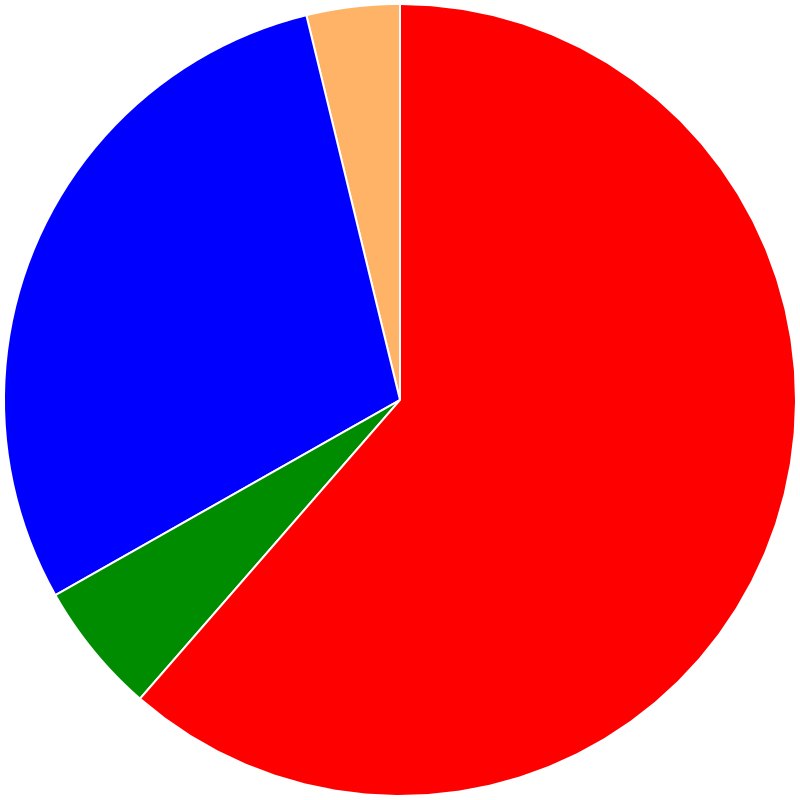

In [16]:

FIG = Figure(size=(400, 400), figure_padding = 0)

ax = plot_settings( FIG[1,1],
                ylabel = " ",
                xlabel =  " ",
                title = "", titlesize=30, xticklabelsvisible=false, yticklabelsvisible=false,
                xticks=[NaN], yticks = [NaN])


colorhatch(color; pattern = :backslash) = make_hatch_pattern(size = 900, spacing=5, thickness=1,
            style=pattern, line_color=RGBAf(1,1,1,1),
            bg_color= color)



Smartt2009 =  Dict(
    "II"      =>       58.7+2.7,
    "IIb"     =>       5.4,
    "IIn"     =>       3.8,
    "Ibc"     =>    19.6+9.8,
    "SLSN-I" => 0,
    "SLSN-II" => 0,
    "87A"=>0,
    "Ic-BL"=>0,
    "Ibn"=>0
)


Perley2020_ZTF = OrderedDict(
    "IIn"     => 0.722 * 0.142 * 100,
    "SLSN-II" => 0.722 * 0.035 * 100,
    "Ibn"     => 0.278 * 0.092/0.999 * 100,
    "SLSN-I"  => 0.278 * 0.126/0.999 * 100,
    "Ic-BL"   => 0.278 * 0.195/0.999 * 100,
    "Ibc"     => 0.278 * 0.586/0.999 * 100,
    "IIb"     => 0.722 * 0.066 * 100, 
    "II"     => 0.722 * 0.757 * 100,
    "87A"    => 0 
)

Schulze2021_PTF = Dict(
    "II"      =>        498/888*100,
    "IIb"     =>         61/888*100,
    "IIn"     =>        111/888*100,
    "SLSN-II" => (16+ 1+ 1)/888*100,
    "Ibc"     => (46+12+60)/888*100,
    "Ic-BL"   =>         36/888*100,
    "Ibn"     =>          9/888*100,
    "SLSN-I"  =>         37/888*100,
    "87A"     => 0.
)

Graur2017_LOSS_lowmassGal = Dict(
    "II"    => 60.3,
    "IIn"    =>  7.4,
    "87A" =>  7.8,
    "IIb"    => 11.3 + 1.5,
    "Ibc"    => 6.6 + 3.2,
    "Ic-BL"  => 1.0
)
Graur2017_LOSS_highmassGal = Dict(
    "II"     => 57.1,
    "IIn"    =>  2.8,
    "IIb"    => 10.8,
    "Ibc"    => 21.5 + 1.4 + 3.4,
    "Ic-BL"  =>  2.1
)

Li_II_f = 0.689
Li_I_f = 0.311
Li2011_LOSS = Dict(
    "Ibc"    => Li_I_f * (16.1+12.4+41.1+2.8),
    "IIb"    => Li_I_f * (27.6),
    "II"     => Li_II_f* (93.2),
    "IIn"    => Li_II_f* (6.8),
    "87A" => 0,
    "SLSN-I" => 0,
    "SLSN-II" => 0,
    "Ibn" => 0,
    "Ic-BL" => 0
)



Shivvers_II_f = 0.696
Shivvers_I_f  = 0.304
Shivvers2017_LOSS = Dict(
    "Ibc"    => Shivvers_I_f * (35.6+21.5+3.2),
    "Ic-BL"  => Shivvers_I_f * (3.7),
    "IIb"    => Shivvers_I_f * (34.0+2.0),
    "II"     => Shivvers_II_f * (89.1),
    "87A"    => Shivvers_II_f * (4.2),
    "IIn"    => Shivvers_II_f * (6.7)
)


Ma25_II = 53.3/(53.3+16.3)
Ma25_Ibc= 1 - Ma25_II
Ma25_mixed = Dict(
    "IIn"    =>Ma25_II  * ( 7.4), 
    "II"    => Ma25_II  * (68.5+ 8.5+ 0.8),
    "IIb"    => Ma25_II  * (12.5),
    "87A"  => Ma25_II  * ( 2.3),
    "Ibc"    => Ma25_Ibc * (20.6+39.0+13.5),
    "Ic-BL"  => Ma25_Ibc * (18.0),
    "Ibn"  => Ma25_Ibc * ( 8.8),
    "SLSN-I" => 0,
    "SLSN-II" => 0,
    
)



alpha = 1
color_coding = Dict() 
color_coding["IIP"]     = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]     = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]     = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]    = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"]      = RGBAf(.15, .15, .15 ,alpha) 

color_coding["II"]      = color_coding["IIP"]  
color_coding["87A"]     = color_coding["IIP-B"]
color_coding["Ic-BL"]   = Pattern(make_hatch_pattern(size = 80, spacing=6, thickness=1,
                                    style=:dotted, line_color=RGBAf(0,0,0,0),
                                    bg_color= color_coding["Ibc"] ))
color_coding["SLSN-I"]  = Pattern(colorhatch(color_coding["Ibc"], pattern = :dotted))
color_coding["IIn"]     = color_coding["II-i"]
color_coding["SLSN-II"] = Pattern(make_hatch_pattern(size = 80, spacing=6, thickness=1,
                                    style=:dotted, line_color=RGBAf(0,0,0,0),
                                    bg_color= color_coding["II-i"] ))
color_coding["Ibn"]     = color_coding["Ibc-i"]


SNtype_seq = ["II", "87A", "IIb", "Ibc", "Ic-BL", "SLSN-I", "Ibn", "IIn",  "SLSN-II"]
what_data =Smartt2009
data = [what_data[sn] for sn in SNtype_seq]
colors = [color_coding[sn] for sn in SNtype_seq]


hatched_pie!(ax, reverse!(data),
         colors=reverse!(colors), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1, strokecolor=:white)
for sn in SNtype_seq
    @printf("%8s: %4.1f\n", sn, what_data[sn])
end

ax.rightspinevisible = false
ax.topspinevisible = false
ax.leftspinevisible = false
ax.bottomspinevisible = false
xlims!(ax, -1.01, 1.01)
ylims!(ax, -1.01, 1.01)
resize_to_layout!(FIG)

FIG 

save("Pie_obs.pdf", FIG)


FIG

# comparisons 


## different EXPLOSION

In [12]:
include(include_dir*"SN_reader_MW.jl")

MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
SN_DATA_multi= Dict()
for EXP_CRIT in ["X", "MM-S21", "Ertl-N20_new", "PS20"]
    KICKS = Inf
    f_B = 0.75
    #make sure MODELS is loaded, from SN_popsynth
    #MODELS = predict_SN_from_each_model(MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS; logPs = range(0.15, 3.70, step=0.05))

    MODELS = predict_SN_from_each_model(
        MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS, EXP_CRIT, KICKS)
    @printf("loading models...")
    logPs = range(0.05, 3.70, step=0.05)

    @printf("performing popsynth...\n")
    MODELS, SINGLES, total_SNe = do_SN_popsynth(MERGER_CRITERION, MERGER_EOL, MERGER_MASSLOSS, EXP_CRIT, alpha_m, 0, 0, :custom, f_B, MODELS=MODELS, WRITE_TO_FILE=false)


    MODELS, SN_DATA, binary_BHs_n =  reorganize_SN_data(MODELS, f_B, EXP_CRIT, total_SNe)

    SN_DATA_multi[EXP_CRIT] = copy(SN_DATA)
end


Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Reading & cleaning single-star CORR files...done!
Building Case BC interpolator (PythonCall)...done
Building merger Mi +f_acc -> Mco, BSG interpolators: Retrieving data ...building interpolators...done!
Building merger/partial stripped outcome -> core He dep. Retrieving data ...Building interpolation library...done!
Building Explosion criteria......PS20...M16-E16 - imported CC grids, explodability files and interpolants
Scanning logMs
2.00 
will_it_explode reported  497 Warnings
loading models...performing popsynth...
     which |     IIP   IIP-B     IIb     Ibc    II-i   Ibc-i (     BH)
         1 |    4.29    0.00    1.21   19.95    2.04    2.54 (   0.00) |   30.03
         2 |   16.07    0.00    1.04    2.29    0.02    0.00 (   0.00) |   19.42
         M |   23.63    0.35    1.66    4.31    0.14    0.00 (   0.00) |   30.09
         S |   15.78    0.00    1.16    3.53    0.00    0.00 (   0.00) |   20.46
     

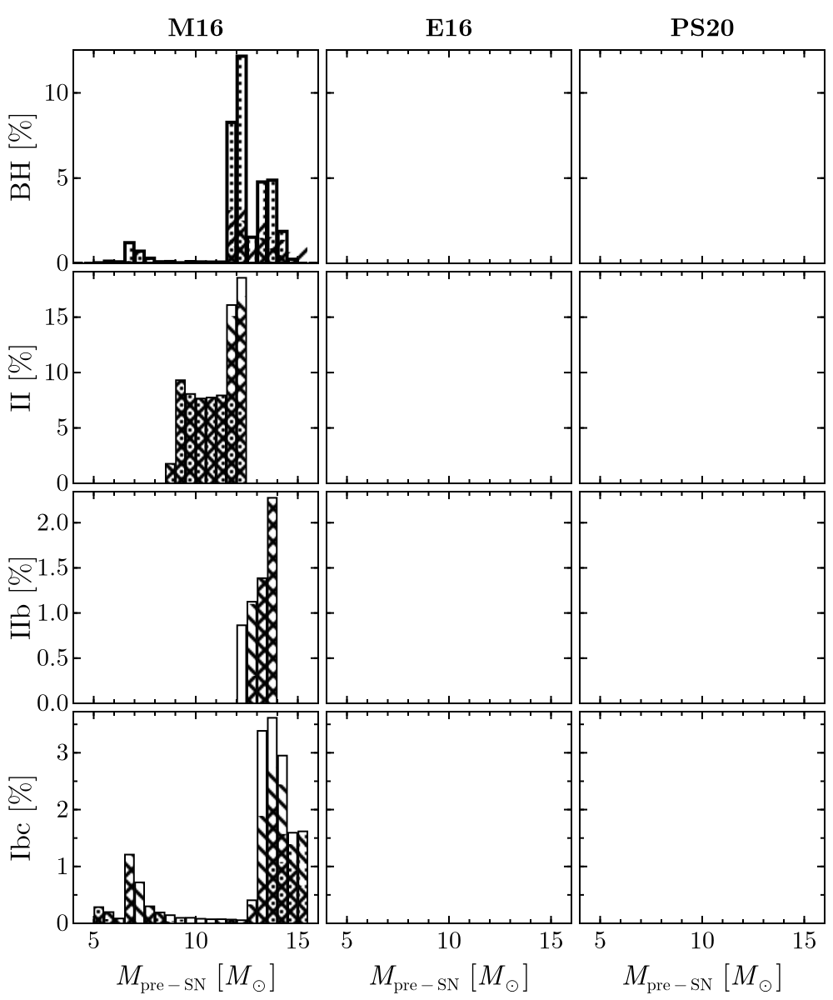

In [ ]:
FIG = Figure(size=(500, 600),  figure_padding = 5)
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

ymticks = 0:0.5:100
ymticks_II = 0:5:100

d1 = 0.5
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1=[4,16]


yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, 
                    ylabel="", xlabel="",title="", titlesize = 15) = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_lab_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks, titlesize=titlesize)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II, title = "M16")
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]


ax3["BH"]  = plot_settings_defauls(grid[1,3];ymticks=ymticks_II, title = "PS20")
ax3["IIP"] = plot_settings_defauls(grid[2,3];ymticks=ymticks_II)
ax3["IIb"] = plot_settings_defauls(grid[3,3];ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)

ax2["BH"] =  plot_settings_defauls(grid[1,2];ymticks=ymticks_II, title = "E16")
ax2["IIP"] = plot_settings_defauls(grid[2,2];ymticks=ymticks_II)
ax2["IIb"] = plot_settings_defauls(grid[3,2];ymticks=ymticks)
ax2["Ibc"] = plot_settings_defauls(grid[4,2];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)
xspace = maximum(tight_xticklabel_spacing!, [ax1["Ibc"], ax3["Ibc"], ax2["Ibc"]])
[ax.xticklabelspace = xspace for ax in [ax1["Ibc"], ax3["Ibc"], ax2["Ibc"]]]

                

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 

sntypes = ["IIP",  "IIb", "Ibc"]
outcomes = ["IIP",  "IIb", "Ibc", "BH"]

                     

function quantile_sndata(q, what, prg, ttp; database = SN_DATA_multi["X"], unit = 1)
    vals =     [database[what][prg][ix]/unit for ix in get_idx(prg, ttp; database=database)]
    pdfs = Weights([database["pdf"][prg][ix] for ix in get_idx(prg,ttp; database=database)])
    return quantile(vals, pdfs, q)
end 

function run_histogram(ax, prg, ttp, what, bins, width;  database = SN_DATA_multi["X"],  datascale = identity, color = color, strokecolor = :black, strokewidth=1)
    length(get_idx(prg, ttp; database=database )) == 0 && return 0

    pdf_this = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=database)]) for type in sntypes] )
    pdf_norm = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=SN_DATA_multi["X"])]) for type in sntypes] ) * database["tot_SNe"]
    pdf=    sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=SN_DATA_multi["X"])]) for type in outcomes] )
    data = datascale.(database[what][prg][get_idx(prg,ttp; database=database)])
    dataweights = weights(database["pdf"][prg][get_idx(prg,ttp; database=database)]/pdf*100)

    x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 


    barplot!(ax, x_bar , 
                        y_bar, 
                        color =  color ,
                        strokewidth = strokewidth,
                        width=width*1.1,
                        strokecolor = strokecolor )
    return maximum(hist1.weights)
end 

max_ttp = Dict() 



prg = "S"
for ttp in ttps

    hatcher1 = make_hatch_pattern(size=100, spacing=10,  thickness=1, style=:backslash, line_color=RGBAf(0,0,0,1), bg_color=RGBAf(0,0,0,0))
    hatcher2 = make_hatch_pattern(size=100, spacing=10,  thickness=1, style=:slash    , line_color=RGBAf(0,0,0,1), bg_color=RGBAf(0,0,0,0))
    hatcher3 = make_hatch_pattern(size=100, spacing=5,   thickness=1, style=:dotted, line_color=RGBAf(0,0,0,1), bg_color=RGBAf(0,0,0,0))
    color1 = Pattern(hatcher1)
    color2 = Pattern(hatcher2)
    color3 = Pattern(hatcher3)

    if ttp != "BH"

        tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor = RGBAf(0,0,0,0), color = color1, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor = RGBAf(0,0,0,0), color = color2, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor = RGBAf(0,0,0,0), color = color3, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        # tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:cyan,    1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        # tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:magenta, 1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        # tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:yellow,  1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        tmp_max0 = run_histogram(ax1[ttp], prg, ttp, strokecolor =:black, color = RGBAf(0,0,0,0), what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
        max_ttp[ttp] = maximum([tmp_max0, tmp_max1, tmp_max2, tmp_max3])
    else
        tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor = RGBAf(0,0,0,0), color = color1, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor = RGBAf(0,0,0,0), color = color2, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor = :black, color = color3, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        tmp_max0 = run_histogram(ax1[ttp], prg, ttp, strokecolor = color_coding[ttp], color = RGBAf(0,0,0,0), what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
        max_ttp[ttp] = maximum([tmp_max0, tmp_max1, tmp_max2, tmp_max3])

    end
    # tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
    # max_ax = max(max_ax, tmp_max)
    # tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
    # max_ax = max(max_ax, tmp_max)

    # ranges = report_stats(SN_DATA_multi["MM-S21"], what_to_plot, prg, ttp,  color = color_coding[ttp], print2screen = true, newline = true; unit = (1, ""), format_str = "%4.1f")
    # for range in ranges
    #     errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
    #     scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
    #     text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
    #     text!(ax1[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
    #         fontsize=13, color=:black)#:red)
    # end 

end



for ttp in ["IIP", "IIb", "Ibc", "BH"]
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
    xlims!(ax3[ttp], limits1[1], limits1[2])
    ylims!(ax3[ttp], 0, max_ttp[ttp]*bf)
    xlims!(ax2[ttp], limits1[1], limits1[2])
    ylims!(ax2[ttp], 0, max_ttp[ttp]*bf)
end 





    

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_type_compare_%s_%s.pdf", prg, MERGER_CRITERION)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



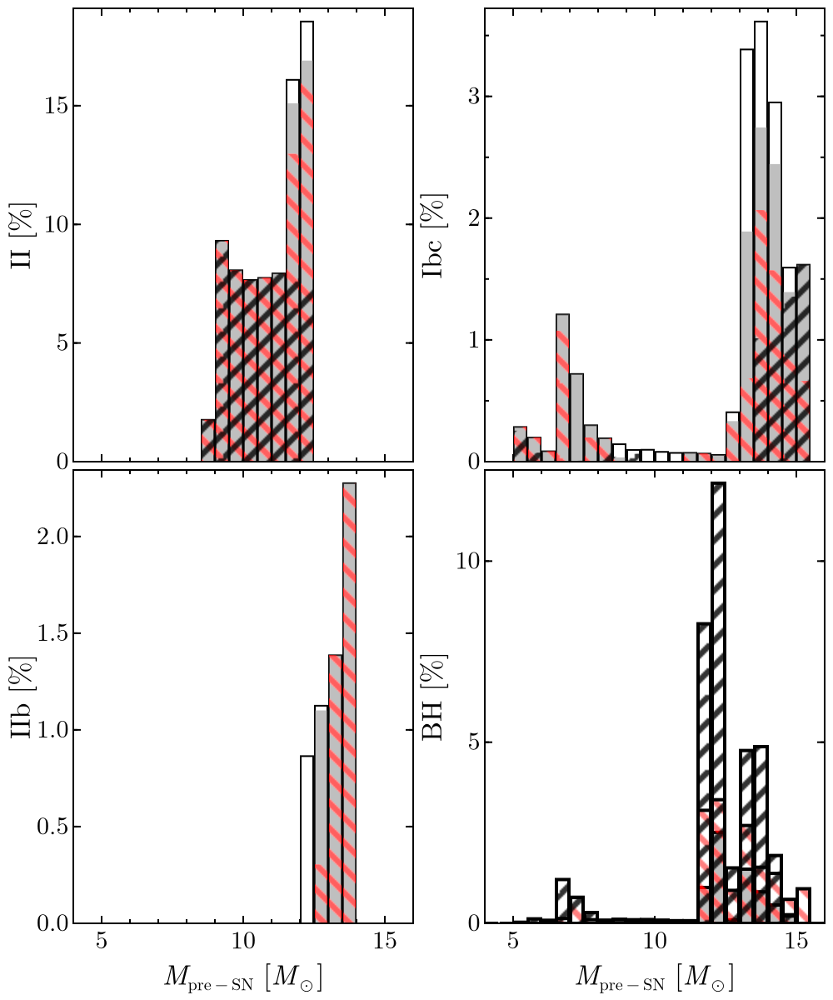

In [116]:
FIG = Figure(size=(500, 600),  figure_padding = 5)
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

ymticks = 0:0.5:100
ymticks_II = 0:5:100

d1 = 0.5
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1=[4,16]


yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, 
                    ylabel="", xlabel="",title="", titlesize = 15) = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_lab_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks, titlesize=titlesize)

ax1["BH"] = plot_settings_defauls(grid[2,2];
                xticks= (xticks,xticks_t),
                ylabel = "BH [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II, title = " ",
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
)
ax1["IIP"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II)
ax1["IIb"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[1,2];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]


                

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 

sntypes = ["IIP",  "IIb", "Ibc"]
outcomes = ["IIP",  "IIb", "Ibc", "BH"]

                     

function quantile_sndata(q, what, prg, ttp; database = SN_DATA_multi["X"], unit = 1)
    vals =     [database[what][prg][ix]/unit for ix in get_idx(prg, ttp; database=database)]
    pdfs = Weights([database["pdf"][prg][ix] for ix in get_idx(prg,ttp; database=database)])
    return quantile(vals, pdfs, q)
end 

function run_histogram(ax, prg, ttp, what, bins, width;  database = SN_DATA_multi["X"],  datascale = identity, color = color, strokecolor = :black, strokewidth=1)
    length(get_idx(prg, ttp; database=database )) == 0 && return 0

    pdf_this = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=database)]) for type in sntypes] )
    pdf_norm = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=SN_DATA_multi["X"])]) for type in sntypes] ) * database["tot_SNe"]
    pdf=    sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=SN_DATA_multi["X"])]) for type in outcomes] )
    data = datascale.(database[what][prg][get_idx(prg,ttp; database=database)])
    dataweights = weights(database["pdf"][prg][get_idx(prg,ttp; database=database)]/pdf*100)

    x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 


    barplot!(ax, x_bar , 
                        y_bar, 
                        color =  color ,
                        strokewidth = strokewidth,
                        width=width*1.1,
                        strokecolor = strokecolor )
    return maximum(hist1.weights)
end 

max_ttp = Dict() 



prg = "S"
for ttp in ttps

    hatcher1 = make_hatch_pattern(size=45, spacing=15,  thickness=2, style=:backslash, line_color=RGBAf(1,0,0,0.5), bg_color=RGBAf(0,0,0,0))
    hatcher2 = make_hatch_pattern(size=45, spacing=15,  thickness=2, style=:slash    , line_color=RGBAf(0,0,0,0.8), bg_color=RGBAf(0,0,0,0))
    hatcher3 = make_hatch_pattern(size=100, spacing=8,  thickness=2, style=:dotted,    line_color=RGBAf(0,0,0,1), bg_color=RGBAf(0,0,0,0))
    color1 = Pattern(hatcher1)
    color2 = Pattern(hatcher2)
    color3 = (:gray, .5) #Pattern(hatcher3)

    if ttp != "BH"

        tmp_max0 = run_histogram(ax1[ttp], prg, ttp, strokecolor =:black, color = :white, what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
        tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor =RGBAf(0,0,0,0), color = color3, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor =RGBAf(0,0,0,0), color = color1, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor =RGBAf(0,0,0,0), color = color2, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        # tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:cyan,    1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        # tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:magenta, 1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        # tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor = (:yellow,  1), color = RGBAf(0,0,0,0), strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        max_ttp[ttp] = maximum([tmp_max0, tmp_max1, tmp_max2, tmp_max3])
    else
        tmp_max1 = run_histogram(ax1[ttp], prg, ttp, strokecolor =:black, color = color3, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["MM-S21"])
        tmp_max2 = run_histogram(ax1[ttp], prg, ttp, strokecolor =RGBAf(0,0,0,1), color = color1, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["Ertl-N20_new"])
        tmp_max3 = run_histogram(ax1[ttp], prg, ttp, strokecolor =RGBAf(0,0,0,1), color = color2, strokewidth=2,  what_to_plot, bins1, d1; database = SN_DATA_multi["PS20"])
        max_ttp[ttp] = maximum([ tmp_max1, tmp_max2, tmp_max3])

    end
    # tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
    # max_ax = max(max_ax, tmp_max)
    # tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"])
    # max_ax = max(max_ax, tmp_max)

    # ranges = report_stats(SN_DATA_multi["MM-S21"], what_to_plot, prg, ttp,  color = color_coding[ttp], print2screen = true, newline = true; unit = (1, ""), format_str = "%4.1f")
    # for range in ranges
    #     errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
    #     scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
    #     text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
    #     text!(ax1[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
    #         fontsize=13, color=:black)#:red)
    # end 

end



for ttp in ["IIP", "IIb", "Ibc", "BH"]
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
end 





    

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_type_compare_%s_%s.pdf", prg, MERGER_CRITERION)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



In [ ]:
progenitors = ["1-MT", "2-MT", "M", "S"]



for exp_crit in ["X", "MM-S21", "Ertl-N20_new", "PS20"]
   
    for ttp in ["BH"]
        SN_DATA = SN_DATA_multi[exp_crit]
        
        pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp, database=SN_DATA)])
        pdf_tot < 0.0001 && continue 


        for prg in ["S"]
            sub_pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp, database=SN_DATA)])
            pdf_prg = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, ttp, database=SN_DATA)])  for ttp in ["IIP", "IIb", "Ibc", "BH"] ] ) 
            sub_pdf < 0.0001 && continue 

            @printf("%7s (%s) -> %5.2f (in %s: %5.2f)\n", ttp, prg, sub_pdf*100, prg, sub_pdf/pdf_prg*100)

            report_stats(SN_DATA, "N_DATA, "Mf",    prg, ttp,print2screen = true, newline = false, unit = (1, "Msun"),  
                            multip1_threshold= [8], n_peaks=2, database=SN_DATA) 
            # weighted_quantile_gap_method("Mf",    prg, ttp; database=SN_DATA)
            
        end
        @printf("\n\n%7s     -> %5.2f\n", ttp,  pdf_tot*100)

        report_stats(SN_DATA, "Mf",    "tot", ttp, print2screen = true,newline=false, unit = (1, "Msun"),  
                        multip_percentiles=0:10:100,multip1_threshold=[18], database=SN_DATA) 

        print("\n")
    end
    print("\n\n\n")
end




     BH (S) ->  1.56 (in S:  7.12)
   Mf -  8.6<12.6[+ 1.6- 2.3]<14.6 [ Msun]- Having chosen [8] quantile as the threshold for the multipeak, here are the statistics
   Mf -  8.6<10.1[+ 1.8- 1.4]<11.9 [ Msun]- 
   Mf - 11.9<12.9[+ 1.6- 0.9]<14.6 [ Msun]- 


     BH     ->  6.98
   Mf -  5.2<12.7[+ 7.2- 5.2]<42.8 [ Msun]- 



     BH (S) ->  3.82 (in S: 16.09)
   Mf -  6.9<12.6[+ 2.6- 5.1]<15.2 [ Msun]- Having chosen [8] quantile as the threshold for the multipeak, here are the statistics
   Mf -  6.9< 7.8[+ 2.1- 0.8]<10.2 [ Msun]- 
   Mf - 10.2<13.0[+ 2.2- 1.1]<15.2 [ Msun]- 


     BH     -> 15.71
   Mf -  5.0<12.4[+ 4.8- 5.4]<55.4 [ Msun]- 



     BH (S) -> 11.62 (in S: 36.71)
   Mf -  5.4<12.3[+ 1.8- 5.1]<14.6 [ Msun]- Having chosen [8] quantile as the threshold for the multipeak, here are the statistics
   Mf -  5.4< 7.4[+ 2.7- 1.4]<11.0 [ Msun]- 
   Mf - 11.1<12.7[+ 1.4- 0.7]<14.6 [ Msun]- 


     BH     -> 53.13
   Mf -  4.2<11.6[+ 4.9- 6.1]<55.4 [ Msun]- 





## different MERGER

In [ ]:
include(include_dir*"SN_reader_MW.jl")

MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
EXP_CRIT = "X"
SN_DATA_multi= Dict()
MODELS_multi = Dict()
for MERGER_CRITERION in ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
    KICKS = Inf
    f_B = 0.75
    #make sure MODELS is loaded, from SN_popsynth
    #MODELS = predict_SN_from_each_model(MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS; logPs = range(0.15, 3.70, step=0.05))

    MODELS = predict_SN_from_each_model(
        MERGER_CRITERION,MERGER_EOL,MERGER_MASSLOSS, EXP_CRIT, KICKS)
    @printf("loading models...")
    logPs = range(0.05, 3.70, step=0.05)

    @printf("performing popsynth...\n")
    MODELS, SINGLES, total_SNe = do_SN_popsynth(MERGER_CRITERION, MERGER_EOL, MERGER_MASSLOSS, EXP_CRIT, alpha_m, 0, 0, :custom, f_B, MODELS=MODELS, WRITE_TO_FILE=false)



    seeker = []
    n_mergers = 0
    p_mergers = 0

    for logM in keys(MODELS)
        for logP in keys(MODELS["1.10"]) 
            for q in keys(MODELS["1.10"]["1.00"])
                try 
                    MODELS[logM][logP][q]["pdf"]
                catch e 
                    # @printf("%s/%s/%s removed\n", logM, logP, q)
                    delete!(MODELS[logM][logP], q)
                    continue 
                end  
                push!(seeker, Dict("logM"=>logM, "logP"=>logP, "q"=>q))

                if (occursin(MODELS[logM][logP][q]["case"], "mer") || occursin(MODELS[logM][logP][q]["case"], "IMT"))
                    n_mergers += 1
                    p_mergers += MODELS[logM][logP][q]["pdf"]["tot"]/0.75
                end

            end
            
            (length(MODELS[logM][logP]) == 0) && (delete!(MODELS[logM], logP))

        end
    end
    @printf("%s   -   %d   %5.2f%%\n", MERGER_CRITERION, n_mergers, p_mergers * 100)

    MODELS_multi[MERGER_CRITERION] = copy(MODELS)

    f_single = CSV.read(SG_dir*"CORR_GRID_single_150.dat", 
                        header=1, DataFrame,delim=' ',ignorerepeated=true)
    deleteat!(f_single, findall( !>(0) , f_single.M_he_core_end_BURN_He) )


    f_S = 1-f_B
    Salpeter_IMF(x;  power=alpha_m) = x ^ (power)

    function integrate_logM(logMmin, logMmax)
        m_min = 10 .^ logMmin
        m_max = 10 .^ logMmax
        return quadgk(m -> Salpeter_IMF(m),  m_min, m_max, rtol=1e-9)
    end 
    delta =0.050/2
    sdelta = 0.020/2
    logms=0.70:sdelta*2:2.00
    integral_logM, _ = integrate_logM( 0.70-delta, 2.00+delta )
    dump = 0

    sdelta = 0.0001
    SINGLES = SortedDict()
    for logm in 0.70-delta:sdelta:2.00+delta
        f_S <= 0 && continue
        logm_t = @sprintf("%.5f", logm)
        SINGLES[logm_t] = Dict()

        m = 10 ^ logm
        logm_min = max(0.70-delta, logm-sdelta/2)
        logm_max = min(2.00+delta, logm+sdelta/2)

        SINGLES[logm_t] = Dict()

        SINGLES[logm_t]["SN"]=Dict("WD" =>0., "IIP" =>0., "IIb" =>0., "IIP-B"=>0., 
        "Ibc"=>0., "BH" =>0., "II-i" =>0., "Ibc-i" =>0., "X"=>0.)

        endvals = SN_OUTPUT_manual(SINGLES[logm_t]["SN"], interpol_single_Mmax["M_end"](m),
                                                interpol_single_Mmax["M_hecore_end"](m), 
                                                interpol_single_Mmax["M_cocore_end"](m), 
                                                m,
                                                interpol_single_Mmax["M_env_end"](m),
                                                interpol_single_Mmax["X_C"](m),
                                                "end",
                                                EXP_CRIT)
        counter = 0
        pdf = integrate_logM(logm_min, logm_max)[1] / integral_logM * f_S 
        SINGLES[logm_t]["pdf"]  = Dict("tot"=>pdf)
        SINGLES[logm_t]["t_SN"] = f_age_CB(m)
        SINGLES[logm_t]["Mend"] = interpol_single_Mmax["M_end"](m)
        SINGLES[logm_t]["Mmax"] = m
        SINGLES[logm_t]["endvals"] = endvals
        SINGLES[logm_t]["mod"] = NaN
        SINGLES[logm_t]["case"] = "single"

    end

    counter = 0 
    counterM = 0 
    counterP = 0 
    counterq = 0 

    quantities_to_collect  = ["t", "Mf", "MM", "pdf", "Mi", "E_exp", 
                            "M_rem", "M_ni", "Type", "dM_C", "M_rem_b", "orbSN1",
                            "model_n", "case", "Mej"]
    progenitors_to_collect = ["tot", "1", "2", "M", "S", "1-MT", "2-MT", "1-NI", "2-NI", "S+NI"]
    SN_DATA =     Dict()
    for qt in quantities_to_collect
        SN_DATA[qt] = Dict()
        for prg in progenitors_to_collect 
            SN_DATA[qt][prg] = qt in ["Type", "case"] ? [] : Float64[] 
        end
    end




    counter = 0
    counter2 = 0
    counter3 = 0

    function find_entry(SN)
        for key in keys(SN)
            if SN[key] > 0
                return key
            end
        end
        throw(ErrorException("All entries are 0!!!"))
    end


    function pusher(SN_DATA,  prg, whichSN, mod, logM, q, logP)

        push!( SN_DATA["t"][prg],        mod["t_SN"*whichSN])

        mod_n = mod["mod"]
        
        push!( SN_DATA["model_n"][prg],  mod_n)
        # push!( SN_DATA["orbSN1"][prg],  mod["orbSN1"])
        push!( SN_DATA["case"][prg],   mod["case"])
        push!( SN_DATA["Type"][prg],  find_entry(mod["SN"*whichSN]))
        push!( SN_DATA["Mf"][prg],    mod["M"*whichSN*"end"] )
        push!( SN_DATA["MM"][prg],    mod["M"*whichSN*"max"] )
        push!( SN_DATA["dM_C"][prg],  occursin("1", prg) ? mod["dM_C"] : NaN  )
        push!( SN_DATA["pdf"][prg],   mod["pdf"]["tot"]/total_SNe)
        push!( SN_DATA["E_exp"][prg], mod["endvals"*whichSN].E_exp )
        push!( SN_DATA["M_rem"][prg], mod["endvals"*whichSN].M_remnant_g )
        push!( SN_DATA["M_rem_b"][prg], mod["endvals"*whichSN].M_remnant_b )
        push!( SN_DATA["M_ni"][prg], mod["endvals"*whichSN].M_ni )
        push!( SN_DATA["Mej"][prg], mod["M"*whichSN*"end"] -mod["endvals"*whichSN].M_remnant_b )


        if prg != "2"
            push!( SN_DATA["Mi"][prg], 10. ^ logM)
        else 
            push!( SN_DATA["Mi"][prg], 10. ^ logM * q)
        end
    end 


    for ix in seeker
        mod = MODELS[ix["logM"]][ix["logP"]][ix["q"]]
        logM = parse(Float64, ix["logM"])
        q = parse(Float64, ix["q"])
        logP = parse(Float64, ix["logP"])
        RLOF = length(mod["case"]) > 0 || length(mod["case_postSN"])>0

        if mod["first"] == "M" && ! (mod["SN1"]["X"]+mod["SN1"]["WD"]>0)
            pusher(SN_DATA, "M",   "1", mod, logM, q, logP)
            pusher(SN_DATA, "tot", "1", mod, logM, q, logP)
        else
            firstSN = mod["first"]
            primary   = (firstSN == "1") ? "1" : "2"
            secondary = (firstSN == "1") ? "2" : "1"

            if ! (mod["SN"*primary]["X"]+mod["SN"*primary]["WD"]>0)
                pusher(SN_DATA, "1", primary, mod, logM, q, logP)
                pusher(SN_DATA, "tot", primary, mod, logM, q, logP)
                if RLOF
                    pusher(SN_DATA, "1-MT", primary, mod, logM, q, logP)
                else
                    pusher(SN_DATA, "1-NI", primary, mod, logM, q, logP)
                    pusher(SN_DATA, "S+NI", primary, mod, logM, q, logP)
                end
            end 

            if ! (mod["SN"*secondary]["X"]+mod["SN"*secondary]["WD"]>0)
                pusher(SN_DATA, "2",   secondary, mod, logM, q, logP)
                pusher(SN_DATA, "tot", secondary, mod, logM, q, logP)
                if RLOF
                    pusher(SN_DATA, "2-MT", secondary, mod, logM, q, logP)
                else
                    pusher(SN_DATA, "2-NI", secondary, mod, logM, q, logP)
                    pusher(SN_DATA, "S+NI", secondary, mod, logM, q, logP)
                end
            end 
            
        end
    end


    for logm in keys(SINGLES)
        mod = SINGLES[logm]
        logM = parse(Float64 ,logm)
        (mod["SN"]["X"]+mod["SN"]["WD"]) * (mod["SN"]["IIP"]+mod["SN"]["IIP-B"]+mod["SN"]["Ibc"]+mod["SN"]["Ibc-i"]+mod["SN"]["II-i"]) > 0 && @printf("NOO - %d\n", logm)
        (mod["SN"]["X"]+mod["SN"]["WD"]>0) && continue
        if isnan(mod["Mend"])
            counter2 += 1 
            throw(ErrorException("why is this nan?"))
        end

        pusher(SN_DATA, "S",    "", mod, logM, 1, NaN)
        pusher(SN_DATA, "S+NI", "", mod, logM, 1, NaN)
        pusher(SN_DATA, "tot",  "", mod, logM, 1, NaN)

    end 

    SN_DATA["tot_SN"] = total_SNe
    total_SNe2 = sum(SN_DATA["pdf"]["tot"])*100
    @printf("prg %6s %6s %6s %6s %6s %6s :%6s |%6s\n", "IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH", "Total")
    for prg in ["1", "2", "M", "S"]
        @printf("%4s %6.2f %6.2f %6.2f %6.2f %6.2f %6.2f :%6.2f | %6.2f\n", prg,
        sum(SN_DATA["pdf"][prg][get_idx(prg,"IIP")])*100,  sum(SN_DATA["pdf"][prg][get_idx(prg,"IIP-B")])*100, 
        sum(SN_DATA["pdf"][prg][get_idx(prg,"IIb")])*100,  sum(SN_DATA["pdf"][prg][get_idx(prg,"Ibc")])*100,
        sum(SN_DATA["pdf"][prg][get_idx(prg,"II-i")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg,"Ibc-i")])*100, 
        sum(SN_DATA["pdf"][prg][get_idx(prg,"BH")])*100,  100*sum(SN_DATA["pdf"][prg])-sum(SN_DATA["pdf"][prg][get_idx(prg,"BH")])*100)
    end
    @printf("Placing non-interacting systems inside single-stars.\n")
    for prg in ["1-MT", "2-MT", "M", "S+NI"]
        @printf("%4s %6.2f %6.2f %6.2f %6.2f %6.2f %6.2f :%6.2f | %6.2f\n", prg,
        sum(SN_DATA["pdf"][prg][get_idx(prg,"IIP")])*100,  sum(SN_DATA["pdf"][prg][get_idx(prg,"IIP-B")])*100, 
        sum(SN_DATA["pdf"][prg][get_idx(prg,"IIb")])*100,  sum(SN_DATA["pdf"][prg][get_idx(prg,"Ibc")])*100,
        sum(SN_DATA["pdf"][prg][get_idx(prg,"II-i")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg,"Ibc-i")])*100, 
        sum(SN_DATA["pdf"][prg][get_idx(prg,"BH")])*100,  100*sum(SN_DATA["pdf"][prg])-sum(SN_DATA["pdf"][prg][get_idx(prg,"BH")])*100)
    end

    #      which |     IIP   IIP-B     IIb     Ibc    II-i   Ibc-i (     BH)
    #          1 |    4.54    0.00    1.18   19.70    2.16    2.69 (   1.53) |   30.27
    #          2 |   15.98    0.00    0.80    2.78    0.05    0.00 (   0.84) |   19.60
    #          M |   24.22    0.32    1.23    3.82    0.14    0.00 (   2.13) |   29.74
    #          S |   16.36    0.00    1.03    3.01    0.00    0.00 (   1.28) |   20.39
    #      TOTAL |   61.10    0.32    4.24   29.30    2.35    2.69 (   5.78)
    # prg    IIP  IIP-B    IIb    Ibc   II-i  Ibc-i :    BH | Total
    #    1   4.54   0.00   1.18  19.70   2.16   2.69 :  1.53 |  30.27
    #    2  15.98   0.00   0.80   2.78   0.05   0.00 :  0.84 |  19.60
    #    M  24.22   0.32   1.23   3.82   0.14   0.00 :  2.13 |  29.74
    #    S  16.36   0.00   1.03   3.01   0.00   0.00 :  1.28 |  20.39
    # Placing non-interacting systems inside single-stars.
    # 1-MT   0.10   0.00   1.09  16.79   2.16   2.69 :  1.39 |  22.84
    # 2-MT  14.22   0.00   0.58   1.53   0.05   0.00 :  0.47 |  16.37
    #    M  24.22   0.32   1.23   3.82   0.14   0.00 :  2.13 |  29.74
    # S+NI  22.55   0.00   1.34   7.17   0.00   0.00 :  1.79 |  31.06
    SN_DATA_multi[MERGER_CRITERION] = copy(SN_DATA)
end


Including Packages... Data IO ...Printf and Debugger...Calculations...done!
Reading & cleaning single-star CORR files...done!
Building Case BC interpolator (PythonCall)...done
Building merger Mi +f_acc -> Mco, BSG interpolators: Retrieving data ...building interpolators...done!
Building merger/partial stripped outcome -> core He dep. Retrieving data ...Building interpolation library...done!
Building Explosion criteria......PS20...M16-E16 - imported CC grids, explodability files and interpolants
Scanning logMs


In [ ]:
for merger_crit in keys(MODELS_multi)
    n_mergers = 0
    n_tot = 0
    p_mergers = 0
    for logM in keys(MODELS_multi[merger_crit])
        for logP in keys(MODELS_multi[merger_crit]["1.10"]) 
            for q in keys(MODELS_multi[merger_crit]["1.10"]["1.00"])             
                
                model = MODELS_multi[merger_crit][logM][logP][q]
                n_tot += 1
                ! (occursin("mer", model["casus"]) || occursin("IMT", model["casus"])) && continue 

                n_mergers += 1
                p_mergers += model["pdf"]["tot"]/0.75
            
            end
        end
    end

    @printf("%8s   -   %5.2f%%   %5.2f%%\n", merger_crit, n_mergers/n_tot*100, p_mergers * 100)
end


In [ ]:
progenitors = ["1-MT", "2-MT", "M", "S"]



variable = "Mf"
variable_storage = Dict() 

filename = "output/averages_vars.data"
isfile(filename) ? i=1 : i=0 
fp = open(filename, "a")
if i==0
    write(fp, @sprintf("%10s %10s %10s", "MER_CRIT", "EXP_CRIT", "variable")  )
    for ttp in ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
        write(fp, @sprintf("%10s %10s %10s", ttp, ttp*"(+)", ttp*"(-)")  )
    end
    write(fp, "\n")
end 


for mer_crit in ["X", "ERK", "PA_IV", "PAULI", "PABLO", "ALL"]
    variable_storage[mer_crit] = Dict()

    write(fp, @sprintf("%10s %10s %10s", mer_crit, EXP_CRIT, variable)  )

    for ttp in ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
        SN_DATA = SN_DATA_multi[mer_crit]
        
        pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp, database=SN_DATA)])
        # pdf_tot < 0.0001 && continue 


        for prg in ["tot"]
            sub_pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp, database=SN_DATA)])
            pdf_prg = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, ttp, database=SN_DATA)])  for ttp in ["IIP", "IIb", "Ibc", "BH"] ] ) 
            if sub_pdf < 0.0001
                write(fp, @sprintf("%10.3f %10.3f %10.3f", 0, 0 ,0)  )
                continue
            end

            @printf("%7s (%s) -> %5.2f (in %s: %5.2f)\n", ttp, prg, sub_pdf*100, prg, sub_pdf/pdf_prg*100)

            variable_storage[mer_crit][ttp] = report_stats(SN_DATA, "N_DATA, "Mf",    prg, ttp,print2screen = false, newline = false, unit = (1, "Msun"),  
                            multip1_threshold= [8], n_peaks=1, database=SN_DATA) 
            # weighted_quantile_gap_method("Mf",    prg, ttp; database=SN_DATA)
            # @printf("%5s - %5.3f+%5.3f-%5.3f\n", ttp, variable_storage[mer_crit][ttp][1], variable_storage[exp_crit][ttp][2], variable_storage[exp_crit][ttp][3])
            @printf("%5s : %5.2f +%5.2f -%5.2f\n", ttp, variable_storage[mer_crit][ttp][1][1],  variable_storage[mer_crit][ttp][1][2],  variable_storage[mer_crit][ttp][1][3])
            

            write(fp, @sprintf("%10.3f %10.3f %10.3f", variable_storage[mer_crit][ttp][1][1],  variable_storage[mer_crit][ttp][1][2],  variable_storage[mer_crit][ttp][1][3])  )

        end
        # @printf("\n\n%7s     -> %5.2f\n", ttp,  pdf_tot*100)

        # report_stats(SN_DATA, "Mf",    "tot", ttp, print2screen = true,newline=false, unit = (1, "Msun"),  
        #                 multip_percentiles=0:10:100,multip1_threshold=[18], database=SN_DATA) 

        print("\n")

    end
    write(fp, "\n")

    print("\n\n\n")
end
close(fp)

In [ ]:


M2 = Float64[]
M1 = Float64[]
logg1 = Float64[]
logg2 = Float64[]
logL1 = Float64[] 
logL2 = Float64[] 
logT1 = Float64[] 
logT2 = Float64[]
pdfs = Float64[] 
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])             
            
            model = MODELS[logM][logP][q]
            n = model["mod"]
            (occursin("mer", model["casus"]) || occursin("IMT", model["casus"])) && continue 
            (model["SN1"]["Ibc-i"] == 0) && continue 
            push!(M2, f_MW.M_2_BURN_He_50_1[n])
            push!(M1, f_MW.M_1_BURN_He_50_1[n])
            push!(logg2, f_MW.log_g_2_BURN_He_50_1[n])
            push!(logg1, f_MW.log_g_1_BURN_He_50_1[n])
            push!(logL2, f_MW.logL_2_BURN_He_50_1[n])
            push!(logL1, f_MW.logL_1_BURN_He_50_1[n])
            push!(logT2, f_MW.logT_2_BURN_He_50_1[n])
            push!(logT1, f_MW.logT_1_BURN_He_50_1[n])
            push!(pdfs, model["pdf"]["tot"])
        end
    end
end


report_stats(M1, Weights(pdfs), label = "M1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(M2, Weights(pdfs), label = "M2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logg1, Weights(pdfs), label = "logg_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logg2, Weights(pdfs), label = "logg_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logL1, Weights(pdfs), label = "logL_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logL2, Weights(pdfs), label = "logL_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logT1, Weights(pdfs), label = "logT_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logT2, Weights(pdfs), label = "logT_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)

report_stats(M2./M1, Weights(pdfs), label = "M2/M1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)

   M1 -  2.8< 3.3[+ 0.3- 0.3]< 4.7 [     ]- 
Perc. Analysis
  0.0100.0
  2.8  4.7
   M2 -  3.9< 8.3[+ 4.1- 3.8]<18.7 [     ]- 
Perc. Analysis
  0.0100.0
  3.9 18.7
logg_1 -  5.0< 5.4[+ 0.1- 0.2]< 5.6 [     ]- 
Perc. Analysis
  0.0100.0
  5.0  5.6
logg_2 -  3.3< 3.9[+ 0.2- 0.4]< 4.2 [     ]- 
Perc. Analysis
  0.0100.0
  3.3  4.2
logL_1 -  3.9< 4.1[+ 0.1- 0.1]< 4.5 [     ]- 
Perc. Analysis
  0.0100.0
  3.9  4.5
logL_2 -  2.3< 3.5[+ 0.7- 1.0]< 4.8 [     ]- 
Perc. Analysis
  0.0100.0
  2.3  4.8
logT_1 -  4.8< 4.9[+ 0.0- 0.1]< 5.0 [     ]- 
Perc. Analysis
  0.0100.0
  4.8  5.0
logT_2 -  4.1< 4.3[+ 0.1- 0.1]< 4.5 [     ]- 
Perc. Analysis
  0.0100.0
  4.1  4.5
M2/M1 -  1.1< 2.5[+ 1.3- 1.1]< 5.9 [     ]- 
Perc. Analysis
  0.0100.0
  1.1  5.9


1-element Vector{Any}:
 [2.529797941118101, 1.2740807752101113, 1.0873553499301412, 2.4703438969356712]

In [ ]:
M_env = Float64[]
M_He  = Float64[]
pdfs = Float64[] 
for logM in keys(MODELS)
    for logP in keys(MODELS["1.10"]) 
        for q in keys(MODELS["1.10"]["1.00"])             
            
            model = MODELS[logM][logP][q]
            n = model["mod"]
            (model["SN1"]["Ibc-i"] == 0) && continue 
            push!(M2, f_MW.M_2_BURN_He_50_1[n])
            push!(M1, f_MW.M_1_BURN_He_50_1[n])
            push!(logg2, f_MW.log_g_2_BURN_He_50_1[n])
            push!(logg1, f_MW.log_g_1_BURN_He_50_1[n])
            push!(logL2, f_MW.logL_2_BURN_He_50_1[n])
            push!(logL1, f_MW.logL_1_BURN_He_50_1[n])
            push!(logT2, f_MW.logT_2_BURN_He_50_1[n])
            push!(logT1, f_MW.logT_1_BURN_He_50_1[n])
            push!(pdfs, model["pdf"]["tot"])
        end
    end
end


report_stats(M1, Weights(pdfs), label = "M1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(M2, Weights(pdfs), label = "M2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logg1, Weights(pdfs), label = "logg_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logg2, Weights(pdfs), label = "logg_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logL1, Weights(pdfs), label = "logL_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logL2, Weights(pdfs), label = "logL_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logT1, Weights(pdfs), label = "logT_1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)
report_stats(logT2, Weights(pdfs), label = "logT_2"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)

report_stats(M2./M1, Weights(pdfs), label = "M2/M1"; print2screen = true, newline = false, unit = (1, ""), format_str = "%4.1f", n_peaks = 1, multip1_threshold=[15], multip_percentiles=0:100:100)

In [ ]:
FIG = Figure(size=(700, 600),  figure_padding = 5)
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

ymticks = 0:0.5:100
ymticks_II = 0:5:100

d1 = 1
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1=[2,32]


yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()
ax5 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, 
                    ylabel="", xlabel="",title="", titlesize = 15) = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_lab_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks, titlesize=titlesize)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II, title = "ERK")
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]



ax2["BH"] =  plot_settings_defauls(grid[1,2];ymticks=ymticks_II, title = "PA-IV")
ax2["IIP"] = plot_settings_defauls(grid[2,2];ymticks=ymticks_II)
ax2["IIb"] = plot_settings_defauls(grid[3,2];ymticks=ymticks)
ax2["Ibc"] = plot_settings_defauls(grid[4,2];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)

ax3["BH"]  = plot_settings_defauls(grid[1,3];ymticks=ymticks_II, title = "Pauli")
ax3["IIP"] = plot_settings_defauls(grid[2,3];ymticks=ymticks_II)
ax3["IIb"] = plot_settings_defauls(grid[3,3];ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)

ax4["BH"] =  plot_settings_defauls(grid[1,4];ymticks=ymticks_II, title = "Pablo")
ax4["IIP"] = plot_settings_defauls(grid[2,4];ymticks=ymticks_II)
ax4["IIb"] = plot_settings_defauls(grid[3,4];ymticks=ymticks)
ax4["Ibc"] = plot_settings_defauls(grid[4,4];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)


ax5["BH"] =  plot_settings_defauls(grid[1,5];ymticks=ymticks_II, title = "All")
ax5["IIP"] = plot_settings_defauls(grid[2,5];ymticks=ymticks_II)
ax5["IIb"] = plot_settings_defauls(grid[3,5];ymticks=ymticks)
ax5["Ibc"] = plot_settings_defauls(grid[4,5];x_lab_visible=true, ymticks=ymticks,xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",)

xspace = maximum(tight_xticklabel_spacing!, [ax1["Ibc"], ax3["Ibc"], ax2["Ibc"]])
[ax.xticklabelspace = xspace for ax in [ax1["Ibc"], ax3["Ibc"], ax2["Ibc"]]]

                

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 

sntypes = ["IIP",  "IIb", "Ibc"]
outcomes = ["IIP",  "IIb", "Ibc", "BH"]

                     

function quantile_sndata(q, what, prg, ttp; database = SN_DATA_multi["X"], unit = 1)
    vals =     [database[what][prg][ix]/unit for ix in get_idx(prg, ttp; database=database)]
    pdfs = Weights([database["pdf"][prg][ix] for ix in get_idx(prg,ttp; database=database)])
    return quantile(vals, pdfs, q)
end 

function run_histogram(ax, prg, ttp, what, bins, width;  database = SN_DATA_multi["X"],  datascale = identity, extra = false)
    length(get_idx(prg, ttp; database=database )) == 0 && return 0

    pdf_this = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=database)]) for type in sntypes] )
    pdf_norm = sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=database)]) for type in sntypes] ) * database["tot_SN"]
    pdf=    sum(  [sum(database["pdf"][prg][get_idx(prg, type; database=database)]) for type in outcomes] )
    data = datascale.(database[what][prg][get_idx(prg,ttp; database=database)])
    dataweights = weights(database["pdf"][prg][get_idx(prg,ttp; database=database)]*100)

    x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 


    color = color_coding[ttp]
    barplot!(ax[ttp], x_bar , 
                        y_bar, 
                        color =  !extra ? color : RGBAf(0,0,0,0),
                        strokewidth = !extra ? 0 : 1,
                        width=width*1.1,
                        strokecolor = !extra ? RGBAf(0,0,0,0) : :black)
    return maximum(hist1.weights)
end 

max_ttp = Dict() 

prg = "tot"

for ttp in ttps



    max_ax = 0
    max_ax = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["ERK"])
    tmp_max = run_histogram(ax2, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["PA_IV"])
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax3, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["PAULI"])
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax4, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["PABLO"])
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax5, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["ALL"])
    max_ax = max(max_ax, tmp_max)

    tmp_max = run_histogram(ax3, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"], extra = true)
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"], extra = true)
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax2, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"], extra = true)
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax4, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"], extra = true)
    max_ax = max(max_ax, tmp_max)
    tmp_max = run_histogram(ax5, prg, ttp, what_to_plot, bins1, d1; database = SN_DATA_multi["X"], extra = true)
    max_ax = max(max_ax, tmp_max)

    max_ttp[ttp] = max_ax

    # ranges = report_stats(what_to_plot, prg, ttp, print2screen = true, newline = true; unit = (1, ""), format_str = "%4.1f", database=SN_DATA_multi["ERK"])
    # for range in ranges
    #     errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
    #     scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
    #     text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
    #     text!(ax1[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
    #         fontsize=13, color=:black)#:red)
    # end 

end



for ttp in ["IIP", "IIb", "Ibc", "BH"]
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf+0.01)
    xlims!(ax3[ttp], limits1[1], limits1[2])
    ylims!(ax3[ttp], 0, max_ttp[ttp]*bf+0.01)
    xlims!(ax2[ttp], limits1[1], limits1[2])
    ylims!(ax2[ttp], 0, max_ttp[ttp]*bf+0.01)
    xlims!(ax4[ttp], limits1[1], limits1[2])
    ylims!(ax4[ttp], 0, max_ttp[ttp]*bf+0.01)
    xlims!(ax5[ttp], limits1[1], limits1[2])
    ylims!(ax5[ttp], 0, max_ttp[ttp]*bf+0.01)
end 





    

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_type_compare_%s_mergers.pdf", prg)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



UndefVarError: UndefVarError: `SN_DATA_multi` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
FIG = Figure(size=(700, 600),  figure_padding = 5)
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()
ax5 = Dict()


ax = plot_settings(grid[1,1],  
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding)

f =CSV.read(out_dir*"averages_vars.data",
                    header=1, DataFrame,delim=' ',ignorerepeated=true)

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 

xs = [1,2,3,4,5,6]
xs2 = [xs[1],xs[1]+6,xs[1]+6+6,xs[1]+6+6+6]
xs3 = [xs[2],xs[2]+6,xs[2]+6+6,xs[2]+6+6+6]
xs4 = [xs[3],xs[3]+6,xs[3]+6+6,xs[3]+6+6+6]
xs5 = [xs[4],xs[4]+6,xs[4]+6+6,xs[4]+6+6+6]
xs6 = [xs[5],xs[5]+6,xs[5]+6+6,xs[5]+6+6+6]
xs7 = [xs[6],xs[6]+6,xs[6]+6+6,xs[6]+6+6+6]
for ttp in ["BH"]
    color = color_coding[ttp]
    scatterlines!(  ax, xs, f[!, ttp][xs], color = color)
    errorbars!(     ax, xs, f[!, ttp][xs], f[!, ttp*"(-)"][xs], f[!, ttp*"(+)"][xs], color = color)
    scatterlines!(  ax, xs[1] .+ (xs2 .- xs[1])./60, f[!, ttp][xs2], color = color)
    errorbars!(     ax, xs[1] .+ (xs2 .- xs[1])./60, f[!, ttp][xs2], f[!, ttp*"(-)"][xs2], f[!, ttp*"(+)"][xs2], color = color)
    scatterlines!(  ax, xs[2] .+ (xs3 .- xs[2])./60, f[!, ttp][xs3], color = color)
    errorbars!(     ax, xs[2] .+ (xs3 .- xs[2])./60, f[!, ttp][xs3], f[!, ttp*"(-)"][xs3], f[!, ttp*"(+)"][xs3], color = color)
    scatterlines!(  ax, xs[3] .+ (xs4 .- xs[3])./60, f[!, ttp][xs4], color = color)
    errorbars!(     ax, xs[3] .+ (xs4 .- xs[3])./60, f[!, ttp][xs4], f[!, ttp*"(-)"][xs4], f[!, ttp*"(+)"][xs4], color = color)
    scatterlines!(  ax, xs[4] .+ (xs5 .- xs[4])./60, f[!, ttp][xs5], color = color)
    errorbars!(     ax, xs[4] .+ (xs5 .- xs[4])./60, f[!, ttp][xs5], f[!, ttp*"(-)"][xs5], f[!, ttp*"(+)"][xs5], color = color)
    scatterlines!(  ax, xs[5] .+ (xs6 .- xs[5])./60, f[!, ttp][xs6], color = color)
    errorbars!(     ax, xs[5] .+ (xs6 .- xs[5])./60, f[!, ttp][xs6], f[!, ttp*"(-)"][xs6], f[!, ttp*"(+)"][xs6], color = color)
    scatterlines!(  ax, xs[6] .+ (xs7 .- xs[6])./60, f[!, ttp][xs7], color = color)
    errorbars!(     ax, xs[6] .+ (xs7 .- xs[6])./60, f[!, ttp][xs7], f[!, ttp*"(-)"][xs7], f[!, ttp*"(+)"][xs7], color = color)
end# scatterlines!(  ax, xs .+ 0.1, f.IIb[xs], color = :green)
# errorbars!(ax, xs .+ 0.1, f.IIb[xs], f[!, "IIb(-)"][xs], f[!, "IIb(+)"][xs], color = :green)
# scatterlines!(  ax, xs .+ 0.2,   f.Ibc[xs], color = :blue)
# errorbars!(ax, xs .+ 0.2, f.Ibc[xs], f[!, "Ibc(-)"][xs], f[!, "Ibc(+)"][xs], color = :blue)
# scatterlines!(  ax, xs .+ 0.3, f[!, "II-i"][xs], color = :orange)
# errorbars!(ax, xs .+ 0.3, f[!, "II-i"][xs], f[!, "II-i(-)"][xs], f[!, "II-i(+)"][xs], color = :orange)
# scatterlines!(  ax, xs .+ 0.4, f[!, "Ibc-i"][xs], color = :purple)
# errorbars!(ax, xs .+ 0.4, f[!, "Ibc-i"][xs], f[!, "Ibc-i(-)"][xs], f[!, "Ibc-i(+)"][xs], color = :purple)
# scatterlines!(  ax, xs .+ 0.5, f.BH[xs], color = :black)
# errorbars!(ax, xs .+ 0.5, f.BH[xs], f[!, "BH(-)"][xs], f[!, "BH(+)"][xs], color = :black)

FIG

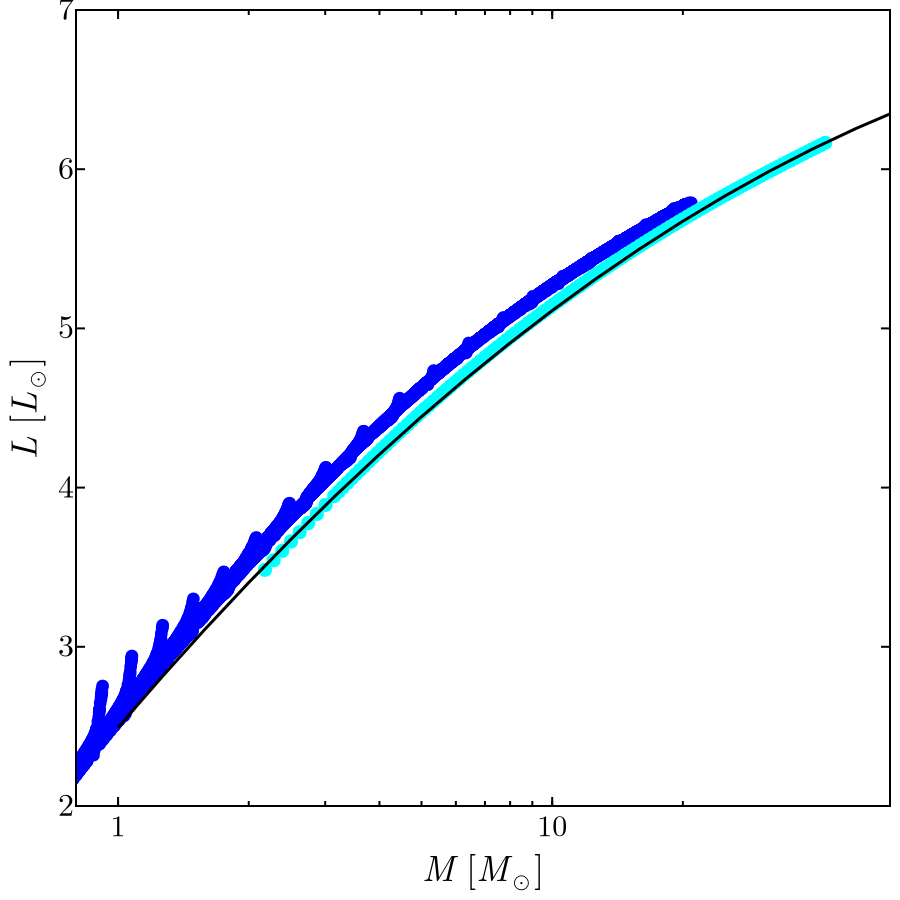

In [95]:

using LsqFit 
Ms = []
Ls = []
when = "BURN_He_50"
for n in range(1,length(f_MW.M_1_end_1))

    if f_MW[!, "M_tot_h_1_"*when*"_1"][n] < 0.001
        M = f_MW[!, "M_he_core_1_"*when*"_1"][n]
        L = f_MW[!, "logL_1_"*when*"_1"][n]
        push!(Ms, M)
        push!(Ls, L)
    end
    if f_MW[!, "M_tot_h_2_"*when*"_2"][n] < 0.001
        M = f_MW[!, "M_he_core_2_"*when*"_2"][n]
        L = f_MW[!, "logL_2_"*when*"_2"][n]
        push!(Ms, M)
        push!(Ls, L)
    end
end

Ms_end = []
Ls_end = []
when = "end_BURN_He"
for n in range(1,length(f_MW.M_1_end_1))

    if f_MW[!, "M_tot_h_1_"*when*"_1"][n] < 0.001
        M = f_MW[!, "M_he_core_1_"*when*"_1"][n]
        L = f_MW[!, "logL_1_"*when*"_1"][n]
        push!(Ms_end, M)
        push!(Ls_end, L)
    end
    if f_MW[!, "M_tot_h_2_"*when*"_2"][n] < 0.001
        M = f_MW[!, "M_he_core_2_"*when*"_2"][n]
        L = f_MW[!, "logL_2_"*when*"_2"][n]
        push!(Ms_end, M)
        push!(Ls_end, L)
    end
end


Ms_ini = []
Ls_ini = []
when = "BURN_He_25"
for n in range(1,length(f_MW.M_1_end_1))

    if f_MW[!, "M_tot_h_1_"*when*"_1"][n] < 0.1
        M = f_MW[!, "M_he_core_1_"*when*"_1"][n]
        L = f_MW[!, "logL_1_"*when*"_1"][n]
        push!(Ms_ini, M)
        push!(Ls_ini, L)
    end
    if f_MW[!, "M_tot_h_2_"*when*"_2"][n] < 0.1
        M = f_MW[!, "M_he_core_2_"*when*"_2"][n]
        L = f_MW[!, "logL_2_"*when*"_2"][n]
        push!(Ms_ini, M)
        push!(Ls_ini, L)
    end
end

FIGURE = Figure(size=(450,450), figure_padding = 5)

grid = FIGURE[1,1] = GridLayout()

logticks = [1,10,100]
logmticks = union(1:1:10, 10:10:20)

ax = plot_settings(grid[1:2, 1]; 
    xlabel=L"M \ [M_\odot]", 
    ylabel=L"L \ [L_\odot]",  xscale = log10, 
    title ="", xmticks = logmticks, xticks=logticks,
    yticklabelsize=16, xlabelsize=18, ylabelsize=18)

xlims!(ax, 1, nothing)

scatter!(ax, Ms_ini, Ls_ini, color = :blue)
# scatter!(ax, Ms, Ls, color = :black)
# scatter!(ax, Ms_end, Ls_end, color = :red)
M_he = f_HeSCC.M_ini_BURN_He
L_he = f_HeSCC.logL_ini_BURN_He

scatter!(ax, M_he, L_he, color = :cyan, markersize=10)

function Langer89(logM; Y = 0.3)
    return 2.971463 .+ 2.771634 .* logM - 0.487209 .* logM .^ 2 .-
           (0.487870 .- 0.434909 .* logM + 0.093793 .* logM .^2) .* Y

end
lines!(ax, 10 .^( 0:0.1:10),  Langer89(0:0.1:10; Y = 0.98), color = :black )
# # end 

# model(x,p) = p[1] .*   x .^ p[2] .+ p[3]
# model(x,p) = p[1] .*   x  .+ p[2] 
# # model(x,p) - p[1] .* exp.( x .* p[2]) .+ p[3]
# # model(x,p) - p[1] .* (x .+ p[2]) .^ 1  .+ p[3]
# p = [0, 3]
# the_fit = LsqFit.curve_fit(model, log10.(Ms), Ls, p)  
# err = stderror(the_fit)
# margin_of_error = margin_error(the_fit, 0.05)
# confidence_inter = confint(the_fit; level=0.95)
# print("\n")

# for i in range(1,length(the_fit.param))
#     @printf(" %7.2f  err: %5.2f  moe(%%5): %5.3f  ci(95%%): %5.3f-%5.3f\n", the_fit.param[i], err[i], margin_of_error[i], confidence_inter[i][1], confidence_inter[i][2])
# end

# xs = 0:0.1:5
# lines!(ax, 10 .^ xs, model(xs,the_fit.param ) )


xlims!(0.8, 60)
ylims!(2,7)
FIGURE



In [17]:
for name in names(f_MW)
    occursin("tot", name) && @printf("%s\n", name)
end

M_tot_h_1_BURN_H_25_1
M_tot_h_1_BURN_H_25_2
M_tot_h_1_BURN_H_50_1
M_tot_h_1_BURN_H_50_2
M_tot_h_1_BURN_He_25_1
M_tot_h_1_BURN_He_25_2
M_tot_h_1_BURN_He_50_1
M_tot_h_1_BURN_He_50_2
M_tot_h_1_BURN_He_75_1
M_tot_h_1_BURN_He_75_2
M_tot_h_1_end_1
M_tot_h_1_end_2
M_tot_h_1_end_BURN_C_1
M_tot_h_1_end_BURN_C_2
M_tot_h_1_end_BURN_H_1
M_tot_h_1_end_BURN_H_2
M_tot_h_1_end_BURN_He_1
M_tot_h_1_end_BURN_He_2
M_tot_h_1_end_RLOF_A
M_tot_h_1_end_RLOF_B
M_tot_h_1_end_RLOF_C
M_tot_h_1_ini_BURN_C_1
M_tot_h_1_ini_BURN_C_2
M_tot_h_1_ini_BURN_H_1
M_tot_h_1_ini_BURN_H_2
M_tot_h_1_ini_BURN_He_1
M_tot_h_1_ini_BURN_He_2
M_tot_h_1_ini_RLOF_A
M_tot_h_1_ini_RLOF_B
M_tot_h_1_ini_RLOF_C
M_tot_h_1_stripping_1
M_tot_h_1_stripping_2
M_tot_h_1_unstable_RLOF_A_ERK
M_tot_h_1_unstable_RLOF_A_PABLO
M_tot_h_1_unstable_RLOF_A_PAULI
M_tot_h_1_unstable_RLOF_A_PA_IV
M_tot_h_1_unstable_RLOF_B_ERK
M_tot_h_1_unstable_RLOF_B_PABLO
M_tot_h_1_unstable_RLOF_B_PAULI
M_tot_h_1_unstable_RLOF_B_PA_IV
M_tot_h_1_unstable_RLOF_C_ERK
M_tot_h_1_